# Electoral Analysis — Chilean Presidential Runoff 2025

On 14 December 2025, Chile went to the polls to decide, in a runoff election, its next president. With no candidate having secured an absolute majority (50% + 1 of valid votes) in the first round of 16 November, the runoff opposed **Jeannette Jara**, the ruling coalition's standard-bearer, and **José Antonio Kast**, leader of the Partido Republicano. This was the first definitive presidential election held under the compulsory voting regime since its reinstatement in 2022, an institutional variable that — as this report documents — conditions much of the comparative reading relative to earlier processes.

Jara, a Communist Party candidate backed by the rest of the ruling coalition (Frente Amplio, DC, PPD and PS), entered the runoff having placed first in the first round (26.85% of valid votes), yet that result constituted, in historical terms, the weakest performance by a left or centre-left candidacy in a presidential first round since the return to democracy in 1990. As the political successor of Gabriel Boric's government — whose administration had accumulated measurable erosion in approval surveys — Jara inherited both the challenge of reversing that erosion and the fragmentation of the former centre-left bloc, portions of which had migrated towards centrist or right-wing positions in the preceding years.

Kast, for his part, obtained 23.92% of the vote in the first round. A presidential candidate in 2017 (fourth place, 7.93%) and the finalist defeated by Boric in 2021, he consolidated in this third candidacy his undisputed leadership of Chilean conservative right. Heading into the runoff, he received the explicit endorsement of Evelyn Matthei (Chile Vamos) and Johannes Kaiser (libertarian right), as well as centre-leaning sectors such as Amarillos and Demócratas, many of them drawn from the former Concertación.

The runoff was thus configured as a contest between the continuity of the progressive project launched in 2022 and a conservative turn organised around security, public order and criticism of centralism. Yet reducing the result to that single ideological dimension would be inadequate: as this analysis shows, the election was also the endpoint of a political realignment process that began with the social uprising of 2019, in which the fragmentation of the traditional right, the sustained rise of the anti-establishment vote and the erosion of the ruling coalition redefined the country's balance of forces.

The result was decisive: Kast prevailed with a margin that more than doubled, in percentage points, the advantage obtained by Boric over Kast himself in 2021. This report examines the keys to that victory — and its limits — from the recomposition of the party system to the methodological lessons left by an atypical election marked by the return of compulsory voting and by levels of null and blank voting without precedent in the country's recent electoral history.

**Methodological note.** Unless otherwise indicated, the national figures in this report are calculated by aggregating the results of the 346 communes of Chile's continental and island territory, using the public databases of the Servicio Electoral (Servel). Votes cast by Chileans abroad — which in this election represented a minor fraction of the electoral register and were governed by different participation rules — were not incorporated into the territorial analysis, as their disaggregation at the polling-station level was not available in structured public databases at the time of preparation. Section 6 details the effect of this exclusion on the aggregate figures and compares the national result used here with the final official result proclaimed by Servel.

## 1. Setup

### 1.1. Dependencies

In [611]:
!pip install pandas numpy matplotlib geopandas

### 1.2. Imports

In [612]:
import os
import re
from pathlib import Path
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LinearSegmentedColormap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import geopandas as gpd
import seaborn as sns
import scipy.stats as stats

## 2. Data Loading

### 2.1. Electoral and Demographic Data

In [613]:
# Remote source URLs – GitHub raw files
url_votes_2025_first_round = "https://raw.githubusercontent.com/adroguetth/Chilean-Presidential-Elections-2025-Analysis/refs/heads/main/raw/chile_2025_first_round.csv"
url_votes_2025_second_round = "https://raw.githubusercontent.com/adroguetth/Chilean-Presidential-Elections-2025-Analysis/refs/heads/main/raw/chile_2025_second_round.csv"
url_votes_2021_second_round = "https://raw.githubusercontent.com/adroguetth/Chilean-Presidential-Elections-2025-Analysis/refs/heads/main/raw/chile_2021_second_round.csv"

url_pop   = "https://raw.githubusercontent.com/adroguetth/Chilean-Presidential-Elections-2025-Analysis/refs/heads/main/raw/communes_population_2024.csv"
url_dim   = "https://raw.githubusercontent.com/adroguetth/Chilean-Presidential-Elections-2025-Analysis/refs/heads/main/raw/region_dimension.csv"

print("URLs configured")

URLs configured


### 2.2. Load Data

#### 2.2.1. Electoral Data (first round 2025)

In [614]:
df_2025_v1 = pd.read_csv(url_votes_2025_first_round, encoding='utf-8-sig')

print(f"Electoral data loaded: {len(df_2025_v1):,} communes, {df_2025_v1.shape[1]} columns")
print(f"\nFirst 3 rows:")
df_2025_v1.head(3)

Electoral data loaded: 346 communes, 24 columns

First 3 rows:


,commune,region,artes_votes,artes_pct,enriquez_ominami_votes,enriquez_ominami_pct,jara_votes,jara_pct,kaiser_votes,kaiser_pct,...,mayne_nicholls_votes,mayne_nicholls_pct,parisi_votes,parisi_pct,blank_votes,blank_pct,casted_votes,casted_pct,null_votes,null_pct
0,Antofagasta,Antofagasta,1375,0.56,2738,1.12,60507,24.71,31798,12.99,...,4065,1.66,79669,32.54,3014,1.18,255984,100.0,8137,3.18
1,Calama,Antofagasta,488,0.47,1201,1.15,19496,18.69,14990,14.37,...,1005,0.96,40651,38.98,963,0.89,108350,100.0,3096,2.86
2,Maria Elena,Antofagasta,14,0.45,40,1.28,694,22.27,288,9.24,...,33,1.06,1429,45.86,41,1.26,3261,100.0,104,3.19


#### 2.2.2. Electoral Data (second round 2025)

In [615]:
df_2025_v2 = pd.read_csv(url_votes_2025_second_round, encoding='utf-8-sig')

print(f"Second round 2025 data loaded: {len(df_2025_v2):,} communes, {df_2025_v2.shape[1]} columns")
print(f"\nFirst 3 rows:")
df_2025_v2.head(3)

Second round 2025 data loaded: 346 communes, 12 columns

First 3 rows:


,commune,region,jara_votes,jara_pct,kast_votes,kast_pct,blank_votes,blank_pct,casted_votes,casted_pct,null_votes,null_pct
0,Antofagasta,Antofagasta,102890,45.15,124984,54.85,3884,1.53,253849,100.0,22091,8.70
1,Calama,Antofagasta,34473,36.00,61295,64.00,1222,1.14,107390,100.0,10400,9.68
2,Maria Elena,Antofagasta,1408,50.47,1382,49.53,60,1.89,3176,100.0,326,10.26


#### 2.2.3. Electoral Data (second round 2021)

In [616]:
df_2021_v2 = pd.read_csv(url_votes_2021_second_round, encoding='utf-8-sig')

print(f"2021 electoral data loaded: {len(df_2021_v2):,} communes, {df_2021_v2.shape[1]} columns")
print(f"\nFirst 3 rows:")
df_2021_v2.head(3)

2021 electoral data loaded: 346 communes, 12 columns

First 3 rows:


,commune,region,boric_votes,boric_pct,kast_votes,kast_pct,blank_votes,blank_pct,casted_votes,casted_pct,null_votes,null_pct
0,Alto Hospicio,Tarapacá,11971,50.16,11897,49.84,64,0.26,24211,100,279,1.15
1,Camiña,Tarapacá,151,17.62,706,82.38,0,0.00,866,100,9,1.04
2,Colchane,Tarapacá,52,5.31,928,94.69,1,0.10,984,100,3,0.30


#### 2.2.4. Population Data

In [617]:
df_pop = pd.read_csv(url_pop, encoding='utf-8-sig')

# Cast population columns to nullable integer to remove trailing .0
for col in ['population', 'male_population', 'female_population']:
    if col in df_pop.columns:
        df_pop[col] = df_pop[col].astype('Int64')

print(f"Population data loaded: {len(df_pop):,} communes, {df_pop.shape[1]} columns")
print(f"\nFirst 3 rows:")
df_pop.head(3)

Population data loaded: 345 communes, 6 columns

First 3 rows:


,commune,region,population,male_population,female_population,sex_ratio
0,camarones,Arica y Parinacota,861,430,431,99.8
1,putre,Arica y Parinacota,1547,846,701,120.7
2,general lagos,Arica y Parinacota,508,261,247,105.7


#### 2.2.5. Region Dimension Table

In [618]:
df_region_dim = pd.read_csv(url_dim, encoding='utf-8-sig')

print(f"Region dimension table loaded: {len(df_region_dim)} rows, {df_region_dim.shape[1]} columns")
print(f"\nFirst 3 rows:")
df_region_dim.head(3)

Region dimension table loaded: 16 rows, 5 columns

First 3 rows:


,region_code,region,macrozone,macrozone_order,region_order
0,15,Arica y Parinacota,Norte Grande,1,1
1,1,Tarapacá,Norte Grande,1,2
2,2,Antofagasta,Norte Grande,1,3


### 2.3. Geographic Data (Commune GeoJSON)

In [619]:
# ============================================================================
# GEOGRAPHIC DATA LOADER
# ============================================================================

def load_geographic_data() -> gpd.GeoDataFrame:
    """
    Loads Chilean commune geometries from multiple sources in priority order:
    1. Local files (GeoJSON or SHP).
    2. Per-region download from the public caracena/chile-geojson repository.

    Raises RuntimeError if no source is reachable.

    Returns
    -------
    gpd.GeoDataFrame
        CRS EPSG:4326, with at least columns NOM_COM, COD_COM, REGION_NUM.
    """
    print("Loading geographic data...")

    # Local file search order
    local_files = [
        'comunas_chile.geojson', 'comunas.geojson',
        'chile_comunas.geojson', 'chile.geojson',
        'comunas_chile.shp', 'comunas.json',
    ]
    for path in local_files:
        if os.path.exists(path):
            try:
                gdf = gpd.read_file(path)
                if len(gdf) > 0:
                    print(f"Local file loaded: {path} ({len(gdf)} communes)")
                    return gdf
            except Exception as exc:
                print(f"Could not read {path}: {exc}")

    # Fallback: download per region from GitHub
    print("No local files found. Downloading from caracena/chile-geojson...")
    gdfs = []
    for i in range(1, 17):
        url = f"https://raw.githubusercontent.com/caracena/chile-geojson/master/{i}.geojson"
        try:
            gdf_region = gpd.read_file(url)
            # Normalise column names to internal schema
            if 'Comuna' in gdf_region.columns:
                gdf_region['NOM_COM'] = gdf_region['Comuna']
            if 'cod_comuna' in gdf_region.columns:
                gdf_region['COD_COM'] = gdf_region['cod_comuna']
            gdf_region['REGION_NUM'] = (
                gdf_region['codregion'] if 'codregion' in gdf_region.columns else i
            )
            gdfs.append(gdf_region)
            print(f"Region {i}: {len(gdf_region)} communes downloaded")
        except Exception as exc:
            print(f"Error downloading region {i}: {exc}")

    if gdfs:
        gdf = gpd.GeoDataFrame(pd.concat(gdfs, ignore_index=True), crs='EPSG:4326')
        gdf.to_file('comunas_chile.geojson', driver='GeoJSON')
        print(f"Total downloaded: {len(gdf)} communes. Saved as 'comunas_chile.geojson'.")
        return gdf

    raise RuntimeError("Could not load geographic data from any source.")

communes = load_geographic_data()

# Derive REGION_NUM from COD_COM when absent in the GeoDataFrame
if 'REGION_NUM' not in communes.columns:
    if 'COD_COM' in communes.columns:
        communes['REGION_NUM'] = communes['COD_COM'].astype(str).str[:2].astype(int)
    else:
        raise ValueError("Neither 'REGION_NUM' nor 'COD_COM' found in GeoDataFrame.")

print(f"GeoDataFrame ready: {len(communes)} records")
print(f"Columns: {list(communes.columns)}")

Loading geographic data...
Local file loaded: comunas_chile.geojson (345 communes)
GeoDataFrame ready: 345 records
Columns: ['objectid', 'shape_leng', 'dis_elec', 'cir_sena', 'cod_comuna', 'codregion', 'st_area_sh', 'st_length_', 'Region', 'Comuna', 'Provincia', 'NOM_COM', 'COD_COM', 'REGION_NUM', 'geometry']


### 2.4. Commune normalizer

In [620]:
# ============================================================================
# COMMUNE NAME NORMALIZER
# ============================================================================

# Deferred: used in spatial join sections (§ map analysis, § transition maps).
# Defined here to keep all utility functions in §2 and avoid forward references.

import unicodedata

def normalize_commune_name(name: str) -> str:
    """
    Canonicalizes a commune name for cross-dataset matching.

    Processing pipeline:
    1. Lowercase and strip surrounding whitespace.
    2. NFD decomposition + strip combining marks — removes all diacritics
       and diaereses regardless of source encoding (e.g. ü → u).
    3. Remove non-alphanumeric characters (hyphens, parentheses, punctuation).
    4. Collapse internal whitespace to a single space.
    5. Apply a curated correction table on the clean ASCII form to resolve
       residual spelling divergences between source datasets.

    Diacritics are stripped before the correction lookup so every correction
    key uses plain ASCII; no accented variants are required.

    Parameters
    ----------
    name : str
        Raw commune name from any source dataset.

    Returns
    -------
    str
        Normalized canonical form ready for equality comparison or join key.

    Notes
    -----
    First active use: spatial join in the commune-level winner map section.
    """
    if pd.isna(name):
        return ''

    name = str(name).strip().lower()

    # Strip diacritics via NFD decomposition + combining mark removal
    name = unicodedata.normalize('NFD', name)
    name = ''.join(c for c in name if unicodedata.category(c) != 'Mn')

    # Remove non-alphanumeric characters (keep spaces)
    name = re.sub(r'[^a-z0-9\s]', '', name)

    # Collapse whitespace
    name = ' '.join(name.split())

    # Correction table: keys are already-stripped ASCII forms
    CORRECTIONS = {
        'llayllay':                  'llaillay',   # Llay-Llay → Llaillay
        'trehuaco':                  'treguaco',   # legacy transliteration
        'marchigue':                'marchihue',  # Marchigüe → Marchihue (official)
        'cabo de hornosexnavarino':  'cabo de hornos',  # parenthetical suffix
    }
    return CORRECTIONS.get(name, name)

### 2.5. Candidate Metadata

In [621]:
# ============================================================================
# CANDIDATE METADATA AND COLOR PALETTE
# ============================================================================

# Display name → column key and political affiliation
CANDIDATES_META = {
    'Jeannette Jara':         {'col': 'jara_votes',             'party': 'Left-wing officialist (Boric - Unidad por Chile)'},
    'José Antonio Kast':      {'col': 'kast_votes',             'party': 'Conservative right (Partido Republicano)'},
    'Franco Parisi':          {'col': 'parisi_votes',           'party': 'Third way (Partido de la Gente)'},
    'Johannes Kaiser':        {'col': 'kaiser_votes',           'party': 'Libertarian right (Partido Nacional Libertario)'},
    'Evelyn Matthei':         {'col': 'matthei_votes',          'party': 'Historical right - Piñerismo (Chile Vamos)'},
    'Harold Mayne-Nicholls':  {'col': 'mayne_nicholls_votes',   'party': 'Independent'},
    'Marco Enriquez-Ominami': {'col': 'enriquez_ominami_votes', 'party': 'Independent left'},
    'Eduardo Artes':          {'col': 'artes_votes',            'party': 'Far left'},
}

# Campaign corporate color palette by candidate
CANDIDATE_COLORS = {
    'Jeannette Jara':         '#E54944',
    'José Antonio Kast':      '#35466D',
    'Franco Parisi':          '#4B70B5',
    'Johannes Kaiser':        '#F3832C',
    'Evelyn Matthei':         '#226FD4',
    'Harold Mayne-Nicholls':  '#BED8DF',
    'Marco Enriquez-Ominami': '#DD2883',
    'Eduardo Artes':          '#CA1C1F',
    'No data':                '#D3D3D3',
}

## 3. Participation and Valid Votes: The Anomaly of a Runoff in Reverse

The 2025 presidential runoff left a statistical imprint that compels a re-examination of a classic assumption about Chilean electoral behaviour: that a definitive round mobilises the electorate more than the first. For the first time since the introduction of the runoff system in 1999, participation measured in valid votes not only stagnated but actually declined relative to the first round. The most telling indicator of this anomaly is the null vote, which nearly doubled in the space of a month and reached a magnitude without precedent in the country's recent democratic history. This phenomenon — which, as will be shown, affected the ruling coalition's option disproportionately — is not an isolated statistical accident, but a symptom of a tension between the electorate and the political supply that transcends the immediate electoral outcome.

In [622]:
# ============================================================================
# COMPARATIVE VOTER TURNOUT: FIRST ROUND VS SECOND ROUND 2025
# ============================================================================
# Aggregates cast, valid, blank, and null vote totals for both rounds and
# computes absolute and directional deltas to surface participation anomalies.
# ============================================================================

def analyze_turnout_comparison(df1: pd.DataFrame, df2: pd.DataFrame) -> pd.DataFrame:
    """
    Compares participation metrics between first and second rounds.
    
    Parameters
    ----------
    df1 : pd.DataFrame
        First round data with columns: casted_votes, blank_votes, null_votes
    df2 : pd.DataFrame
        Second round data with columns: casted_votes, blank_votes, null_votes
    
    Returns
    -------
    pd.DataFrame
        DataFrame with indicator, first_round, second_round, diff, trend
    """
    # First round totals
    communes_1 = len(df1)
    casted_1 = df1['casted_votes'].sum()
    blank_1 = df1['blank_votes'].sum()
    null_1 = df1['null_votes'].sum()
    valid_1 = casted_1 - blank_1 - null_1
    
    # Second round totals
    communes_2 = len(df2)
    casted_2 = df2['casted_votes'].sum()
    blank_2 = df2['blank_votes'].sum()
    null_2 = df2['null_votes'].sum()
    valid_2 = casted_2 - blank_2 - null_2
    
    def get_trend(val1, val2):
        if val2 > val1:
            return 'INCREASE'
        elif val2 < val1:
            return 'DECREASE'
        return 'NO CHANGE'
    
    results = []
    
    # Total municipalities
    results.append({
        'indicator': 'Total municipalities',
        'first_round': communes_1,
        'second_round': communes_2,
        'diff': communes_2 - communes_1,
        'trend': get_trend(communes_1, communes_2)
    })
    
    # Votes cast
    results.append({
        'indicator': 'Votes cast',
        'first_round': casted_1,
        'second_round': casted_2,
        'diff': casted_2 - casted_1,
        'trend': get_trend(casted_1, casted_2)
    })
    
    # Blank votes
    results.append({
        'indicator': 'Blank votes',
        'first_round': blank_1,
        'second_round': blank_2,
        'diff': blank_2 - blank_1,
        'trend': get_trend(blank_1, blank_2)
    })
    
    # Null votes
    results.append({
        'indicator': 'Null votes',
        'first_round': null_1,
        'second_round': null_2,
        'diff': null_2 - null_1,
        'trend': get_trend(null_1, null_2)
    })
    
    # Valid votes
    results.append({
        'indicator': 'Valid votes',
        'first_round': valid_1,
        'second_round': valid_2,
        'diff': valid_2 - valid_1,
        'trend': get_trend(valid_1, valid_2)
    })
    
    return pd.DataFrame(results)

# Execute comparison
turnout_comparison = analyze_turnout_comparison(df_2025_v1, df_2025_v2)
turnout_comparison

,indicator,first_round,second_round,diff,trend
0,Total municipalities,346,346,0,NO CHANGE
1,Votes cast,13388455,13362076,-26379,DECREASE
2,Blank votes,141956,165003,23047,INCREASE
3,Null votes,360571,782029,421458,INCREASE
4,Valid votes,12885928,12415044,-470884,DECREASE


### Analysis

The comparative table between first and second round reveals an atypical pattern that breaks with the historical trend of Chilean elections. While the total votes cast remained practically stable (a marginal decline of 26,379 ballots, −0.2%), valid votes fell by 470,884 (−3.7%). This contraction is significant when one considers that in the 1999, 2005 and 2017 runoffs, valid participation tended to increase or hold at levels comparable to the first round, reflecting the mobilising effect characteristic of a definitive election. The decline of nearly half a million valid votes suggests that a relevant segment of the electorate chose not to endorse the available binary offer.

The most revealing phenomenon is the surge in the null vote, which rose from 360,571 ballots in the first round to 782,029 in the second — an increase of 116.9% that practically doubles the initial figure. In percentage terms, the null vote jumped from 2.69% to 5.85% of ballots cast, the highest level recorded in a Chilean presidential election since the return to democracy. The figure acquires greater significance in historical perspective: in the 1999, 2005 and 2009 runoffs, the combined null and blank vote did not exceed 3.4%, and even in the polarised 2021 election — held under voluntary voting — invalid votes barely reached 1.11%. The 2025 figure, which approaches 7% when null and blank votes are combined, constitutes a structural break with the country's previous electoral behaviour.

The scholarly literature on electoral behaviour offers useful frameworks for interpreting this shift. The null vote tends to increase under compulsory voting regimes and in contexts where the electorate perceives that the election is not competitive or that none of the available options represents it. The relevant analytical distinction is between the null vote as active protest — a deliberate form of political expression — and the null vote as error or procedural ignorance, the latter more closely associated with populations with lower access to civic education. In 2025, the magnitude of the increase, its correlation with the vote for Franco Parisi (detailed in section 11) and its concentration in specific regions suggest that a substantial portion of these votes corresponds to deliberate protest, in a context where compulsory voting eliminated abstention as a passive channel for expressing discontent.

The combined increase in null and blank votes (+444,505 ballots) is equivalent to approximately 17% of the gap that separated Jeannette Jara from parity with José Antonio Kast in valid votes. This does not imply that this bloc of votes would have favoured the ruling-coalition candidate had they been cast as valid ballots — no evidence permits an inference of their counterfactual distribution — but it does situate the magnitude of the phenomenon on a scale comparable to the electoral margin itself, reason enough to treat it as a central variable of the process rather than a footnote.

### Chapter 3 Conclusion: Participation and Valid Votes

The 2025 runoff did not merely elect a new president: it revealed a transformation in the relationship between citizens and the Chilean political system. The historically unprecedented rise in the null vote, combined with the decline in valid votes, shows that a segment of the electorate — equivalent to more than 470,000 people in terms of valid votes not cast, and to nearly 780,000 in total null votes — opted for active protest rather than validating a binary offer that failed to engage them fully. This behaviour, which breaks with decades of relatively stable electoral trends, anticipates challenges for the legitimacy of future processes and suggests that the party system faces a representational crisis that compulsory voting did not resolve, but instead channelled into non-conventional forms of expression.

It is worth qualifying, however, a reading that is too linear: as detailed in section 8.7, the commune-level analysis does not support the hypothesis that the protest vote harmed the ruling-coalition candidacy exclusively or primarily; in several communes where protest voting was highest, Jara also recorded her largest percentage gains. The null vote appears to have operated, rather, as a release valve for the electorate that had supported Franco Parisi in the first round and that, in the runoff, found no fully satisfactory alternative in either of the two options. The challenge for the political system as a whole — not only for the incoming government — will be to reconnect with an electorate that, in this election, learned to use the null vote as a tool of political expression.

---

## 4. The Null Vote: Anatomy of an Unprecedented Protest

### Introduction

The behaviour of the null vote in the 2025 runoff is one of the most revealing phenomena of the electoral process: it confirms a transversal rejection of the Jara–Kast contest, albeit with a pronounced territorial gradient. The null vote nearly doubled across all of the country's macrozones — with an average increase of 3.4 percentage points — but its relative intensity was notably greater in the Norte Grande, where Antofagasta and Atacama led the increases with rises exceeding 5 points. In absolute volume, by contrast, the Metropolitan Region concentrated the largest increment, with more than 134,000 additional null votes — nearly one third of the national total. The fact that not a single region recorded a decrease in null voting confirms that the rejection of the final offer was not an isolated phenomenon: the active protest, estimated at roughly half a million additional voters relative to the first round, tempers a reading of Kast's victory in terms of legitimacy without diminishing its electoral validity, and demonstrates that his triumph occurred alongside a rise in disaffection rather than as a consequence of its containment.

### 4.1. Null Vote by Region

The regional breakdown allows the north–south gradient already anticipated to be specified more precisely: Antofagasta and Atacama not only led the increase in percentage points but reached the country's highest null vote rates in absolute terms — 9.04% and 8.05% of total ballots cast, respectively — nearly doubling the national average of 5.85%. The following table disaggregates the change region by region, ranking results from the largest to the smallest percentage variation.

In [623]:
# ============================================================================
# NULL VOTE INCREASE BY REGION — FIRST ROUND VS SECOND ROUND 2025
# ============================================================================
# Aggregates null votes by region across both rounds and ranks regions by
# absolute and percentage-point increase to identify protest-vote concentrations.
# ============================================================================

def analyze_null_votes_by_region(df1: pd.DataFrame, df2: pd.DataFrame) -> pd.DataFrame:
    """
    Calculates null vote metrics by region and compares first vs second round.
    
    Parameters
    ----------
    df1 : pd.DataFrame
        First round data with columns: region, commune, null_votes, casted_votes
    df2 : pd.DataFrame
        Second round data with columns: region, commune, null_votes, casted_votes
    
    Returns
    -------
    pd.DataFrame
        DataFrame with region-level null vote statistics and trend
    """
    # Aggregate first round by region
    first_round_agg = df1.groupby('region').agg({
        'null_votes': 'sum',
        'casted_votes': 'sum'
    }).reset_index()
    first_round_agg.columns = ['region', 'null_votes_first_round', 'total_votes_first_round']
    first_round_agg['null_pct_first_round'] = round(
        100.0 * first_round_agg['null_votes_first_round'] / first_round_agg['total_votes_first_round'], 2
    )
    
    # Aggregate second round by region
    second_round_agg = df2.groupby('region').agg({
        'null_votes': 'sum',
        'casted_votes': 'sum'
    }).reset_index()
    second_round_agg.columns = ['region', 'null_votes_second_round', 'total_votes_second_round']
    second_round_agg['null_pct_second_round'] = round(
        100.0 * second_round_agg['null_votes_second_round'] / second_round_agg['total_votes_second_round'], 2
    )
    
    # Merge both rounds
    result = pd.merge(first_round_agg, second_round_agg, on='region', how='inner')
    
    # Calculate changes
    result['null_votes_change'] = result['null_votes_second_round'] - result['null_votes_first_round']
    result['null_pct_point_change'] = round(
        result['null_pct_second_round'] - result['null_pct_first_round'], 2
    )
    
    # Add trend column
    result['trend'] = result['null_votes_change'].apply(
        lambda x: 'INCREASE' if x > 0 else ('DECREASE' if x < 0 else 'NO CHANGE')
    )
    
    # Filter only regions with increase and order by change descending
    result = result[result['trend'] == 'INCREASE'].copy()
    result = result.sort_values('null_votes_change', ascending=False)
    
    # Format columns
    result['null_votes_first_round'] = result['null_votes_first_round'].astype(int)
    result['null_votes_second_round'] = result['null_votes_second_round'].astype(int)
    result['null_votes_change'] = result['null_votes_change'].astype(int)
    
    # Select and order columns
    result = result[[
        'region',
        'null_votes_first_round',
        'null_votes_second_round',
        'null_votes_change',
        'null_pct_first_round',
        'null_pct_second_round',
        'null_pct_point_change',
        'trend'
    ]]
    
    return result

# Execute analysis
null_votes_by_region = analyze_null_votes_by_region(df_2025_v1, df_2025_v2)
null_votes_by_region

,region,null_votes_first_round,null_votes_second_round,null_votes_change,null_pct_first_round,null_pct_second_round,null_pct_point_change,trend
12,Metropolitana,130138,264658,134520,2.52,5.14,2.62,INCREASE
14,Valparaíso,44999,92651,47652,3.10,6.40,3.30,INCREASE
4,Biobío,32243,77421,45178,2.65,6.37,3.72,INCREASE
11,Maule,22979,48502,25523,2.67,5.65,2.98,INCREASE
7,Libertador,21523,46255,24732,2.84,6.11,3.27,INCREASE
5,Coquimbo,18149,42607,24458,3.10,7.30,4.20,INCREASE
0,Antofagasta,12621,36830,24209,3.08,9.04,5.96,INCREASE
8,Los Lagos,18579,40259,21680,2.76,5.99,3.23,INCREASE
6,La Araucanía,19178,40289,21111,2.46,5.19,2.73,INCREASE
15,Ñuble,10038,21111,11073,2.47,5.23,2.76,INCREASE


#### Analysis

##### The Norte Grande as the Epicentre of Protest

The most direct explanation of the territorial pattern lies in the behaviour of Franco Parisi's electorate. Partido de la Gente (PDG) held a digital consultation among its members on 30 November, in which 78% opted for casting a null or blank vote, against 20% who chose Kast and a mere 2% Jara. The party grounded its decision in "the legitimate discontent of its members with the alternatives available in the runoff." Given that support for Parisi in the first round was concentrated precisely in the northern mining regions — those most exposed to perceptions of insecurity and irregular migration — it is not coincidental that these same territories recorded the highest null vote levels in the second round.

The scholarly literature on electoral behaviour supports this reading: the null vote tends to grow in contexts where the electorate perceives that none of the available options represents it adequately. The Norte Grande, with an economy heavily dependent on mining and an intense exposure to migratory flows in recent years, concentrates an electorate that in the first round massively supported an anti-establishment candidate and that, in the runoff, opted for active protest rather than validating a binary offer that did not engage it.

##### Absolute Volume: The Demographic Weight of the Metropolitan Region

If the North led in relative intensity, the Metropolitan Region concentrated the largest absolute volume of additional null votes (134,520), nearly one third of the national increase. The figure must be interpreted with caution: as the country's most populated region, its absolute weight in any aggregate variable is, to some extent, expected. What is relevant is that its variation in percentage points (+2.62 pp, from 2.52% to 5.14%) fell below the national average, suggesting that the relative intensity of the protest was greater in the north than in the capital, even if its absolute magnitude was smaller.

Valparaíso (+3.30 pp) and Biobío (+3.72 pp) also recorded significant increases, though below the mining regions, contributing 47,652 and 45,178 additional null votes respectively. That all 16 regions of the country recorded increases — without a single exception — confirms the transversal nature of the rejection of the final contest, beyond its differentiated intensity.

##### Implications for the Legitimacy of the Mandate

Jara's public appeal to PDG voters to "reconsider" the null or blank vote, noting that "what happens in the next four years will depend greatly on the decision that is made," did not reverse the trend. Kast won the election with 58.24% of valid votes across the 346 communes analysed (58.16% in the official national result, as detailed in section 6), yet he did so in a context where 7.1% of ballots cast were null or blank — a proportion that nearly doubles the 3.7% of the first round. This figure, although below the projections that Parisi himself was publicly making (between 12% and 18%), represents a level of active protest without precedent in the recent history of Chilean runoffs, and constitutes an element that any reading of the new government's mandate should weigh, without it diminishing the electoral validity of the result.

#### Conclusion 4.1.

The null vote consolidated in the runoff as the primary expression of citizen discontent, with particular intensity in the Norte Grande, where Franco Parisi's electorate opted predominantly for active protest rather than validating a binary final offer that did not engage it. This north–south pattern, transversal across all 16 regions, does not undermine the validity of Kast's victory, but does temper its reading: the new government takes office with a broad mandate in valid votes while coexisting with a level of citizen protest that has no recent precedent in Chilean runoffs. The fundamental challenge — which extends beyond the incoming government — is to reconnect with an electorate that, particularly in the territories where distrust of the political system runs deepest, has incorporated the null vote as a habitual tool of political expression.

### 4.2. Null Vote by Geographic Macrozone

Disaggregation by macrozone — which groups contiguous regions with similar socioeconomic profiles — allows the duality between intensity and volume already noted to be identified with greater clarity. The Norte Grande led the relative increase (+5.22 pp, reaching a null vote rate of 8.14%), confirming that Parisi's electorate was the most disposed to active protest, while the Centre (Metropolitan Region and Valparaíso) concentrated the largest absolute volume, with more than 232,000 additional null votes — equivalent to nearly half the national increase.

In [624]:
# ============================================================================
# NULL VOTE CHANGE BY GEOGRAPHIC ZONE (MACROZONE) — ROUND 1 VS ROUND 2
# ============================================================================
# Groups communes by macrozone and computes aggregate null vote shifts,
# enabling geographic segmentation of the protest vote signal.
# ============================================================================

def analyze_null_votes_by_zone(df1: pd.DataFrame, df2: pd.DataFrame, df_zone: pd.DataFrame) -> pd.DataFrame:
    """
    Calculates null vote metrics by geographic zone (Norte Grande, Centro, Sur, etc.)
    
    Parameters
    ----------
    df1 : pd.DataFrame
        First round data with columns: region, null_votes, casted_votes
    df2 : pd.DataFrame
        Second round data with columns: region, null_votes, casted_votes
    df_zone : pd.DataFrame
        Region dimension with columns: region, macrozone, macrozone_order
    
    Returns
    -------
    pd.DataFrame
        DataFrame with zone-level null vote statistics
    """
    # Merge region dimension to first round
    df1_with_zone = df1.merge(df_zone[['region', 'macrozone', 'macrozone_order']], on='region', how='left')
    
    # Merge region dimension to second round
    df2_with_zone = df2.merge(df_zone[['region', 'macrozone', 'macrozone_order']], on='region', how='left')
    
    # Aggregate first round by zone
    first_zone_agg = df1_with_zone.groupby('macrozone').agg({
        'null_votes': 'sum',
        'casted_votes': 'sum',
        'macrozone_order': 'first'
    }).reset_index()
    first_zone_agg.columns = ['macrozone', 'null_votes_first_round', 'total_votes_first_round', 'macrozone_order']
    first_zone_agg['null_pct_first_round'] = round(
        100.0 * first_zone_agg['null_votes_first_round'] / first_zone_agg['total_votes_first_round'], 2
    )
    
    # Aggregate second round by zone
    second_zone_agg = df2_with_zone.groupby('macrozone').agg({
        'null_votes': 'sum',
        'casted_votes': 'sum'
    }).reset_index()
    second_zone_agg.columns = ['macrozone', 'null_votes_second_round', 'total_votes_second_round']
    second_zone_agg['null_pct_second_round'] = round(
        100.0 * second_zone_agg['null_votes_second_round'] / second_zone_agg['total_votes_second_round'], 2
    )
    
    # Merge both rounds
    result = pd.merge(first_zone_agg, second_zone_agg, on='macrozone', how='inner')
    
    # Calculate changes
    result['null_votes_change'] = result['null_votes_second_round'] - result['null_votes_first_round']
    result['null_pct_point_change'] = round(
        result['null_pct_second_round'] - result['null_pct_first_round'], 2
    )
    
    # Sort by macrozone order (north to south)
    result = result.sort_values('macrozone_order')
    
    # Select and order columns
    result = result[[
        'macrozone',
        'null_votes_first_round',
        'null_votes_second_round',
        'null_votes_change',
        'null_pct_first_round',
        'null_pct_second_round',
        'null_pct_point_change'
    ]]
    
    return result

# Execute analysis by zone
null_votes_by_zone = analyze_null_votes_by_zone(df_2025_v1, df_2025_v2, df_region_dim)
null_votes_by_zone

,macrozone,null_votes_first_round,null_votes_second_round,null_votes_change,null_pct_first_round,null_pct_second_round,null_pct_point_change
3,Norte Grande,22792,63243,40451,2.92,8.14,5.22
2,Norte Chico,24041,59490,35449,3.02,7.50,4.48
0,Centro,219639,452066,232427,2.67,5.50,2.83
1,Centro Sur,61459,138821,77362,2.56,5.80,3.24
5,Sur,26471,56853,30382,2.69,5.77,3.08
4,Patagonia,6169,11556,5387,3.16,5.93,2.77


#### Analysis

##### Distribution by Macrozone

| Macrozone        | Absolute Change | Percentage Points (pp) | Null % R1 | Null % R2 | Key interpretation              |
| ---------------- | --------------- | ---------------------- | --------- | --------- | -------------------------------- |
| **Norte Grande** | +40,451         | **+5.22**              | 2.92%     | 8.14%     | **Largest relative increase**    |
| **Norte Chico**  | +35,449         | +4.48                  | 3.02%     | 7.50%     | Very strong                      |
| **Centre**       | **+232,427**    | +2.83                  | 2.67%     | 5.50%     | **Largest absolute volume**      |
| **Centre-South** | +77,362         | +3.24                  | 2.56%     | 5.80%     | Strong                           |
| **South**        | +30,382         | +3.08                  | 2.69%     | 5.77%     | Strong                           |
| **Patagonia**    | +5,387          | +2.77                  | 3.16%     | 5.93%     | Moderate but relevant            |

##### The PDG's Call and its Differential Impact

The territorial pattern of the null vote finds its most direct explanation in the decision of Partido de la Gente (PDG) to call on its supporters to cast a null or blank vote. On 30 November, the PDG held a digital consultation in which 78% of participants opted for this course, against 20% who leaned towards Kast and 2% towards Jara; the party justified the decision on the grounds of "the legitimate discontent of its members with the alternatives that will be in the upcoming runoff," a message that Franco Parisi himself reinforced by writing "Null" on his social media during the ANATEL presidential debate.

The effect of that call was heterogeneous because electoral support for Parisi was not uniform either. The majority of the 2.5 million people who voted for him in the first round corresponded to men under 45 from the middle class, with his main strongholds in the northern mining provinces, zones particularly affected by perceptions of insecurity and irregular migration. This concentration explains why the Norte Grande (+5.22 pp) and Norte Chico (+4.48 pp) recorded the largest relative increases, reaching rates of 8.14% and 7.50% respectively — well above the national average of 5.85%.

The contrast with the Centre (+2.83 pp) and Patagonia (+2.77 pp), which recorded the most moderate increases, confirms that active protest was proportionally more intense in the zones where Parisi's electorate had the greatest relative weight. The Metropolitan Region and Valparaíso, despite concentrating the largest absolute volume of additional null votes, showed percentage variations below the national average.

##### The Gap Between the PDG's Internal Mandate and Actual Behaviour

A relevant nuance is the gap between the PDG's call and the actual behaviour of its electorate. Parisi had publicly projected that null and blank votes might amount to between 12% and 18% of the total; the effective figure was 5.83% null and 1.23% blank. This gap is even more striking when compared with the 19.71% (2,552,649 votes) that Parisi himself obtained in the first round: the large majority of those who supported him did not follow the instruction to annul, and his electorate dispersed primarily between the two competing candidacies, with a more pronounced inclination towards Kast.

Parisi himself acknowledged this gap after the results were announced, stating that "one could say that PDG votes went to Kast" and that "there is a very strong anti-communist sentiment, a very deep fear of what Jara represented." The statement suggests that, without that "anti-communist sentiment," the null vote in the North might have been even higher, and reveals the limits of a party leadership's capacity to discipline an electorate with low partisan identification and high volatility.

##### Political Reading of the Dual Pattern

The generalised increase in the null vote across all macrozones — without a single exception — confirms that the rejection of the Jara–Kast contest was structural and not limited to specific territories. This qualifies, without invalidating it, the magnitude of the 58.24% obtained by Kast at the communal level: the election was decided in a context where 7.1% of ballots cast were null or blank, and where a relevant portion of the electorate of the country's third-largest political force did not feel represented by either of the two competing options.

The duality between intensity (greater in the north) and volume (greater in the Centre) suggests that citizen discontent took territorially distinct forms: more concentrated and radicalised in the mining zones, more diffuse and dispersed in the large urban centres. Both share, however, a common denominator: distrust of the traditional political system and rejection of a binary offer that failed to engage a significant fraction of the electorate.

#### Conclusion 4.2.

The null vote in the runoff manifested as a territorially differentiated but structurally transversal phenomenon. The Norte Grande and Norte Chico zones, where Franco Parisi's electorate carried greater relative weight, recorded the most pronounced increases, confirming that Partido de la Gente's call to vote null had particularly intense effects in its territorial strongholds. However, the gap between the PDG's internal mandate — which projected a far higher null vote — and the actual outcome shows that, even in those territories, a significant fraction of Parisi's electorate ultimately opted for Kast, driven more by the rejection of a potential left-wing government than by any positive ideological affinity with the right. This suggests that the null vote, although on the rise, has limits as a protest tool when one of the competing options is perceived as a greater threat to the voter's interests. The challenge for the political system as a whole will be to reconnect with an electorate that, particularly in the northern part of the country, has opted for active protest as a form of expression.

### 4.3. Null Vote by Commune: The 20 Cities with the Largest Increase

Commune-level analysis reveals a dual pattern that distinguishes two types of electoral protest. In absolute volume, the phenomenon concentrated in large urban centres — Puente Alto (+10,855), Maipú (+8,639) and La Florida (+6,243) head a list dominated by the Metropolitan Region — where even in communes of high ruling-coalition loyalty a significant fraction of the electorate preferred to annul their ballot rather than ratify their candidate. In relative terms, the map changes entirely: small, mining and border communes of the Norte Grande predominate, all of them won by Franco Parisi in the first round — 18 of the 20 communes with the largest percentage increase — confirming that his electorate was the most disposed to rejecting the final runoff through active protest.

In [625]:
# ============================================================================
# COMMUNES WITH HIGHEST NULL VOTE INCREASE — ABSOLUTE AND RELATIVE
# ============================================================================
# Derives commune-level null vote deltas between rounds, appends first-round
# winner, and returns a ranked dataset for downstream visualisation.
# ============================================================================

def analyze_communes_null_increase(df1: pd.DataFrame, df2: pd.DataFrame) -> pd.DataFrame:
    """
    Identifies communes with largest absolute and percentage increase in null votes.
    Includes first round winner and vote metrics.
    
    Parameters
    ----------
    df1 : pd.DataFrame
        First round data with columns: commune, region, null_votes, casted_votes,
        jara_votes, kast_votes, parisi_votes, kaiser_votes, matthei_votes,
        mayne_nicholls_votes, enriquez_ominami_votes, artes_votes
    df2 : pd.DataFrame
        Second round data with columns: commune, region, null_votes, casted_votes
    
    Returns
    -------
    pd.DataFrame
        DataFrame with commune-level null vote statistics and first round winner
    """
    
    # Define candidate columns for first round
    candidate_cols = ['jara_votes', 'kast_votes', 'parisi_votes', 'kaiser_votes', 
                      'matthei_votes', 'mayne_nicholls_votes', 'enriquez_ominami_votes', 
                      'artes_votes']
    candidate_names = ['Jara', 'Kast', 'Parisi', 'Kaiser', 'Matthei', 
                       'Mayne Nicholls', 'Enríquez Ominami', 'Artes']
    
    # Calculate first round winner for each commune
    df1_winner = df1.copy()
    
    # Find the candidate with most votes
    df1_winner['first_round_winner'] = df1_winner[candidate_cols].idxmax(axis=1)
    
    # Map column names to candidate names
    winner_mapping = dict(zip(candidate_cols, candidate_names))
    df1_winner['first_round_winner'] = df1_winner['first_round_winner'].map(winner_mapping)
    
    # Calculate first round valid votes (total - null - blank)
    df1_winner['valid_votes_first_round'] = (
        df1_winner['casted_votes'] - df1_winner['null_votes'] - df1_winner['blank_votes']
    )
    
    # Merge with second round data
    result = df1_winner.merge(
        df2[['commune', 'region', 'null_votes', 'casted_votes']], 
        on=['commune', 'region'], 
        suffixes=('_1v', '_2v')
    )
    
    # Calculate metrics
    result['null_votes_increase'] = result['null_votes_2v'] - result['null_votes_1v']
    result['null_pct_1v'] = round(100.0 * result['null_votes_1v'] / result['casted_votes_1v'], 2)
    result['null_pct_2v'] = round(100.0 * result['null_votes_2v'] / result['casted_votes_2v'], 2)
    result['null_pct_point_change'] = round(result['null_pct_2v'] - result['null_pct_1v'], 2)
    result['valid_votes_1v'] = result['valid_votes_first_round']
    result['valid_votes_2v'] = result['casted_votes_2v'] - result['null_votes_2v'] - df2['blank_votes']
    
    # Select relevant columns
    result = result[[
        'commune', 'region',
        'valid_votes_1v', 'valid_votes_2v',
        'null_votes_1v', 'null_votes_2v', 'null_votes_increase',
        'null_pct_1v', 'null_pct_2v', 'null_pct_point_change',
        'first_round_winner'
    ]]
    
    return result

# Execute analysis
communes_null_increase = analyze_communes_null_increase(df_2025_v1, df_2025_v2)

# Show top 20 communes with highest null vote increase
top_20_null_increase = communes_null_increase.nlargest(20, 'null_votes_increase')
top_20_null_increase

,commune,region,valid_votes_1v,valid_votes_2v,null_votes_1v,null_votes_2v,null_votes_increase,null_pct_1v,null_pct_2v,null_pct_point_change,first_round_winner
0,Antofagasta,Antofagasta,244833,227874,8137,22091,13954,3.18,8.70,5.52,Parisi
258,Puente Alto,Metropolitana,366372,354826,11758,22613,10855,3.08,5.93,2.85,Jara
247,Maipu,Metropolitana,350723,340831,9514,18153,8639,2.62,5.00,2.38,Jara
320,Viña del Mar,Valparaíso,244646,236659,7153,14815,7662,2.81,5.81,3.00,Jara
1,Calama,Antofagasta,104291,95768,3096,10400,7304,2.86,9.68,6.82,Parisi
68,Coquimbo,Coquimbo,159797,152044,5819,12926,7107,3.47,7.72,4.25,Jara
137,Rancagua,Libertador,175106,166620,5563,12629,7066,3.05,6.96,3.91,Jara
278,las Condes,Metropolitana,218939,208531,2732,9794,7062,1.23,4.42,3.19,Matthei
104,Temuco,La Araucanía,205509,198358,4514,11019,6505,2.13,5.20,3.07,Kast
78,la Serena,Coquimbo,167018,159011,5220,11658,6438,3.00,6.73,3.73,Jara


#### Analysis

##### Antofagasta and Calama: The Northern Mining Pattern

The communes of Antofagasta and Calama illustrate with clarity the northern component of the protest. Both, won by Parisi in the first round, recorded the largest absolute increases in null votes among the cities in the ranking: Antofagasta added 13,954 additional null votes (+5.52 pp, reaching 8.70%), while Calama contributed 7,304 (+6.82 pp, reaching 9.68%). These increases, far above the national average, reflect that a significant fraction of the Parisista electorate opted for active protest rather than transferring their vote to Kast, even though Parisi himself would later acknowledge that "one could say that PDG votes went to Kast" and that "there is a very strong anti-communist sentiment."

The contrast with Las Condes — won by Evelyn Matthei in the first round, where the null vote increased by 7,062 votes (+3.19 pp, reaching 4.42%) — is illustrative: a significant figure, but of much lower relative intensity than the north. This suggests that the protest vote was qualitatively different depending on the electoral origin of each commune: more intense and radicalised among those who had supported Parisi, more moderate among those coming from the traditional right.

##### Demobilisation in Jara's Strongholds

The second focus of protest concentrated in large urban communes, several of them traditional ruling-coalition strongholds. Puente Alto (+10,855 votes, +2.85 pp), Maipú (+8,639, +2.38 pp) and La Florida (+6,243, +2.27 pp) head a list in which 8 of the 20 communes with the largest absolute increase belong to the Metropolitan Region. That this occurred in communes where Jara had obtained a majority in the first round — and where, therefore, greater electoral loyalty might have been expected — suggests disenchantment with the candidate, a perception of imminent defeat, or rejection of the runoff's polarisation: mechanisms that the electoral behaviour literature typically associates with this type of protest in one's own strongholds.

Viña del Mar (+7,662, +3.00 pp) and Valparaíso (+5,379, +2.43 pp), both won by Jara in the first round, reinforce this reading: in these coastal communes, where the ruling coalition had obtained solid results, the increase in null voting suggests that part of the centre-left electorate opted for active protest, possibly as an expression of discontent with the Boric government's management or with the candidate's capacity to appeal to more moderate voters.

##### Northern Regional Capitals: Arica and Copiapó

Arica (+6,376, +4.15 pp) and Copiapó (+5,469, +4.94 pp) constitute a third identifiable pattern: northern regional capitals, with economies linked to mining and port activity, where the null vote in the second round exceeded 7%. The PDG's call to vote null — publicly endorsed by Parisi during the ANATEL debate and reinforced by his sister, newly elected deputy Zandra Parisi, who stated that "neither of them deserves to be president of Chile" — had a particularly intense effect in these communes. That the national total of null votes (782,498, 5.84%) fell well short of Parisi's own projections (between 12% and 18%) suggests that, even in these strongholds, a substantial portion of the electorate ultimately opted for Kast rather than annulling.

#### Chart: Top 20 Communes by Absolute Null Vote Increase

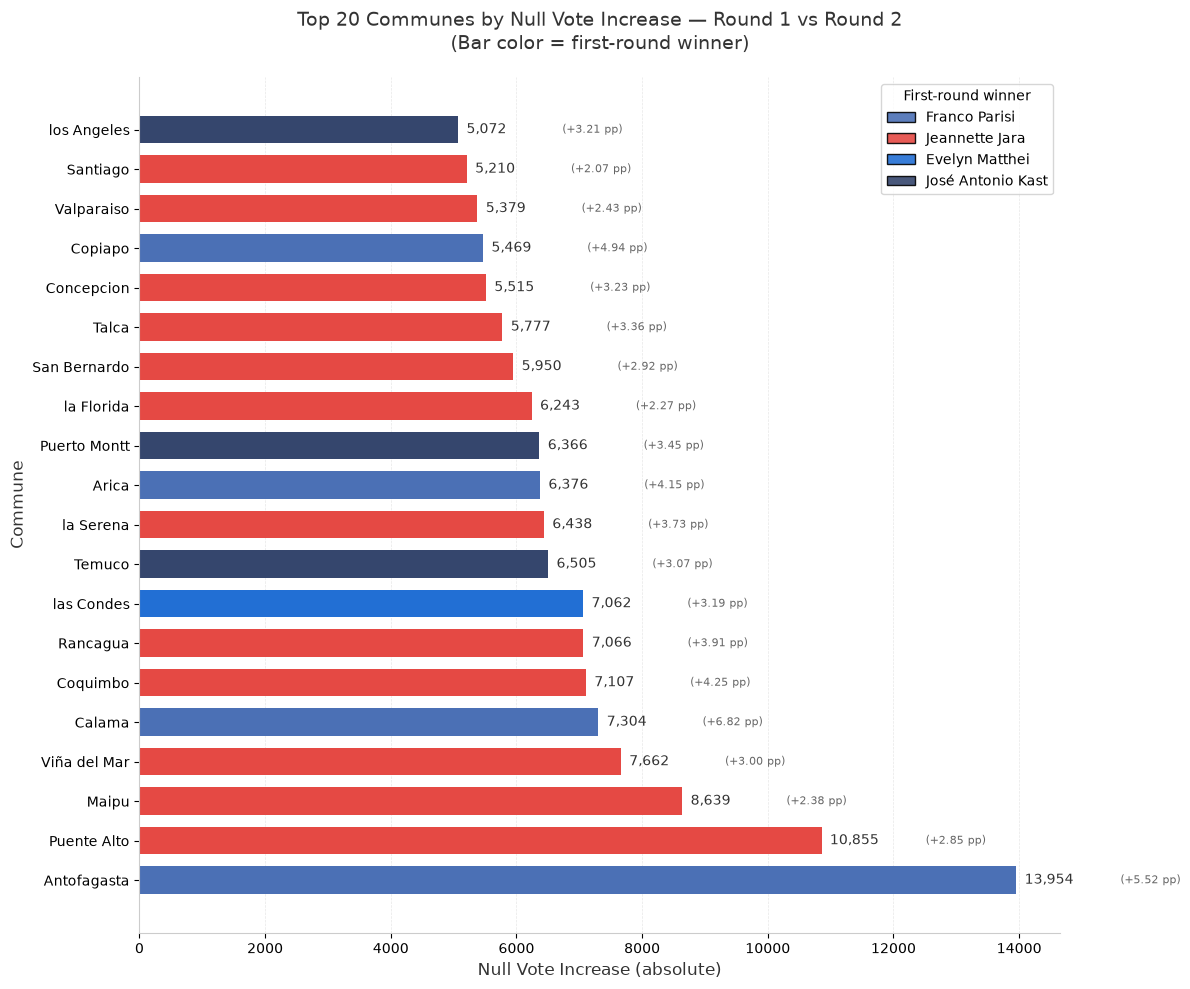

In [626]:
# ============================================================================
# PLOT HELPERS: STYLE, COLOR MAPPING, AND GENERIC BAR CHART
# ============================================================================
# Defines set_clean_style(), WINNER_NAME_MAPPING, CANDIDATE_VOTE_COLS,
# and the parameterised plot_top_protest_increase() and
# plot_protest_distribution_by_winner() used throughout the protest-vote section.
# ============================================================================

def set_clean_style(ax):
    """
    Applies a minimal publication-ready style to an Axes object:
    white background, no top/right spines, muted grid on the value axis.
    """
    ax.set_facecolor('white')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#cccccc')
    ax.spines['bottom'].set_color('#cccccc')
    ax.grid(axis='x', alpha=0.3, linestyle='--', linewidth=0.5, zorder=1)
    return ax

# ============================================================================
# WINNER SHORT-NAME → DISPLAY NAME MAPPING
# ============================================================================

# Maps the abbreviated winner labels produced by idxmax() to the full
# candidate display names used in the color palette (CANDIDATE_COLORS).

WINNER_NAME_MAPPING = {
    'Parisi':            'Franco Parisi',
    'Kast':              'José Antonio Kast',
    'Jara':              'Jeannette Jara',
    'Kaiser':            'Johannes Kaiser',
    'Matthei':           'Evelyn Matthei',
    'Mayne Nicholls':    'Harold Mayne-Nicholls',
    'Enríquez Ominami':  'Marco Enriquez-Ominami',
    'Artes':             'Eduardo Artes',
}

# ============================================================================
# VISUALIZATION: Top-N Communes by Null Vote Increase
# ============================================================================

def plot_top_null_increase(df: pd.DataFrame, top_n: int = 20) -> None:
    """
    Horizontal bar chart of the communes with the largest absolute increase
    in null votes between the first and second round.

    Bar color encodes the first-round winner of each commune.
    Each bar carries two annotations:
      - Absolute null vote increase (bold, offset right of bar tip).
      - Percentage-point change in parentheses (smaller, further right).

    Legend is placed in the upper left to avoid overlap with the longest bars.

    Parameters
    ----------
    df : pd.DataFrame
        Output of analyze_communes_null_increase(), containing at minimum:
        commune, null_votes_increase, null_pct_point_change, first_round_winner.
    top_n : int, optional
        Number of communes to display (default 20).
    """
    from matplotlib.patches import Patch

    plot_df = df.nlargest(top_n, 'null_votes_increase').copy()

    # Resolve full display name and color for each bar
    plot_df['winner_full'] = (
        plot_df['first_round_winner']
        .map(WINNER_NAME_MAPPING)
        .fillna('No data')
    )
    plot_df['color'] = (
        plot_df['winner_full']
        .map(CANDIDATE_COLORS)
        .fillna(CANDIDATE_COLORS['No data'])
    )

    fig, ax = plt.subplots(figsize=(12, 10))
    fig.patch.set_facecolor('white')
    ax = set_clean_style(ax)

    # Bars rendered above the grid (zorder=2)
    bars = ax.barh(
        plot_df['commune'],
        plot_df['null_votes_increase'],
        color=plot_df['color'],
        linewidth=0.8,
        height=0.7,
        zorder=2,
    )

    # Primary annotation: absolute increase
    for bar, value in zip(bars, plot_df['null_votes_increase']):
        ax.annotate(
            f'{value:,.0f}',
            xy=(bar.get_width(), bar.get_y() + bar.get_height() / 2),
            xytext=(6, 0),
            textcoords='offset points',
            ha='left', va='center',
            fontsize=10,
            color='#333333', zorder=3,
        )

    # Secondary annotation: pp change
    for bar, pp_value in zip(bars, plot_df['null_pct_point_change']):
        ax.annotate(
            f'(+{pp_value:.2f} pp)',
            xy=(bar.get_width(), bar.get_y() + bar.get_height() / 2),
            xytext=(75, 0),
            textcoords='offset points',
            ha='left', va='center',
            fontsize=8, color='#666666', zorder=3,
        )

    ax.set_xlabel('Null Vote Increase (absolute)', fontsize=12, color='#333333')
    ax.set_ylabel('Commune', fontsize=12, color='#333333')
    ax.set_title(
        f'Top {top_n} Communes by Null Vote Increase — Round 1 vs Round 2\n'
        '(Bar color = first-round winner)',
        fontsize=14, pad=20, color='#333333',
    )

    # Legend — upper left keeps it clear of the longest bars on the right
    legend_elements = [
        Patch(
            facecolor=CANDIDATE_COLORS.get(WINNER_NAME_MAPPING.get(w, 'No data'), CANDIDATE_COLORS['No data']),
            edgecolor='black',
            label=WINNER_NAME_MAPPING.get(w, w),
            alpha=0.9,
        )
        for w in plot_df['first_round_winner'].unique()
    ]
    ax.legend(
        handles=legend_elements,
        loc='upper right',
        title='First-round winner',
        fontsize=10,
        frameon=True,
        facecolor='white',
        edgecolor='#cccccc',
    )

    plt.tight_layout()
    plt.show()

# Execute
plot_top_null_increase(communes_null_increase, 20)

##### Key Finding

The increase in null voting concentrated in large urban communes, with a dual pattern that distinguishes two types of protest: the anti-establishment north that did not transfer its vote completely to Kast, and Jara's popular strongholds where the ruling coalition failed to mobilise its base.

##### Key Patterns

- **Antofagasta** leads the country (+13,954 null votes), followed by Puente Alto (+10,855), Maipú (+8,639) and Calama (+7,304): four communes of very different profiles, two Parisi mining strongholds and two Jara urban strongholds.
- **Metropolitan Region**: 6 communes in the Top 20 (Puente Alto, Maipú, Las Condes, La Florida, San Bernardo, Santiago). Even in Jara's strongholds, a significant fraction of the electorate opted for active protest.
- **Norte Grande**: Antofagasta, Calama, Arica and Copiapó confirm that Parisi's electorate — dominant in the first round in these communes — was the most disposed to annulling in the second.
- **Political diversity**: the phenomenon affected both Jara's strongholds (Puente Alto, Maipú, Valparaíso, Concepción) and elite communes (Las Condes) and Kast strongholds (Temuco, Los Ángeles), confirming transversal rejection of the final contest.
- **Magnitude**: increases exceed 6,000 votes in most cases, with peaks of +6.82 percentage points in Calama.

##### Interpretation

The null vote was neither a marginal nor a homogeneous phenomenon: it operated as a thermometer of discontent that affected both Jara's demobilised base — particularly in Greater Santiago and Valparaíso — and the anti-establishment electorate of the north that did not find Kast a fully convincing destination. The presence of Las Condes in the ranking also reveals a fracture within the traditional right: a fraction of Matthei's electorate preferred to annul rather than vote for Kast. Taken together, this pattern confirms that the transfer of the protest vote towards the right was substantial but incomplete, which limited — without reversing — Kast's potential for growth in the territories where discontent was most radical.

#### Chart: Top 20 Communes by Relative Null Vote Increase

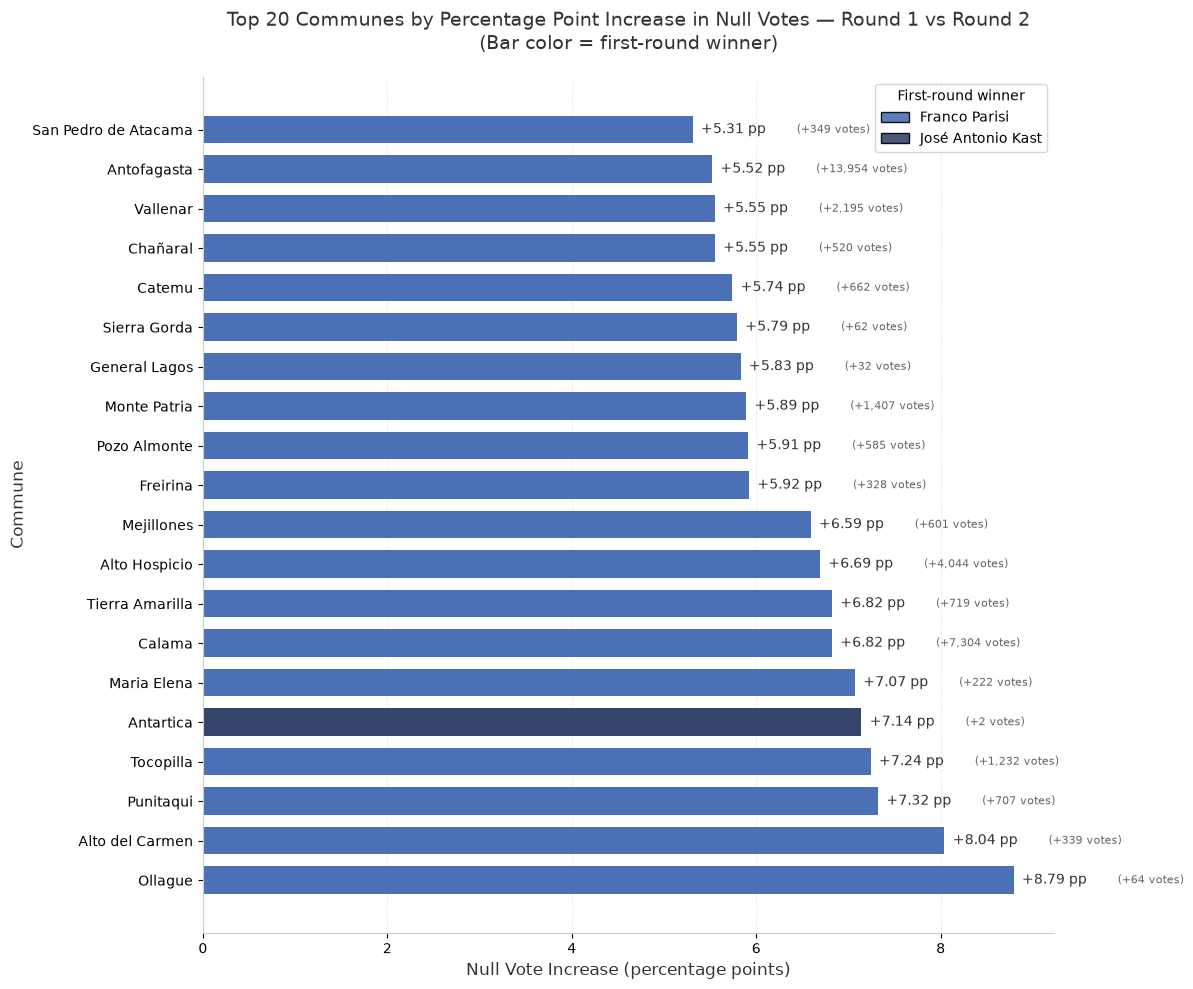

In [627]:
# ============================================================================
# VISUALIZATION: TOP-N COMMUNES BY NULL VOTE INCREASE
# ============================================================================
# Horizontal bar chart of the communes with the largest absolute null vote
# increase between rounds; bar color encodes the first-round winner.
# ============================================================================

def plot_top_pp_increase(df: pd.DataFrame, top_n: int = 20) -> None:
    """
    Horizontal bar chart of the communes with the largest percentage point
    increase in null votes between the first and second round.

    Bar color encodes the first-round winner of each commune.
    Each bar carries two annotations:
      - Percentage point increase (bold, offset right of bar tip).
      - Absolute null vote increase in parentheses (smaller, further right).

    Legend is placed in the lower right to avoid overlap with the bars.

    Parameters
    ----------
    df : pd.DataFrame
        Output of analyze_communes_null_increase(), containing at minimum:
        commune, null_pct_point_change, null_votes_increase, first_round_winner.
    top_n : int, optional
        Number of communes to display (default 20).
    """
    from matplotlib.patches import Patch

    plot_df = df.nlargest(top_n, 'null_pct_point_change').copy()

    # Resolve full display name and color for each bar
    plot_df['winner_full'] = (
        plot_df['first_round_winner']
        .map(WINNER_NAME_MAPPING)
        .fillna('No data')
    )
    plot_df['color'] = (
        plot_df['winner_full']
        .map(CANDIDATE_COLORS)
        .fillna(CANDIDATE_COLORS['No data'])
    )

    fig, ax = plt.subplots(figsize=(12, 10))
    fig.patch.set_facecolor('white')
    ax = set_clean_style(ax)

    # Bars rendered above the grid (zorder=2)
    bars = ax.barh(
        plot_df['commune'],
        plot_df['null_pct_point_change'],
        color=plot_df['color'],
        linewidth=0.8,
        height=0.7,
        zorder=2,
    )

    # Primary annotation: percentage point increase
    for bar, value in zip(bars, plot_df['null_pct_point_change']):
        ax.annotate(
            f'+{value:.2f} pp',
            xy=(bar.get_width(), bar.get_y() + bar.get_height() / 2),
            xytext=(6, 0),
            textcoords='offset points',
            ha='left', va='center',
            fontsize=10,
            color='#333333', zorder=3,
        )

    # Secondary annotation: absolute increase
    for bar, abs_value in zip(bars, plot_df['null_votes_increase']):
        ax.annotate(
            f'({abs_value:+,.0f} votes)',
            xy=(bar.get_width(), bar.get_y() + bar.get_height() / 2),
            xytext=(75, 0),
            textcoords='offset points',
            ha='left', va='center',
            fontsize=8, color='#666666', zorder=3,
        )

    ax.set_xlabel('Null Vote Increase (percentage points)', fontsize=12, color='#333333')
    ax.set_ylabel('Commune', fontsize=12, color='#333333')
    ax.set_title(
        f'Top {top_n} Communes by Percentage Point Increase in Null Votes — Round 1 vs Round 2\n'
        '(Bar color = first-round winner)',
        fontsize=14, pad=20, color='#333333',
    )

    # Legend — lower right keeps it clear of the bars
    legend_elements = [
        Patch(
            facecolor=CANDIDATE_COLORS.get(WINNER_NAME_MAPPING.get(w, 'No data'), CANDIDATE_COLORS['No data']),
            edgecolor='black',
            label=WINNER_NAME_MAPPING.get(w, w),
            alpha=0.9,
        )
        for w in plot_df['first_round_winner'].unique()
    ]
    ax.legend(
        handles=legend_elements,
        loc='upper right',
        title='First-round winner',
        fontsize=10,
        frameon=True,
        facecolor='white',
        edgecolor='#cccccc',
    )

    plt.tight_layout()
    plt.show()

# Execute
plot_top_pp_increase(communes_null_increase, 20)

##### Key Finding

The relative increase reveals a map completely different from that of absolute volume: small, mining and border communes of the Norte Grande predominate, where Franco Parisi's electorate expressed its rejection of the final contest with the country's highest proportional intensity.

##### Key Patterns

- **18 of the 20 communes** with the largest percentage increase were won by Parisi in the first round: the anti-establishment north's dominance of this ranking is near-absolute.
- **Extreme communes lead the list**: Ollagüe (+8.79 pp), Alto del Carmen (+8.04 pp), Punitaqui (+7.32 pp) and Tocopilla (+7.24 pp), all territories of low population density, high mining dependence and strong perception of state abandonment.
- **Contrast with absolute volume**: while the absolute increase concentrated in large cities such as Antofagasta and Puente Alto, the relative increase shows that the intensity of rejection was greater in the most isolated and smallest northern communes. Ollagüe, with just +64 additional null votes, illustrates that the protest ran deep even where its numerical impact was limited.
- **Atypical case**: Antártica (+7.14 pp) appears in the ranking, but its minimal population renders it electorally inconsequential.

##### Interpretation

The disparity between the absolute and relative rankings reveals two distinct dimensions of the protest: the volume of discontent in large cities, and the intensity of rejection in the most radical bastions of the northern anti-establishment. In communes such as Ollagüe and Alto del Carmen, where Parisi had exceeded 40% in the first round, Partido de la Gente's call to vote null found its most potent echo. Kast, while winning these communes comfortably in valid votes, did not absorb that electorate completely: a significant fraction preferred active protest over validating the runoff, confirming that the transfer of the Parisi vote towards the right, though substantial in aggregate terms, was incomplete in the territories where anti-establishment discontent was most radical.

#### Null Vote Increase by First-Round Winner

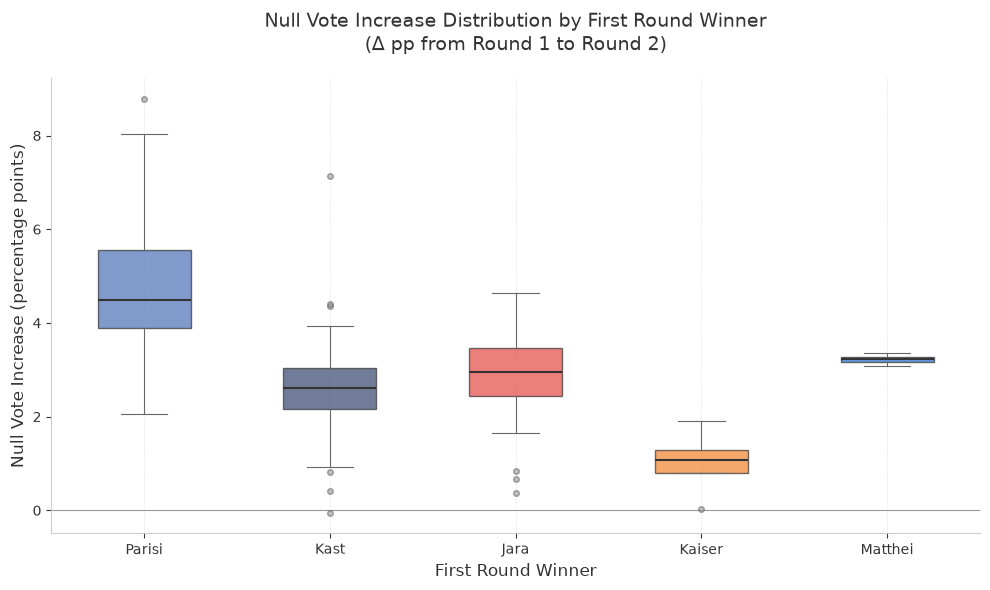

In [628]:
# ============================================================================
# VISUALIZATION: NULL VOTE INCREASE DISTRIBUTION BY FIRST-ROUND WINNER
# ============================================================================
# Box plot comparing the distribution of null vote percentage-point changes
# across communes grouped by their first-round winner.
# ============================================================================

def plot_null_increase_by_winner(df: pd.DataFrame) -> None:
    """
    Box plot showing the distribution of percentage point increase in null votes,
    grouped by the winner of the first round in each commune.

    Only includes candidates with sufficient commune representation to ensure
    meaningful distributions.

    Parameters
    ----------
    df : pd.DataFrame
        Output of analyze_communes_null_increase(), containing at minimum:
        commune, null_pct_point_change, first_round_winner.
    """
    fig, ax = plt.subplots(figsize=(10, 6))
    fig.patch.set_facecolor('white')
    ax = set_clean_style(ax)

    # Filter top winners (exclude candidates with few communes)
    top_winners = ['Parisi', 'Kast', 'Jara', 'Kaiser', 'Matthei']
    plot_df = df[df['first_round_winner'].isin(top_winners)].copy()

    # Prepare data for box plots
    box_data = [
        plot_df[plot_df['first_round_winner'] == winner]['null_pct_point_change']
        for winner in top_winners
    ]

    # Create box plot with custom styling
    boxes = ax.boxplot(
        box_data,
        patch_artist=True,
        medianprops={'color': '#333333', 'linewidth': 1.5},
        whiskerprops={'color': '#666666', 'linewidth': 0.8},
        capprops={'color': '#666666', 'linewidth': 0.8},
        flierprops={
            'marker': 'o',
            'markerfacecolor': '#999999',
            'markeredgecolor': '#666666',
            'markersize': 4,
            'alpha': 0.6
        }
    )

    # Set the x-axis labels after creating the boxplot
    ax.set_xticklabels(top_winners)

    # Color each box consistently with candidate colors
    for box, winner in zip(boxes['boxes'], top_winners):
        full_name = WINNER_NAME_MAPPING.get(winner, winner)
        color = CANDIDATE_COLORS.get(full_name, CANDIDATE_COLORS.get('No data', '#dddddd'))
        box.set_facecolor(color)
        box.set_alpha(0.7)
        box.set_edgecolor('#333333')
        box.set_linewidth(1)

    # Add horizontal line at zero
    ax.axhline(y=0, color='#333333', linestyle='-', linewidth=0.8, alpha=0.5, zorder=1)

    # Labels and title
    ax.set_xlabel('First Round Winner', fontsize=12, color='#333333')
    ax.set_ylabel('Null Vote Increase (percentage points)', fontsize=12, color='#333333')
    ax.set_title(
        'Null Vote Increase Distribution by First Round Winner\n'
        '(Δ pp from Round 1 to Round 2)',
        fontsize=14, pad=20, color='#333333'
    )

    # Style adjustments
    ax.tick_params(axis='both', colors='#333333', labelsize=10)

    plt.tight_layout()
    plt.show()

# Execute
plot_null_increase_by_winner(communes_null_increase)

##### Key Finding

Segmentation by first-round winner reveals clear and significant differences in null vote behaviour. Voters from Franco Parisi's communes showed the largest increase in null voting in the second round, both in median and dispersion, confirming that the anti-establishment electorate was the principal contributor to active protest.

##### Interpretation by Candidate

- **Parisi** (median ~4.5 pp, range 2.0–8.0+): greatest rejection of the final contest. His communes show the highest dispersion, reflecting the heterogeneity of the anti-establishment electorate, from territories with near-complete transfer to Kast to others with radical protest.
- **Jara** (median ~3.0 pp, range 2.0–4.5): demobilisation in left-wing strongholds. The moderate-to-high increase suggests that part of her base did not feel sufficiently motivated to support her in the second round, particularly in working-class communes of Greater Santiago.
- **Matthei** (median ~3.3 pp, concentrated distribution): the traditional right showed the lowest variability, indicating more disciplined and predictable behaviour than other blocs.
- **Kast** (median ~2.7 pp, range 1.0–4.0): moderate consolidation of his electorate; the more controlled increase suggests his base was the most loyal and the least prone to protest.
- **Kaiser** (median ~1.2 pp, range 0.5–2.0): the lowest level of null voting confirms that the libertarian electorate transferred massively to Kast in the runoff.

##### Strategic Conclusions

The null vote was not a homogeneous phenomenon but reflected differentiated political dynamics according to electoral origin. Parisi was the primary source of active protest, with the largest and most dispersed increase; Jara suffered demobilisation in her strongholds, although to a lesser degree; Kast, in contrast, consolidated his base with the most moderate increase, while Matthei and Kaiser showed disciplined behaviour that facilitated the transfer towards the conservative right. The pattern confirms that the transfer of the Parisi vote was substantial but incomplete, and that Partido de la Gente's call to vote null found its most potent echo in the territories where anti-establishment sentiment was most radical.

#### Conclusion: 4.3.

Commune-level analysis of the null vote reveals a dual map of electoral discontent. In the Norte Grande, the phenomenon was primarily anti-establishment protest driven by Partido de la Gente's call, with particular intensity in mining communes where support for Franco Parisi had been strongest. In the large cities, by contrast, the null vote operated as a thermometer of demobilisation within Jeannette Jara's electorate — even in her traditional strongholds — reflecting the erosion of the ruling coalition and its difficulty in mobilising its own base at the decisive moment. Both expressions, though different in nature — active protest in the north, disenchantment in the cities — share a common denominator: distrust of the traditional political system and rejection of a binary offer that failed to engage a significant fraction of the electorate.

### Chapter 4 Conclusion: The Null Vote

The null vote consolidated in the 2025 runoff as the primary expression of citizen discontent, with particular intensity in the Norte Grande, where Franco Parisi's electorate opted predominantly for active protest rather than validating a binary offer that did not engage it. The evidence reveals a dual pattern: in volume, discontent concentrated in large urban centres — especially the Metropolitan Region and Valparaíso — where even in Jara's strongholds a significant fraction of the electorate preferred to annul rather than ratify their candidate; in intensity, the rejection ran deeper in small, mining and border communes of the north, where Parisi had been dominant and where the PDG's call found its most potent echo.

This duality — volume in the large cities, intensity in the northern mining belt — reveals that the null vote operated as a thermometer of discontent that affected both Jara's demobilised base and the anti-establishment electorate that did not find Kast a fully convincing destination. The presence of elite communes such as Las Condes in the ranking also confirms that the phenomenon was not exclusive to working-class or anti-establishment sectors: it also reflected fractures within the traditional right, where a fraction of Matthei's electorate preferred to annul rather than vote for Kast. Taken together, this pattern shows that the transfer of the protest vote towards the right was substantial but incomplete: although Kast captured the majority of Parisi's communes in valid votes, a significant fraction of that electorate opted for active protest, which circumscribed — without preventing — his growth in the territories where anti-establishment discontent was most radical.

The challenge left by this chapter extends beyond the incoming government: reconnecting with an electorate that has incorporated the null vote as a habitual tool of political expression, particularly in the northern mining belt and in urban peripheries where distrust of the traditional political system is deepest. The magnitude of the phenomenon — nearly 800,000 null votes, the highest level recorded in a presidential election since the return to democracy — suggests that citizen discontent is not a conjunctural problem, but a feature that the political system must address beyond the change of occupant at La Moneda.

---

## 5. The Blank Vote: A Protest of a Different Kind

### Introduction

Unlike the null vote, which recorded a generalised and pronounced increase in all regions, the blank vote showed more moderate and territorially heterogeneous growth. The blank vote is typically interpreted as a more passive form of discontent — a "none of the above" expression — and in this election it displayed qualitatively different behaviour from the null: while the null had its epicentre in the northern mining belt and in working-class communes, the blank concentrated primarily in the Metropolitan Region, particularly in high-income communes and in the traditional right-wing strongholds of Evelyn Matthei. This duality suggests that the electorate channelled its discontent through differentiated mechanisms according to sociodemographic profile: the blank as moderate rejection in urban and elite zones, the null as active and confrontational protest in territories where distrust of the system runs deepest.

### 5.1. Blank Vote by Region

The regional distribution confirms that, while both null and blank votes increased relative to the first round, their territorial behaviour was qualitatively distinct. While the null reflects an active and confrontational protest, frequently associated with explicit rejection of the political system, the blank is typically interpreted as a more passive form of discontent, not necessarily implying a militant rejection of the electoral process as such. The following table disaggregates regional variation for the blank vote.

In [629]:
# ============================================================================
# BLANK VOTE CHANGE BY REGION — FIRST ROUND VS SECOND ROUND 2025
# ============================================================================
# Aggregates blank votes by region across both rounds and ranks regions by
# absolute and percentage-point change, distinguishing increases from decreases.
# ============================================================================

def analyze_blank_votes_by_region(df1: pd.DataFrame, df2: pd.DataFrame) -> pd.DataFrame:
    """
    Calculates blank vote metrics by region and compares first vs second round.
    
    Parameters
    ----------
    df1 : pd.DataFrame
        First round data with columns: region, commune, blank_votes, casted_votes
    df2 : pd.DataFrame
        Second round data with columns: region, commune, blank_votes, casted_votes
    
    Returns
    -------
    pd.DataFrame
        DataFrame with region-level blank vote statistics and trend
    """
    # Aggregate first round by region
    first_round_agg = df1.groupby('region').agg({
        'blank_votes': 'sum',
        'casted_votes': 'sum'
    }).reset_index()
    first_round_agg.columns = ['region', 'blank_votes_first_round', 'total_votes_first_round']
    first_round_agg['blank_pct_first_round'] = round(
        100.0 * first_round_agg['blank_votes_first_round'] / first_round_agg['total_votes_first_round'], 2
    )
    
    # Aggregate second round by region
    second_round_agg = df2.groupby('region').agg({
        'blank_votes': 'sum',
        'casted_votes': 'sum'
    }).reset_index()
    second_round_agg.columns = ['region', 'blank_votes_second_round', 'total_votes_second_round']
    second_round_agg['blank_pct_second_round'] = round(
        100.0 * second_round_agg['blank_votes_second_round'] / second_round_agg['total_votes_second_round'], 2
    )
    
    # Merge both rounds
    result = pd.merge(first_round_agg, second_round_agg, on='region', how='inner')
    
    # Calculate changes
    result['blank_votes_change'] = result['blank_votes_second_round'] - result['blank_votes_first_round']
    result['blank_pct_point_change'] = round(
        result['blank_pct_second_round'] - result['blank_pct_first_round'], 2
    )
    
    # Add trend column
    result['trend'] = result['blank_votes_change'].apply(
        lambda x: 'INCREASE' if x > 0 else ('DECREASE' if x < 0 else 'NO CHANGE')
    )
    
    # Sort by absolute change descending
    result = result.sort_values('blank_votes_change', ascending=False)
    
    # Format columns
    result['blank_votes_first_round'] = result['blank_votes_first_round'].astype(int)
    result['blank_votes_second_round'] = result['blank_votes_second_round'].astype(int)
    result['blank_votes_change'] = result['blank_votes_change'].astype(int)
    
    # Select and order columns
    result = result[[
        'region',
        'blank_votes_first_round',
        'blank_votes_second_round',
        'blank_votes_change',
        'blank_pct_first_round',
        'blank_pct_second_round',
        'blank_pct_point_change',
        'trend'
    ]]
    
    return result

# Execute analysis
blank_votes_by_region = analyze_blank_votes_by_region(df_2025_v1, df_2025_v2)
blank_votes_by_region

,region,blank_votes_first_round,blank_votes_second_round,blank_votes_change,blank_pct_first_round,blank_pct_second_round,blank_pct_point_change,trend
12,Metropolitana,46698,62372,15674,0.90,1.21,0.31,INCREASE
4,Biobío,12093,15359,3266,0.99,1.26,0.27,INCREASE
14,Valparaíso,16576,18973,2397,1.14,1.31,0.17,INCREASE
0,Antofagasta,4567,5853,1286,1.11,1.44,0.33,INCREASE
7,Libertador,8403,9565,1162,1.11,1.26,0.15,INCREASE
5,Coquimbo,8150,8811,661,1.39,1.51,0.12,INCREASE
9,Los Ríos,3334,3745,411,1.06,1.20,0.14,INCREASE
2,Atacama,2749,3080,331,1.31,1.47,0.16,INCREASE
13,Tarapacá,2179,2494,315,1.02,1.18,0.16,INCREASE
1,Arica y Parinacota,1731,1871,140,1.10,1.19,0.09,INCREASE


#### Analysis

##### A Far More Moderate Behaviour than the Null Vote

The blank vote increased in 11 of the country's 16 regions, but considerably more moderately than the null vote: increases in percentage points ranged from +0.09 pp (Arica y Parinacota) to +0.33 pp (Antofagasta), far below the increases of between +2.07 pp and +5.96 pp observed for the null. The Metropolitan Region led the absolute increase (+15,674 votes, +0.31 pp), followed by Biobío (+3,266, +0.27 pp) and Valparaíso (+2,397, +0.17 pp). The pattern confirms that the blank vote — unlike the null, whose epicentre was the north — concentrated in urban and densely populated zones, where the electorate opted for a less radicalised form of protest.

The most relevant finding in the regional analysis is the decrease in the blank vote in five centre-south regions: Maule (−1,308 votes, −0.15 pp), La Araucanía (−504, −0.06 pp), Ñuble (−409, −0.09 pp), Los Lagos (−295, −0.04 pp) and Aysén (−202, −0.28 pp). This behaviour contrasts with that of the null vote, which increased in all these regions without exception. The most plausible explanation is that, in these zones, voters discontented with the final runoff channelled their rejection preferentially through the null vote — a more visible form of protest — rather than through the blank, which may be perceived as a more ambiguous option.

##### The Symbolic Significance of the Distinction

Chilean electoral law considers both the null and the blank vote as invalid ballots, with no bearing on the final result, as percentages are calculated on the basis of total valid votes. Their symbolic significance, however, differs: the blank vote is typically read as discontent with the available electoral offer, without necessarily implying a rejection of the political system as a whole.

That the blank vote increased primarily in urban zones — particularly the Metropolitan Region — suggests that, in these territories, discontent was expressed in a more institutional manner. It is plausible that urban voters, with greater access to political information, resort more frequently to the blank vote as a form of protest that does not entail total rejection of the electoral process, while in centre-south regions where the blank declined, discontent was channelled towards the null, read as a more confrontational option.

##### The North and the Combined Invalidation Pattern

Antofagasta stands out as the region with the largest relative increase in blank voting (+0.33 pp), reaching 1.44% in the second round. Though modest in absolute terms, this increase is part of a broader pattern: the Norte Grande not only led the increase in null voting but also recorded the highest percentages of combined invalid votes overall. According to Servel data, Antofagasta reached 10.5% of combined null and blank votes, followed by Atacama (9.5%), Coquimbo (8.8%), Arica y Parinacota (8.5%) and Tarapacá (8.2%). The behaviour reinforces the hypothesis that the northern electorate — where support for Franco Parisi had been strongest — opted more extensively for ballot invalidation, whether through null or, to a lesser extent, blank voting.

At the national level, null and blank votes reached 7.1% of the total in the second round, a figure below Partido de la Gente's initial projections, but the highest recorded in a presidential election in the past 35 years, above the 5.53% observed in the 1993 elections. The contrast is even more marked compared with 2021, when under voluntary voting null and blank votes in the second round barely reached 1.1% of the total. The jump from 1.1% to 7.1% in four years evidences the impact of the return to compulsory voting on the composition and behaviour of the electorate.

#### Conclusion 5.1.

The blank vote behaved as a territorially heterogeneous phenomenon that complements — and in some cases contrasts with — the pattern observed for the null vote. While the null increased in all regions, the blank grew moderately in 11 and declined in 5 of the centre-south, where discontent was channelled preferentially towards active protest. This duality suggests that the electorate resorts to different forms of ballot invalidation according to its perception of the political system: the blank as an expression of passive discontent in urban zones, the null as a more confrontational rejection in territories where distrust runs deepest. Taken together, the increase in both types of invalid vote — from 3.7% in the first round to 7.1% in the second — confirms that a relevant fraction of the electorate did not find full representation in the final runoff contest, a phenomenon that particularly affected northern regions and poses, for the party system as a whole, the challenge of reconnecting with an increasingly discontented electorate.

### 5.2. Blank Vote by Geographic Macrozone

The macrozonal disaggregation confirms the moderate and heterogeneous behaviour of the blank vote: it grew in five of the six zones, but with very disparate intensities — from +0.23 pp in the Norte Grande to just +0.01 pp in the South — and recorded a slight decline in Patagonia (−0.03 pp). This pattern reinforces the reading that the blank vote operated as a channel of more passive discontent, concentrated in urban zones, while in centre-south regions rejection was channelled preferentially through the null vote.

In [630]:
# ============================================================================
# BLANK VOTE CHANGE BY GEOGRAPHIC ZONE (MACROZONE) — ROUND 1 VS ROUND 2
# ============================================================================
# Groups communes by macrozone and computes aggregate blank vote shifts;
# symmetric to the null vote zone analysis for cross-protest-type comparison.
# ============================================================================

def analyze_blank_votes_by_zone(df1: pd.DataFrame, df2: pd.DataFrame, df_zone: pd.DataFrame) -> pd.DataFrame:
    """
    Calculates blank vote metrics by geographic zone (Norte Grande, Centro, Sur, etc.)
    
    Parameters
    ----------
    df1 : pd.DataFrame
        First round data with columns: region, blank_votes, casted_votes
    df2 : pd.DataFrame
        Second round data with columns: region, blank_votes, casted_votes
    df_zone : pd.DataFrame
        Region dimension with columns: region, macrozone, macrozone_order
    
    Returns
    -------
    pd.DataFrame
        DataFrame with zone-level blank vote statistics
    """
    # Merge region dimension to first round
    df1_with_zone = df1.merge(df_zone[['region', 'macrozone', 'macrozone_order']], on='region', how='left')
    
    # Merge region dimension to second round
    df2_with_zone = df2.merge(df_zone[['region', 'macrozone', 'macrozone_order']], on='region', how='left')
    
    # Aggregate first round by zone
    first_zone_agg = df1_with_zone.groupby('macrozone').agg({
        'blank_votes': 'sum',
        'casted_votes': 'sum',
        'macrozone_order': 'first'
    }).reset_index()
    first_zone_agg.columns = ['macrozone', 'blank_votes_first_round', 'total_votes_first_round', 'macrozone_order']
    first_zone_agg['blank_pct_first_round'] = round(
        100.0 * first_zone_agg['blank_votes_first_round'] / first_zone_agg['total_votes_first_round'], 2
    )
    
    # Aggregate second round by zone
    second_zone_agg = df2_with_zone.groupby('macrozone').agg({
        'blank_votes': 'sum',
        'casted_votes': 'sum'
    }).reset_index()
    second_zone_agg.columns = ['macrozone', 'blank_votes_second_round', 'total_votes_second_round']
    second_zone_agg['blank_pct_second_round'] = round(
        100.0 * second_zone_agg['blank_votes_second_round'] / second_zone_agg['total_votes_second_round'], 2
    )
    
    # Merge both rounds
    result = pd.merge(first_zone_agg, second_zone_agg, on='macrozone', how='inner')
    
    # Calculate changes
    result['blank_votes_change'] = result['blank_votes_second_round'] - result['blank_votes_first_round']
    result['blank_pct_point_change'] = round(
        result['blank_pct_second_round'] - result['blank_pct_first_round'], 2
    )
    
    # Sort by macrozone order (north to south)
    result = result.sort_values('macrozone_order')
    
    # Select and order columns
    result = result[[
        'macrozone',
        'blank_votes_first_round',
        'blank_votes_second_round',
        'blank_votes_change',
        'blank_pct_first_round',
        'blank_pct_second_round',
        'blank_pct_point_change'
    ]]
    
    return result

# Execute analysis by zone
blank_votes_by_zone = analyze_blank_votes_by_zone(df_2025_v1, df_2025_v2, df_region_dim)
blank_votes_by_zone

,macrozone,blank_votes_first_round,blank_votes_second_round,blank_votes_change,blank_pct_first_round,blank_pct_second_round,blank_pct_point_change
3,Norte Grande,8477,10218,1741,1.09,1.32,0.23
2,Norte Chico,10899,11891,992,1.37,1.50,0.13
0,Centro,81626,99551,17925,0.99,1.21,0.22
1,Centro Sur,25430,27783,2353,1.06,1.16,0.10
5,Sur,12606,12722,116,1.28,1.29,0.01
4,Patagonia,2918,2838,-80,1.49,1.46,-0.03


#### Analysis

##### Macrozonal Distribution

The blank vote grew in all zones except Patagonia, but with an intensity markedly lower than that of the null. The Norte Grande led the relative increase at +0.23 pp (reaching 1.32%), followed by the Centre at +0.22 pp (1.21%) and Norte Chico at +0.13 pp (1.50%). The Centre-South (+0.10 pp) and South (+0.01 pp) recorded the most moderate increases, while Patagonia experienced a decline of −0.03 pp (from 1.49% to 1.46%). This last behaviour — which contrasts with the null vote, rising in all macrozones without exception — suggests that in some southern territories discontented voters preferred to channel their rejection through the null vote, a more visible form of protest.

##### The Magnitude Gap Between Null and Blank

The most telling finding of the macrozonal analysis is the difference in magnitude between the two types of invalidation. While the null vote increased by an average of 3.4 percentage points across all zones — with peaks of +5.22 pp in the Norte Grande — the blank barely exceeded +0.20 pp in the same zone. This disparity confirms that the electorate discontented with the final runoff opted predominantly for more visible forms of protest over the simple omission of a preference.

The distinction carries a relevant symbolic correlate: the null vote — which occurs when the voter marks more than one preference or the voting intention is ambiguous — is typically read as a more active expression of rejection, while the blank vote — a ballot with no mark — is interpreted as a more passive form of discontent. In the Norte Grande, where protest was most intense, the blank also showed a more pronounced increase (+0.23 pp), suggesting that a fraction of the Parisista electorate opted for passive protest rather than active protest. In the Centre, where the null was more moderate in relative terms, the blank also grew significantly (+0.22 pp), reflecting a more institutionalised form of discontent in urban zones.

##### Migration towards the Null Vote in Patagonia and the Centre-South

The decrease in the blank vote in Patagonia (−0.03 pp) constitutes an anomaly that merits attention. This zone, which had recorded the highest percentage of blank votes in the first round (1.49%), experienced a decline in the second round while the null vote rose by +2.77 pp, suggesting that voters who had initially expressed their discontent through the blank migrated towards the null in the definitive round. This phenomenon was not exclusive to Patagonia: as documented in the regional analysis, five centre-south regions — Maule, La Araucanía, Ñuble, Los Lagos and Aysén — recorded declines in the blank while the null increased significantly, suggesting that the southern electorate, faced with an unsatisfactory binary offer, preferred more active and visible forms of protest.

##### National Context

At the national level, null and blank votes reached 7.1% of total votes in the second round, the highest figure recorded in a presidential election in the past 35 years, compared with the 1.1% observed in 2021 under voluntary voting. As the Servel president Andrés Tagle noted, "the null vote is not counted at all, the same as the blank vote. It has no effect in terms of the positions being elected," underscoring the symbolic character of these forms of invalidation, without prejudice to their value as indicators of citizen discontent. That the blank vote increased in urban zones while declining in the south suggests that discontent is expressed in a territorially differentiated manner: more institutional in large urban centres, more confrontational in the south and Patagonia.

#### Conclusion 5.2.

The blank vote behaved as a territorially differentiated phenomenon that complements — and in some cases contrasts with — the pattern observed for the null vote. While the null increased markedly in all macrozones, the blank grew moderately in five zones and declined in Patagonia, where the electorate opted preferentially for active protest. This duality confirms that the electorate uses different forms of ballot invalidation depending on its perception of the political system: the blank as an expression of passive discontent in urban zones, the null as a more confrontational rejection in territories where distrust runs deepest. Taken together, the increase in both types of invalid vote confirms that a relevant fraction of the electorate did not find full representation in the Jara–Kast contest, posing a fundamental challenge for parties' capacity to reconnect with an increasingly discontented electorate.

### 5.3. Blank Vote by Commune: The 20 Cities with the Largest Increase

The communal analysis contrasts sharply with that observed for the null vote. While the null had its epicentre in the northern mining belt and in working-class communes — territories where Franco Parisi's electorate opted for active protest — the blank vote concentrated primarily in the Metropolitan Region, particularly in high and upper-middle income communes, with a clear predominance of Evelyn Matthei's strongholds. This behaviour suggests that the blank operated as a channel of more passive discontent, used by sectors of the traditional right who, without feeling fully represented by José Antonio Kast, opted for ballot invalidation rather than supporting him or migrating to the ruling-coalition option.

In [631]:
# ============================================================================
# COMMUNES WITH HIGHEST BLANK VOTE INCREASE — ABSOLUTE AND RELATIVE
# ============================================================================
# Derives commune-level blank vote deltas between rounds, appends first-round
# winner, and returns a ranked dataset for downstream visualisation.
# ============================================================================

def analyze_communes_blank_increase(df1: pd.DataFrame, df2: pd.DataFrame) -> pd.DataFrame:
    """
    Identifies communes with largest absolute and percentage increase in blank votes.
    Includes first round winner and vote metrics.
    """
    
    # Define candidate columns for first round
    candidate_cols = ['jara_votes', 'kast_votes', 'parisi_votes', 'kaiser_votes', 
                      'matthei_votes', 'mayne_nicholls_votes', 'enriquez_ominami_votes', 
                      'artes_votes']
    candidate_names = ['Jara', 'Kast', 'Parisi', 'Kaiser', 'Matthei', 
                       'Mayne Nicholls', 'Enríquez Ominami', 'Artes']
    
    # Calculate first round winner for each commune
    df1_winner = df1.copy()
    
    # Find the candidate with most votes
    df1_winner['first_round_winner'] = df1_winner[candidate_cols].idxmax(axis=1)
    
    # Map column names to candidate names
    winner_mapping = dict(zip(candidate_cols, candidate_names))
    df1_winner['first_round_winner'] = df1_winner['first_round_winner'].map(winner_mapping)
    
    # Calculate first round valid votes (total - null - blank)
    df1_winner['valid_votes_first_round'] = (
        df1_winner['casted_votes'] - df1_winner['null_votes'] - df1_winner['blank_votes']
    )
    
    # Rename columns in df1_winner to avoid conflicts
    df1_winner = df1_winner.rename(columns={
        'null_votes': 'null_votes_1v',
        'blank_votes': 'blank_votes_1v',
        'casted_votes': 'casted_votes_1v'
    })
    
    # Rename columns in df2
    df2_renamed = df2.rename(columns={
        'null_votes': 'null_votes_2v',
        'blank_votes': 'blank_votes_2v',
        'casted_votes': 'casted_votes_2v'
    })
    
    # Merge with second round data
    result = df1_winner.merge(
        df2_renamed[['commune', 'region', 'null_votes_2v', 'blank_votes_2v', 'casted_votes_2v']], 
        on=['commune', 'region'], 
        how='inner'
    )
    
    # Calculate metrics
    result['blank_votes_increase'] = result['blank_votes_2v'] - result['blank_votes_1v']
    result['blank_pct_1v'] = round(100.0 * result['blank_votes_1v'] / result['casted_votes_1v'], 2)
    result['blank_pct_2v'] = round(100.0 * result['blank_votes_2v'] / result['casted_votes_2v'], 2)
    result['blank_pct_point_change'] = round(result['blank_pct_2v'] - result['blank_pct_1v'], 2)
    result['valid_votes_1v'] = result['valid_votes_first_round']
    result['valid_votes_2v'] = result['casted_votes_2v'] - result['null_votes_2v'] - result['blank_votes_2v']
    
    # Select relevant columns
    result = result[[
        'commune', 'region',
        'valid_votes_1v', 'valid_votes_2v',
        'blank_votes_1v', 'blank_votes_2v', 'blank_votes_increase',
        'blank_pct_1v', 'blank_pct_2v', 'blank_pct_point_change',
        'first_round_winner'
    ]]
    
    return result

# Execute analysis
communes_blank_increase = analyze_communes_blank_increase(df_2025_v1, df_2025_v2)

# Show top 20 communes with highest blank vote increase
top_20_blank_increase = communes_blank_increase.nlargest(20, 'blank_votes_increase')
top_20_blank_increase

,commune,region,valid_votes_1v,valid_votes_2v,blank_votes_1v,blank_votes_2v,blank_votes_increase,blank_pct_1v,blank_pct_2v,blank_pct_point_change,first_round_winner
278,las Condes,Metropolitana,218939,208531,1004,3405,2401,0.45,1.54,1.09,Matthei
256,Providencia,Metropolitana,121106,114679,715,2690,1975,0.58,2.18,1.60,Matthei
279,ÑUñoa,Metropolitana,178903,171731,1136,3100,1964,0.62,1.70,1.08,Jara
247,Maipu,Metropolitana,350723,340831,2811,4105,1294,0.77,1.13,0.36,Jara
274,la Florida,Metropolitana,266625,258879,2316,3394,1078,0.84,1.23,0.39,Jara
277,la Reina,Metropolitana,73846,70473,521,1467,946,0.69,1.94,1.25,Matthei
269,Santiago,Metropolitana,244922,238328,2341,3278,937,0.93,1.30,0.37,Jara
38,Concepcion,Biobío,165767,158957,1363,2248,885,0.80,1.32,0.52,Jara
0,Antofagasta,Antofagasta,244833,227874,3014,3884,870,1.18,1.53,0.35,Parisi
272,Vitacura,Metropolitana,69419,66462,258,1069,811,0.37,1.52,1.15,Matthei


#### Analysis

##### Eastern Santiago and the Matthei Electorate

The most telling datum of the communal analysis is the over-representation of the Metropolitan Region in the absolute increase ranking: eight of the fifteen communes with the largest increase belong to it, and among them Evelyn Matthei's strongholds stand out: Las Condes (+2,401 votes, +1.09 pp), Providencia (+1,975, +1.60 pp), La Reina (+946, +1.25 pp) and Vitacura (+811, +1.15 pp). These communes, won by Matthei in the first round, recorded relative blank vote increases well above the national average.

The phenomenon carries a strategic reading: the traditional right faced in the runoff the dilemma of supporting a Partido Republicano candidate with whom it did not necessarily share full ideological affinity, or declining to do so actively. The evidence suggests that a fraction of Matthei's electorate — particularly in the highest-income communes — opted for the blank vote as a form of passive protest rather than validating Kast's candidacy.

##### The Blank Vote Also in Jara's Strongholds

The phenomenon was not exclusive to the traditional right. Communes such as Ñuñoa (+1,964 votes, +1.08 pp), Maipú (+1,294, +0.36 pp) and La Florida (+1,078, +0.39 pp), all won by Jara in the first round, also recorded significant increases. The case of Ñuñoa — traditionally a centre-left commune with a young and educated electorate — is illustrative: it recorded the third largest absolute increase in the country (+1,964) and a relative increase of +1.08 pp, well above the national average, suggesting that even in ruling-coalition strongholds a fraction of the electorate opted for passive protest over the useful vote.

##### Two Typologies of Protest

Comparison between the null and blank patterns permits the identification of two differentiated typologies. While the null concentrated in the northern mining belt and in working-class communes of the Metropolitan Region, the blank had a more urban and higher socioeconomic character, concentrated in eastern Santiago. This suggests that Parisi's electorate — predominantly male, under 45, middle class and with high institutional distrust — opted predominantly for the null as an expression of active protest, while Matthei's electorate — higher income, more educated and with a more institutional relationship with the system — used the blank as a more passive form of discontent.

##### Political Implications

The increase in the blank vote in Matthei's strongholds has implications for the new government's governance: that sectors of the traditional right opted to invalidate their vote rather than actively supporting Kast suggests that his victory, decisive in valid votes, did not fully articulate the centre-right electorate. This internal fracture could translate into cohesion challenges within the governing coalition, particularly in its relationship with Chile Vamos in Congress. Partido de la Gente's call to vote null or blank likely also affected the behaviour of some communes, but the concentration of the blank in traditional right communes — rather than in Parisi strongholds — indicates that the phenomenon had distinct causes: discontent with Kast's candidacy in the case of Matthei's electorate, and demobilisation and disenchantment with the ruling coalition in the case of Jara's.

#### Chart: Top 20 Communes by Absolute Blank Vote Increase

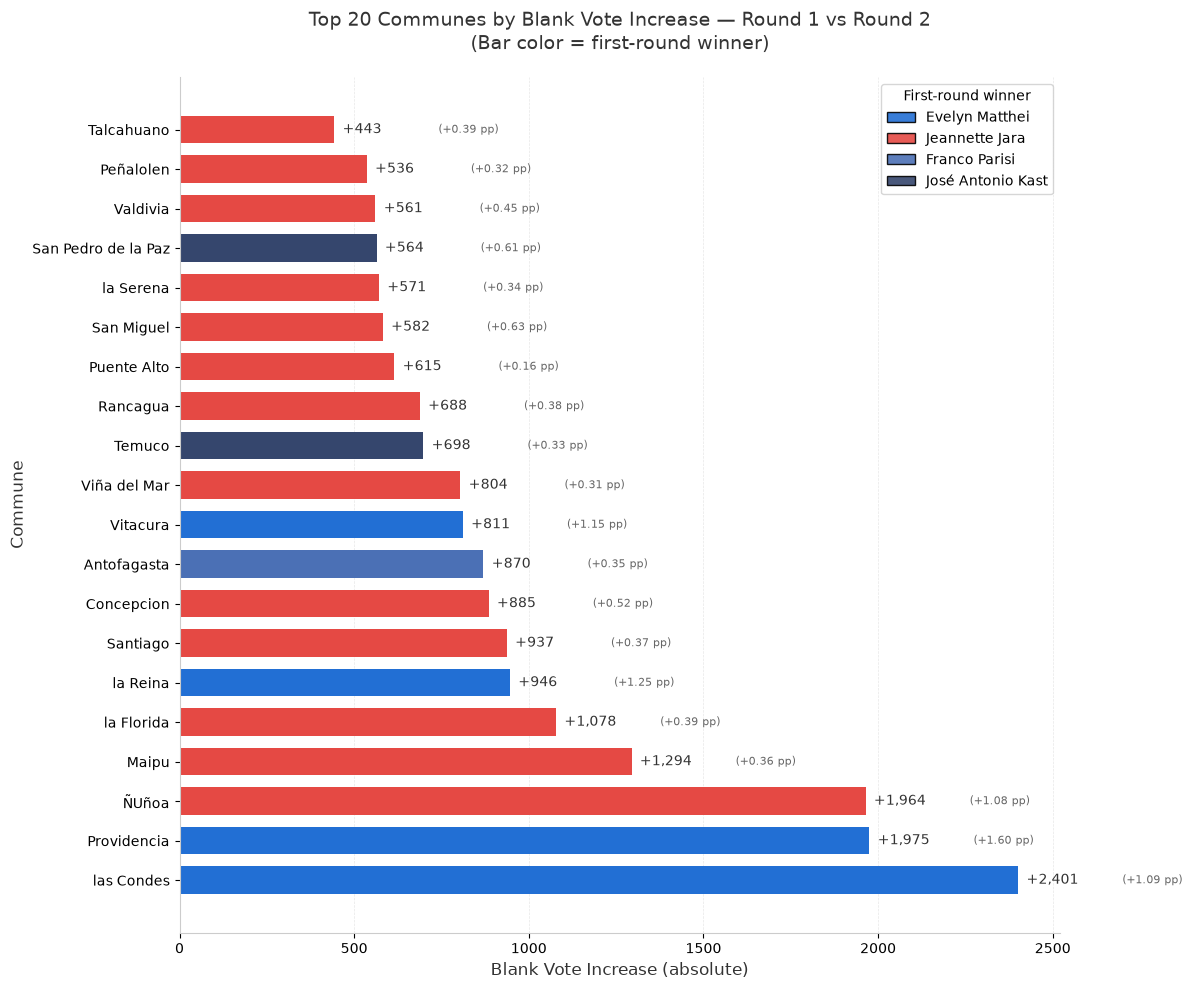

In [632]:
# ============================================================================
# VISUALIZATION: TOP-N COMMUNES BY BLANK VOTE INCREASE (ABSOLUTE)
# ============================================================================
# Horizontal bar chart of communes with the largest absolute blank vote
# increase between rounds; bar color encodes the first-round winner.
# ============================================================================

def plot_top_blank_increase(df: pd.DataFrame, top_n: int = 20) -> None:
    """
    Horizontal bar chart of the communes with the largest absolute increase
    in blank votes between the first and second round.

    Bar color encodes the first-round winner of each commune.
    Each bar carries two annotations:
      - Absolute blank vote increase (bold, offset right of bar tip).
      - Percentage-point change in parentheses (smaller, further right).

    Legend is placed in the upper right to avoid overlap with the longest bars.

    Parameters
    ----------
    df : pd.DataFrame
        Output of analyze_communes_blank_increase(), containing at minimum:
        commune, blank_votes_increase, blank_pct_point_change, first_round_winner.
    top_n : int, optional
        Number of communes to display (default 20).
    """
    from matplotlib.patches import Patch

    # Filter to communes with positive increase
    plot_df = df.nlargest(top_n, 'blank_votes_increase').copy()

    # Resolve full display name and color for each bar
    plot_df['winner_full'] = (
        plot_df['first_round_winner']
        .map(WINNER_NAME_MAPPING)
        .fillna('No data')
    )
    plot_df['color'] = (
        plot_df['winner_full']
        .map(CANDIDATE_COLORS)
        .fillna(CANDIDATE_COLORS['No data'])
    )

    fig, ax = plt.subplots(figsize=(12, 10))
    fig.patch.set_facecolor('white')
    ax = set_clean_style(ax)

    # Bars rendered above the grid (zorder=2)
    bars = ax.barh(
        plot_df['commune'],
        plot_df['blank_votes_increase'],
        color=plot_df['color'],
        linewidth=0.8,
        height=0.7,
        zorder=2,
    )

    # Primary annotation: absolute increase
    for bar, value in zip(bars, plot_df['blank_votes_increase']):
        ax.annotate(
            f'{value:+,.0f}',
            xy=(bar.get_width(), bar.get_y() + bar.get_height() / 2),
            xytext=(6, 0),
            textcoords='offset points',
            ha='left', va='center',
            fontsize=10,
            color='#333333', zorder=3,
        )

    # Secondary annotation: pp change
    for bar, pp_value in zip(bars, plot_df['blank_pct_point_change']):
        sign = '+' if pp_value > 0 else ''
        ax.annotate(
            f'({sign}{pp_value:.2f} pp)',
            xy=(bar.get_width(), bar.get_y() + bar.get_height() / 2),
            xytext=(75, 0),
            textcoords='offset points',
            ha='left', va='center',
            fontsize=8, color='#666666', zorder=3,
        )

    ax.set_xlabel('Blank Vote Increase (absolute)', fontsize=12, color='#333333')
    ax.set_ylabel('Commune', fontsize=12, color='#333333')
    ax.set_title(
        f'Top {top_n} Communes by Blank Vote Increase — Round 1 vs Round 2\n'
        '(Bar color = first-round winner)',
        fontsize=14, pad=20, color='#333333',
    )

    # Legend — upper right keeps it clear of the longest bars
    legend_elements = [
        Patch(
            facecolor=CANDIDATE_COLORS.get(
                WINNER_NAME_MAPPING.get(w, 'No data'), 
                CANDIDATE_COLORS['No data']
            ),
            edgecolor='black',
            label=WINNER_NAME_MAPPING.get(w, w),
            alpha=0.9,
        )
        for w in plot_df['first_round_winner'].unique()
    ]
    ax.legend(
        handles=legend_elements,
        loc='upper right',
        title='First-round winner',
        fontsize=10,
        frameon=True,
        facecolor='white',
        edgecolor='#cccccc',
    )

    plt.tight_layout()
    plt.show()

# Execute
plot_top_blank_increase(communes_blank_increase, 20)

##### Key Finding

The increase in blank voting concentrated in the Metropolitan Region, with a clear predominance of high socioeconomic communes and traditional right strongholds of Matthei, revealing a profile radically different from that of the null vote.

##### Key Patterns

- **The Santiago elite leads the ranking**: Las Condes (+2,401) tops the country, followed by Providencia (+1,975), Ñuñoa (+1,964), La Reina (+946) and Vitacura (+811). Four of the five communes with the largest increase are Matthei strongholds in eastern Santiago.
- **Jara's strongholds also affected**: Ñuñoa (+1,964), Maipú (+1,294), La Florida (+1,078), Santiago (+937) and Viña del Mar (+804) record significant increases, reflecting demobilisation within the ruling-coalition electorate.
- **Absence of the north**: Antofagasta (+870) is the only northern commune with a relevant presence; the blank vote was not a significant phenomenon in the territories where Parisi was dominant.
- **Difference from the null vote**: while the null concentrated in working-class communes and in the northern mining belt, the blank had a more urban and higher socioeconomic character, confined almost exclusively to the Metropolitan Region and Valparaíso.

##### Interpretation

The blank vote operated as a channel of passive protest for sectors that did not feel represented by Kast but also declined to vote for Jara. In the elite communes of eastern Santiago, a fraction of Matthei's electorate preferred this route — instead of the null vote or voting for Kast — reflecting a fracture within the traditional right. In Jara's strongholds, the increase in the blank suggests disenchantment with the ruling-coalition candidate, though with lesser intensity than observed in the northern null vote. The absence of correlation with the Parisi vote confirms that the blank responded to a political logic distinct from that of the northern anti-establishment: a moderate rejection by urban and upper-middle-class sectors that did not find in the binary offer a fully representative option.

#### Chart: Top 20 Communes by Relative Blank Vote Increase

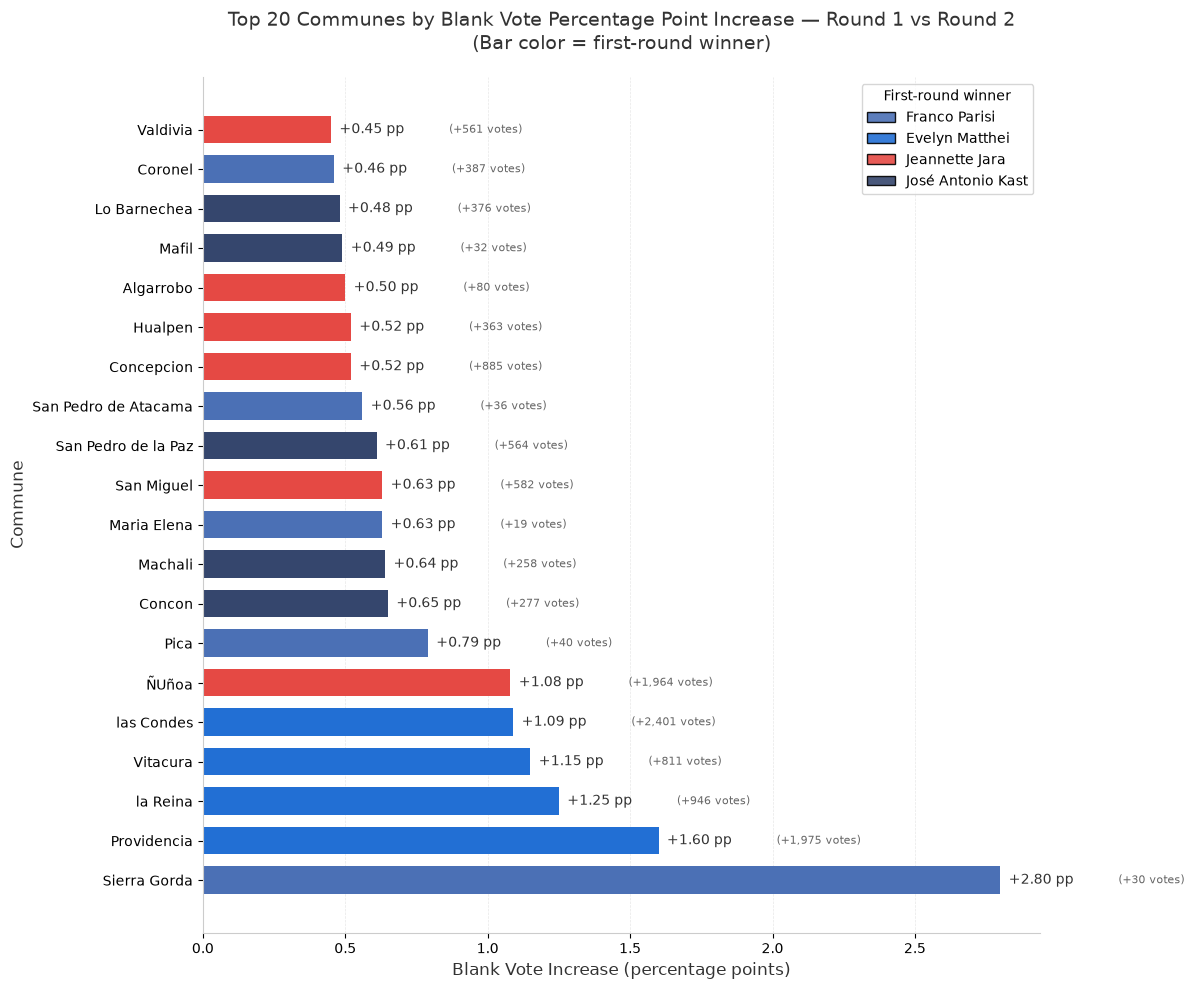

In [633]:
# ============================================================================
# VISUALIZATION: TOP-N COMMUNES BY BLANK VOTE INCREASE (PERCENTAGE POINTS)
# ============================================================================
# Horizontal bar chart of communes with the largest pp blank vote increase;
# normalises for commune size, highlighting intensity shifts independently of scale.
# ============================================================================

def plot_top_blank_pp_increase(df: pd.DataFrame, top_n: int = 20) -> None:
    """
    Horizontal bar chart of the communes with the largest PERCENTAGE POINT
    increase in blank votes between the first and second round.

    This is useful for identifying communes where blank voting intensity
    increased the most, regardless of population size.

    Bar color encodes the first-round winner of each commune.
    Each bar carries two annotations:
      - Percentage-point change (bold, offset right of bar tip).
      - Absolute increase in parentheses (smaller, further right).

    Parameters
    ----------
    df : pd.DataFrame
        Output of analyze_communes_blank_increase().
    top_n : int, optional
        Number of communes to display (default 20).
    """
    from matplotlib.patches import Patch

    # Filter to communes with positive pp increase
    plot_df = df[df['blank_pct_point_change'] > 0].nlargest(top_n, 'blank_pct_point_change').copy()

    if len(plot_df) == 0:
        print("No communes with positive blank vote percentage point increase.")
        return

    # Resolve full display name and color for each bar
    plot_df['winner_full'] = (
        plot_df['first_round_winner']
        .map(WINNER_NAME_MAPPING)
        .fillna('No data')
    )
    plot_df['color'] = (
        plot_df['winner_full']
        .map(CANDIDATE_COLORS)
        .fillna(CANDIDATE_COLORS['No data'])
    )

    fig, ax = plt.subplots(figsize=(12, 10))
    fig.patch.set_facecolor('white')
    ax = set_clean_style(ax)

    # Bars rendered above the grid (zorder=2)
    bars = ax.barh(
        plot_df['commune'],
        plot_df['blank_pct_point_change'],
        color=plot_df['color'],
        linewidth=0.8,
        height=0.7,
        zorder=2,
    )

    # Primary annotation: percentage point change
    for bar, value in zip(bars, plot_df['blank_pct_point_change']):
        ax.annotate(
            f'+{value:.2f} pp',
            xy=(bar.get_width(), bar.get_y() + bar.get_height() / 2),
            xytext=(6, 0),
            textcoords='offset points',
            ha='left', va='center',
            fontsize=10,
            color='#333333', zorder=3,
        )

    # Secondary annotation: absolute increase
    for bar, abs_value in zip(bars, plot_df['blank_votes_increase']):
        ax.annotate(
            f'({abs_value:+,.0f} votes)',
            xy=(bar.get_width(), bar.get_y() + bar.get_height() / 2),
            xytext=(85, 0),
            textcoords='offset points',
            ha='left', va='center',
            fontsize=8, color='#666666', zorder=3,
        )

    ax.set_xlabel('Blank Vote Increase (percentage points)', fontsize=12, color='#333333')
    ax.set_ylabel('Commune', fontsize=12, color='#333333')
    ax.set_title(
        f'Top {top_n} Communes by Blank Vote Percentage Point Increase — Round 1 vs Round 2\n'
        '(Bar color = first-round winner)',
        fontsize=14, pad=20, color='#333333',
    )

    # Legend
    legend_elements = [
        Patch(
            facecolor=CANDIDATE_COLORS.get(
                WINNER_NAME_MAPPING.get(w, 'No data'), 
                CANDIDATE_COLORS['No data']
            ),
            edgecolor='black',
            label=WINNER_NAME_MAPPING.get(w, w),
            alpha=0.9,
        )
        for w in plot_df['first_round_winner'].unique()
    ]
    ax.legend(
        handles=legend_elements,
        loc='upper right',
        title='First-round winner',
        fontsize=10,
        frameon=True,
        facecolor='white',
        edgecolor='#cccccc',
    )

    plt.tight_layout()
    plt.show()

# Execute
plot_top_blank_pp_increase(communes_blank_increase, 20)

##### Key Finding

The relative increase in blank voting confirms the urban and higher-income profile of the phenomenon: the communes of eastern Santiago — Evelyn Matthei's strongholds — lead the ranking, while the north, the epicentre of the null vote, has marginal presence limited to low-population edge cases.

##### Key Patterns

- **The Santiago elite dominates the ranking**: Providencia (+1.60 pp), La Reina (+1.25 pp), Vitacura (+1.15 pp) and Las Condes (+1.09 pp) head the list; these are the communes where Matthei achieved her best results in the first round and where a fraction of her electorate opted for passive protest over supporting Kast.
- **Jara's Metropolitan strongholds**: Ñuñoa (+1.08 pp) and other working-class communes also record relevant increases, though of lower intensity than the elite communes.
- **Absence of the north**: unlike the null vote, the blank had no significant presence in the territories where Parisi was dominant. The exception is Sierra Gorda (+2.80 pp), a low-population case that distorts the average.
- **Consistency with the absolute ranking**: the same elite communes lead both measurements, confirming that the blank vote was a stable and territorially concentrated phenomenon.

##### Interpretation

The coincidence between the absolute and relative rankings reinforces the solidity of the pattern: the blank vote was a stable phenomenon, concentrated in the Santiago elite and in some urban Jara strongholds, with no appreciable correlation with the Parisi vote. This confirms that it responded to a political logic distinct from that of the northern anti-establishment: a moderate rejection by urban and upper-middle-class sectors that did not find in the binary offer a fully representative option.

#### Blank Vote Increase by First-Round Winner

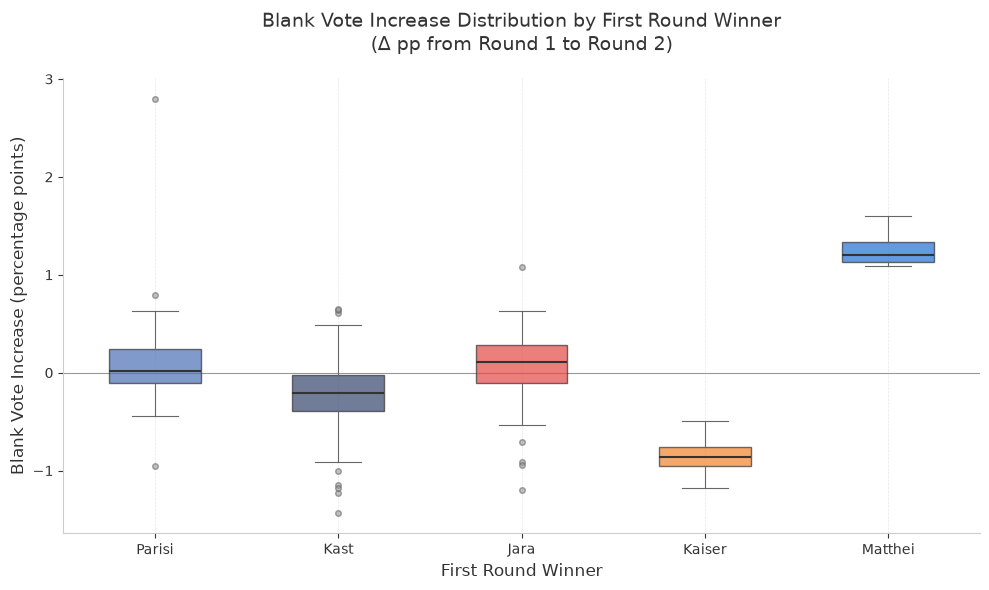

In [634]:
# ============================================================================
# VISUALIZATION: BLANK VOTE INCREASE DISTRIBUTION BY FIRST-ROUND WINNER
# ============================================================================
# Box plot comparing blank vote pp change distributions across communes
# grouped by their first-round winner.
# ============================================================================

def plot_blank_increase_by_winner(df: pd.DataFrame) -> None:
    """
    Box plot showing the distribution of percentage point increase in blank votes,
    grouped by the winner of the first round in each commune.

    Only includes candidates with sufficient commune representation to ensure
    meaningful distributions.

    Parameters
    ----------
    df : pd.DataFrame
        Output of analyze_communes_blank_increase(), containing at minimum:
        commune, blank_pct_point_change, first_round_winner.
    """
    fig, ax = plt.subplots(figsize=(10, 6))
    fig.patch.set_facecolor('white')
    ax = set_clean_style(ax)

    # Filter top winners (exclude candidates with few communes)
    top_winners = ['Parisi', 'Kast', 'Jara', 'Kaiser', 'Matthei']
    plot_df = df[df['first_round_winner'].isin(top_winners)].copy()

    # Prepare data for box plots
    box_data = [
        plot_df[plot_df['first_round_winner'] == winner]['blank_pct_point_change']
        for winner in top_winners
    ]

    # Create box plot with custom styling
    # ELIMINADO: labels=top_winners (causa el error)
    boxes = ax.boxplot(
        box_data,
        patch_artist=True,
        medianprops={'color': '#333333', 'linewidth': 1.5},
        whiskerprops={'color': '#666666', 'linewidth': 0.8},
        capprops={'color': '#666666', 'linewidth': 0.8},
        flierprops={
            'marker': 'o',
            'markerfacecolor': '#999999',
            'markeredgecolor': '#666666',
            'markersize': 4,
            'alpha': 0.6
        }
    )

    # Set the x-axis labels after creating the boxplot
    ax.set_xticklabels(top_winners)

    # Color each box consistently with candidate colors
    for box, winner in zip(boxes['boxes'], top_winners):
        full_name = WINNER_NAME_MAPPING.get(winner, winner)
        color = CANDIDATE_COLORS.get(full_name, CANDIDATE_COLORS.get('No data', '#dddddd'))
        box.set_facecolor(color)
        box.set_alpha(0.7)
        box.set_edgecolor('#333333')
        box.set_linewidth(1)

    # Add horizontal line at zero
    ax.axhline(y=0, color='#333333', linestyle='-', linewidth=0.8, alpha=0.5, zorder=1)

    # Labels and title
    ax.set_xlabel('First Round Winner', fontsize=12, color='#333333')
    ax.set_ylabel('Blank Vote Increase (percentage points)', fontsize=12, color='#333333')
    ax.set_title(
        'Blank Vote Increase Distribution by First Round Winner\n'
        '(Δ pp from Round 1 to Round 2)',
        fontsize=14, pad=20, color='#333333'
    )

    # Style adjustments
    ax.tick_params(axis='both', colors='#333333', labelsize=10)

    plt.tight_layout()
    plt.show()

# Execute
plot_blank_increase_by_winner(communes_blank_increase)

##### Key Finding

The blank vote showed very differentiated behaviour depending on the winning candidate in each commune in the first round. Unlike the null — whose epicentre was Parisi's electorate — the blank was the preferred protest mechanism of the traditional right of Matthei and, to a lesser extent, anti-establishment sectors.

##### Analysis by Candidate

- **Matthei** (median ~1.2–1.4 pp, low dispersion): the largest and most consistent increase. Her communes show the clearest trend towards the blank, indicating that a significant fraction of the traditional right declined to vote for Kast and opted for passive protest.
- **Parisi** (positive median, with high outliers): moderate increase but with high variability; part of his electorate opted for the blank, but another fraction preferred the null or transfer to Kast.
- **Jara** (median ~0.2–0.3 pp): slight but positive increase; her base showed somewhat greater resistance to the blank than Matthei's or Parisi's, though demobilisation was expressed more through the null.
- **Kast** (median slightly negative or near zero): more disciplined electorate; where he was already strong in the first round, the increase in the blank was lowest, confirming the loyalty of his base.
- **Kaiser** (negative median): the only group with a clear decrease in blank voting, indicating that his voters were more likely to vote for Kast or annul than to opt for passive protest.

##### Strategic Interpretation

The blank vote was, above all, a phenomenon of the traditional right and, to a lesser extent, of the anti-establishment. Matthei's and Parisi's voters were the most prone to passively rejecting the runoff, though for different reasons: resistance to Kast's candidacy in the case of Matthei, rejection of the political system as a whole in the case of Parisi. Kast had the most loyal and disciplined base, while Jara occupied an intermediate position. The chart confirms that a portion of the Matthei and Parisi electorates did not transfer completely to Kast, which explains why, despite his wide victory, the protest vote — especially the blank — was relevant in specific sectors of the right and centre-right electorate.

#### Conclusion 5.3.

The blank vote behaved as a territorially differentiated phenomenon that complements — and contrasts with — the pattern observed for the null. While the null had its epicentre in the northern mining belt and in working-class communes, the blank concentrated in the Metropolitan Region, particularly in high-income communes and in Evelyn Matthei's strongholds. The behaviour suggests that the blank operated as a channel of more passive discontent, used by sectors of the traditional right that did not feel fully represented by José Antonio Kast, and by a fraction of Jara's electorate that opted for protest over ratifying their candidate. This duality — active protest in the north, passive protest in eastern Santiago — evidences a fragmentation of citizen discontent that transcends the immediate electoral result.

### Chapter 5 Conclusion: The Blank Vote

The blank vote behaved as a territorially heterogeneous phenomenon that complements — and in some cases contrasts with — the pattern observed for the null vote. While the null increased in all regions by pronounced amounts, the blank grew moderately in 11 and declined in 5 of the centre-south regions, where discontent was channelled preferentially towards active protest. This duality confirms that the electorate uses different forms of ballot invalidation depending on its perception of the political system: the blank as an expression of passive discontent in urban zones, the null as a more confrontational rejection in territories where distrust runs deepest.

The profile of the blank vote was clearly urban and higher-income. Its concentration in eastern Santiago — Las Condes, Providencia, Vitacura and La Reina, all Evelyn Matthei strongholds in the first round — reveals that a significant fraction of the traditional right opted for passive protest over supporting José Antonio Kast in the runoff. This internal fracture of the right is one of the most relevant findings of the chapter: sectors that had supported Matthei in the first round did not feel represented by the republican candidacy and preferred to invalidate their vote rather than transfer it. In contrast, in Jeannette Jara's strongholds — especially in working-class communes of the Metropolitan Region — the increase in the blank was more moderate, reflecting less intense demobilisation than that observed in the northern null vote.

Taken together, the increase in both types of invalid vote — rising from 3.7% in the first round to 7.1% in the second — confirms that a relevant fraction of the Chilean electorate did not find full representation in the Jara–Kast contest. However, the null and the blank responded to distinct political logics: the latter, a phenomenon of moderate rejection by urban and upper-middle-class sectors without full affinity with the binary offer; the former, an expression of active protest from the northern anti-establishment and from discontented working-class sectors. This distinction is relevant for understanding the nature of citizen discontent and the challenges facing the political system in reconnecting with an electorate that, while supporting Kast in valid votes by a majority, also expressed its dissatisfaction through mechanisms that transcend the mere presidential transition.

#### Final Comparison: Blank Vote vs. Null Vote

| Aspect                    | Null Vote                                       | Blank Vote                                         |
| ------------------------- | ----------------------------------------------- | -------------------------------------------------- |
| **Intensity**             | Very high (nearly doubled)                      | Moderate                                           |
| **Distribution**          | Broad and transversal                           | More concentrated in MR and elite communes         |
| **Primary origin**        | **Parisi** electorate (North)                   | **Matthei** electorate (eastern MR)                |
| **Type of protest**       | Active / confrontational                        | Passive ("none of the options represents me")      |
| **Most affected communes**| Norte Grande and large working-class cities     | High-income Santiago communes                      |
| **Implication**           | Strong anti-establishment rejection             | Internal resistance of the traditional right       |

---

## 6. Valid Votes and the Election Winner

The 2025 presidential runoff consecrated José Antonio Kast as president-elect with a victory that, by its magnitude, ranks among the most decisive in the recent electoral history of Chile. On the basis of the 346 communes analysed in this report, Kast obtained 58.24% of valid votes against Jeannette Jara's 41.76%, a difference of 16.48 percentage points equivalent to a margin of more than 2 million votes. This majority — backed by nearly 6 in every 10 voters — grants Kast a broad mandate to govern, even taking into account the elevated level of null voting (5.85%) that characterised the election. The result also represents a political shift towards the conservative right following Gabriel Boric's government, consolidating an electoral realignment set in motion during the first round and deepened substantially in the runoff.

In [635]:
# ============================================================================
# SECOND ROUND WINNER DECLARATION AND RESULT SUMMARY
# ============================================================================
# Aggregates national vote totals for the runoff, declares the winner,
# and prints a structured result summary with margin and victory type.
# ============================================================================

def calculate_winner_results(df: pd.DataFrame) -> pd.DataFrame:
    """
    Calculates final results for the second round runoff.
    
    Parameters
    ----------
    df : pd.DataFrame
        Second round data with columns: casted_votes, blank_votes, null_votes,
        jara_votes, kast_votes
    
    Returns
    -------
    pd.DataFrame
        DataFrame with candidate, percentage, total_votes, result
    """
    total_cast = df['casted_votes'].sum()
    total_blank = df['blank_votes'].sum()
    total_null = df['null_votes'].sum()
    total_valid = total_cast - total_blank - total_null
    
    jara_total = df['jara_votes'].sum()
    kast_total = df['kast_votes'].sum()
    
    jara_pct = round(100.0 * jara_total / total_valid, 2)
    kast_pct = round(100.0 * kast_total / total_valid, 2)
    margin_pct = round(abs(jara_pct - kast_pct), 2)
    margin_votes = abs(jara_total - kast_total)
    
    results = pd.DataFrame([
        {
            'candidate': 'Jeannette Jara',
            'percentage': jara_pct,
            'total_votes': jara_total,
            'result': 'defeated'
        },
        {
            'candidate': 'José Antonio Kast',
            'percentage': kast_pct,
            'total_votes': kast_total,
            'result': 'PRESIDENT-ELECT'
        },
        {
            'candidate': 'Margin',
            'percentage': margin_pct,
            'total_votes': margin_votes,
            'result': 'winning margin'
        }
    ])
    
    return results

# Execute calculation
winner_results = calculate_winner_results(df_2025_v2)
winner_results

,candidate,percentage,total_votes,result
0,Jeannette Jara,41.76,5184026,defeated
1,José Antonio Kast,58.24,7231018,PRESIDENT-ELECT
2,Margin,16.48,2046992,winning margin


### Analysis

#### Methodological Note: The Result of this Analysis vs. the Official Result

Before examining the result in depth, it is necessary to specify the scope of the database used in this report. The 58.24% obtained by Kast in this analysis corresponds to the aggregation of results from the 346 communes of the national territory — continental and island — without incorporating the votes cast by Chileans resident abroad, whose disaggregation at polling-station level was not available for processing in structured public databases at the time this report was prepared.

The final official result proclaimed by the Servicio Electoral, which does incorporate the overseas vote, was **58.16% for Kast and 41.84% for Jara** (7,249,850 votes against 5,215,205, on a national total of 13,413,226 ballots counted). The proximity between the two figures — 58.24%/41.76% in this analysis against 58.16%/41.84% in the official result — confirms that the weight of the overseas vote on the aggregate national result was marginal, given its relatively small volume compared to the total register. Nevertheless, it is appropriate to record the difference for reasons of methodological rigour, and because the behaviour of the overseas vote, examined in isolation, exhibits a pattern clearly distinct from that of the domestic vote.

Unlike what occurred within Chile, **Jeannette Jara prevailed in the vote cast abroad**, with 59.09% against Kast's 40.91%. This is, however, a segment of the register with a very particular pattern of participation: unlike Chile, where voting was compulsory in this election, the ballot cast by Chileans residing outside the country remained voluntary, which translated into low participation in relative terms — approximately 59,574 voters out of an eligible register of just over 160,000 people — and into polling stations with an extremely small number of voters, in some cases as few as 5 or 6. This combination of low volume and high dispersion across countries means that the overseas result, although consistent and mostly favourable to the ruling coalition in the majority of countries with significant participation, is not statistically comparable in robustness with the vote cast within the national territory, and explains why its exclusion from this analysis does not materially alter the territorial conclusions that follow.

#### Magnitude of the Victory and Political Significance

The runoff result, in either of its two readings — this analysis's or the official one — admits no qualification in terms of magnitude. Kast obtained, on the communal database used here, 7,231,018 valid votes against Jara's 5,184,026, an advantage of 2,046,992 ballots that represents the largest margin of victory in a runoff since the return to democracy. This majority, which substantially exceeds the 50% threshold required by the Constitution, establishes an electorally uncontestable mandate in formal terms.

From a comparative perspective, Kast's victory ranks among the broadest in Chile's recent history, surpassing the margins obtained by Sebastián Piñera in 2010 (7.9 pp) and 2017 (1.5 pp), and approaching the figure registered by Michelle Bachelet in 2013 against Evelyn Matthei (24.3 pp). Kast himself, defeated in 2021 by Boric by 11.8 points, obtained in this third candidacy a result that more than doubles the magnitude of that defeat, constituting an electoral turnaround of a scale rarely seen in the post-dictatorship period.

#### Consolidation of the Right-Wing Vote and Capture of the Parisi Electorate

Kast's victory is explained, to a large extent, by his capacity to consolidate and expand the right and centre-right vote, capturing a substantial share of the electorate that in the first round had backed Franco Parisi, Johannes Kaiser and Evelyn Matthei. Parisi's electorate — which in November had reached 2.55 million votes (19.71%) — dispersed between both final candidacies, with a majority inclination towards Kast, especially in the Norte Grande regions where his first-round support had been most solid.

The profile of the electorate that tipped the balance towards Kast corresponds, in general terms, to a young, male, middle-class voter with high distrust of the traditional political system — precisely the segment that had backed Parisi in the first round and that, faced with a bipolar offer between a ruling-coalition candidate and a conservative right-wing candidate, opted predominantly for Kast. This type of realignment, in which a bloc manages to articulate a coalition of voters that maintains its support in a relatively stable manner over time, is consistent with what the critical elections literature describes as a process of electoral coalition recomposition. That Kast managed to capture a significant portion of the anti-establishment electorate — which in earlier elections had been distributed across centre and left options — suggests that this result may have a more durable correlate than that of an isolated electoral cycle, although its consolidation will depend on factors that exceed the scope of this analysis.

#### Jara's Performance and the Demobilisation of the Ruling Coalition

In contrast, Jeannette Jara failed to sufficiently mobilise her own base or attract a majority share of the anti-establishment vote that had backed Parisi in the first round. The candidate, who had obtained 26.85% of the vote in November, saw her electoral share stagnate in relative terms in the face of Kast's growth. The decline of almost half a million valid votes between the two rounds — compounded by the increase in null voting in communes that had been her strongholds — shows that the ruling coalition faced significant demobilisation of its natural electorate, without this necessarily implying an absolute loss of support, as will be documented in chapter 8.

Jara's defeat also reflects the structural limitations of the political project she led. Despite her tenure as Boric's Minister of Labour — which included reforms such as the reduction of the working week to 40 hours and the reform of the pension system — her candidacy failed to articulate a narrative of continuity that could reach discontented voters unhappy with the departing government's management. Kast's discourse, centred on the idea of an "emergency government" in response to the security and economic crises, found an echo in an electorate that perceived a deterioration in its quality of life and in the control of public order — a perception that, it should be noted, is the subject of debate among analysts regarding its exact correspondence with the objective crime indicators of the period, but which operated as a central and effective axis of the opposition's campaign narrative.

#### Legitimacy and Challenges of the Mandate

Despite the decisiveness of the victory in valid votes, Kast's triumph coexists with elements that qualify — without invalidating — its perceived legitimacy in some sectors. The elevated level of null voting (5.85%) and the persistence of an electorate that, faced with a bipolar offer that did not engage it, opted for protest rather than abstention, are variables that any reading of the mandate should weigh. Political theory distinguishes between the formal legality of an electoral process and the social legitimacy of its result, understood as the political community's consensus in accepting the elected authority; that more than 780,000 people opted for the null vote, and that a relevant fraction of the electorate of the country's third-largest political force did not feel represented by either of the two final options, is a datum the new government will need to consider in its relationship with citizens, without this detracting from the legal or democratic validity of its election.

This consideration should not be overstated: the majority obtained by Kast — nearly 6 in every 10 valid voters — is sufficiently broad to confer a solid governing mandate, on terms comparable to or exceeding those of most of his predecessors. The challenge for the new government will reside less in the formal legitimacy of its victory than in its capacity to translate that mandate into effective public policies, in a context of parliamentary fragmentation that is examined in section 13.

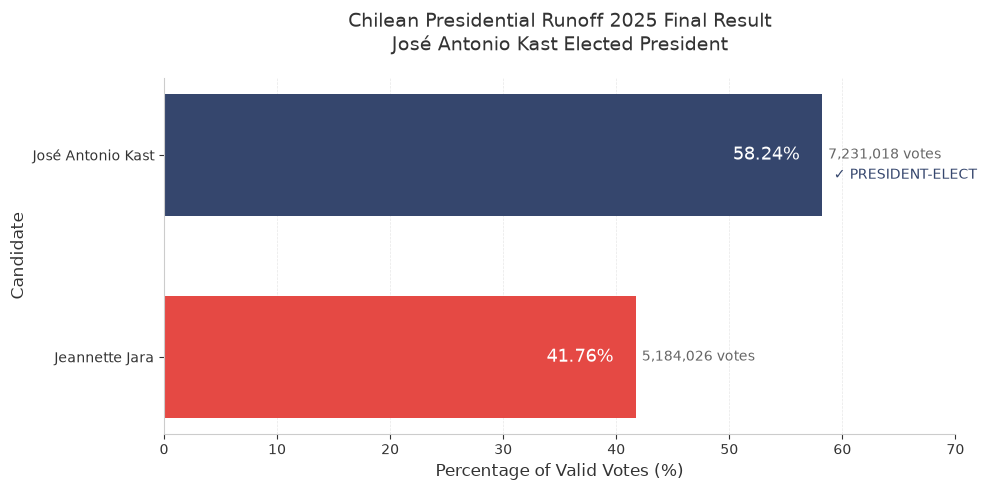

In [636]:
# ============================================================================
# VISUALIZATION: WINNER DECLARATION — NATIONAL RESULTS BAR CHART
# ============================================================================
# Horizontal bar chart of second-round vote shares for both candidates,
# annotated with absolute vote counts and percentage-point margin.
# ============================================================================

def plot_winner_bars(df: pd.DataFrame) -> None:
    """
    Creates a horizontal bar chart showing the final vote percentages and margins
    for the Chilean Presidential Runoff 2025.

    Bars display each candidate's percentage of valid votes, with the winner
    highlighted and annotated. Percentage labels appear inside bars, while
    vote counts are placed at the bar tips.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing candidate results with columns:
        candidate, percentage, total_votes.
        Should exclude any 'Margin' row.
    """
    plot_df = df[df['candidate'] != 'Margin'].copy()
    
    fig, ax = plt.subplots(figsize=(10, 5))
    fig.patch.set_facecolor('white')
    ax = set_clean_style(ax)
    
    # Get colors from palette
    colors = [CANDIDATE_COLORS.get(c, '#cccccc') for c in plot_df['candidate']]
    
    # Horizontal bars with consistent styling
    bars = ax.barh(
        plot_df['candidate'],
        plot_df['percentage'],
        color=colors,
        linewidth=0.8,
        height=0.6,
        zorder=2
    )
    
    # Primary annotation: percentage labels inside bars (right-aligned)
    for bar, pct in zip(bars, plot_df['percentage']):
        ax.annotate(
            f'{pct:.2f}%',
            xy=(bar.get_width() - 2, bar.get_y() + bar.get_height() / 2),
            xytext=(0, 0),
            textcoords='offset points',
            ha='right', va='center',
            fontsize=13,
            color='white', zorder=3
        )
    
    # Secondary annotation: vote count labels at bar tips
    for bar, votes in zip(bars, plot_df['total_votes']):
        ax.annotate(
            f'{votes:,.0f} votes',
            xy=(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2),
            xytext=(0, 0),
            textcoords='offset points',
            ha='left', va='center',
            fontsize=10, color='#666666', zorder=3
        )
    
    # Set x-axis limit with some padding for labels
    ax.set_xlim(0, 70)
    
    # Labels and title
    ax.set_xlabel('Percentage of Valid Votes (%)', fontsize=12, color='#333333')
    ax.set_ylabel('Candidate', fontsize=12, color='#333333')
    ax.set_title(
        'Chilean Presidential Runoff 2025 Final Result\n'
        'José Antonio Kast Elected President',
        fontsize=14, pad=20, color='#333333'
    )
    
    # Highlight winner annotation
    winner_name = 'José Antonio Kast'
    if winner_name in plot_df['candidate'].values:
        bar_position = list(plot_df['candidate']).index(winner_name)
        winner_pct = plot_df[plot_df['candidate'] == winner_name]['percentage'].values[0]
        
        ax.annotate(
            '✓ PRESIDENT-ELECT',
            xy=(winner_pct + 1, bar_position - 0.1),
            xytext=(0, 0),
            textcoords='offset points',
            ha='left', va='center',
            fontsize=10,
            color='#35466D', zorder=3
        )
    
    # Style adjustments
    ax.tick_params(axis='both', colors='#333333', labelsize=10)
    
    plt.tight_layout()
    plt.show()

# Execute
plot_winner_bars(winner_results)

### Chapter 6 Conclusion: Valid Votes and the Election Winner

The 2025 presidential runoff consecrated José Antonio Kast as president-elect with a victory that, by its magnitude, constitutes a milestone in Chile's recent electoral history: 58.16% at the national level according to the official Servel result (58.24% in the 346-commune database used in this analysis), with a margin that nearly doubles, in percentage points, the one obtained by Boric over Kast himself in 2021. His capacity to capture the vote of the traditional right, of anti-establishment sectors and of a relevant portion of the centre electorate — especially in the north and in rural zones — allowed him to build a majority of nearly 6 in every 10 voters, the broadest since the return to democracy.

This victory represents a shift towards the conservative right following Gabriel Boric's government and consolidates an electoral realignment whose effects will extend beyond the presidential term. Nevertheless, the magnitude of the triumph coexists with elements the new government will need to weigh: the elevated level of null voting, which qualifies the perceived legitimacy of the mandate in some sectors without affecting its validity; the fragmentation of the incoming Congress, which will limit the capacity to advance structural reforms without negotiation; and the need to reconnect with an electorate that, in the north of the country and in specific working-class sectors, has opted for active protest as a form of political expression. In this sense, Kast's triumph, though decisive, is also a mandate that will require from the new government a sustained capacity for negotiation and dialogue over time.

---

## 7. The Territorial Map: Communal Hegemony and Persistent Fractures

### Introduction

The territorial mapping of the runoff reveals a communal hegemony without precedent in recent Chilean electoral history: José Antonio Kast won 310 of the country's 346 communes (89.6%), while Jeannette Jara was reduced to 36 communes (10.4%), concentrated almost exclusively in the Metropolitan Region — particularly in the working-class communes of the western and southern sectors of Greater Santiago — and in some enclaves of Valparaíso, Coquimbo and Atacama. This overwhelming territorial majority contrasts with the more moderate distribution of the popular vote (58.24% for Kast against 41.76% for Jara), reflecting the classic urban-rural and centre-periphery fracture that has characterised Chilean electoral geography: Jara maintained her strength in densely populated urban zones, while Kast prevailed across most of the national territory, including rural, semi-rural and intermediate-sized cities in all regions. The analysis by region, macrozone and metropolitan area that follows allows this hegemony to be decomposed into its territorial dimensions, identifying intensity patterns, resistance enclaves and zones of high competition that qualify — without contradicting — Kast's general dominance.

### 7.1. Territorial Mapping: Communes Won by Candidate

The communal map confirms the hegemony described in the introduction: Kast won 310 of the 346 communes (89.6%), while Jara prevailed in just 36 (10.4%). The following visualisation allows the geographic distribution of that dominance to be observed alongside the territorial concentration of support for the ruling-coalition candidate.

In [637]:
# ============================================================================
# TERRITORIAL MAPPING: COMMUNES WON PER CANDIDATE — SECOND ROUND 2025
# ============================================================================
# Determines the commune-level winner and computes win counts and
# population coverage for each candidate.
# ============================================================================

def analyze_communes_won(df: pd.DataFrame) -> pd.DataFrame:
    """
    Calculates how many communes each candidate won in the second round.
    
    Parameters
    ----------
    df : pd.DataFrame
        Second round data with columns: commune, jara_pct, kast_pct
    
    Returns
    -------
    pd.DataFrame
        DataFrame with candidate, communes_won, percentage_communes
    """
    total_communes = len(df)
    
    # Determine winner per commune
    df = df.copy()
    df['winner'] = 'Tie'
    df.loc[df['jara_pct'] > df['kast_pct'], 'winner'] = 'Jeannette Jara'
    df.loc[df['kast_pct'] > df['jara_pct'], 'winner'] = 'José Antonio Kast'
    
    # Count communes per winner
    results = df[df['winner'] != 'Tie'].groupby('winner').size().reset_index(name='communes_won')
    results['percentage_communes'] = round(100.0 * results['communes_won'] / total_communes, 1)
    results = results.sort_values('communes_won', ascending=False)
    
    return results

# Execute analysis
communes_won = analyze_communes_won(df_2025_v2)
communes_won

,winner,communes_won,percentage_communes
1,José Antonio Kast,310,89.6
0,Jeannette Jara,36,10.4


#### Analysis

##### Kast's Territorial Hegemony

The republican candidate not only won the election in terms of the popular vote but built a territorial dominance without parallel in the recent history of Chilean runoffs. With 310 communes won — nearly 9 in every 10 — Kast prevailed in every region of the country, including those where Jara obtained her best relative results. The breadth of his territorial triumph is particularly notable in the centre-south regions: in Ñuble, La Araucanía, Maule and Los Lagos, he exceeded 65% of the vote, consolidating a bloc of support that combines rural zones, intermediate cities and communes with a high presence of evangelical populations.

The academic literature on electoral behaviour in Chile offers keys for interpreting this hegemony. Studies on the vote for the "Rechazo" option in the 2022 constitutional plebiscite — which anticipated much of the electoral map of 2025 — have identified positive correlations between that option and variables such as the percentage of rural population, poverty levels and the proportion of evangelical population in each commune, with an inverse effect for the percentage of Catholics and people with no religion. This pattern repeats in 2025: Kast obtained his best results in rural communes, those of relatively lower income and with greater evangelical presence, suggesting the persistence of long-standing socio-political fractures in the Chilean electoral system, beyond the specific conjuncture of this election.

##### Jara's Redoubt: 36 Communes in Five Regions

Jeannette Jara prevailed in 36 communes distributed across five regions: Antofagasta (3), Atacama (4), Coquimbo (3), Valparaíso (5) and the Metropolitan Region (21). This distribution reveals that her electoral base was circumscribed to three types of territory. The first corresponds to communes in the Metropolitan Region, particularly those in the western and southern sectors of Greater Santiago — Puente Alto, Maipú, La Florida, Ñuñoa, Peñalolén and other southern communes — where the left-wing vote has a historical rootedness linked to the concentration of working-class and popular-sector populations.

The second group corresponds to mining and port enclaves of the Norte Chico: Chañaral, Diego de Almagro, Caldera and Huasco in Atacama; María Elena, Mejillones and San Pedro de Atacama in Antofagasta; and Canela, Illapel and Andacollo in Coquimbo. Jara's presence in these territories, which in the first round had mostly backed Franco Parisi, suggests that a fraction of the northern anti-establishment electorate — especially in communes with a strong trade union tradition — opted for the ruling-coalition candidate in the decisive round, possibly judging that her proposals on labour and mining regulation were less threatening to their sectoral interests than those of the republican candidate.

The third group consists of communes in the Valparaíso Region: Valparaíso, San Antonio, Petorca, Isla de Pascua and Juan Fernández. In Valparaíso and San Antonio — ports with a high density of working-class population and a historical trade union presence — the left-wing vote retains significant weight. Isla de Pascua and Juan Fernández, for their part, are island enclaves with their own political dynamics, where Jara obtained her best relative results in the country: 54.47% in Isla de Pascua and 59.29% in Juan Fernández, the latter her best national showing.

##### The Urban-Rural and Centre-Periphery Fracture

The asymmetry between the popular vote (58.24% for Kast) and territorial control (89.6% of communes) reflects the urban-rural and centre-periphery fracture that has characterised Chilean electoral geography since the return to democracy. The specialised literature explains this fracture through long-term structural factors: the rural world concentrates approximately 83% of the national territory and two thirds of the country's communes, but faces significantly higher levels of poverty, labour informality and gaps in state infrastructure than urban zones. This perception of abandonment — fed by disparities in access to drinking water, education, digital connectivity and security — tends to translate electorally into a protest vote against the ruling government and into support for candidacies promising radical change, without this necessarily implying a stable ideological identification with the right.

The territorial analysis also shows that Kast was not limited to accumulating the rural vote: he managed to prevail in intermediate cities and regional capitals where the traditional right had historically faced difficulties, suggesting that his coalition also included urban sectors discontented with the departing government's management, beyond a strictly rural or conservative electorate.

##### Implications for Government Management

Kast's territorial hegemony poses a public policy design challenge: the broad support obtained in rural zones implies a concrete responsibility for the new government in matters such as water management, rural education, security and productive development with a territorial focus. The campaign promise to govern for "deep Chile" will now face the test of implementation, in a context of budgetary constraints and of a Congress without absolute majorities, as detailed in section 13.

The concentration of Jara's vote in urban zones — especially in Greater Santiago — poses, in turn, a social cohesion challenge: the new government will need to govern for a territorial majority that does not necessarily coincide with the country's densest population and most economically active centres. The fracture between urban Chile and rural Chile, powerfully manifested in this election, is a variable that any projection of medium-term political stability should consider.

#### Conclusion 7.1.

The runoff consolidated an extremely asymmetric electoral map reflecting long-standing structural fractures in Chilean society. José Antonio Kast not only won the election but obtained a territorial dominance without precedent — 310 communes, 89.6% of the total — that grants him an exceptionally broad geographic base from which to govern. Jeannette Jara, in contrast, was confined to 36 urban communes, primarily in Greater Santiago, and to some enclaves in Norte Chico and Valparaíso. This territorial asymmetry — which makes Kast the candidate of provincial and peripheral Chile and Jara the representative of metropolitan Chile — reveals the depth of a fragmentation that combines sociodemographic variables (rurality, income levels, religious composition) with perceptions of abandonment and institutional distrust. The challenge for the new government will be to design policies that reduce the territorial gaps that contributed to shaping this map, bearing in mind that the social legitimacy of its mandate will depend, in part, on its capacity to respond to a geographically dispersed electorate that voted predominantly for a change of political direction.

### 7.2. Results by Region

The regional analysis confirms Kast's territorial dominance: he prevailed in all 16 of the country's regions, while Jara was reduced to the 36 communes already described, concentrated in only five. This configuration reveals an almost total dependence of Jara on two poles: the Metropolitan Region, which concentrated 58% of her communal victories (21 communes) in working-class sectors of the western and southern sectors of Santiago — Puente Alto, Maipú and La Florida — where she maintained her support base among lower-middle-class groups; and the mining north, where she added 10 communes between Antofagasta, Atacama and Coquimbo, many of them former Parisi strongholds, reflecting her capacity to capture part of the anti-establishment vote in extractive zones with strong labour and trade union demands.

In [638]:
# ============================================================================
# TERRITORIAL MAPPING: REGIONS WON PER CANDIDATE — SECOND ROUND 2025
# ============================================================================
# Aggregates vote totals by region, determines the regional winner,
# and outputs a north-to-south ordered summary.
# ============================================================================

def analyze_regional_winners(df: pd.DataFrame, df_region_dim: pd.DataFrame) -> pd.DataFrame:
    """
    Analyzes which candidate won each region and counts communes per region.
    
    Parameters
    ----------
    df : pd.DataFrame
        Second round data with columns: region, commune, jara_pct, kast_pct
    df_region_dim : pd.DataFrame
        Region dimension with columns: region, region_order (for north-south sorting)
    
    Returns
    -------
    pd.DataFrame
        DataFrame with region, communes_jara, communes_kast, communes_tie, regional_winner
    """
    # Determine winner per commune
    df = df.copy()
    df['winner'] = 'Tie'
    df.loc[df['jara_pct'] > df['kast_pct'], 'winner'] = 'Jara'
    df.loc[df['kast_pct'] > df['jara_pct'], 'winner'] = 'Kast'
    
    # Aggregate by region
    regional_stats = df.groupby('region').agg(
        communes_jara=('winner', lambda x: (x == 'Jara').sum()),
        communes_kast=('winner', lambda x: (x == 'Kast').sum()),
        communes_tie=('winner', lambda x: (x == 'Tie').sum())
    ).reset_index()
    
    # Determine regional winner
    regional_stats['regional_winner'] = 'Tie'
    regional_stats.loc[regional_stats['communes_jara'] > regional_stats['communes_kast'], 'regional_winner'] = 'Jara'
    regional_stats.loc[regional_stats['communes_kast'] > regional_stats['communes_jara'], 'regional_winner'] = 'Kast'
    
    # Add region order for north-south sorting
    regional_stats = regional_stats.merge(
        df_region_dim[['region', 'region_order']], 
        on='region', 
        how='left'
    )
    regional_stats = regional_stats.sort_values('region_order')
    regional_stats = regional_stats.drop('region_order', axis=1)
    
    return regional_stats

# Execute analysis
regional_winners = analyze_regional_winners(df_2025_v2, df_region_dim)
regional_winners

,region,communes_jara,communes_kast,communes_tie,regional_winner
1,Arica y Parinacota,0,4,0,Kast
13,Tarapacá,0,7,0,Kast
0,Antofagasta,3,6,0,Kast
2,Atacama,4,5,0,Kast
5,Coquimbo,3,12,0,Kast
14,Valparaíso,5,33,0,Kast
12,Metropolitana,21,31,0,Kast
7,Libertador,0,33,0,Kast
11,Maule,0,30,0,Kast
15,Ñuble,0,21,0,Kast


#### Analysis

##### Kast's Regional Dominance

Kast managed to win in all 16 regions of the country, a result without direct precedent in earlier runoffs. In regions such as La Araucanía, Maule, Ñuble and Los Lagos he exceeded 65% of the vote, consolidating a bloc that combines rural zones, intermediate cities and communes with a high presence of evangelical and conservative sectors. His performance in La Araucanía — where he exceeded 70% in several communes, including those with a high proportion of Mapuche population — suggests that his discourse of order and security reached a diverse electorate, not limited exclusively to the traditional rural right-wing voter.

##### Jara's Redoubt: Dependence on the Metropolitan Region

Jara concentrated 21 of her 36 communal victories (58%) in the Metropolitan Region, in communes of the western and southern sectors of Greater Santiago — Puente Alto, Maipú, La Florida, Pedro Aguirre Cerda, Lo Espejo, San Ramón, La Cisterna, El Bosque, San Miguel, among others — where the left-wing vote maintains a historical rootedness tied to the concentration of public employment and social services. This dependence on the capital reveals a structural vulnerability: in the regions of O'Higgins, Maule, Ñuble, Biobío, La Araucanía, Los Ríos, Los Lagos, Aysén and Magallanes, Jara did not win a single commune, confirming that her electoral presence outside Santiago and some northern enclaves was marginal.

##### The Northern Mining Belt as a Second Support Pole

Jara's second support pole is located in the north, where she added 10 communes between Antofagasta (3), Atacama (4) and Coquimbo (3): Chañaral, Diego de Almagro, Caldera and Huasco in Atacama; María Elena, Mejillones and San Pedro de Atacama in Antofagasta; and Canela, Illapel and Andacollo in Coquimbo. These communes share a strong mining tradition, trade union presence and an economy dependent on large-scale mining and public employment. That the majority had backed Parisi in the first round, and that a fraction of that electorate migrated towards Jara in the runoff, suggests that the class vote and the defence of labour rights weighed more, in these specific territories, than anti-establishment identification or ideological affinity with the right.

##### Urban-Rural Fracture and Centralism

The asymmetry between territorial control (89.6% for Kast) and the popular vote (58.24%) confirms the persistence of the urban-rural and centre-periphery fracture described in section 7.1. The fact that Kast exceeded 70% in numerous rural communes of the south suggests that his support in "deep Chile" is not exclusively a conservative vote in ideological terms, but also an expression of discontent with the concentration of political and economic power in the Metropolitan Region — a phenomenon that has intensified in recent electoral cycles and that poses, for the new government, concrete demands for decentralisation and territorial productive development.

##### Implications for Governability

The geographic breadth of Kast's base — spanning from Arica to Magallanes — grants him a solid territorial mandate to implement his government programme, particularly in those regions where he obtained his best results. At the same time, the concentration of Jara's vote in urban zones poses a cohesion challenge: the new government will need to respond to the decentralisation demands of rural Chile without losing sight of the dynamics of the large urban centres, which concentrate a significant proportion of the country's population and economic activity.

#### Conclusion 7.2.

The runoff consolidated an extremely asymmetric regional map. Kast not only won in all 16 of the country's regions but obtained a territorial dominance without precedent — 310 communes, 89.6% of the total — that grants him an exceptionally broad geographic base from which to govern. Jara, in contrast, was confined to 36 urban and mining communes, concentrated in the Metropolitan Region and Norte Chico, evidencing an almost absolute dependence on two poles: working-class sectors of Greater Santiago and northern mining enclaves with a strong trade union presence. This asymmetry — which makes Kast the candidate of peripheral Chile and Jara the representative of metropolitan Chile — reveals the depth of the country's territorial fragmentation. Kast's capacity to translate his dominance into public policies that respond to the demands of rural and peripheral zones — particularly in decentralisation, productive development and public services — will be a relevant factor for the sustainability of his mandate in a context of high territorial fragmentation.

### 7.3. Margin Map by Macrozone: Intensity of the Vote

The margin map (Jara% minus Kast%) offers a more nuanced reading than the simple distribution of communal victories, showing that Kast's dominance, though broad, was not homogeneous in its intensity. The Norte Grande and Norte Chico — where Parisi had been strongest in the first round — predominantly display narrow or moderate victory tones for Kast, with several enclaves where Jara managed to prevail, especially in mining communes of Antofagasta, Atacama and Coquimbo. This configuration confirms that the transfer of the Parisi vote towards Kast was neither deep nor complete in these territories. In contrast, the Centre-South, South and Patagonia show far more solid and uncontested dominance, consolidating Kast's territorial base in rural and provincial Chile. The Centre — particularly the Metropolitan Region and Valparaíso — presents the sharpest contrast: Kast's predominance across most of the territory, but with a solid core of support for Jara in the southern and western sectors of Santiago and in some port communes.

Margin distribution by commune:
margin_category
Kast Landslide (>20%)    221
Kast Solid (10-20%)       48
Kast Narrow (<10%)        41
Jara Narrow (<10%)        31
Jara Solid (10-20%)        5
Name: count, dtype: int64
--------------------------------------------------


/tmp/ipykernel_619073/1844667375.py:247: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.05, 1, 0.94])


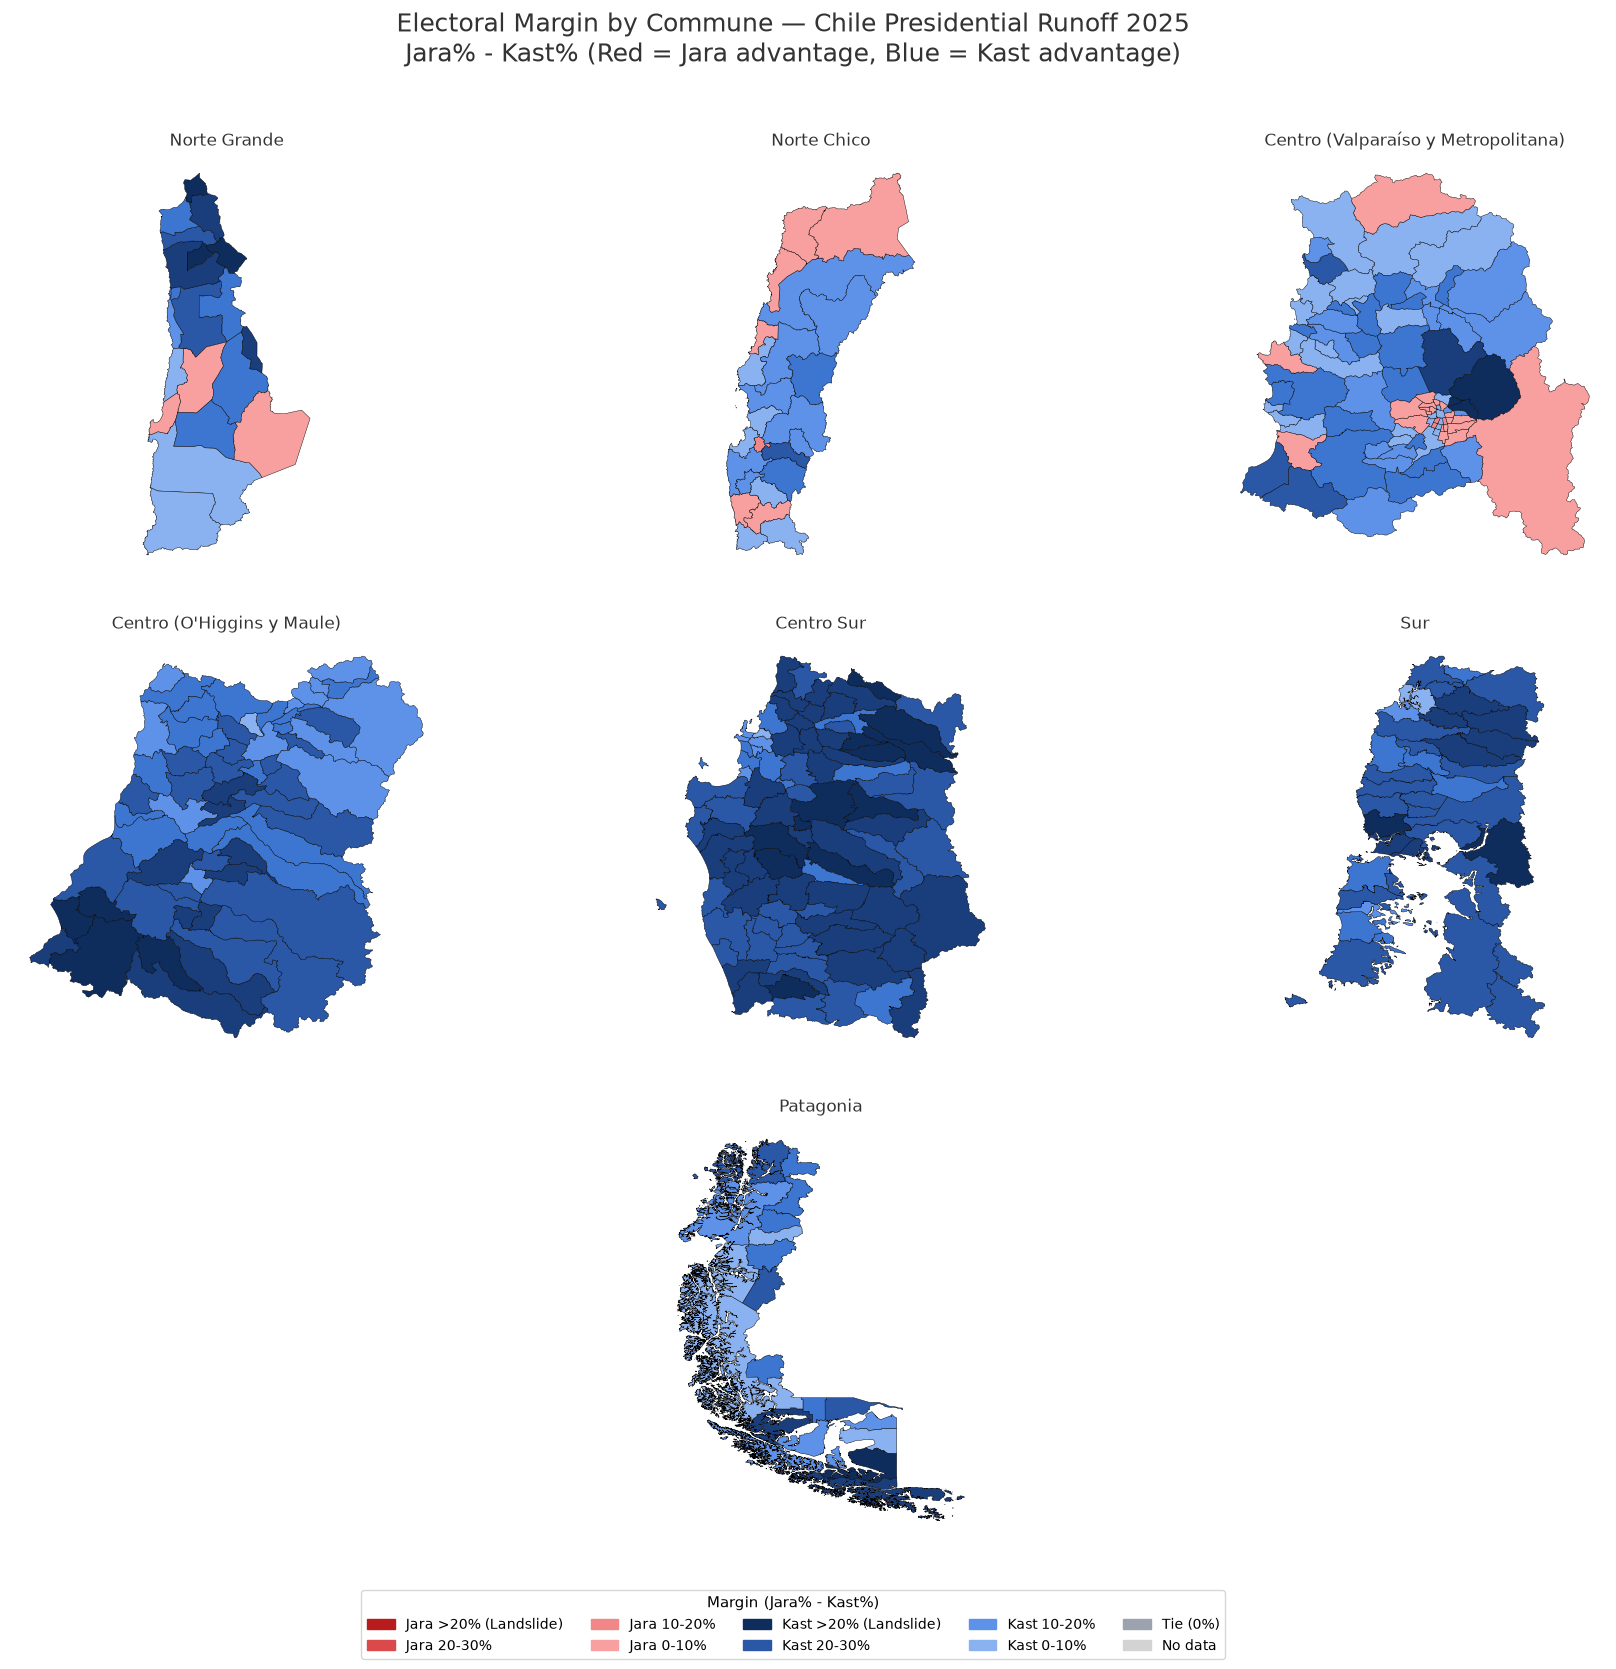

In [639]:
# ============================================================================
# COMMUNE-LEVEL ELECTORAL MARGIN MAP — SECOND ROUND 2025
# ============================================================================
# Computes the signed Jara%−Kast% margin per commune, applies a diverging
# color scale, and renders a 3×3 macrozone grid choropleth.
# ============================================================================

# This map shows the margin of victory at the commune level using a diverging
# color scale: Red tones = Jara advantage, Blue tones = Kast advantage.
# Darker colors represent larger margins (≥20%), lighter colors represent
# narrower margins (<10%).
# ============================================================================

# ---------------------------------------------------------------------------
# 1. MARGIN COLOR FUNCTION (Diverging scale: Red=Jara, Blue=Kast)
# ---------------------------------------------------------------------------

def assign_margin_color(diferencia):
    """
    Assigns hex color based on percentage difference (Jara% - Kast%).
    
    Red tones = Jara advantage (positive difference)
    Blue tones = Kast advantage (negative difference)
    Gray = Tie or No data
    
    Args:
        diferencia (float): Percentage difference (Jara% - Kast%).
    
    Returns:
        str: Hexadecimal color code.
    """
    if pd.isna(diferencia):
        return "#D3D3D3"
    
    if diferencia == 0:
        return "#9CA3AF"
    
    if diferencia > 0:  # Jara wins
        if diferencia >= 50:
            return "#B91C1C"      # Very dark red
        elif diferencia >= 40:
            return "#C92A2A"      # Dark red
        elif diferencia >= 30:
            return "#DA4A4A"      # Medium-dark red
        elif diferencia >= 20:
            return "#E86969"      # Medium red
        elif diferencia >= 10:
            return "#F28787"      # Light red
        else:
            return "#F8A0A0"      # Very light red
    else:  # Kast wins (negative difference)
        diferencia_abs = abs(diferencia)
        if diferencia_abs >= 50:
            return "#0F2D5C"      # Very dark blue
        elif diferencia_abs >= 40:
            return "#1A3D7C"      # Dark blue
        elif diferencia_abs >= 30:
            return "#2A58A6"      # Medium-dark blue
        elif diferencia_abs >= 20:
            return "#3D76D1"      # Medium blue
        elif diferencia_abs >= 10:
            return "#5E91E8"      # Light blue
        else:
            return "#8BB2F0"      # Very light blue

def get_margin_category(diferencia):
    """
    Returns a descriptive category for the margin.
    """
    if pd.isna(diferencia):
        return "No data"
    if diferencia == 0:
        return "Tie"
    if diferencia > 0:
        if diferencia >= 20:
            return "Jara Landslide (>20%)"
        elif diferencia >= 10:
            return "Jara Solid (10-20%)"
        else:
            return "Jara Narrow (<10%)"
    else:
        diff_abs = abs(diferencia)
        if diff_abs >= 20:
            return "Kast Landslide (>20%)"
        elif diff_abs >= 10:
            return "Kast Solid (10-20%)"
        else:
            return "Kast Narrow (<10%)"

# ---------------------------------------------------------------------------
# 2. CALCULATE MARGIN PER COMMUNE
# ---------------------------------------------------------------------------
df_votes_v2 = df_2025_v2.copy()

# Calculate margin (Jara% - Kast%)
df_votes_v2['margin'] = df_votes_v2['jara_pct'] - df_votes_v2['kast_pct']

# Add margin category
df_votes_v2['margin_category'] = df_votes_v2['margin'].apply(get_margin_category)

# Count by category
print("Margin distribution by commune:")
print(df_votes_v2['margin_category'].value_counts())
print("-" * 50)

# ---------------------------------------------------------------------------
# 3. NAME NORMALIZATION FOR SPATIAL JOIN
# ---------------------------------------------------------------------------
communes_map = communes.copy()
communes_map['NOM_COM_NORM'] = communes_map['NOM_COM'].apply(normalize_commune_name)
df_votes_v2['commune_norm'] = df_votes_v2['commune'].apply(normalize_commune_name)

# ---------------------------------------------------------------------------
# 4. SPATIAL JOIN: MERGE GEOMETRIES WITH MARGIN DATA
# ---------------------------------------------------------------------------
map_data_v2 = communes_map.merge(
    df_votes_v2[['commune_norm', 'margin', 'margin_category']],
    left_on='NOM_COM_NORM',
    right_on='commune_norm',
    how='left',
)

# Apply color based on margin
map_data_v2['color'] = map_data_v2['margin'].apply(assign_margin_color)

# Exclude island communes (unreachable territory distorts layout)
map_data_v2 = map_data_v2[~map_data_v2['NOM_COM'].str.contains('Isla de Pascua|Juan Fernández', case=False, na=False)]

unmatched = map_data_v2[map_data_v2['margin'].isna()]['NOM_COM'].tolist()
if unmatched:
    print(f"Communes with no match ({len(unmatched)}): {unmatched[:10]}")

# ---------------------------------------------------------------------------
# 5. MACROZONE ASSIGNMENT (7 ZONES)
# ---------------------------------------------------------------------------
MACROZONE_MAP = {
    15: 'Norte Grande',
    1:  'Norte Grande',
    2:  'Norte Grande',
    3:  'Norte Chico',
    4:  'Norte Chico',
    5:  'Centro (Valparaíso y Metropolitana)',
    13: 'Centro (Valparaíso y Metropolitana)',
    6:  'Centro (O\'Higgins y Maule)',
    7:  'Centro (O\'Higgins y Maule)',
    16: 'Centro Sur',
    8:  'Centro Sur',
    9:  'Centro Sur',
    14: 'Sur',
    10: 'Sur',
    11: 'Patagonia',
    12: 'Patagonia',
}

map_data_v2['macrozone'] = map_data_v2['REGION_NUM'].map(MACROZONE_MAP)

# ---------------------------------------------------------------------------
# 6. 3×3 GRID LAYOUT (with consistent styling)
# ---------------------------------------------------------------------------
fig = plt.figure(figsize=(22, 18))
fig.patch.set_facecolor('white')
gs = GridSpec(3, 3, figure=fig, hspace=0.15, wspace=0.15)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])
ax4 = fig.add_subplot(gs[1, 0])
ax5 = fig.add_subplot(gs[1, 1])
ax6 = fig.add_subplot(gs[1, 2])
ax7 = fig.add_subplot(gs[2, 1])

zone_axes = [
    (ax1, 'Norte Grande'),
    (ax2, 'Norte Chico'),
    (ax3, 'Centro (Valparaíso y Metropolitana)'),
    (ax4, 'Centro (O\'Higgins y Maule)'),
    (ax5, 'Centro Sur'),
    (ax6, 'Sur'),
    (ax7, 'Patagonia'),
]

for ax, macro in zone_axes:
    macro_data = map_data_v2[map_data_v2['macrozone'] == macro].copy()
    if macro_data.empty:
        ax.text(0.5, 0.5, f'No data\n{macro}', ha='center', va='center', 
                transform=ax.transAxes, fontsize=12, color='#333333')
        ax.set_title(macro, fontsize=12, color='#333333')
        ax.set_axis_off()
        continue

    macro_data.plot(ax=ax, color=macro_data['color'], edgecolor='black', linewidth=0.3)
    ax.set_title(macro, fontsize=12, color='#333333')
    ax.set_axis_off()
    ax.set_aspect('equal')

    if macro == 'Patagonia':
        bounds = macro_data.total_bounds
        margin_x = (bounds[2] - bounds[0]) * 0.05
        margin_y = (bounds[3] - bounds[1]) * 0.05
        ax.set_xlim(bounds[0] - margin_x, bounds[2] + margin_x)
        ax.set_ylim(bounds[1] - margin_y, bounds[3] + margin_y)

# Hide unused grid cells
ax_empty1 = fig.add_subplot(gs[2, 0])
ax_empty2 = fig.add_subplot(gs[2, 2])
ax_empty1.set_visible(False)
ax_empty2.set_visible(False)

fig.suptitle(
    'Electoral Margin by Commune — Chile Presidential Runoff 2025\n'
    'Jara% - Kast% (Red = Jara advantage, Blue = Kast advantage)',
    fontsize=18, y=0.96, color='#333333'
)

# ---------------------------------------------------------------------------
# 7. LEGEND (Diverging color scale) with consistent styling
# ---------------------------------------------------------------------------
legend_elements = [
    # Jara advantage (red tones)
    mpatches.Patch(color='#B91C1C', label='Jara >20% (Landslide)'),
    mpatches.Patch(color='#DA4A4A', label='Jara 20-30%'),
    mpatches.Patch(color='#F28787', label='Jara 10-20%'),
    mpatches.Patch(color='#F8A0A0', label='Jara 0-10%'),
    # Kast advantage (blue tones)
    mpatches.Patch(color='#0F2D5C', label='Kast >20% (Landslide)'),
    mpatches.Patch(color='#2A58A6', label='Kast 20-30%'),
    mpatches.Patch(color='#5E91E8', label='Kast 10-20%'),
    mpatches.Patch(color='#8BB2F0', label='Kast 0-10%'),
    # Neutral
    mpatches.Patch(color='#9CA3AF', label='Tie (0%)'),
    mpatches.Patch(color='#D3D3D3', label='No data'),
]

fig.legend(
    handles=legend_elements, 
    loc='lower center', 
    ncol=5, 
    fontsize=10,
    title='Margin (Jara% - Kast%)', 
    title_fontsize=11,
    bbox_to_anchor=(0.5, 0.04),
    frameon=True,
    facecolor='white',
    edgecolor='#cccccc'
)

plt.tight_layout(rect=[0, 0.05, 1, 0.94])
plt.show()

#### Analysis by Macrozone

##### Norte Grande (Arica y Parinacota, Tarapacá, Antofagasta)

The Norte Grande presents Kast's predominance with relatively narrow margins in several communes, alongside some enclaves where Jara managed to prevail. Kast won 16 of the 23 communes of the macrozone, but in cases such as Antofagasta and Calama — where Parisi had been strongest in the first round — his victories were tight, with margins that in some cases did not exceed 5%, reflecting the difficulty of capturing the anti-establishment electorate completely.

The enclaves where Jara prevailed — María Elena, Mejillones and San Pedro de Atacama in Antofagasta — correspond to territories with a strong mining tradition and trade union presence, where the class vote and labour demands appear to have weighed more than anti-establishment identification or ideological affinity with the right. Their presence confirms that the transfer of the Parisi vote towards Kast was neither deep nor complete in the territories that had been the heart of his support.

##### Norte Chico (Atacama, Coquimbo)

The Norte Chico presents a pattern of greater competition, where Jara managed to hold or win several communes by narrow margins. Atacama, with four communes won by Jara (Chañaral, Diego de Almagro, Caldera and Huasco), was the northern region where the ruling-coalition candidate achieved her best relative performance. Coquimbo, predominantly won by Kast (12 of 15 communes), also presents several enclaves — Canela, Illapel and Andacollo — where Jara remained competitive.

This configuration confirms that the Norte Chico operated as a transitional zone between the Norte Grande, of greater Parisista influence, and the Centre, of more polarised competition between Kast and Jara. The presence of mining communes with a strong trade union tradition where Jara managed to hold her strongholds suggests that, in these zones, the class vote weighed more than anti-establishment identification, leaving this macrozone as a territory of high volatility and competition for future electoral cycles.

##### Centre (Valparaíso and Metropolitan Region)

The Centre presents the sharpest and most polarised contrast of the electoral map. The Metropolitan Region, which concentrates more than 40% of the country's electoral register, shows a dual pattern: a majority of communes favouring Kast (31 of 52), but with a solid core of support for Jara in the southern and western sectors of Santiago — Puente Alto, Maipú, La Florida, San Bernardo, Pedro Aguirre Cerda, Lo Espejo, El Bosque, San Miguel, La Cisterna, among others — where the ruling-coalition candidate achieved margins exceeding 20% in several communes.

This contrast reflects the socio-spatial fracture of Greater Santiago: the eastern and northern sectors of the capital, where the highest-income groups and the traditional right are concentrated, voted predominantly for Kast, while the south and west, where lower-middle-class and working-class sectors are concentrated, maintained their support for Jara. The Metropolitan Region was, consequently, the principal electoral battleground, with a result favourable to Kast that nevertheless left a Jara resistance core equivalent to 58% of her total communal victories.

Valparaíso, for its part, presents a mixed pattern: a majority of communes favouring Kast (33 of 38), but with several enclaves — Valparaíso, San Antonio, Petorca, Isla de Pascua and Juan Fernández — where Jara prevailed. These enclaves, combining port tradition and trade union presence (Valparaíso, San Antonio) with particular island dynamics (Isla de Pascua, Juan Fernández), confirm the persistence of the left-wing vote in territories with a high density of working-class population and social organisations.

##### Centre (O'Higgins, Maule)

O'Higgins and Maule present a broad Kast dominance, of medium to high intensity in most communes. Kast won all communes in O'Higgins (33) and Maule (30), with Jara failing to prevail in any, reflecting the consolidation of the right-wing vote in the agricultural regions of the centre-south, where the rural, conservative electorate with a significant evangelical presence backed the republican candidate predominantly.

The analysis reveals, however, internal nuances: in some O'Higgins communes the margins are tighter (0–10%), especially in peri-urban zones with a greater presence of working-class population, while in Maule's coastal zone very wide margins (exceeding 20%) are observed in communes such as Constitución, Chanco and Pelluhue. This gradient suggests that, even within a macrozone of consolidated Kast dominance, the intensity of support varies according to the sociodemographic characteristics of each commune.

##### Centre-South (Ñuble, Biobío, La Araucanía)

The Centre-South presents wide and consistent margins in favour of Kast, exceeding 20% in most communes. Kast won all communes in Ñuble (21), Biobío (33) and La Araucanía (32), consolidating in this macrozone his most solid territorial base at the national level.

The centre-south's behaviour combines factors traditionally associated with the right-wing vote — rurality, evangelical presence, social conservatism — with the persistence of zones with Mapuche population and rural sectors of lower income that, in earlier cycles, had shown a greater inclination towards the left. That Kast obtained his best results in La Araucanía, exceeding 70% in several communes with a high density of Mapuche population, suggests that his discourse of order and security reached a more diverse electorate than his ideological profile would suggest a priori.

##### South (Los Ríos, Los Lagos)

The South presents medium-intensity margins for Kast, generally between 10% and 20%. Kast won all communes in Los Ríos (12) and Los Lagos (30), although in some coastal zones — Valdivia, Chiloé and coastal communes — Jara maintained greater competitiveness without managing to prevail.

This configuration suggests that, in the south, the right-wing vote is solid but not overwhelming, leaving room for competition in coastal and urban enclaves where the left-wing tradition and the class vote retain some presence. The persistence of competitiveness in these zones indicates that, despite the overall result, the electoral contest in the south is not definitively closed.

##### Patagonia (Aysén, Magallanes)

Patagonia presents more moderate margins for Kast, generally between 5% and 15%. Kast won all communes in Aysén (10) and Magallanes (11), but Jara competed more closely than in the rest of the south, without managing to prevail in any.

Patagonia's behaviour is relevant given the macrozone's particularities: low population density, high dependence on specific economic activities (fishing, tourism, hydrocarbons) and an electorate with greater historical volatility and lower partisan identification than the national average. That Jara competed more closely in this zone than in the rest of the south suggests that discontent with centralism played a relevant role, although without tipping the balance in favour of the ruling-coalition candidate.

#### Conclusions 7.3.

- **Incomplete transfer of the Parisi vote in the north**: in the regions where Parisi was strong in the first round — Norte Grande and Norte Chico — Kast failed to convert that support into comfortable victories. Several communes remained with tight margins or were won by Jara, confirming that the anti-establishment vote did not transfer completely to the republican candidate.
- **Two clearly differentiated Chiles**: the electoral map reveals the persistence of an urban-popular Chile — concentrated in the southern and western sectors of the Metropolitan Region, and in enclaves of Valparaíso and the north — where Jara maintains her support base, and a provincial and rural Chile — from O'Higgins to Patagonia, and much of the north — where Kast dominates comfortably. This fracture, combining sociodemographic variables with perceptions of institutional distrust, constitutes one of the most stable features of Chilean electoral geography.
- **Competitive enclaves as future battlegrounds**: the existence of communes where Jara wins or comes very close in the north and in Valparaíso indicates that Kast did not consolidate the totality of the available right-wing and anti-establishment vote. These zones of narrow margins will be relevant in future electoral cycles, insofar as they represent the principal arena of competition between the anti-establishment vote, the left and the right.

### 7.4. Metropolitan Areas and Conurbations

Electoral behaviour in the main metropolitan areas qualifies the general territorial dominance of Kast and reveals a social and geographic fragmentation that replicates itself within the cities. While the republican candidate swept rural and provincial communes, in the major urban centres the competition was tighter and revealed intra-urban fractures associated with socioeconomic inequalities and differentiated political trajectories. Greater Santiago, the country's most populous and politically relevant district, exhibits the sharpest contrast: the eastern capital — Las Condes, Vitacura, Providencia and Lo Barnechea — recorded overwhelming Kast victories, while the south and west — Puente Alto, Maipú, La Florida, La Pintana and Cerro Navia — remained as solid Jara strongholds. In Greater Valparaíso, Kast predominated in general, but Jara retained significant enclaves in the port city. Greater Concepción, by contrast, presented the most homogeneous panorama, with broad Kast dominance and limited Jara resistance across the entire metropolitan area.

✅ map_data_v2 with margin created successfully
   Margin range: -87.62 to 17.50
   Total records: 343
   Null margins: 0


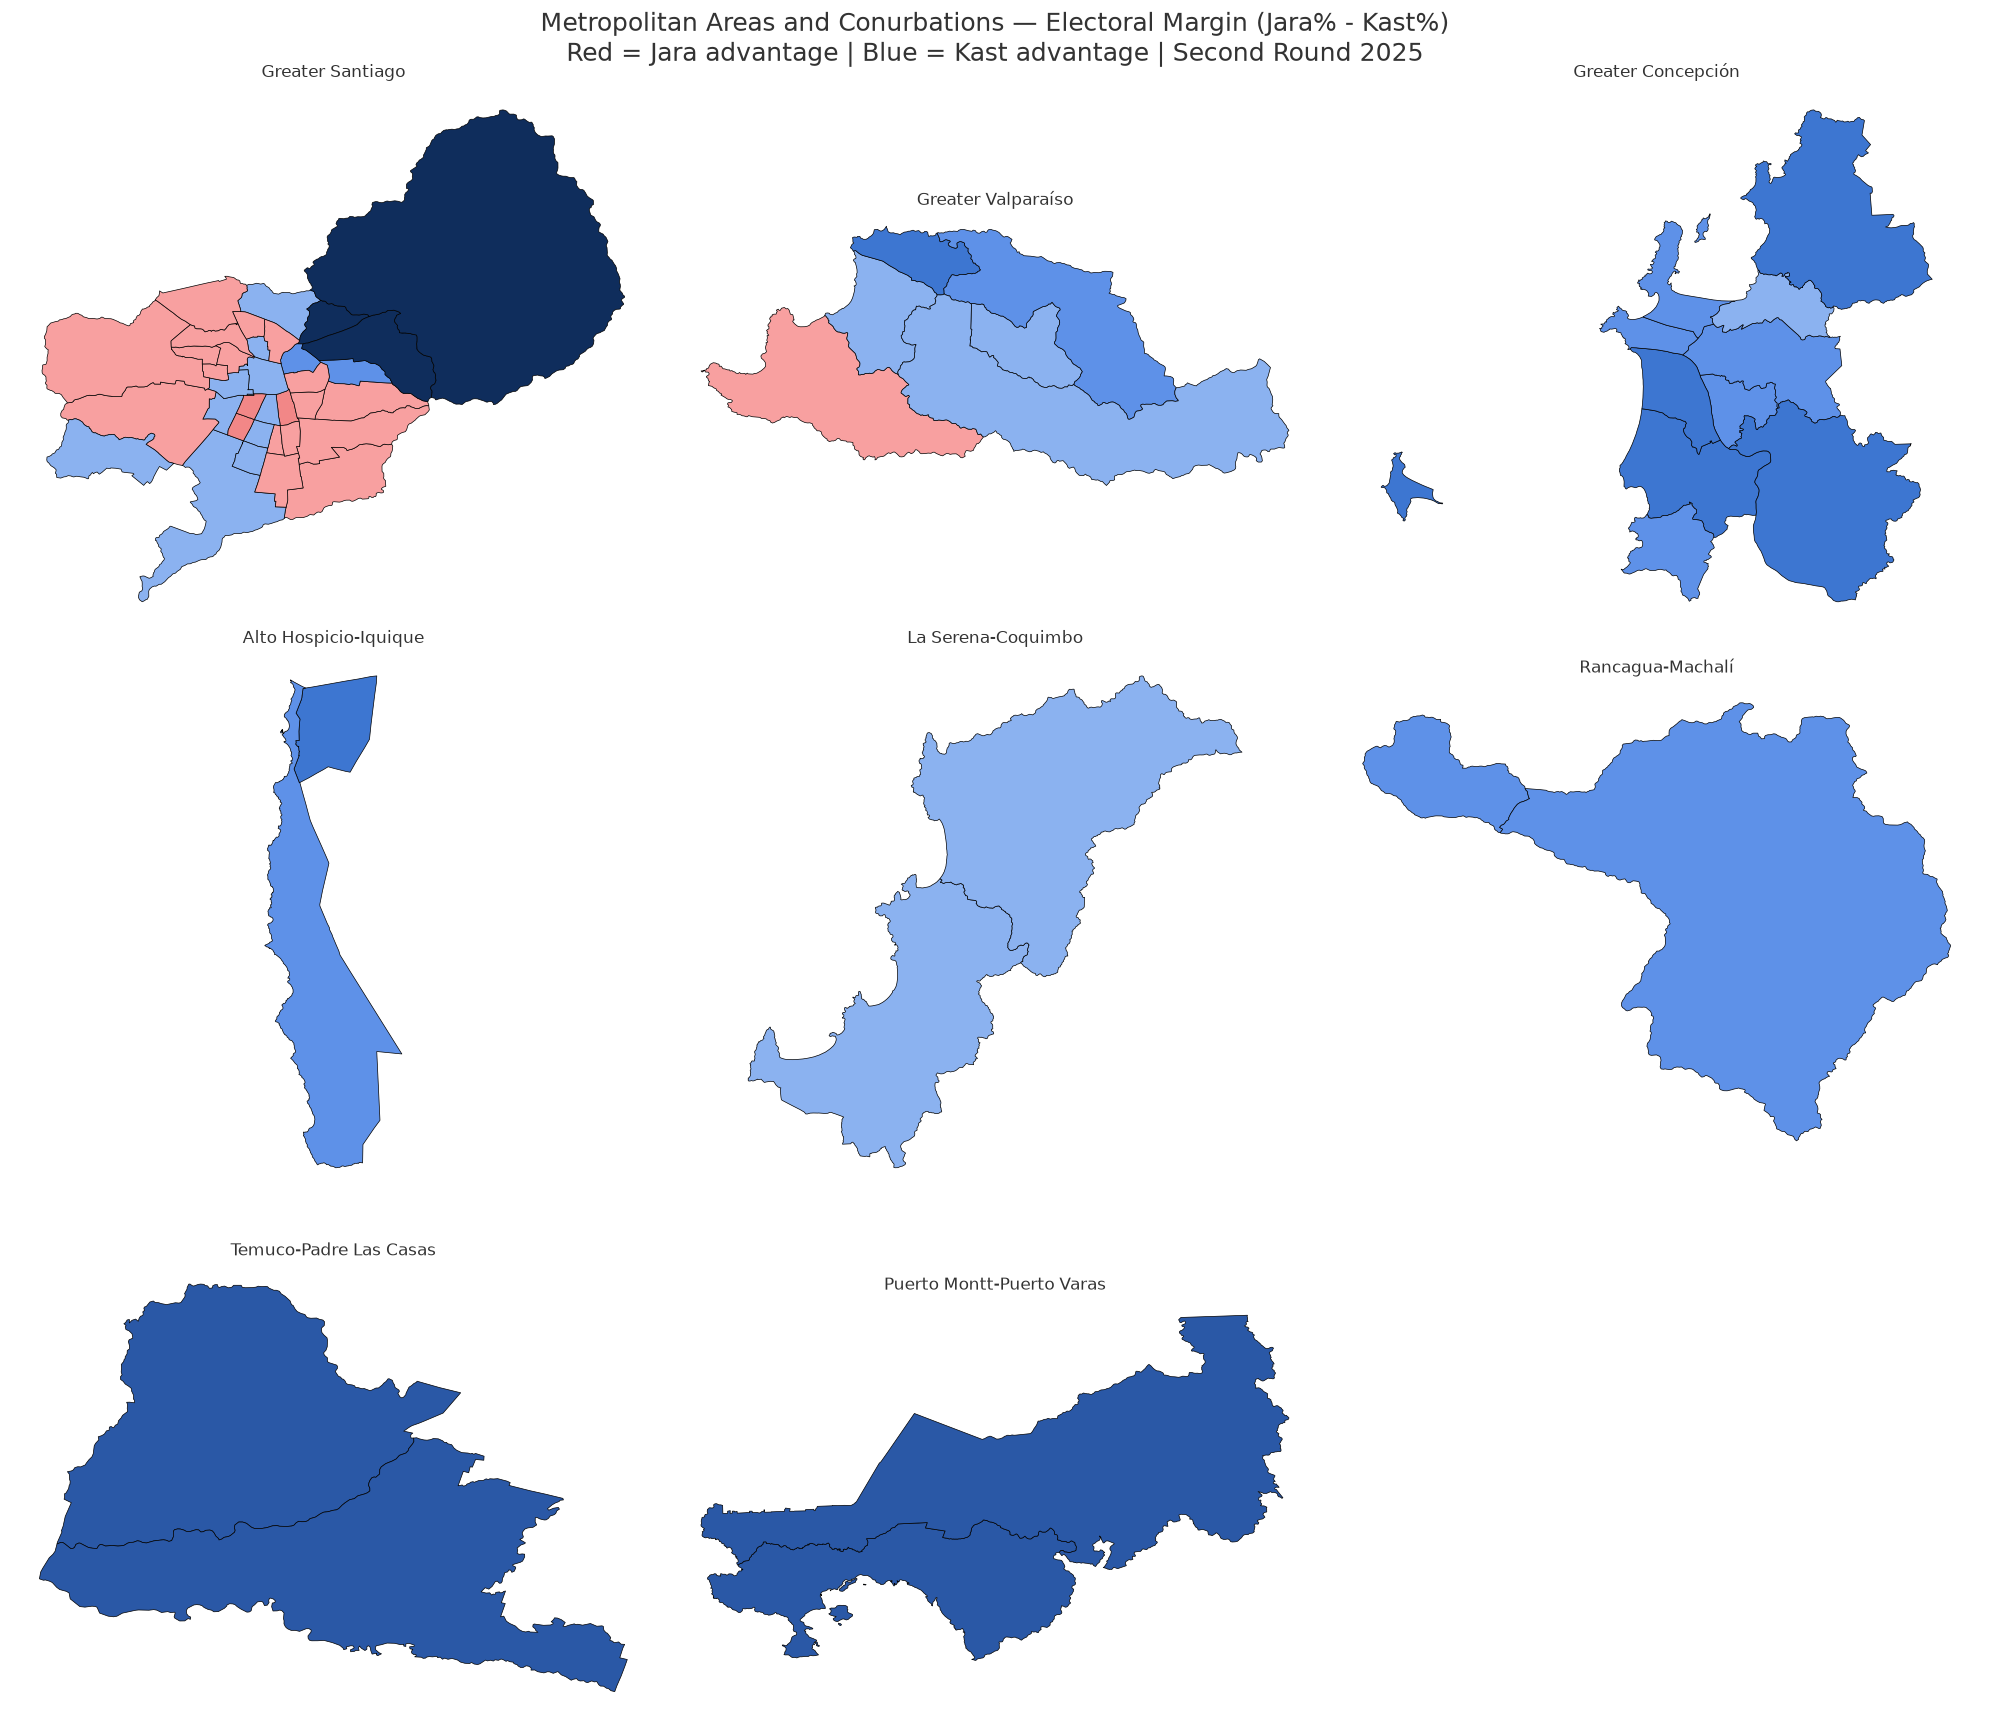

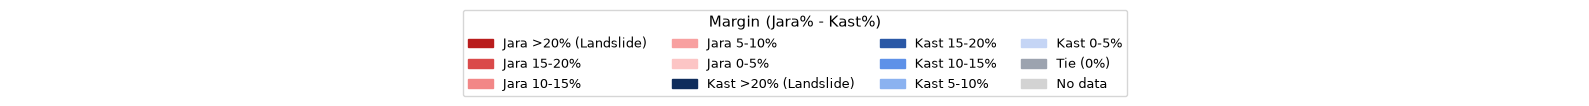

In [640]:
# ============================================================================
# METROPOLITAN AREAS — ELECTORAL MARGIN MAP — SECOND ROUND 2025
# ============================================================================
# Renders commune-level Jara−Kast margin choropleths for Greater Santiago,
# Greater Valparaíso and Greater Concepción using the shared map_data_v2 join.
# ============================================================================

# ---------------------------------------------------------------------------
# 1. MARGIN COLOR FUNCTION (Diverging scale: Red=Jara, Blue=Kast)
# ---------------------------------------------------------------------------

def assign_margin_color(diferencia):
    """
    Assigns hex color based on percentage difference (Jara% - Kast%).
    
    Red tones = Jara advantage (positive difference)
    Blue tones = Kast advantage (negative difference)
    Gray = Tie or No data
    """
    if pd.isna(diferencia):
        return "#D3D3D3"
    
    if diferencia == 0:
        return "#9CA3AF"
    
    if diferencia > 0:  # Jara wins
        if diferencia >= 50:
            return "#B91C1C"      # Very dark red
        elif diferencia >= 40:
            return "#C92A2A"      # Dark red
        elif diferencia >= 30:
            return "#DA4A4A"      # Medium-dark red
        elif diferencia >= 20:
            return "#E86969"      # Medium red
        elif diferencia >= 10:
            return "#F28787"      # Light red
        else:
            return "#F8A0A0"      # Very light red
    else:  # Kast wins (negative difference)
        diferencia_abs = abs(diferencia)
        if diferencia_abs >= 50:
            return "#0F2D5C"      # Very dark blue
        elif diferencia_abs >= 40:
            return "#1A3D7C"      # Dark blue
        elif diferencia_abs >= 30:
            return "#2A58A6"      # Medium-dark blue
        elif diferencia_abs >= 20:
            return "#3D76D1"      # Medium blue
        elif diferencia_abs >= 10:
            return "#5E91E8"      # Light blue
        else:
            return "#8BB2F0"      # Very light blue

# ---------------------------------------------------------------------------
# 2. PREPARE DATA WITH MARGIN CALCULATION
# ---------------------------------------------------------------------------

# Validate que communes y df_2025_v2 existen
assert 'communes' in dir(), "'communes' GeoDataFrame not found. Run the geographic data loader cell first."
    
assert 'df_2025_v2' in dir(), "'df_2025_v2' not found. Run the second-round data loader cell first."

# Dependency check: normalize_commune_name
assert 'normalize_commune_name' in dir(), "'normalize_commune_name' not defined. Run the commune normalizer cell first."
    
communes_map = communes.copy()
communes_map['NOM_COM_NORM'] = communes_map['NOM_COM'].apply(normalize_commune_name)

# Prepare second round data with margin
df_votes_v2 = df_2025_v2.copy()
df_votes_v2['commune_norm'] = df_votes_v2['commune'].apply(normalize_commune_name)
df_votes_v2['margin'] = df_votes_v2['jara_pct'] - df_votes_v2['kast_pct']

# Spatial join: merge geometries with margin data
map_data_v2 = communes_map.merge(
    df_votes_v2[['commune_norm', 'margin']],
    left_on='NOM_COM_NORM',
    right_on='commune_norm',
    how='left',
)

# Apply color based on margin
map_data_v2['color'] = map_data_v2['margin'].apply(assign_margin_color)

# Exclude island communes
map_data_v2 = map_data_v2[~map_data_v2['NOM_COM'].str.contains('Isla de Pascua|Juan Fernández', case=False, na=False)]

print("✅ map_data_v2 with margin created successfully")
print(f"   Margin range: {map_data_v2['margin'].min():.2f} to {map_data_v2['margin'].max():.2f}")
print(f"   Total records: {len(map_data_v2)}")
print(f"   Null margins: {map_data_v2['margin'].isna().sum()}")

# ---------------------------------------------------------------------------
# 3. METROPOLITAN AREAS AND CONURBATIONS (8 areas)
# ---------------------------------------------------------------------------

GREATER_SANTIAGO = [
    "Cerrillos", "Cerro Navia", "Conchalí", "El Bosque", "Estación Central",
    "Huechuraba", "Independencia", "La Cisterna", "La Florida", "La Granja",
    "Providencia", "Las Condes", "La Reina", "Lo Espejo", "Lo Prado", "Macul",
    "Maipú", "Ñuñoa", "Padre Hurtado", "Pedro Aguirre Cerda", "Peñalolén",
    "Vitacura", "Pudahuel", "Puente Alto", "Quilicura", "Quinta Normal",
    "Recoleta", "Renca", "San Bernardo", "San Joaquín", "San Miguel",
    "San Ramón", "Santiago", "Lo Barnechea", "La Pintana",
]

GREATER_VALPARAISO = [
    "Valparaíso", "Viña del Mar", "Concón", "Quilpué", "Villa Alemana", "Limache",
]

GREATER_CONCEPCION = [
    "Concepción", "Coronel", "Chiguayante", "Hualpén", "Hualqui", "Lota",
    "Penco", "San Pedro de la Paz", "Talcahuano", "Tomé",
]

ALTO_HOSPICIO_IQUIQUE = ["Alto Hospicio", "Iquique"]
LA_SERENA_COQUIMBO = ["La Serena", "Coquimbo"]
RANCAGUA_MACHALI = ["Rancagua", "Machalí"]
TEMUCO_PADRE_LAS_CASAS = ["Temuco", "Padre Las Casas"]
PUERTO_MONTT_PUERTO_VARAS = ["Puerto Montt", "Puerto Varas"]

# ---------------------------------------------------------------------------
# 4. GRID LAYOUT (3x3 for 8 areas, bottom-right empty) WITH CONSISTENT STYLING
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(3, 3, figsize=(20, 18))
fig.patch.set_facecolor('white')
fig.suptitle(
    'Metropolitan Areas and Conurbations — Electoral Margin (Jara% - Kast%)\n'
    'Red = Jara advantage | Blue = Kast advantage | Second Round 2025',
    fontsize=18, y=0.98, color='#333333'
)

# Grid: (row, col) -> (title, commune_list)
grid_config = [
    (0, 0, 'Greater Santiago', GREATER_SANTIAGO),
    (0, 1, 'Greater Valparaíso', GREATER_VALPARAISO),
    (0, 2, 'Greater Concepción', GREATER_CONCEPCION),
    (1, 0, 'Alto Hospicio-Iquique', ALTO_HOSPICIO_IQUIQUE),
    (1, 1, 'La Serena-Coquimbo', LA_SERENA_COQUIMBO),
    (1, 2, 'Rancagua-Machalí', RANCAGUA_MACHALI),
    (2, 0, 'Temuco-Padre Las Casas', TEMUCO_PADRE_LAS_CASAS),
    (2, 1, 'Puerto Montt-Puerto Varas', PUERTO_MONTT_PUERTO_VARAS),
]

for row, col, title, commune_list in grid_config:
    ax = axes[row, col]
    norm_set = {normalize_commune_name(c) for c in commune_list}
    area_data = map_data_v2[map_data_v2['NOM_COM_NORM'].isin(norm_set)].copy()
    
    # (match count logged during development; remove in production)

    if area_data.empty:
        ax.text(0.5, 0.5, f'No data\n{title}',
                ha='center', va='center', transform=ax.transAxes,
                fontsize=12, color='#333333')
        ax.set_title(title, fontsize=12, color='#333333')
        ax.set_axis_off()
        continue

    # Plot using margin-based colors
    area_data.plot(ax=ax, color=area_data['color'], edgecolor='black', linewidth=0.5)
    ax.set_title(title, fontsize=12, color='#333333')
    ax.set_axis_off()
    ax.set_aspect('equal')

# Hide unused bottom-right cell
axes[2, 2].set_visible(False)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------------
# 5. LEGEND (Diverging color scale) WITH CONSISTENT STYLING
# ---------------------------------------------------------------------------
fig_legend, ax_legend = plt.subplots(figsize=(16, 1))
fig_legend.patch.set_facecolor('white')
ax_legend.set_facecolor('white')
ax_legend.set_axis_off() 

legend_elements = [
    # Jara advantage (red tones)
    mpatches.Patch(color='#B91C1C', label='Jara >20% (Landslide)'),
    mpatches.Patch(color='#DA4A4A', label='Jara 15-20%'),
    mpatches.Patch(color='#F28787', label='Jara 10-15%'),
    mpatches.Patch(color='#F8A0A0', label='Jara 5-10%'),
    mpatches.Patch(color='#FCC5C5', label='Jara 0-5%'),
    # Kast advantage (blue tones)
    mpatches.Patch(color='#0F2D5C', label='Kast >20% (Landslide)'),
    mpatches.Patch(color='#2A58A6', label='Kast 15-20%'),
    mpatches.Patch(color='#5E91E8', label='Kast 10-15%'),
    mpatches.Patch(color='#8BB2F0', label='Kast 5-10%'),
    mpatches.Patch(color='#C5D5F5', label='Kast 0-5%'),
    # Neutral
    mpatches.Patch(color='#9CA3AF', label='Tie (0%)'),
    mpatches.Patch(color='#D3D3D3', label='No data'),
]

ax_legend.legend(
    handles=legend_elements, 
    loc='center', 
    ncol=4, 
    fontsize=9,
    title='Margin (Jara% - Kast%)', 
    title_fontsize=11,
    frameon=True,
    facecolor='white',
    edgecolor='#cccccc'
)

plt.tight_layout()
plt.show()

#### Analysis by Metropolitan Area

##### Greater Santiago: Intra-Urban Polarisation

Greater Santiago, which concentrates more than 40% of the country's electoral register, presents the sharpest contrast of the 2025 electoral map, confirming the persistence of the fracture between the eastern and western sectors of the capital that has characterised its electoral geography since the return to democracy.

In **eastern Santiago** — Las Condes, Vitacura, Providencia, Lo Barnechea, La Reina and Ñuñoa — Kast obtained victories with margins exceeding 20% in several communes, confirming the consolidation of the right-wing vote among the highest-income strata. That in communes such as Las Condes and Vitacura the blank vote also increased significantly (+1.09 pp and +1.15 pp respectively) suggests, however, that even within these sectors a fraction of the electorate did not feel fully represented by Kast, likely linked to the traditional right of Evelyn Matthei that did not fully validate the republican candidacy.

In **the centre and north-east** — Santiago Centre, Estación Central, Cerrillos, Huechuraba, Recoleta and Independencia — the competition was tighter, with margins generally between 0% and 5%. In communes such as El Bosque, the difference between Jara and Kast was below 1%. This behaviour reflects a more heterogeneous electorate in socioeconomic and political terms, where the middle-class vote and working-class sectors confronted the conservative vote in an unstable equilibrium.

In the **south and west** — Puente Alto, Maipú, La Florida, Pedro Aguirre Cerda, Lo Espejo, La Granja, Renca, Conchalí and other working-class communes — Jara maintained her most solid strongholds, with margins that in several cases exceeded 5%. These communes, of greater population density and greater presence of public employment and social services, constituted the hard core of support for the ruling-coalition candidate, confirming that the left-wing vote in the capital remained concentrated in territories with the greatest tradition of trade union and neighbourhood organisation.

##### Greater Valparaíso: Resistance Enclaves

Greater Valparaíso combines a general predominance of Kast with significant enclaves where Jara managed to prevail or maintain high competitiveness. Kast won the majority of communes in the metropolitan area — 33 of 38 at the regional level — although in several of them with tight margins.

The most relevant resistance enclave of Jara is the city of **Valparaíso** itself, where the ruling-coalition candidate prevailed by a significant margin. This port city, with a long left-wing tradition and a high density of working-class population and trade union presence, maintained its political identity despite Kast's general advance in the region. In **Concón**, Kast obtained an advantage of between 10% and 15%; in **Limache**, of between 5% and 10%; and in the remaining communes of Greater Valparaíso — Viña del Mar, Quilpué, Villa Alemana, among others — Kast's advantage was between 0% and 5%, reflecting that Jara maintained significant competitiveness without managing to prevail in these communes.

##### Greater Concepción: The Most Homogeneous Dominance

Greater Concepción presents the most homogeneous panorama among the country's main metropolitan areas: broad Kast dominance across the entire area, with limited Jara resistance. In most of its communes — Talcahuano, Hualpén, Chiguayante, San Pedro de la Paz, Coronel, Lota, among others — Kast obtained margins of between 10% and 20%, a notable result considering that Greater Concepción has historically been a territory with a strong trade union tradition and a high density of working-class population linked to the fishing, port and forestry industries.

The only exception to this dominance is the centre of **Concepción**, where Jara was more competitive, though without prevailing: Kast's advantage in this commune was between 0% and 5%, suggesting that the left-wing vote maintained some presence in the urban core, where universities, public services and social organisations are concentrated, while in the peripheries and industrial communes the vote tilted predominantly towards Kast.

##### Iquique-Alto Hospicio: Parisi Vote Transfer

The Iquique-Alto Hospicio conurbation shows a clear Kast dominance, reflecting an effective transfer of the anti-establishment vote towards the conservative right. In **Iquique**, Kast obtained an advantage of between 10% and 15%; in **Alto Hospicio**, of between 15% and 20%. Both communes had been Franco Parisi strongholds in the first round. The Iquique case is particularly relevant because Jara had won the commune in the first round, making it a temporary left-wing stronghold in the region — a result that Kast reversed with a solid margin in the runoff.

##### La Serena-Coquimbo: The Most Competitive Conurbation

The La Serena-Coquimbo conurbation was, after Greater Santiago and Valparaíso, the metropolitan area where Jara maintained her greatest competitiveness: although Kast prevailed in both communes, the margin was below 5% in both cases. Jara's capacity to maintain such a narrow difference suggests that the left-wing vote in Norte Chico retains a significant base, linked to the presence of working-class sectors, public employment and social organisation in both cities.

##### Rancagua-Machalí: Sign Change Between Cycles

The Rancagua-Machalí conurbation shows Kast dominance in both communes, with margins of between 10% and 15%. The most relevant pattern is the cyclical behaviour of both: **Rancagua**, the regional capital of O'Higgins, which both Jara in 2025 and Boric in 2021 had won in the first round, was reversed by Kast in this runoff. **Machalí**, which in 2021 had been won by Boric in the second round after a first round favourable to Kast, consolidated in 2025 its support for the republican candidate, reflecting a trend towards the right in the periphery of the regional capital.

##### Temuco-Padre Las Casas and Puerto Montt-Puerto Varas: Bastions of the South

These two conurbations represent the most solid bastions of the conservative right in the south of the country: in both, the difference between Kast and Jara exceeded 20% in most communes. Their shift towards the conservative right, initiated in 2021, consolidated in 2025 with support levels that exceed 60% in most communes of La Araucanía and Los Lagos, confirming that rural and provincial southern Chile has become the electoral heartland of this political sector.

##### Strategic Implications

Electoral behaviour in the main metropolitan areas reveals that political polarisation in Chile is not limited to the urban-rural fracture, but also runs through the interior of cities. In Greater Santiago, this fracture is particularly sharp: the east voted massively for Kast, while the south and west remained as Jara strongholds, a socio-spatial polarisation that poses social cohesion challenges for the new government.

That Jara maintained her strongholds in the most densely populated zones of the country suggests that the left-wing vote retains a solid territorial base in urban working-class sectors, despite the general defeat. The high competitiveness in La Serena-Coquimbo and Valparaíso confirms that, in some intermediate and port cities, the left-wing vote maintains a significant presence. In contrast, Kast's dominance in Greater Concepción — historically a left-wing zone — suggests that the electoral realignment towards the right was not limited to rural zones, but also reached intermediate cities with a different political tradition, representing an additional challenge for the Chilean left in its efforts to reconnect with the urban electorate.

#### Conclusion 7.4.

The analysis of metropolitan areas and conurbations confirms that territorial polarisation is not limited to the urban-rural fracture, but also runs through the interior of cities. In Greater Santiago, the division between the east — Kast's stronghold — and the south and west — Jara's stronghold — reflects socioeconomic inequalities that translate into differentiated electoral behaviours. In Greater Valparaíso, Jara maintained resistance enclaves in the port city, while Kast dominated the rest of the conurbation. In Greater Concepción, Kast achieved broad dominance in a historically left-wing zone, reflecting the reach of the electoral realignment in intermediate cities. In the other conurbations analysed — Iquique-Alto Hospicio, La Serena-Coquimbo, Rancagua-Machalí, Temuco-Padre Las Casas and Puerto Montt-Puerto Varas — the pattern was predominantly favourable to Kast, with intensities ranging from high competitiveness in La Serena-Coquimbo to historic dominance in the south. This metropolitan map confirms that Kast's victory was territorially broad, but not homogeneous: more solid in the peripheries and in higher-income sectors, while Jara maintained her resistance in the capital's working-class strongholds and in some port cities.

### Chapter 7 Conclusion: The Territorial Map

The territorial analysis confirms that José Antonio Kast's victory was not only broad in popular votes, but constituted a communal hegemony without precedent in recent Chilean electoral history. With 310 communes won (89.6% of the total) and victories in all 16 regions of the country, Kast built a geographic base that combines three distinct political worlds: the anti-establishment north — where he captured a large portion of Franco Parisi's vote —, the Santiago elite — where he consolidated the support of the traditional right — and the rural-conservative Chile of the south — where his cultural and ideological base runs deepest. This territorially diverse coalition contrasts with the geographic concentration of support for Jeannette Jara, limited to 36 urban communes — mainly in the southern and western sectors of Greater Santiago — and some northern mining enclaves.

The disaggregation by macrozone and metropolitan area reveals, however, that Kast's dominance was not homogeneous in intensity. In the Norte Grande and Norte Chico, where Parisi had been strongest in the first round, Kast won the majority of communes but with tighter margins and with enclaves where Jara managed to prevail or maintain high competitiveness — especially in mining communes with a strong trade union tradition — confirming that the transfer of the anti-establishment vote towards the right was substantial but incomplete. In the Centre, polarisation was sharper: eastern Santiago tilted strongly towards Kast, while the southern and western sectors of the capital remained as solid Jara strongholds. In the Centre-South, South and Patagonia, by contrast, Kast's dominance was broad and virtually uncontested, consolidating his territorial base in rural and provincial Chile.

The challenge for the new government will be to translate this territorial hegemony into effective public policies that respond to the demands of a diverse and geographically dispersed electorate, in a context of parliamentary fragmentation where the Senate operates as a veto actor requiring negotiation for any substantive reform. The capacity of the new government to reduce the territorial gaps that contributed to shaping this electoral map — particularly in decentralisation, productive development and improvement of public services in rural zones — will be a relevant factor for the legitimacy and sustainability of its mandate. The persistence of Jara resistance enclaves in Greater Santiago, Valparaíso and the northern mining belt suggests that the territorial fracture running through Chile will not be resolved by a change of government alone, but requires sustained policies addressing the structural inequalities that feed it.

---

## 8. Jeannette Jara's Territorial Performance: Urban Strength and Structural Limits

### Introduction

The analysis of Jeannette Jara's territorial performance reveals a pattern of highly concentrated support that confirms her role as the candidate of urban, working-class and densely populated Chile, but which also evidences the structural fragility of her coalition. Of the 36 communes won with an absolute majority, 58% are located in the Metropolitan Region, 28% in the northern mining belt and 14% in Valparaíso: an electorate combining urban working-class sectors with a tradition of social organisation, mining enclaves with a strong trade union presence, and coastal communes of progressive tradition. However, this concentration also reveals a weakness: her support was confined to an archipelago of urban and mining strongholds, with no capacity to expand towards rural, provincial or peripheral Chile. The sections that follow examine her narrow losses, the flips achieved in the north, her retention and growth capacity, and the impact of the protest vote on her performance, allowing both the magnitude of her defeat and the structural opportunities and limitations facing the coalition she represented in the medium term to be understood.

### 8.1. Jara's Strongholds: Urban-Popular Chile

The 36 communes where Jara exceeded 50% of valid votes delineate with precision the profile of her coalition. The Metropolitan Region concentrates 58% of these strongholds (21 communes), primarily in the working-class western and southern sectors of Santiago, with results such as Pedro Aguirre Cerda (58.75%), Lo Espejo (56.17%), San Joaquín (55.60%) and Puente Alto (53.75%). The northern mining belt contributes 10 communes — distributed among Antofagasta, Atacama and Coquimbo — where Jara captured part of the vote that in the first round had backed Parisi, reflecting her capacity to connect with labour and trade union demands in extractive zones. Valparaíso contributes 5 communes, including the port city, San Antonio and the islands of Juan Fernández and Isla de Pascua, maintaining part of the coastal progressive tradition. Together, this map confirms Jara as the candidate of urban, working-class and densely populated Chile, but also reveals her principal structural weakness: support highly dependent on the Metropolitan Region, with no capacity for expansion towards rural and peripheral Chile.

In [641]:
# ============================================================================
# COMMUNES WHERE JARA ACHIEVED AN ABSOLUTE MAJORITY (>50%)
# ============================================================================
# Filters second-round data to communes where Jara exceeded 50% of valid
# votes and returns a ranked table with regional breakdown.
# ============================================================================

def analyze_jara_absolute_majority(df: pd.DataFrame) -> pd.DataFrame:
    """
    Identifies communes where Jara achieved absolute majority (>50%).
    
    Parameters
    ----------
    df : pd.DataFrame
        Second round data with columns: commune, region, jara_pct, kast_pct
    
    Returns
    -------
    pd.DataFrame
        DataFrame with commune, region, jara_pct, result
    """
    df_filtered = df[df['jara_pct'] > 50].copy()
    df_filtered = df_filtered.sort_values('jara_pct', ascending=False)
    df_filtered['result'] = df_filtered['jara_pct'].apply(
        lambda x: 'Wins in this commune'
    )
    
    return df_filtered[['commune', 'region', 'jara_pct', 'result']]

# Execute analysis
jara_strongholds = analyze_jara_absolute_majority(df_2025_v2)
print(f"Jara achieved absolute majority in {len(jara_strongholds)} communes")
print("\nTop 10 communes:")
jara_strongholds.head(36)

Jara achieved absolute majority in 36 communes

Top 10 communes:


,commune,region,jara_pct,result
299,Juan Fernandez,Valparaíso,59.29,Wins in this commune
252,Pedro Aguirre Cerda,Metropolitana,58.75,Wins in this commune
244,Lo Espejo,Metropolitana,56.17,Wins in this commune
264,San Joaquin,Metropolitana,55.60,Wins in this commune
65,Andacollo,Coquimbo,55.29,Wins in this commune
298,Isla de Pascua,Valparaíso,54.47,Wins in this commune
313,San Antonio,Valparaíso,53.85,Wins in this commune
258,Puente Alto,Metropolitana,53.75,Wins in this commune
275,la Granja,Metropolitana,53.50,Wins in this commune
15,Chañaral,Atacama,53.43,Wins in this commune


#### Analysis

##### Geographic Distribution of the Strongholds

The Metropolitan Region contributes 21 communes (58% of the total), all in working-class sectors of the southern and western sectors of Greater Santiago, with high social vulnerability indices and a long tradition of neighbourhood and trade union organisation: Pedro Aguirre Cerda (58.75%), Lo Espejo (56.17%), San Joaquín (55.60%), Puente Alto (53.75%), La Granja (53.50%), Lo Prado (52.90%), Conchalí (52.60%), Maipú (52.37%), Quilicura (52.35%), San Ramón (52.31%), La Pintana (52.13%), Cerro Navia (51.70%), Pudahuel (51.39%), Macul (51.17%), Recoleta (51.17%), Ñuñoa (51.11%), La Florida (50.91%), Peñalolén (50.63%) and Quinta Normal (50.52%).

The northern mining belt contributes 10 communes (28%), distributed among Antofagasta (3), Atacama (4) and Coquimbo (3): Chañaral (53.43%), Diego de Almagro (53.35%), Huasco (51.98%) and Caldera (50.39%) in Atacama; Mejillones (51.42%), San Pedro de Atacama (50.68%) and María Elena (50.47%) in Antofagasta; and Andacollo (55.29%), Canela (52.98%) and Illapel (50.76%) in Coquimbo. These communes share a strong mining tradition, trade union presence and dependence on large-scale mining and public employment.

Valparaíso contributes 5 communes (14%): Juan Fernández (59.29%), Isla de Pascua (54.47%), San Antonio (53.85%), Valparaíso (53.16%) and Petorca (52.79%). Valparaíso and San Antonio are ports with a high density of working-class population and trade union presence; Juan Fernández and Isla de Pascua are island enclaves with their own political dynamics, economies linked to tourism and fishing, and high dependence on the central state for basic services.

##### A Common Socioeconomic Profile

Jara's strongholds share a profile that distinguishes them from the rest of the country. The literature on Chilean electoral behaviour has documented that the left-wing vote tends to concentrate in communes with high population density, higher formal educational levels, a lower proportion of rural population and a greater presence of public employment and social services. Puente Alto — the country's most populous commune, with more than half a million inhabitants — illustrates this pattern: there Jara obtained 53.75% of the vote and more than 190,000 valid votes, her principal electoral strength in terms of volume, but also the symptom of her principal weakness: support concentrated in a small number of highly populous communes, with no capacity to expand towards rural and peripheral Chile.

##### The Northern Mining Belt: Capturing the Parisi Vote

The behaviour of the northern mining communes is relevant because, in the first round, the majority had backed Franco Parisi. The migration of a fraction of that electorate towards Jara in the second round suggests that, faced with a bipolar offer between the ruling-coalition candidate and a conservative right-wing candidate, they opted for the option perceived as less threatening to their economic and labour interests — a behaviour consistent with the economic voting literature, which documents the tendency of the electorate to support options perceived as protective of their sectoral interests in contexts of high uncertainty.

##### Implications for Jara's Coalition

The concentration of support for Jara in a small number of urban and mining communes has a dual reading. On the one hand, it reflects the persistence of a solid support core in urban working-class sectors — Pedro Aguirre Cerda, Lo Espejo, Puente Alto — that constitutes a mobilisable electoral base for future processes. On the other, it evidences the difficulty of her coalition in connecting with rural, provincial and peripheral Chile, a structural challenge that, if not addressed, could persistently limit its competitiveness in future national elections.

#### Conclusion 8.1.

The map of Jeannette Jara's strongholds confirms her role as the candidate of urban, working-class and densely populated Chile. With 36 communes won with an absolute majority — 58% in the Metropolitan Region, 28% in the northern mining belt and 14% in Valparaíso — her electorate combines urban working-class sectors with a strong tradition of social organisation, mining enclaves with a significant trade union presence, and coastal communes of progressive tradition. This concentration, however, also evidences the structural weakness of her coalition: support confined to an archipelago of urban and mining strongholds, with no capacity to expand towards rural, provincial or peripheral Chile. The lack of territorial breadth constitutes a fundamental challenge for the coalition she represented, which will need to develop a broader territorial strategy if it aspires to compete more evenly in the rural and peripheral zones of the country.

### 8.2. The Competitive Communes: Narrow Losses and Future Opportunities

#### 8.2.1. The Tightest Communes: Margins Below 2 Points

The communes where Kast won by fewer than 2 percentage points reveal the most competitive territories of the runoff and the principal vulnerabilities of the right-wing candidate in an otherwise broadly favourable map. These 6 communes — El Bosque (0.42 pp), Tocopilla (0.62 pp), Freirina (1.28 pp), Estación Central (1.40 pp), Peñaflor (1.68 pp) and El Tabo (1.68 pp) — represent the narrowest margins of the entire election and are concentrated in three types of territory: three working-class or lower-middle-class communes of the Metropolitan Region, two northern mining enclaves that had been Parisi strongholds in the first round, and one coastal enclave in Valparaíso. Although Jara lost the election, these results show that she retained a solid floor in key segments of the electorate, and that several of these communes — particularly El Bosque and Estación Central, with margins below 1.5 points — could change hands in a future electoral cycle if the political conditions are different.

In [642]:
# ============================================================================
# COMMUNES WHERE JARA ALMOST WON: MARGIN UNDER 2 PP (KAST WINS)
# ============================================================================
# Identifies communes where Kast won by fewer than 2 percentage points —
# the minimum recoverable set under a counterfactual Jara mobilisation.
# ============================================================================

def analyze_close_communes(df: pd.DataFrame) -> pd.DataFrame:
    """
    Identifies communes where Kast's margin over Jara is ≤ 2 percentage points.
    
    Parameters
    ----------
    df : pd.DataFrame
        Second round data with columns: commune, region, jara_pct, kast_pct
    
    Returns
    -------
    pd.DataFrame
        DataFrame with commune, region, jara_pct, kast_pct, kast_margin_pp, competitiveness
    """
    df_filtered = df[df['kast_pct'] > df['jara_pct']].copy()
    df_filtered['kast_margin_pp'] = round(df_filtered['kast_pct'] - df_filtered['jara_pct'], 2)
    df_filtered = df_filtered[df_filtered['kast_margin_pp'] <= 2].copy()
    
    df_filtered['competitiveness'] = df_filtered['kast_margin_pp'].apply(
        lambda x: 'Ultra-tight (<1pp)' if x <= 1 else 'Competitive (1-2pp)'
    )
    
    df_filtered = df_filtered.sort_values('kast_margin_pp', ascending=True)
    
    return df_filtered[['commune', 'region', 'jara_pct', 'kast_pct', 'kast_margin_pp', 'competitiveness']]

# Execute analysis
close_communes = analyze_close_communes(df_2025_v2)
print(f"Jara almost won in {len(close_communes)} communes (margin ≤ 2pp)")
print("\nAll close communes:")
close_communes

Jara almost won in 6 communes (margin ≤ 2pp)

All close communes:


,commune,region,jara_pct,kast_pct,kast_margin_pp,competitiveness
236,El Bosque,Metropolitana,49.79,50.21,0.42,Ultra-tight (<1pp)
8,Tocopilla,Antofagasta,49.69,50.31,0.62,Ultra-tight (<1pp)
18,Freirina,Atacama,49.36,50.64,1.28,Competitive (1-2pp)
238,Estacion Central,Metropolitana,49.30,50.70,1.40,Competitive (1-2pp)
253,Peñaflor,Metropolitana,49.16,50.84,1.68,Competitive (1-2pp)
296,El Tabo,Valparaíso,49.16,50.84,1.68,Competitive (1-2pp)


##### Analysis

The 6 communes with a margin below 2 points confirm that Jara maintained high competitiveness in key segments of the electorate, even where she ultimately failed to prevail. The territorial distribution of these communes is illustrative: El Bosque (0.42 pp) and Estación Central (1.40 pp) are working-class communes of the Metropolitan Region with a high density of formal and informal employment and a trade union presence; Tocopilla (0.62 pp) and Freirina (1.28 pp) are northern mining and fishing enclaves where Jara managed to capture part of the Parisi vote without it proving sufficient to prevail; Peñaflor (1.68 pp) is a lower-middle-class commune in expansion, with a mixed profile between rural and urban; and El Tabo (1.68 pp) is a coastal enclave in Valparaíso with high electoral volatility.

The most relevant datum in this subset is El Bosque: a Kast victory by just 0.42 percentage points — equivalent to approximately 277 votes — in a commune where Jara was the top vote-getter in the first round. This result, which could have been reversed by a minimally different mobilisation of the ruling-coalition electorate or by a lower null vote in the locality, illustrates the thin line separating Jara from expanding the number of communes she won in the Metropolitan Region.

From a comparative perspective, the existence of only 6 communes in the range of margins below 2 points — in an election decided by 16.48 points nationally — confirms that this was not a closely fought election in general terms, but a broad Kast triumph that left very limited spaces for real dispute on the territorial map. The 6 tightest communes represent, combined, less than 2% of the total analysed, confirming the depth of Kast's territorial dominance and the structural limits of Jara's electoral base.

##### Strategic Implications

The communes with margins below 2 points configure the first territorial expansion front for Jara's coalition in future electoral cycles. In particular, El Bosque and Estación Central represent communes "recoverable" for the left if the party or coalition heading the next candidacy manages to reduce the null vote and mobilise low-participation voters more effectively. In the north — Tocopilla and Freirina — the contestability is greater, given that the Parisi electorate remains volatile and that the transfer towards the right in the runoff may not reproduce itself if the political context changes.

##### Conclusion 8.2.1

The communes with margins below 5 points constitute the map of electoral opportunities for Jara's coalition in future cycles. Although limited in number — 26 communes out of a total of 346 — these communes concentrate a relevant portion of the national electoral register, including regional capitals such as Antofagasta, La Serena and Coquimbo, and highly populous communes such as San Bernardo and Viña del Mar. The key to reconquering these territories will lie in the coalition's capacity to reduce the null vote — which in many of these communes was decisive — and to mobilise low-participation voters more effectively in zones where the sociodemographic profile is, in principle, more favourable to the left or centre-left. The volatility of the northern electorate — where the Parisi vote was decisive and where the transfer towards Kast was substantial but incomplete — suggests that these communes are potentially recoverable, although under what specific conditions exceeds the scope of this analysis.

#### 8.2.2. Communes Lost by a Narrow Margin: 2 to 5 Points

The range of communes where Kast won with a margin of between 2 and 5 points includes 20 communes that broaden Jara's competitive map beyond the handful of tightest results. This second competitiveness tier concentrates in three types of territory: working-class and lower-middle-class communes of the Metropolitan Region — such as Cerrillos, Huechuraba, La Cisterna, La Granja and San Bernardo —; coastal and industrial cities of Valparaíso such as Viña del Mar and Valdivia; and northern mining enclaves such as Antofagasta, La Serena and Coquimbo. Together, the 26 communes with margins below 5 points (6 in the below-2 range + 20 in the 2–5 range) constitute the potentially contested territory that Jara's coalition would need to prioritise in a future electoral cycle to aspire to a more competitive result. The presence of large communes such as Antofagasta, Viña del Mar and San Bernardo in this range confirms that Jara's vote was not limited to secure strongholds, but also maintained competitiveness in territories of high population density and variable electoral profile.


COMMUNES WHERE JARA LOST BY MARGIN <5% — BY GEOGRAPHIC ZONE



macrozone,Norte Grande,Norte Chico,Centro,Centro Sur,Sur,Patagonia,TOTAL
margin_range,,,,,,,
0-1%,1,0,1,0,0,0,2
1-2%,0,1,3,0,0,0,4
2-3%,0,0,4,0,0,0,4
3-4%,1,1,1,0,0,0,3
4-5%,0,1,3,0,0,0,4
TOTAL,2,3,12,0,0,0,17


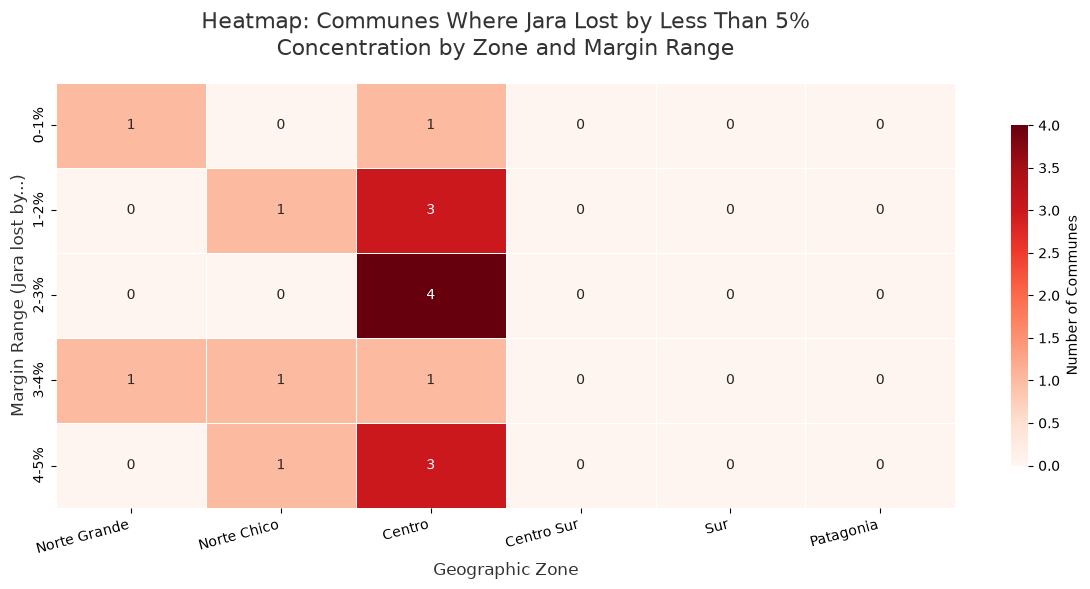

In [643]:
# ============================================================================
# JARA NARROW LOSSES BY GEOGRAPHIC ZONE AND MARGIN RANGE
# ============================================================================
# Cross-tabulates communes where Jara lost by <5 pp against geographic zone
# and margin band; outputs contingency and percentage tables plus a heatmap.
# ============================================================================

# ---------------------------------------------------------------------------
# 1. COMPUTE MARGIN AND ATTACH GEOGRAPHIC ZONE
# ---------------------------------------------------------------------------

# Compute margin (Jara% - Kast%) - negative values = Jara loses
df_2025_v2['margin'] = df_2025_v2['jara_pct'] - df_2025_v2['kast_pct']

# Filter communes where Jara lost by less than 5% (margin between -5 and 0)
df_narrow = df_2025_v2[
    (df_2025_v2['margin'] < 0) & 
    (df_2025_v2['margin'] >= -5)
].copy()
df_narrow['margin_abs'] = df_narrow['margin'].abs()

# Append geographic zone
df_narrow = df_narrow.merge(
    df_region_dim[['region', 'macrozone']],
    on='region',
    how='left'
)

# ---------------------------------------------------------------------------
# 2. BIN MARGINS INTO RANGE CATEGORIES
# ---------------------------------------------------------------------------

def get_margin_range(margin_abs):
    if margin_abs < 1:
        return '0-1%'
    elif margin_abs < 2:
        return '1-2%'
    elif margin_abs < 3:
        return '2-3%'
    elif margin_abs < 4:
        return '3-4%'
    else:
        return '4-5%'

df_narrow['margin_range'] = df_narrow['margin_abs'].apply(get_margin_range)

# ---------------------------------------------------------------------------
# 3. CONTINGENCY TABLE: ZONE × MARGIN RANGE
# ---------------------------------------------------------------------------

# Zone order (north to south)
zone_order = ['Norte Grande', 'Norte Chico', 'Centro', 'Centro Sur', 'Sur', 'Patagonia']

# Range order
range_order = ['0-1%', '1-2%', '2-3%', '3-4%', '4-5%']

# Build pivot table
pivot_table = pd.crosstab(
    df_narrow['margin_range'],
    df_narrow['macrozone'],
    dropna=False
)

# Reorder index and columns
pivot_table = pivot_table.reindex(index=range_order, columns=zone_order, fill_value=0)

# Append total row per zone
pivot_table.loc['TOTAL'] = pivot_table.sum(axis=0)

# Append total column per range
pivot_table['TOTAL'] = pivot_table.sum(axis=1)

# ---------------------------------------------------------------------------
# 4. DISPLAY CONTINGENCY TABLE
# ---------------------------------------------------------------------------

print("\n" + "=" * 80)
print("COMMUNES WHERE JARA LOST BY MARGIN <5% — BY GEOGRAPHIC ZONE")
print("=" * 80)
print()
display(pivot_table)
print()
print("=" * 80)

# ---------------------------------------------------------------------------
# 5. HEATMAP VISUALIZATION
# ---------------------------------------------------------------------------

def plot_narrow_losses_heatmap(pivot_table: pd.DataFrame) -> None:
    """
    Creates a heatmap showing the concentration of narrow losses.
    """
    # Remove TOTAL row and column for plotting
    plot_df = pivot_table.drop(index='TOTAL', errors='ignore').drop(columns='TOTAL', errors='ignore')
    
    # Order of zones (north to south)
    zone_order = ['Norte Grande', 'Norte Chico', 'Centro', 'Centro Sur', 'Sur', 'Patagonia']
    zones = [zone for zone in zone_order if zone in plot_df.columns]
    plot_df = plot_df[zones]
    
    fig, ax = plt.subplots(figsize=(12, 6))
    fig.patch.set_facecolor('white')
    
    # Create heatmap with a clean red palette
    sns.heatmap(
        plot_df,
        annot=True,
        fmt='g',
        cmap='Reds',
        linewidths=0.5,
        linecolor='white',
        ax=ax,
        cbar_kws={'label': 'Number of Communes', 'shrink': 0.8}
    )
    
    ax.set_xlabel('Geographic Zone', fontsize=12, color='#333333')
    ax.set_ylabel('Margin Range (Jara lost by...)', fontsize=12, color='#333333')
    ax.set_title(
        'Heatmap: Communes Where Jara Lost by Less Than 5%\n'
        'Concentration by Zone and Margin Range',
        fontsize=16, pad=20, color='#333333',
    )
    
    # Rotate x-axis labels for better readability
    plt.xticks(rotation=15, ha='right')
    
    plt.tight_layout()
    plt.show()

# Execute the heatmap
plot_narrow_losses_heatmap(pivot_table)

##### Analysis

The 20 communes in the 2–5 point range consolidate Jara's competitiveness map and broaden the territorial horizon of her coalition beyond the 6 tightest cases. Several of these communes share characteristics that allow a profile of the contested electorate to be identified.

In the **Metropolitan Region**, Cerrillos (2.11 pp), Huechuraba (2.59 pp), La Cisterna (2.64 pp), San Miguel (2.83 pp) and San Bernardo (4.49 pp) stand out: lower-middle-class to middle-class communes, with a high presence of formal and informal employment, and where Jara's first-round vote was solid but insufficient to consolidate a clear advantage. The presence of San Bernardo — one of the most populous communes in the region — in this range is relevant: with more than 200,000 inhabitants, it represents a volume of contested votes that could be decisive in a closer election.

In the **north**, the presence of Antofagasta (3.14 pp), La Serena (2.84 pp) and Coquimbo (3.70 pp) in this range confirms that the northern regional capitals — where the Parisi electorate carried significant weight — operated as zones of high contestability. In Antofagasta, Jara was just 3.14 points from prevailing: a difference equivalent to approximately 6,800 votes in a city where the null vote increased by more than 13,000 between the first and second round. Had a fraction of that null vote migrated towards the ruling-coalition candidate, the result in the city could have been different.

In **Valparaíso**, the presence of Viña del Mar (3.34 pp) and Villa Alemana (4.08 pp) suggests that, in the region's coastal and intermediate cities, Jara's vote maintained a significant presence without achieving the critical mass needed to prevail. That Viña del Mar — the region's second most populous city — was left with a margin below 3.5 points confirms that the ruling-coalition candidate's vote had reach in middle-class cities beyond her strictly working-class strongholds.

##### Implications for Jara's Coalition

The full set of 26 competitive communes (margins below 5 points) configures the principal territorial expansion front for Jara's coalition in future electoral cycles. These communes, which include regional capitals, intermediate cities and working-class communes of the Metropolitan Region, represent together a relevant portion of the national electoral register. Their common characteristic is the presence of a volatile electorate — which was disputed between Kast, Jara and the null vote — and which, under different conditions, could tilt towards any of the available options.

##### Conclusion 8.2.2.

The communes with margins below 5 points constitute the map of electoral opportunities for Jara's coalition in future cycles. Although limited in number — 26 communes out of a total of 346 — these communes concentrate a relevant portion of the national electoral register, including regional capitals such as Antofagasta, La Serena and Coquimbo, and highly populous communes such as San Bernardo and Viña del Mar. The key to reconquering these territories will lie in the coalition's capacity to reduce the null vote — which in many of these communes was decisive — and to mobilise low-participation voters more effectively in zones where the sociodemographic profile is, in principle, more favourable to the left or centre-left. The volatility of the northern electorate — where the Parisi vote was decisive and where the transfer towards Kast was substantial but incomplete — suggests that these communes are potentially recoverable, although under what specific conditions exceeds the scope of this analysis.

#### 8.2.3. Important Flips: Communes that Changed Sign in the North

One of the most relevant findings of the communal analysis is Jeannette Jara's capacity to "flip" — change sign — communes that in the first round had been won by another candidate. This phenomenon concentrated notably in the north, where several communes that in November had backed Franco Parisi migrated towards Jara in the runoff, evidencing her capacity to capture part of the anti-establishment electorate in territories with specific labour and trade union demands. The following table shows the communes where Jara won the second round despite not having been the top vote-getter in the first round.


PERCENTAGE DISTRIBUTION BY ZONE (each column sums to 100%)



macrozone,Norte Grande,Norte Chico,Centro,Centro Sur,Sur,Patagonia
margin_range,,,,,,
0-1%,50.0,0.0,8.3,0.0,0.0,0.0
1-2%,0.0,33.3,25.0,0.0,0.0,0.0
2-3%,0.0,0.0,33.3,0.0,0.0,0.0
3-4%,50.0,33.3,8.3,0.0,0.0,0.0
4-5%,0.0,33.3,25.0,0.0,0.0,0.0


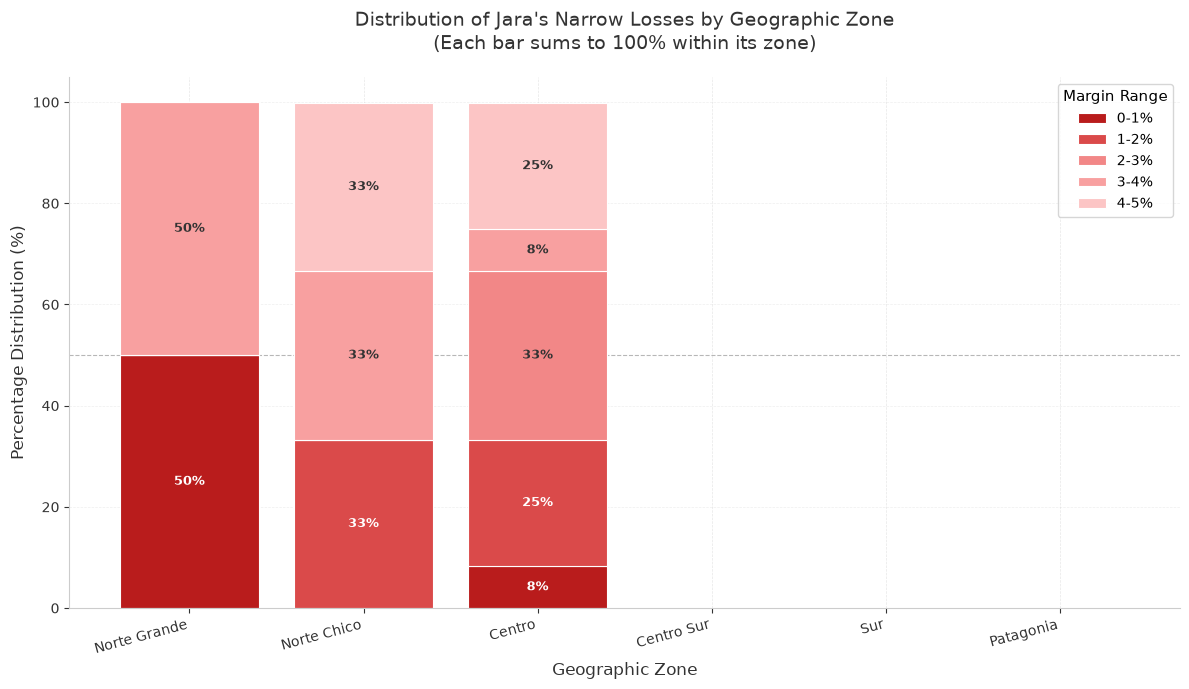

In [644]:
# ============================================================================
# VISUALIZATION: DISTRIBUTION OF JARA NARROW LOSSES BY GEOGRAPHIC ZONE
# ============================================================================
# Stacked bar chart showing how communes where Jara lost by <5 pp distribute
# across margin bands within each geographic zone (columns sum to 100%).
# ============================================================================

# ---------------------------------------------------------------------------
# 1. RECOMPUTE PERCENTAGE TABLE (columns sum to 100%)
# ---------------------------------------------------------------------------

# Use the same pivot_table from previous analysis
# Compute percentage by column (zone) - EACH COLUMN SUMS TO 100%
try:
    pct_by_zone = pivot_table.drop(index='TOTAL', errors='ignore').drop(columns='TOTAL', errors='ignore')
    pct_by_zone = pct_by_zone.div(pct_by_zone.sum(axis=0), axis=1) * 100
    pct_by_zone = pct_by_zone.round(1).fillna(0)
    
    # Reorder zones from north to south
    zone_order = ['Norte Grande', 'Norte Chico', 'Centro', 'Centro Sur', 'Sur', 'Patagonia']
    zones = [zone for zone in zone_order if zone in pct_by_zone.columns]
    pct_by_zone = pct_by_zone[zones]
except NameError:
    print("ERROR: 'pivot_table' is not defined. Please run the previous analysis first.")
    raise

# ---------------------------------------------------------------------------
# 2. DISPLAY PERCENTAGE TABLE
# ---------------------------------------------------------------------------

print("\n" + "=" * 80)
print("PERCENTAGE DISTRIBUTION BY ZONE (each column sums to 100%)")
print("=" * 80)
print()

# Display table
try:
    from IPython.display import display
    display(pct_by_zone)
except (ImportError, NameError):
    print(pct_by_zone.to_string())

print()
print("=" * 80)

# ---------------------------------------------------------------------------
# 3. STACKED BAR CHART
# ---------------------------------------------------------------------------

def plot_stacked_margin_bars(pct_df: pd.DataFrame) -> None:
    """
    Creates a stacked bar chart showing the distribution of margin ranges by zone.
    Each bar sums to 100%, showing the composition of narrow losses across
    different geographic zones.
    
    Parameters
    ----------
    pct_df : pd.DataFrame
        DataFrame with margin ranges as index and zones as columns,
        containing percentage values that sum to 100% per column.
    """
    # Check if DataFrame is empty
    if pct_df.empty:
        print("WARNING: DataFrame is empty. Cannot generate chart.")
        return
    
    # Define colors for each margin range
    margin_colors = {
        '0-1%': '#B91C1C',      # Dark red (most urgent)
        '1-2%': '#DA4A4A',      # Medium-dark red
        '2-3%': '#F28787',      # Medium red
        '3-4%': '#F8A0A0',      # Light red
        '4-5%': '#FCC5C5'       # Very light red (least urgent)
    }
    
    # Define text color based on background color
    def get_text_color(background_color, value):
        """Return white or black based on background color and value threshold"""
        light_colors = ['#FCC5C5', '#F8A0A0', '#F28787']
        if background_color in light_colors:
            return '#333333'  # Black for light backgrounds
        else:
            return 'white'    # White for dark backgrounds
    
    # Reorder ranges (from narrowest to widest)
    range_order = ['0-1%', '1-2%', '2-3%', '3-4%', '4-5%']
    
    # Filter to only available ranges
    available_ranges = [r for r in range_order if r in pct_df.index]
    if not available_ranges:
        print("WARNING: No margin ranges found in DataFrame.")
        return
    
    plot_df = pct_df.reindex(available_ranges)
    
    # Check if there's valid data to plot
    if plot_df.empty or plot_df.isnull().all().all():
        print("WARNING: No valid data to plot.")
        return
    
    fig, ax = plt.subplots(figsize=(12, 7))
    fig.patch.set_facecolor('white')
    ax = set_clean_style(ax)
    
    # Build stacked bars
    bottom = np.zeros(len(plot_df.columns))
    
    for margin_range in available_ranges:
        if margin_range in plot_df.index:
            values = plot_df.loc[margin_range].values
            bars = ax.bar(
                plot_df.columns,
                values,
                bottom=bottom,
                label=margin_range,
                color=margin_colors[margin_range],
                edgecolor='white',
                linewidth=0.8,
                zorder=2
            )
            bottom += values
    
    # Add percentage labels inside bars (only for significant values)
    for i, zone in enumerate(plot_df.columns):
        cumulative = 0
        for margin_range in available_ranges:
            if margin_range in plot_df.index:
                value = plot_df.loc[margin_range, zone]
                if value > 8:  # Display only values >8% to avoid clutter
                    bg_color = margin_colors[margin_range]
                    text_color = get_text_color(bg_color, value)
                    ax.text(
                        i, cumulative + value/2,
                        f'{value:.0f}%',
                        ha='center', va='center',
                        fontsize=9, fontweight='bold',
                        color=text_color,
                        zorder=3
                    )
                cumulative += value
    
    # Labels and title
    ax.set_xlabel('Geographic Zone', fontsize=12, color='#333333')
    ax.set_ylabel('Percentage Distribution (%)', fontsize=12, color='#333333')
    ax.set_title(
        "Distribution of Jara's Narrow Losses by Geographic Zone\n"
        '(Each bar sums to 100% within its zone)',
        fontsize=14, pad=20, color='#333333'
    )
    
    # Add reference line at 50%
    ax.axhline(y=50, color='#999999', linestyle='--', linewidth=0.8, alpha=0.7, zorder=1)
    
    # Set y-axis limits to ensure 100% is visible
    ax.set_ylim(0, 105)
    
    # Customize legend
    ax.legend(
        title='Margin Range',
        title_fontsize=11,
        loc='upper right',
        fontsize=10,
        frameon=True,
        facecolor='white',
        edgecolor='#cccccc'
    )
    
    # Style adjustments
    ax.tick_params(axis='both', colors='#333333', labelsize=10)
    plt.xticks(rotation=15, ha='right')
    
    # Add subtle gridlines for better readability
    ax.grid(axis='y', alpha=0.2, linestyle='--', linewidth=0.5)
    
    plt.tight_layout()
    plt.show()

# Generate the chart
plot_stacked_margin_bars(pct_by_zone)

##### Analysis

The analysis of "flips" — communes where the runoff winner was different from the first-round winner — reveals one of Jara's most relevant electoral strategies in the runoff: the capture of the Parisi vote in territories with a strong labour and trade union identity. This phenomenon concentrates exclusively in the north: all communes where Jara managed to flip were Parisi strongholds in the first round, with economies dominated by mining, industrial fishing or state employment linked to the extraction of natural resources.

The most relevant case by volume is **Antofagasta** — although Jara did not reach an absolute majority in the city, she did so in several communes of the province — followed by **María Elena** (Antofagasta), **Mejillones** (Antofagasta) and **Diego de Almagro** (Atacama), all communes with a strong mining tradition where the trade unions of large copper and lithium mining have a significant presence. The fact that Jara managed to prevail in territories where Parisi was the top vote-getter in the first round suggests that, in these specific zones, the class vote and labour demands weighed more than anti-establishment identification or ideological affinity with the right.

The absence of flips outside the north is equally significant: in no region of the centre, south or Patagonia did Jara manage to reverse the result of communes that in the first round had backed Kast, Matthei or Kaiser. This limitation confirms that her capacity to capture votes from outside her coalition was circumscribed to territories with a specific combination of variables — trade union tradition, economic dependence on large-scale mining, high labour organisation — that does not reproduce itself in the rest of the country.

The flip pattern has an additional strategic reading: in many of the communes where Jara managed to flip, the null vote also increased significantly. This suggests that the candidate not only captured votes from Parisi, but also managed to mobilise her own base in territories where she had no consolidated prior presence. That the flipping occurred primarily in small and medium northern communes — and not in the macrozone's large cities — indicates that Jara's strategy was more effective in the most trade-union-organised territories, where the social capital of labour organisations can compensate for the weakness of the party structure.

##### Implications

The northern flips confirm that Jara's coalition has the capacity for territorial expansion beyond its natural strongholds, provided it manages to articulate a discourse that connects with the labour and sectoral demands of specific communities. However, the concentration of this phenomenon in the northern mining belt suggests that it is a niche strategy, not easily replicable across the rest of the country. The challenge for the centre-left coalition will be to develop a discourse capable of reaching the rural and peripheral electorate more broadly, beyond the specific trade union demands of extractive zones.

##### Conclusion 8.2.3.

Jara's flips in the northern mining belt are one of the most relevant findings of the territorial analysis: they reveal that the ruling-coalition candidate had the capacity to capture part of the anti-establishment electorate in territories with a strong labour and trade union identity, reversing the sign of communes that in the first round had backed Franco Parisi. This phenomenon, however, was confined exclusively to the north, without replicating itself in any other region of the country, confirming that it was an effective strategy in a specific niche — mining communes with high labour organisation — that failed to generalise. The absence of flips in the centre, south and Patagonia confirms the structural limits of Jara's electoral base and poses the challenge of developing a broader territorial expansion strategy for future electoral cycles.

### 8.3. Jara's Flips: Partial Capture of the Anti-Establishment Vote in the North

One of the most relevant findings of the communal analysis is Jeannette Jara's capacity to reverse the sign of communes that in the first round had backed another candidate. This phenomenon — known in comparative electoral analysis as a "flip" — concentrated notably in the northern mining belt, where several communes that in November had backed Franco Parisi migrated towards Jara in the runoff, evidencing her capacity to capture part of the anti-establishment electorate in territories with specific labour and trade union demands.


COMMUNES WHERE JARA LOST IN FIRST ROUND AND WON IN SECOND



,commune,region,winner_first_round,jara_pct_1v,jara_pct_2v,jara_swing_pp
2,Maria Elena,Antofagasta,Parisi,22.27,50.47,28.20
3,Mejillones,Antofagasta,Parisi,26.99,51.42,24.43
17,Diego de Almagro,Atacama,Parisi,30.65,53.35,22.70
15,Chañaral,Atacama,Parisi,30.99,53.43,22.44
19,Huasco,Atacama,Parisi,30.20,51.98,21.78
5,San Pedro de Atacama,Antofagasta,Parisi,31.88,50.68,18.80


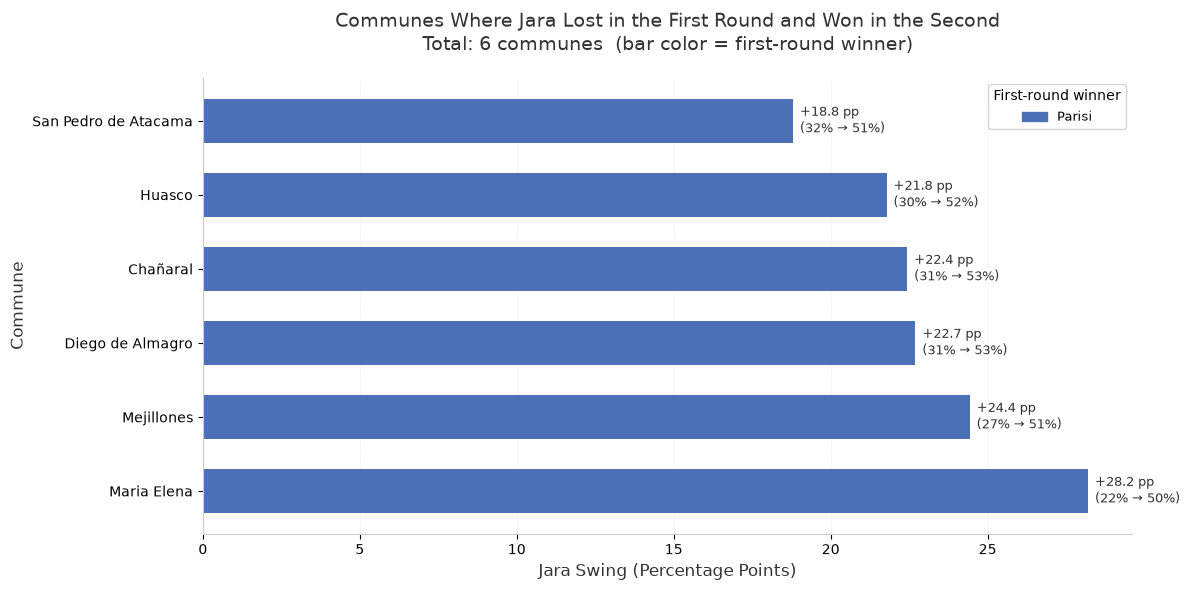

In [645]:
# ============================================================================
# COMMUNES WHERE JARA FLIPPED: LOST IN ROUND 1, WON IN ROUND 2
# ============================================================================
# Joins first and second round results to identify communes where Jara was
# not the first-round winner but secured a majority in the runoff.
# ============================================================================

# ---------------------------------------------------------------------------
# 1. DETERMINE WINNERS FOR BOTH ROUNDS
# ---------------------------------------------------------------------------

# First round winners (considering all 8 candidates)
candidate_cols = ['jara_pct', 'kast_pct', 'parisi_pct', 'kaiser_pct', 
                  'matthei_pct', 'mayne_nicholls_pct', 'enriquez_ominami_pct', 'artes_pct']
candidate_names = ['Jara', 'Kast', 'Parisi', 'Kaiser', 'Matthei', 
                   'Mayne Nicholls', 'Enríquez Ominami', 'Artes']

# Find first round winner per commune
df_first = df_2025_v1.copy()
df_first['winner_first_round'] = df_first[candidate_cols].idxmax(axis=1)
winner_mapping = dict(zip(candidate_cols, candidate_names))
df_first['winner_first_round'] = df_first['winner_first_round'].map(winner_mapping)

# Find second round winner per commune
df_second = df_2025_v2.copy()
df_second['winner_second_round'] = 'Kast'
df_second.loc[df_second['jara_pct'] > df_second['kast_pct'], 'winner_second_round'] = 'Jara'
df_second.loc[df_second['jara_pct'] == df_second['kast_pct'], 'winner_second_round'] = 'Tie'

# ---------------------------------------------------------------------------
# 2. IDENTIFY FLIPPED COMMUNES (Jara lost 1st, won 2nd)
# ---------------------------------------------------------------------------

# Merge both rounds
df_flipped = df_first.merge(
    df_second[['commune', 'jara_pct', 'kast_pct', 'winner_second_round']],
    on='commune',
    suffixes=('_1v', '_2v')
)

# Calculate swing
df_flipped['jara_swing_pp'] = round(df_flipped['jara_pct_2v'] - df_flipped['jara_pct_1v'], 2)

# Filter: Jara lost first round, won second round
df_flipped = df_flipped[
    (df_flipped['winner_first_round'] != 'Jara') & 
    (df_flipped['winner_second_round'] == 'Jara')
].copy()

# Sort by swing
df_flipped = df_flipped.sort_values('jara_swing_pp', ascending=False)

# ---------------------------------------------------------------------------
# 3. DISPLAY TABLE
# ---------------------------------------------------------------------------

print("\n" + "=" * 80)
print("COMMUNES WHERE JARA LOST IN FIRST ROUND AND WON IN SECOND")
print("=" * 80)
print()

# Select columns to display
display_cols = ['commune', 'region', 'winner_first_round', 'jara_pct_1v', 'jara_pct_2v', 'jara_swing_pp']
display(df_flipped[display_cols])

print()
print("=" * 80)

# ---------------------------------------------------------------------------
# 4. HORIZONTAL BAR CHART: TOP FLIPPED COMMUNES
# ---------------------------------------------------------------------------

def plot_flipped_communes(df: pd.DataFrame) -> None:
    """
    Creates a horizontal bar chart showing communes where Jara flipped the result.
    """
    # Check if DataFrame is empty
    if df.empty:
        print("WARNING: No flipped communes found. Cannot generate chart.")
        return
    
    plot_df = df.copy()
    
    # Bar color encodes the first-round winner
    winner_colors = {
        'Parisi': '#4B70B5',
        'Kast': '#35466D',
        'Kaiser': '#F3832C',
        'Matthei': '#226FD4',
    }
    plot_df['color'] = plot_df['winner_first_round'].map(winner_colors).fillna('#D3D3D3')
    
    fig, ax = plt.subplots(figsize=(12, max(6, len(plot_df) * 0.4)))
    fig.patch.set_facecolor('white')
    ax = set_clean_style(ax)
    
    bars = ax.barh(
        plot_df['commune'],
        plot_df['jara_swing_pp'],
        color=plot_df['color'],
        linewidth=0.8,
        height=0.6,
        zorder=2
    )
    
    # Add labels showing vote evolution
    for bar, swing, jara_1v, jara_2v in zip(bars, plot_df['jara_swing_pp'], 
                                              plot_df['jara_pct_1v'], plot_df['jara_pct_2v']):
        ax.annotate(
            f'+{swing:.1f} pp\n({jara_1v:.0f}% → {jara_2v:.0f}%)',
            xy=(bar.get_width(), bar.get_y() + bar.get_height() / 2),
            xytext=(5, 0),
            textcoords='offset points',
            ha='left', va='center',
            fontsize=9, color='#333333', zorder=3
        )
    
    # Add vertical reference line at zero
    ax.axvline(x=0, color='#999999', linestyle='-', linewidth=0.8, alpha=0.5, zorder=1)
    
    ax.set_xlabel('Jara Swing (Percentage Points)', fontsize=12, color='#333333')
    ax.set_ylabel('Commune', fontsize=12, color='#333333')
    ax.set_title(
        f'Communes Where Jara Lost in the First Round and Won in the Second\n'
        f'Total: {len(df)} communes  (bar color = first-round winner)',
        fontsize=14, pad=20, color='#333333'
    )
    
    # Legend
    legend_elements = [mpatches.Patch(color=color, label=winner) 
                       for winner, color in winner_colors.items() 
                       if winner in plot_df['winner_first_round'].values]
    if legend_elements:
        ax.legend(handles=legend_elements, loc='upper right', title='First-round winner',
                  fontsize=9, frameon=True, facecolor='white', edgecolor='#cccccc')
    
    # Add grid for better readability
    ax.grid(axis='x', alpha=0.2, linestyle='--', linewidth=0.5)
    
    plt.tight_layout()
    plt.show()

# Generate chart
plot_flipped_communes(df_flipped)

#### Analysis

Jara's flips were concentrated exclusively in the north — Antofagasta, Atacama and Coquimbo — and in all cases corresponded to communes where Franco Parisi was the top vote-getter in the first round. Communes such as María Elena, Mejillones, Diego de Almagro and Andacollo share three characteristics: economies dominated by mining or industrial fishing, a high presence of trade unions linked to large-scale mining, and an electorate that in the first round opted for the anti-establishment without a clear ideological identification with the right. The migration of a fraction of that electorate towards Jara in the second round responds, under the most plausible interpretation, to the logic of the class vote: faced with a bipolar offer between a candidate who had been Minister of Labour and a conservative right-wing candidate with proposals for labour flexibilisation, a portion of the organised trade union electorate opted for the alternative they perceived as less threatening to their labour rights.

The absence of flips outside the north is equally significant: in no region of the centre, south or Patagonia did Jara manage to change the sign of communes that in the first round had backed Kast, Matthei or Kaiser. This confirms that her capacity to capture votes from outside her coalition was circumscribed to a specific niche — mining communes with high labour organisation — that does not reproduce itself in the rest of the country.

#### Conclusion 8.3.

The northern mining flips confirm that Jara's coalition has the capacity for territorial expansion beyond its natural strongholds in contexts where the class vote is decisive. However, their exclusive concentration in the north — and in communes with a very specific sociodemographic profile — limits the generalisability of this strategy. The challenge for the centre-left coalition will be to develop a narrative capable of reaching the rural and peripheral electorate more broadly, beyond the specific trade union demands of extractive zones.

### 8.4. Jara's Vote Retention: Base Solidity, Ceiling Limits

One of the most relevant characteristics of Jeannette Jara's performance in the runoff is that she did not lose any of the communes she had won in the first round. This result, which might at first glance be read as a retention achievement, actually reveals a more nuanced dynamic: the solidity of her base in her natural strongholds coexisted with an incapacity for expansion that proved decisive for the final result.

In [646]:
# ============================================================================
# COMMUNES WHERE JARA LOST VOTES BETWEEN ROUNDS (ABSOLUTE DECLINE)
# ============================================================================
# Computes the absolute vote differential for Jara between rounds and flags
# communes where her vote count declined, with a regional breakdown.
# ============================================================================

# ---------------------------------------------------------------------------
# 1. COMPUTE VOTE DIFFERENTIAL (JARA ROUND 2 – ROUND 1)
# ---------------------------------------------------------------------------

# Merge first and second round data
df_jara_change = df_2025_v1[['commune', 'region', 'jara_votes']].copy()
df_jara_change = df_jara_change.merge(
    df_2025_v2[['commune', 'jara_votes']],
    on='commune',
    suffixes=('_1v', '_2v')
)

# Calculate vote difference (negative = Jara lost votes)
df_jara_change['jara_vote_change'] = df_jara_change['jara_votes_2v'] - df_jara_change['jara_votes_1v']
df_jara_change['jara_pct_change'] = round(
    (df_jara_change['jara_votes_2v'] - df_jara_change['jara_votes_1v']) / 
    df_jara_change['jara_votes_1v'] * 100, 1
)

# Identify communes where Jara lost votes (negative change)
df_jara_loss = df_jara_change[df_jara_change['jara_vote_change'] < 0].copy()
df_jara_loss = df_jara_loss.sort_values('jara_vote_change', ascending=True)  # Most negative first

# ---------------------------------------------------------------------------
# 2. DISPLAY COMMUNES WHERE JARA LOST VOTES
# ---------------------------------------------------------------------------

print("\n" + "=" * 90)
print("COMMUNES WHERE JARA LOST VOTES (FIRST TO SECOND ROUND)")
print("=" * 90)
print()

if len(df_jara_loss) > 0:
    display_cols = ['commune', 'region', 'jara_votes_1v', 'jara_votes_2v', 'jara_vote_change', 'jara_pct_change']
    print(df_jara_loss[display_cols].to_string(index=False))
    print()
    print(f"📊 COMMUNES WITH VOTE LOSS: {len(df_jara_loss)} of {len(df_jara_change)}")
    print(f"📊 TOTAL VOTES LOST: {df_jara_loss['jara_vote_change'].sum():,.0f}")
else:
    print("✅ No communes recorded a vote loss for Jara between rounds.")
    print("   Jara maintained or increased her absolute vote count in all communes.")
    print("   (Consistent with reduced participation and higher null vote rate in round 2)")

print()
print("=" * 90)

# ---------------------------------------------------------------------------
# 3. REGIONAL SUMMARY (conditional on data availability)
# ---------------------------------------------------------------------------

if len(df_jara_loss) > 0:
    region_summary = df_jara_loss.groupby('region').agg({
        'jara_vote_change': ['count', 'sum'],
        'jara_votes_1v': 'sum',
        'jara_votes_2v': 'sum'
    }).round(0)
    
    region_summary.columns = ['communes_with_loss', 'total_votes_lost', 'total_jara_1v', 'total_jara_2v']
    region_summary = region_summary.sort_values('total_votes_lost', ascending=True)
    
    print("\n" + "=" * 90)
    print("REGIONAL SUMMARY — JARA VOTE LOSSES")
    print("=" * 90)
    print()
    print(region_summary.to_string())
    print()
    print("=" * 90)


COMMUNES WHERE JARA LOST VOTES (FIRST TO SECOND ROUND)

✅ No communes recorded a vote loss for Jara between rounds.
   Jara maintained or increased her absolute vote count in all communes.
   (Consistent with reduced participation and higher null vote rate in round 2)



#### Analysis

The fact that Jara lost none of the communes she won in the first round confirms the solidity of her electoral core in the territories where the left-wing vote has historical rootedness. However, this datum should not be read in isolation: that the candidate retained the totality of her strongholds was not sufficient to compensate for the expansion deficit towards communes where the left had historically had possibilities. In simple terms, retention was complete but growth was insufficient — a pattern consistent with a candidacy that managed to consolidate its base without broadening it sufficiently to alter the result.

Communal retention is, from a political science perspective, a necessary but not sufficient condition for competitiveness in a runoff. The literature on runoffs suggests that candidates advancing to the second round must not only maintain their base, but also capture a significant fraction of the eliminated candidates' vote — in this case, primarily that of Parisi and Matthei. Jara managed to capture part of Parisi's vote in the north, but not sufficiently to compensate for the majority flow of that electorate towards Kast.

The retention pattern also suggests that the left-wing vote in Chile has a more solid floor than the overall result might imply: 36 communes won with an absolute majority, distributed across five regions, represents a territorial base that — under different conditions, such as a higher level of competition or greater mobilisation of her electorate — could translate into a more competitive result. The key will be whether the coalition manages to articulate in future cycles an offer broader enough to reach the electorate that in 2025 opted for the null vote or for Kast as "the lesser evil."

#### Conclusion 8.4.

The complete retention of her first-round strongholds confirms that Jara's electoral floor is solid and that her support base in urban working-class communes and northern mining enclaves did not erode during the runoff campaign. However, that base solidity coexisted with a ceiling she failed to raise: the candidate could not expand significantly beyond her natural strongholds, which proved decisive in an election where the final margin exceeded 16 points. The distinction between electoral floor and ceiling is relevant for medium-term projections: if the coalition manages to articulate a broader offer capable of reaching the electorate that in 2025 opted for the null vote or for Kast, the 36 retained strongholds could be the starting point for a broader recovery.

### 8.5. Growth of the Jara Vote: Expansion in Her Strongholds

Although Jara lost the election by a wide margin, in several communes she recorded growth in her absolute vote count between the first and second round, an indicator of expansion beyond her initial electoral base. This growth, however, concentrated predominantly in her own strongholds — the working-class communes of the southern and western sectors of Greater Santiago — and in some northern mining communes, without achieving significant expansion towards territories where the left had historically had a lesser presence.

In [647]:
# ============================================================================
# COMMUNES WHERE JARA INCREASED HER VOTE SHARE (PP GAIN — ROUND 1 TO ROUND 2)
# ============================================================================
# Identifies communes where Jara grew her percentage-point share between
# rounds and ranks them by swing magnitude.
# ============================================================================

# ---------------------------------------------------------------------------
# 1. COMPUTE VOTE DIFFERENTIAL (JARA ROUND 2 – ROUND 1)
# ---------------------------------------------------------------------------

# Merge first and second round data
df_jara_change = df_2025_v1[['commune', 'region', 'jara_votes']].copy()
df_jara_change = df_jara_change.merge(
    df_2025_v2[['commune', 'jara_votes']],
    on='commune',
    suffixes=('_1v', '_2v')
)

# Calculate vote difference (positive = Jara gained votes)
df_jara_change['jara_vote_change'] = df_jara_change['jara_votes_2v'] - df_jara_change['jara_votes_1v']
df_jara_change['jara_pct_change'] = round(
    (df_jara_change['jara_votes_2v'] - df_jara_change['jara_votes_1v']) / 
    df_jara_change['jara_votes_1v'] * 100, 1
)

# Identify communes where Jara gained votes (positive change)
df_jara_gain = df_jara_change[df_jara_change['jara_vote_change'] > 0].copy()
df_jara_gain = df_jara_gain.sort_values('jara_vote_change', ascending=False)

# ---------------------------------------------------------------------------
# 2. DISPLAY TABLE
# ---------------------------------------------------------------------------

display_cols = ['commune', 'region', 'jara_votes_1v', 'jara_votes_2v', 'jara_vote_change', 'jara_pct_change']
df_jara_gain[display_cols].head(20)

,commune,region,jara_votes_1v,jara_votes_2v,jara_vote_change,jara_pct_change
258,Puente Alto,Metropolitana,130305,190717,60412,46.4
247,Maipu,Metropolitana,127656,178497,50841,39.8
0,Antofagasta,Antofagasta,60507,102890,42383,70.0
274,la Florida,Metropolitana,93752,131796,38044,40.6
320,Viña del Mar,Valparaíso,72220,106826,34606,47.9
318,Valparaiso,Valparaíso,76553,108828,32275,42.2
263,San Bernardo,Metropolitana,59001,90821,31820,53.9
269,Santiago,Metropolitana,80114,109915,29801,37.2
68,Coquimbo,Coquimbo,43918,71395,27477,62.6
137,Rancagua,Libertador,46473,72832,26359,56.7


#### Analysis

The pattern of Jara's growth between the first and second rounds confirms that Greater Santiago was the engine of her electoral expansion, but also evidences the limitations of that growth. In communes such as Puente Alto, Maipú and La Florida — her most populous strongholds — she added thousands of additional votes relative to the first round, consolidating her floor in the capital's working-class sectors. However, this growth was insufficient to compensate for the advantage accumulated by Kast nationally, especially in the centre-south regions where the right dominated overwhelmingly.

The analysis of communes where Jara recorded the greatest relative growth — in percentage-point terms, not only absolute votes — reveals an additional relevant dynamic. In some northern mining communes, Jara not only retained her votes but grew significantly, capturing part of the Parisi electorate that had not backed her in the first round. This phenomenon, already examined in section 8.3, confirms that the anti-establishment vote capture strategy was more effective in the north than in the rest of the country.

Jara's growth in middle-class communes — Ñuñoa, La Reina, Macul — also suggests that her electorate was not confined exclusively to working-class sectors, but also attracted urban middle-class voters who, faced with the runoff's polarisation, opted for the ruling-coalition candidate. However, the magnitude of this growth was insufficient to configure a new electoral base of national reach.

A datum deserving particular attention, anticipated in section 8.7, is the positive correlation between the null vote and Jara's growth in some communes: in several territories where the null vote increased sharply, Jara also recorded an increase in her vote, suggesting that the protest vote did not exclusively affect the ruling-coalition candidate — as might be inferred from a superficial reading of the overall result — but that in some cases it coexisted with growth in her base. This qualifies the narrative that the null vote was exclusively a phenomenon that harmed Jara.

#### Conclusion 8.5.

The pattern of Jara's growth between the first and second rounds confirms that Greater Santiago was her principal expansion engine, with significant growth in the most populous communes of the southern and western sectors of the capital. However, that growth was insufficient to compensate for Kast's dominance in the rest of the country, especially in the rural and provincial centre-south where the right won by margins exceeding 20% in several communes. The distinction between retention and expansion is key to understanding the result: Jara retained her entire base and expanded it in her natural strongholds, but failed to translate that expansion into significant territorial progress beyond her support core.

### 8.6. Jara's Penetration in Elite Communes: Growth Without Viability

One of the less expected findings of the analysis is the percentage growth of Jara in some elite communes of eastern Santiago — Las Condes, Providencia, Vitacura — where her initial electoral base was minimal but where, in relative terms, she experienced significant increases. This growth, though politically irrelevant in terms of the result — in Las Condes she obtained just 21.54% of valid votes, far from a majority — reveals interesting dynamics about the behaviour of the high-socioeconomic-status electorate faced with the extreme polarisation of the runoff.

In [648]:
# ============================================================================
# ELITE COMMUNE ANALYSIS: JARA PERFORMANCE IN HIGH-INCOME SANTIAGO COMMUNES
# ============================================================================
# Tracks Jara vote share across Vitacura, Las Condes, Providencia, La Reina
# and Lo Barnechea between rounds to quantify right-bloc cohesion at the top.
# ============================================================================

# ---------------------------------------------------------------------------
# 1. FILTER TARGET COMMUNES
# ---------------------------------------------------------------------------

elite_communes = ['Vitacura', 'las Condes', 'Lo Barnechea']

# Filter data for elite communes
df_elite_1v = df_2025_v1[df_2025_v1['commune'].isin(elite_communes)].copy()
df_elite_2v = df_2025_v2[df_2025_v2['commune'].isin(elite_communes)].copy()

# ---------------------------------------------------------------------------
# 2. JARA VOTE EVOLUTION IN ELITE COMMUNES
# ---------------------------------------------------------------------------

# Prepare comparison for Jara
df_jara = df_elite_1v[['commune', 'jara_votes', 'jara_pct']].copy()
df_jara = df_jara.merge(
    df_elite_2v[['commune', 'jara_votes', 'jara_pct']],
    on='commune',
    suffixes=('_1v', '_2v')
)

# Calculate changes
df_jara['jara_vote_change'] = df_jara['jara_votes_2v'] - df_jara['jara_votes_1v']
df_jara['jara_pct_change'] = round(df_jara['jara_pct_2v'] - df_jara['jara_pct_1v'], 2)

# Select columns for display
df_jara_display = df_jara[['commune', 'jara_votes_1v', 'jara_votes_2v', 'jara_vote_change', 'jara_pct_change']]
df_jara_display.columns = ['Commune', 'Jara Votes R1', 'Jara Votes R2', 'Vote Change', '% Change']

display(df_jara_display)

,Commune,Jara Votes R1,Jara Votes R2,Vote Change,% Change
0,Lo Barnechea,7577,12558,4981,6.93
1,Vitacura,5000,8552,3552,5.67
2,las Condes,28626,45777,17151,8.88


#### Analysis

The percentage growth of Jara in elite communes has a direct explanation in the runoff's polarisation: when the electoral offer is reduced to two options, a fraction of the higher-income electorate that does not identify with either — or that perceives Kast as too radical — may opt for Jara as the lesser evil, regardless of ideological affinity. This behaviour, documented in runoffs of other Latin American countries, reflects the tension between the voter's ideological preference and their assessment of which option is less damaging to their interests.

The magnitude of this relative growth in elite communes must be contextualised appropriately. In Las Condes, Jara went from a very low percentage in the first round to 21.54% in the second: a significant percentage increase, but on a very low starting base, which does not substantially modify the result in that commune. The percentage growth is, therefore, more an indicator of polarisation than a signal of real penetration into the higher-income electorate.

The most relevant datum of this finding is its inverse reading: the same phenomenon that explains Jara's growth in elite communes — the extreme polarisation of the runoff — also explains the increase in blank voting in those communes (documented in section 5.3). A fraction of Matthei's electorate opted for the blank vote rather than Jara or Kast; another, smaller fraction opted for Jara. That both phenomena coexisted in the same communes suggests that the traditional right did not migrate towards Jara en masse, but rather dispersed between the blank, support for Kast and, marginally, a vote for the ruling-coalition candidate.

#### Conclusion 8.6.

The percentage growth of Jara in elite communes is a relevant statistical finding that confirms the logic of the "rejection vote" in contexts of extreme polarisation: a fraction of the higher-income electorate opted for the ruling-coalition candidate not out of ideological affinity, but out of rejection of the conservative right-wing alternative. However, the magnitude of this growth was insufficient to configure a real electoral base in these territories, and its reading must be made in the context of the simultaneous increase in blank voting in the same communes. The runoff's polarisation generated atypical behaviours in the elite electorate, but without substantially modifying Kast's territorial dominance in eastern Santiago.

### 8.7. The Protest Vote and Jara's Performance: A Correlation that Qualifies the Narrative

The analysis of the correlation between the increase in the null vote and Jara's growth between the first and second rounds reveals a finding that counterintuitively qualifies the dominant narrative about the protest vote. The most widespread perception after the result was that the high level of null voting had primarily harmed the ruling-coalition candidate — that is, that the demobilised or discontented electorate came predominantly from her base. However, communal analysis does not unambiguously support this hypothesis.

In [649]:
# ============================================================================
# NULL AND BLANK VOTE IMPACT ON JARA — PROTEST VOTE CORRELATION ANALYSIS
# ============================================================================
# Buckets communes by protest vote increase magnitude and computes average
# Jara pp change per bucket to test whether protest voting suppressed her share.
# ============================================================================

# ---------------------------------------------------------------------------
# 1. COMPUTE INTER-ROUND CHANGES
# ---------------------------------------------------------------------------

df_impact = df_2025_v1[['commune', 'region', 'null_votes', 'blank_votes', 'jara_pct']].copy()
df_impact = df_impact.merge(
    df_2025_v2[['commune', 'null_votes', 'blank_votes', 'jara_pct']],
    on='commune',
    suffixes=('_1v', '_2v')
)

df_impact['protest_change'] = (df_impact['null_votes_2v'] - df_impact['null_votes_1v']) + (df_impact['blank_votes_2v'] - df_impact['blank_votes_1v'])
df_impact['jara_pct_change'] = round(df_impact['jara_pct_2v'] - df_impact['jara_pct_1v'], 2)

# ---------------------------------------------------------------------------
# 2. SUMMARY BY PROTEST VOTE RANGE
# ---------------------------------------------------------------------------

def get_range(x):
    if x < 0: return 'Decrease'
    if x < 500: return '0–500'
    if x < 1000: return '500–1,000'
    if x < 2000: return '1,000–2,000'
    return '>2,000'

df_impact['bucket'] = df_impact['protest_change'].apply(get_range)

tabla1 = df_impact.groupby('bucket').agg(
    comunas=('commune', 'count'),
    crecimiento_jara_pp=('jara_pct_change', 'mean')
).round(2)

tabla1 = tabla1.reindex(['Decrease', '0–500', '500–1,000', '1,000–2,000', '>2,000'])

print("\n" + "=" * 70)
print("SUMMARY BY PROTEST VOTE RANGE")
print("=" * 70)
display(tabla1)

# ---------------------------------------------------------------------------
# 3. TOP 10 COMMUNES BY PROTEST VOTE INCREASE
# ---------------------------------------------------------------------------

tabla2 = df_impact.nlargest(10, 'protest_change')[['commune', 'region', 'protest_change', 'jara_pct_change']]
tabla2.columns = ['Commune', 'Region', 'Δ Protest', 'Δ Jara (pp)']

print("\n" + "=" * 70)
print("TOP 10 COMMUNES BY PROTEST VOTE INCREASE")
print("=" * 70)
display(tabla2)


SUMMARY BY PROTEST VOTE RANGE


,comunas,crecimiento_jara_pp
bucket,,
Decrease,6,9.89
0–500,170,12.16
"500–1,000",63,14.55
"1,000–2,000",44,15.10
">2,000",63,15.67



TOP 10 COMMUNES BY PROTEST VOTE INCREASE


,Commune,Region,Δ Protest,Δ Jara (pp)
0,Antofagasta,Antofagasta,14824,20.44
258,Puente Alto,Metropolitana,11470,18.18
247,Maipu,Metropolitana,9933,15.97
278,las Condes,Metropolitana,9463,8.88
320,Viña del Mar,Valparaíso,8466,15.62
137,Rancagua,Libertador,7754,17.17
1,Calama,Antofagasta,7563,17.31
68,Coquimbo,Coquimbo,7473,19.48
274,la Florida,Metropolitana,7321,15.75
104,Temuco,La Araucanía,7203,12.86


#### Analysis

Examination of the correlation between the increase in null votes per commune and the change in Jara's percentage between the first and second rounds reveals a pattern contrary to the dominant narrative: in several communes where the null vote increased sharply, Jara also recorded an increase in her electoral participation. This positive correlation, though not universal, suggests that the null vote was not exclusively a phenomenon that harmed the ruling-coalition candidate, but that in some territories it coexisted with growth in her base.

The most plausible explanation of this pattern is as follows: in communes where the null vote grew significantly — particularly those where the Parisi electorate was dominant and where a fraction opted to annul rather than vote for Kast — the net effect on Jara's candidacy was ambiguous. On one hand, the null vote subtracted votes from the count of both candidacies; on the other, the fraction of the Parisi electorate that did opt to validate their ballot tended, in some cases, to lean towards Jara, especially in communes with a strong trade union tradition and specific labour demands.

This finding has a relevant strategic implication for Jara's coalition: if the null vote was not exclusively a vote "taken" from the ruling-coalition candidate, but rather in some territories was more neutral or even coexisted with base growth, then the narrative that "the null vote cost Jara the election" is a simplification that fails to capture the complexity of the phenomenon. A more nuanced reading suggests that the factors that determined Jara's defeat were more structural — her inability to expand beyond her natural strongholds, the erosion of Boric's government and the consolidation of the anti-establishment electorate around Kast — and that the null vote was more a symptom of that unfavourable context than a direct cause of her result.

#### Conclusion 8.7.

The analysis of the correlation between the null vote and Jara's performance qualifies the dominant narrative about the impact of the protest vote on the result. The null vote was not exclusively a phenomenon that harmed the ruling-coalition candidate: in several territories, it coexisted with growth in her base, especially in northern mining communes where the Parisi electorate dispersed between the null and a partial transfer towards Jara. Jara's defeat was, fundamentally, the result of more structural factors: the consolidation of the anti-establishment vote around Kast, the erosion of the departing government and her inability to expand beyond her natural strongholds. The null vote was a symptom of that context, not its principal cause.

### Chapter 8 Conclusion: The Territorial Performance of Jeannette Jara

The territorial analysis of Jeannette Jara's performance reveals a coherent and structurally comprehensible pattern: a candidate who retained her base completely, who achieved some significant expansions in the northern mining belt and in working-class communes of Greater Santiago, but who could not overcome the structural limits of a coalition concentrated in an archipelago of urban and mining strongholds without reach towards rural and peripheral Chile.

Her 36 strongholds — distributed among the Metropolitan Region (58%), the northern mining belt (28%) and Valparaíso (14%) — confirm that the left-wing vote in Chile maintains a solid floor but a low ceiling in contexts of high polarisation and with a right-wing candidate who managed to articulate a broad coalition. The complete retention of her first-round communes is a real asset, but insufficient against a rival who won in 310 of the country's 346 communes.

The most relevant findings of the chapter can be synthesised in four dimensions. First, base solidity: Jara retained all her first-round communes, confirming that her electoral core did not erode despite the erosion of Boric's government. Second, partial capture of the Parisi vote: her flips in the northern mining belt show expansion capacity in contexts where the class vote is decisive, though limited to a specific niche. Third, growth in strongholds: her expansion in the most populous communes of the southern and western sectors of Greater Santiago was significant in absolute terms, though insufficient to alter the overall result. Fourth, qualification of the null vote's impact: the correlation analysis shows that the null vote was not exclusively a phenomenon that harmed Jara, but that in some territories it coexisted with growth in her base, suggesting that the factors of her defeat were more structural than conjunctural.

In medium-term perspective, the challenge for the coalition that Jara represented is clear: to build a territorial strategy that allows expansion beyond its current strongholds, to connect with the rural and provincial Chile that in 2025 voted massively for Kast, and to develop a narrative that reaches the urban middle-class electorate that, faced with the runoff's polarisation, opted for the null vote, the blank or for Kast as "the lesser evil." The solidity of her electoral floor in Greater Santiago and the northern mining belt is the starting point, but it is not sufficient to build a national majority.

---

## 9. José Antonio Kast's Territorial Performance: The Construction of a Historic Coalition

### Introduction

The analysis of José Antonio Kast's territorial performance in the 2025 runoff reveals a result of exceptional proportions in Chile's recent democratic history. With 310 communes won — 89.6% of the total —, victories in all 16 regions of the country and a margin exceeding 16 points over Jeannette Jara, Kast built a territorial coalition of heterogeneous nature that is not limited to his traditional ideological strongholds: it combines the anti-establishment north — where he captured a large portion of Franco Parisi's vote —, the Santiago elite, intermediate cities of the centre-south and the rural-conservative Chile of the deep south. This territorial diversity is, in itself, one of the most relevant findings of the analysis: Kast's triumph was not that of an ideologically pure and territorially circumscribed right, but of a broad coalition that managed to articulate different types of discontent around a change proposal. The sections that follow decompose that dominance into its constituent dimensions: strongholds, victory intensity, growth, resistance to the protest vote and the urban-rural gradient.

### 9.1. Kast's Strongholds: A Territorially Diverse Coalition

José Antonio Kast's strongholds — communes where he obtained his best results in absolute and percentage votes — draw a map of high territorial diversity that challenges the idea of a territorially homogeneous conservative right. Among his top 10 communes in absolute votes are most of the country's most populous — Puente Alto, Maipú, Las Condes, Santiago, La Florida, Quilicura — confirming that his victory was not only the result of dominance in rural and provincial Chile, but also of significant penetration in the large urban centres. In percentage terms, by contrast, his list of best results is dominated by small, rural communes of La Araucanía and Los Lagos, where he exceeded 75% of valid votes.

In [650]:
# ============================================================================
# TOP 10 KAST STRONGHOLDS — HIGHEST VOTE SHARE IN THE SECOND ROUND
# ============================================================================
# Ranks communes by Kast second-round percentage and classifies each win
# by margin category (landslide, stronghold, solid, bare majority).
# ============================================================================

# Filter communes where Kast > 60%
df_kast_strongholds = df_2025_v2[df_2025_v2['kast_pct'] > 60].copy()

# Calculate margin
df_kast_strongholds['margin_pp'] = round(df_kast_strongholds['kast_pct'] - df_kast_strongholds['jara_pct'], 2)

# Add victory type
def get_victory_type(pct):
    if pct > 80:
        return 'Landslide (>80%)'
    elif pct > 70:
        return 'Stronghold (70-80%)'
    elif pct > 60:
        return 'Solid (60-70%)'
    return 'Other'

df_kast_strongholds['victory_type'] = df_kast_strongholds['kast_pct'].apply(get_victory_type)

# Get top 10
top10 = df_kast_strongholds.nlargest(10, 'kast_pct')[['commune', 'region', 'kast_pct', 'margin_pp', 'victory_type']]
top10.columns = ['Commune', 'Region', 'Kast %', 'Margin pp', 'Victory Type']

display(top10)

,Commune,Region,Kast %,Margin pp,Victory Type
282,Colchane,Tarapacá,93.81,87.62,Landslide (>80%)
272,Vitacura,Metropolitana,87.13,74.26,Landslide (>80%)
11,General Lagos,Arica y Parinacota,85.69,71.38,Landslide (>80%)
281,Camiña,Tarapacá,85.12,70.24,Landslide (>80%)
204,Empedrado,Maule,84.71,69.42,Landslide (>80%)
243,Lo Barnechea,Metropolitana,83.23,66.46,Landslide (>80%)
334,Pinto,Ñuble,79.94,59.88,Stronghold (70-80%)
330,Coihueco,Ñuble,79.71,59.42,Stronghold (70-80%)
111,los Sauces,La Araucanía,78.62,57.24,Stronghold (70-80%)
331,El Carmen,Ñuble,78.13,56.26,Stronghold (70-80%)


#### Analysis

##### The Northern Border: Capture of the Parisi Vote

The border and mining communes of the Norte Grande — Colchane, Camarones, General Lagos, Putre — show some of the most pronounced percentage increases relative to the first round, reflecting a massive transfer of Franco Parisi's vote towards Kast. These communes, of low population density but high political symbolism — especially Colchane, linked to the migration debate —, were anti-establishment strongholds in the first round and became Kast strongholds in the second, consolidating the thesis that the discourse of order, security and migration control was especially effective in the territories most exposed to irregular immigration flows.

##### The Santiago Elite: Retention of an Own Vote

In eastern Santiago — Las Condes, Vitacura, Providencia, Lo Barnechea — Kast obtained some of his best relative results among the large communes, although with a notable exception: the increase in blank voting in these same communes (documented in section 5.3) reveals that a fraction of the traditional right of Evelyn Matthei did not migrate completely towards the republican candidate. That Kast managed to prevail with margins exceeding 30% in Las Condes — the most emblematic commune of the Chilean right — confirms that his candidacy managed to articulate the higher-income electorate, though with internal fractures made visible by the blank vote increase.

##### Rural-Provincial Chile: The Deepest Cultural Base

The bulk of Kast's widest victories concentrated in rural and semi-rural communes of the centre-south and south: La Araucanía, Los Lagos, Maule, Ñuble and Los Ríos. In these territories, where the traditional right has historically had a cultural rootedness linked to social conservatism, evangelical presence and the demands of the agricultural world, Kast obtained his best percentage results, with several cases exceeding 75% and approaching overwhelming dominance. This cultural and values-based foundation is the deepest and least volatile of his coalition, constituting the core that grants him long-term electoral stability.

##### Capture of the Large Cities: A Key Datum

In absolute vote terms, the large cities are decisive: Puente Alto, Maipú and Las Condes appear among the top communes by vote volume for Kast, confirming that his victory was not only the result of rural dominance, but also of significant penetration in the country's most populous urban centres. In Puente Alto — Chile's most populous commune — Kast exceeded 50% of valid votes despite it being a historical left-wing stronghold, illustrating the depth of the 2025 electoral realignment.

#### Conclusion 9.1.

Kast's strongholds confirm that his territorial coalition was broad and heterogeneous, combining the anti-establishment north, the Santiago elite, intermediate cities and rural-conservative Chile. This diversity is, in itself, a first-order political asset: a coalition that articulates different types of electorate is more resilient to sectoral crises than one that depends on a single type of voter. The challenge for the new government will be to keep these sectors — with demands and interests not always aligned — cohesive during the presidential term.

### 9.2. Intensity of Victories: From Competitive Communes to Historic Bastions

The analysis of the intensity of Kast's victories reveals that his territorial dominance was not homogeneous in depth, but combined three types of situation: narrow victories (less than 5 points) in the north and in some sectors of Greater Santiago; solid victories (5–20 points) in most regional capitals and intermediate cities; and overwhelming victories (more than 20 points) in the rural communes of the centre-south and south, especially in La Araucanía, Los Lagos and Ñuble. This distribution has relevant strategic implications for the new government's governability: the communes of narrow victory are also those of greatest future electoral volatility, while the rural bastions of the south — where dominance exceeds 75% — constitute a solid base but with specific demands the government will need to address.

In [651]:
# ============================================================================
# KAST STRONGHOLDS SUMMARY BY VICTORY CATEGORY
# ============================================================================
# Groups the commune-level Kast wins by margin category and reports
# commune count, average Kast %, and average margin per tier.
# ============================================================================

# Filter communes where Kast won (kast_pct > 50)
df_kast_wins = df_2025_v2[df_2025_v2['kast_pct'] > 50].copy()

# Define victory type categories
def get_victory_type(pct):
    if pct > 80:
        return 'Landslide (>80%)'
    elif pct > 70:
        return 'Stronghold (70-80%)'
    elif pct > 60:
        return 'Solid (60-70%)'
    else:
        return 'Bare majority (50-60%)'

df_kast_wins['victory_type'] = df_kast_wins['kast_pct'].apply(get_victory_type)

# Calculate summary statistics
summary = df_kast_wins.groupby('victory_type').agg(
    communes_count=('commune', 'count'),
    avg_kast_pct=('kast_pct', 'mean'),
    min_kast_pct=('kast_pct', 'min'),
    max_kast_pct=('kast_pct', 'max')
).round(2)

# Calculate percentage of wins
total_wins = len(df_kast_wins)
summary['percentage_of_wins'] = round(100 * summary['communes_count'] / total_wins, 1)

# Reorder columns
summary = summary[['communes_count', 'percentage_of_wins', 'avg_kast_pct', 'min_kast_pct', 'max_kast_pct']]

# Reorder index (from highest to lowest intensity)
category_order = ['Landslide (>80%)', 'Stronghold (70-80%)', 'Solid (60-70%)', 'Bare majority (50-60%)']
summary = summary.reindex(category_order)

display(summary)

,communes_count,percentage_of_wins,avg_kast_pct,min_kast_pct,max_kast_pct
victory_type,,,,,
Landslide (>80%),6,1.9,86.62,83.23,93.81
Stronghold (70-80%),77,24.8,73.54,70.02,79.94
Solid (60-70%),137,44.2,65.11,60.01,69.95
Bare majority (50-60%),90,29.0,55.64,50.21,60.00


#### Analysis

##### Narrow Victories: The Competitive Front of the North and the Metropolitan Region

The group of communes with a victory of less than 5 points — the same analysed from Jara's perspective in section 8.2 — constitutes the highest-competitiveness front of the election. The 6 communes with a margin below 2 points (El Bosque, Tocopilla, Freirina, Estación Central, Peñaflor, El Tabo) represent the territories where the election came closest to changing sign: the sum of their total margins does not exceed 3,000 votes. That Kast managed to prevail in all of them — even in El Bosque, where the margin was just 277 votes — confirms the breadth of his territorial dominance, but also shows its limits: there are territories where his victory was marginal and where a different political context could tip the balance the other way.

##### Solid Victories: Dominance in Regional Capitals and Intermediate Cities

Most regional capitals and intermediate cities of the country recorded Kast victories in the 5–20 point range: Concepción, Temuco, Valdivia, Rancagua, Talca, Chillán and other intermediate cities of the centre and south are located in this range. The breadth of the victory in these medium-sized urban centres — which historically have had greater electoral variability than the large cities or rural zones — confirms that the rightward realignment also reached urban middle-class sectors that in earlier cycles had backed centre or centre-left options.

##### Overwhelming Victories: The Bastions of the Rural South

The group of communes where Kast exceeded a 20-point advantage includes much of the rural south of the country, particularly the regions of La Araucanía, Los Lagos and Ñuble. Some of these communes — such as Padre Hurtado, Freire, Vilcún and Nueva Imperial — recorded results above 70% for Kast, levels that reflect both the depth of conservative rootedness in these zones and the effectiveness of the security and public order discourse in territories directly affected by the Araucanía conflict.

It should be noted that in La Araucanía, Kast obtained exceptionally high results even in communes with a high density of Mapuche population, a phenomenon that deserves a nuanced reflection. The literature on electoral behaviour in zones with territorial conflict documents that perceptions of insecurity and violence can lead electorates historically identified with the left to opt for tough-on-crime candidacies, regardless of ideological affinity, when security is perceived as the principal unmet demand. That this occurred in La Araucanía — the region most affected by violence linked to the Mapuche-State conflict in recent years — is consistent with that pattern, although it does not reduce the complexity of the phenomenon to a single variable.

#### Conclusion 9.2.

The distribution of Kast's victory intensity confirms the breadth and depth of his territorial dominance. His tightest victories concentrate in the north and in some sectors of Greater Santiago, where the Parisi electorate and urban working-class sectors showed greater resistance; his most overwhelming victories are located in the rural south, where the combination of conservative rootedness, security demands and perception of state abandonment generated a massive and cohesive vote. This distribution suggests that the new government will have greater room for manoeuvre in implementing policies in its southern bastions — where citizen backing is deeper and less conditioned by local political competition — than in the north, where high electoral volatility and the persistence of the anti-establishment configure a more demanding and less predictable electorate.

### 9.3. The Rural-Provincial Heart of Kast's Victory

The analysis of communes where Kast exceeded 60% of valid votes reveals the most solid territorial core of his coalition: a bloc of rural and semi-rural communes distributed across eleven regions of the country, but with particular concentration in La Araucanía, Los Lagos, Maule and Ñuble. These territories, where support for Kast substantially exceeds the absolute majority threshold, constitute the heart of Chilean conservative right: the rural, provincial, agricultural Chile with a strong local identity and high evangelical presence that has been the engine of the right-wing vote in recent electoral cycles.

In [652]:
# ============================================================================
# KAST STRONGHOLDS BY REGION: COMMUNES WITH KAST SHARE > 60%
# ============================================================================
# Filters to communes where Kast exceeded 60% of the valid vote and
# aggregates by region with north-to-south ordering.
# ============================================================================

# Filter communes where Kast > 60%
df_kast_60plus = df_2025_v2[df_2025_v2['kast_pct'] > 60].copy()

# Calculate margin
df_kast_60plus['margin_pp'] = round(df_kast_60plus['kast_pct'] - df_kast_60plus['jara_pct'], 2)

# Total strongholds
total_strongholds = len(df_kast_60plus)

# Group by region
region_summary = df_kast_60plus.groupby('region').agg(
    communes_with_kast_60plus=('commune', 'count'),
    avg_kast_pct=('kast_pct', 'mean'),
    avg_margin_pp=('margin_pp', 'mean'),
    min_kast_pct=('kast_pct', 'min'),
    max_kast_pct=('kast_pct', 'max')
).round(2)

# Calculate percentage of total strongholds
region_summary['pct_of_total_strongholds'] = round(100 * region_summary['communes_with_kast_60plus'] / total_strongholds, 2)

# Reorder columns
region_summary = region_summary[['communes_with_kast_60plus', 'pct_of_total_strongholds', 
                                  'avg_kast_pct', 'avg_margin_pp', 'min_kast_pct', 'max_kast_pct']]

# Sort by number of strongholds
region_summary = region_summary.sort_values('communes_with_kast_60plus', ascending=False)

display(region_summary)

,communes_with_kast_60plus,pct_of_total_strongholds,avg_kast_pct,avg_margin_pp,min_kast_pct,max_kast_pct
region,,,,,,
La Araucanía,32,14.55,70.74,41.48,63.07,78.62
Los Lagos,28,12.73,67.05,34.09,60.53,77.96
Maule,28,12.73,70.05,40.09,60.84,84.71
Biobío,27,12.27,69.34,38.68,60.28,76.72
Libertador,22,10.00,64.53,29.06,60.01,71.44
Ñuble,21,9.55,72.44,44.88,64.02,79.94
Metropolitana,12,5.45,68.43,36.87,60.81,87.13
Valparaíso,11,5.00,62.88,25.76,60.55,66.52
Los Ríos,10,4.55,69.27,38.53,64.29,74.15


#### Analysis

The distribution of communes where Kast exceeded 60% confirms that his victory was deeper in the rural south than in any other territory of the country. La Araucanía contributes the largest number of these communes, followed by Los Lagos, Maule and Ñuble. This pattern is not new: the conservative right has historically obtained its best results in the rural south, where factors such as agricultural rootedness, the presence of evangelical churches and perceptions of insecurity — especially in La Araucanía, directly affected by the territorial conflict — generate a predisposition towards order-and-control candidacies.

What is new, or has deepened in this cycle, is the magnitude of that dominance. That Kast exceeded 70% in several communes of La Araucanía, including some with a high density of Mapuche population, suggests that his discourse of security and public order managed to reach a broader electorate than the traditional right, also capturing the vote of communities that in earlier cycles had backed centre-left options or had remained to a greater extent outside the electoral process.

The most relevant finding of this subset is its geographic concentration: 11 of the country's 16 regions contribute communes with more than 60% for Kast, but the bulk is located in the arc running from O'Higgins to Patagonia, with the Maule-Ñuble-Biobío-La Araucanía axis as the deepest heart of his electoral base. This geographic concentration has governability implications: the new government will need to balance the demands of a rural and provincial electorate with specific needs in connectivity, water, agricultural development and security, with those of the large urban centres where backing was more moderate and the population more diverse in its expectations.

#### Conclusion 9.3.

The analysis of communes where Kast exceeded 60% confirms that the rural and provincial south is the heart of his electoral coalition. This base, deep and historically stable, grants the new government a solid territorial legitimacy in provincial Chile, while also imposing concrete obligations: the demands for water, connectivity, rural security and productive development concentrated in the communes that voted for him most massively will need to be priorities of the government programme if it wishes to maintain that political capital over time.

### 9.4. Growth of the Kast Vote: Transversal Expansion Between Rounds

The analysis of Kast's growth between the first and second rounds reveals a territorially transversal expansion that consolidated his advantage in practically every corner of the country. Unlike Jara — whose growth concentrated in her own strongholds — Kast recorded increases in absolute and percentage votes in communes of very different profiles, including some former Jara strongholds, several regional capitals and northern communes where the Parisi vote had been dominant in the first round.

In [653]:
# ============================================================================
# KAST VOTE GROWTH BY REGION — FIRST ROUND TO SECOND ROUND 2025
# ============================================================================
# Aggregates Kast vote totals by region for both rounds and ranks regions
# by absolute and percentage-point growth, ordered north to south.
# ============================================================================

# ---------------------------------------------------------------------------
# 1. AGGREGATE KAST VOTES BY REGION ACROSS BOTH ROUNDS
# ---------------------------------------------------------------------------

# Append first-round regional vote totals
kast_1v = df_2025_v1.groupby('region').agg(
    kast_votes_1v=('kast_votes', 'sum'),
    total_votes_1v=('casted_votes', 'sum')
).reset_index()

# Append second-round regional vote totals
kast_2v = df_2025_v2.groupby('region').agg(
    kast_votes_2v=('kast_votes', 'sum'),
    total_votes_2v=('casted_votes', 'sum')
).reset_index()

# Merge
kast_growth = kast_1v.merge(kast_2v, on='region')

# Compute porcentajes y crecimiento
kast_growth['kast_pct_1v'] = round(100 * kast_growth['kast_votes_1v'] / kast_growth['total_votes_1v'], 2)
kast_growth['kast_pct_2v'] = round(100 * kast_growth['kast_votes_2v'] / kast_growth['total_votes_2v'], 2)
kast_growth['kast_votes_growth'] = kast_growth['kast_votes_2v'] - kast_growth['kast_votes_1v']
kast_growth['kast_pct_growth_pp'] = round(kast_growth['kast_pct_2v'] - kast_growth['kast_pct_1v'], 2)

# ---------------------------------------------------------------------------
# 2. ORDENAR DE NORTE A SUR
# ---------------------------------------------------------------------------

north_south_order = [
    'Arica y Parinacota', 'Tarapacá', 'Antofagasta', 'Atacama', 'Coquimbo',
    'Valparaíso', 'Metropolitana', 'Libertador', 'Maule', 'Ñuble', 'Biobío',
    'La Araucanía', 'Los Ríos', 'Los Lagos', 'Aysén', 'Magallanes'
]

kast_growth['order'] = kast_growth['region'].apply(lambda x: north_south_order.index(x))
kast_growth = kast_growth.sort_values('order').drop(columns=['order'])

# ---------------------------------------------------------------------------
# 3. DISPLAY TABLE
# ---------------------------------------------------------------------------

display_cols = ['region', 'kast_votes_1v', 'kast_votes_2v', 'kast_votes_growth', 
                'kast_pct_1v', 'kast_pct_2v', 'kast_pct_growth_pp']

display(kast_growth[display_cols])

,region,kast_votes_1v,kast_votes_2v,kast_votes_growth,kast_pct_1v,kast_pct_2v,kast_pct_growth_pp
1,Arica y Parinacota,32992,90433,57441,20.97,57.44,36.47
13,Tarapacá,46507,120975,74468,21.82,57.03,35.21
0,Antofagasta,70868,206996,136128,17.27,50.83,33.56
2,Atacama,37957,103410,65453,18.04,49.29,31.25
5,Coquimbo,106393,288086,181693,18.19,49.39,31.20
14,Valparaíso,281249,723784,442535,19.40,49.98,30.58
12,Metropolitana,1087598,2568041,1480443,21.07,49.83,28.76
7,Libertador,185688,424471,238783,24.49,56.04,31.55
11,Maule,252286,529827,277541,29.34,61.68,32.34
15,Ñuble,123781,264411,140630,30.51,65.50,34.99


#### Analysis

##### The North: Capture of the Parisi Vote

The most pronounced growth in percentage terms was recorded in Norte Grande communes where Parisi was dominant in the first round. In communes such as Colchane, Camarones, Alto del Carmen and Punitaqui, Kast significantly multiplied his percentage relative to November, capturing a substantial fraction of the anti-establishment electorate. This northern growth was fundamental for consolidating his national margin: while in absolute volume these communes are small, the pattern of transfer of the Parisi vote towards Kast was consistent across the entire macrozone, which translated into a relevant additional vote bloc in aggregate terms.

##### The Metropolitan Region: Penetration into Jara's Strongholds

The most impactful datum of Kast's growth is his penetration into Jara's traditional strongholds within the Metropolitan Region. In communes such as Puente Alto, Maipú, La Florida, San Bernardo and El Bosque — won by Jara in the second or first round — Kast recorded significant growth in absolute terms, allowing him to reduce the margin or, in some cases, surpass the ruling-coalition candidate. This phenomenon confirms that the 2025 electoral realignment was not exclusively a rural phenomenon, but also affected urban working-class sectors where the right had historically had lesser penetration.

##### Intermediate Cities and Regional Capitals

In intermediate cities such as Concepción, Temuco, Valdivia, Rancagua and Talca, Kast consolidated victories that in the first round had been more contested, thanks to the transfer of votes from Matthei, Kaiser and, to a lesser extent, Parisi. This behaviour — expected in runoff logic — was particularly pronounced in the centre-south cities, where Matthei's electorate was significant and where her explicit call to vote for Kast was followed predominantly by her electoral base.

##### The South: Consolidation of an Already Solid Base

In the rural south, Kast's growth was more moderate in relative terms — his percentage in the first round was already high in these zones — but significant in absolute terms: the increase in the electoral register under compulsory voting added voters who had not participated in 2021 and who, in the south, predominantly inclined towards the right-wing option. This effect of compulsory voting on zones where social conservatism is predominant is one of the factors that most contributes to explaining the breadth of Kast's victory beyond what the first-round result anticipated.

#### Conclusion 9.4.

The transversal growth of Kast's vote between the first and second rounds confirms that his coalition was not limited to adding the votes of eliminated right-wing candidates, but also penetrated territories where the left or centre-left had historically had presence. This expansion — combining the capture of the Parisi vote in the north, penetration into Jara strongholds in the Metropolitan Region and consolidation in the south — is the clearest expression of the 2025 electoral realignment and the factor that explains the magnitude of the final margin.

### 9.5. Kast's Setbacks: The Isolated Case of Antártica

The analysis of communes where Kast lost absolute votes between the first and second rounds reveals a marginal and statistically irrelevant phenomenon: it is a singular case — Antártica — with a population so small that any variation of one or two votes generates enormous percentage variations, without relevance for the interpretation of the national result. This finding, by its exceptionality, almost perfectly confirms Kast's territorial dominance: in the remaining 345 communes, his absolute vote count grew or held stable between the first and second rounds.

In [654]:
# ============================================================================
# COMMUNES WHERE KAST LOST ABSOLUTE VOTES BETWEEN ROUNDS
# ============================================================================
# Identifies communes where Kast's absolute vote count declined between
# the first and second round despite increased overall participation.
# ============================================================================

# ---------------------------------------------------------------------------
# 1. COMPUTE KAST VOTE DIFFERENTIAL BETWEEN ROUNDS
# ---------------------------------------------------------------------------

# Merge first and second round vote totals per commune
df_kast_change = df_2025_v1[['commune', 'region', 'kast_votes', 'kast_pct']].copy()
df_kast_change = df_kast_change.merge(
    df_2025_v2[['commune', 'kast_votes', 'kast_pct', 'jara_pct']],
    on='commune',
    suffixes=('_1v', '_2v')
)

# Compute diferencias
df_kast_change['kast_vote_diff'] = df_kast_change['kast_votes_2v'] - df_kast_change['kast_votes_1v']
df_kast_change['kast_pct_diff_pp'] = round(df_kast_change['kast_pct_2v'] - df_kast_change['kast_pct_1v'], 2)

# Derive second-round winner per commune
df_kast_change['winner_2v'] = 'Kast'
df_kast_change.loc[df_kast_change['jara_pct'] > df_kast_change['kast_pct_2v'], 'winner_2v'] = 'Jara'

# Filter comunas donde Kast perdió votos (diferencia negativa)
df_kast_loss = df_kast_change[df_kast_change['kast_vote_diff'] < 0].copy()
df_kast_loss = df_kast_loss.sort_values('kast_vote_diff', ascending=True)

# ---------------------------------------------------------------------------
# 2. DISPLAY TABLE
# ---------------------------------------------------------------------------

display_cols = ['commune', 'region', 'kast_votes_1v', 'kast_votes_2v', 'kast_vote_diff',
                'kast_pct_1v', 'kast_pct_2v', 'kast_pct_diff_pp', 'winner_2v']

display(df_kast_loss[display_cols].head(20))

,commune,region,kast_votes_1v,kast_votes_2v,kast_vote_diff,kast_pct_1v,kast_pct_2v,kast_pct_diff_pp,winner_2v
187,Antartica,Magallanes,35,17,-18,45.45,65.38,19.93,Kast


#### Analysis

The Antártica case illustrates an important methodological limitation in communal electoral analysis: communes of very low population density — where the electoral register may be just tens or a few hundred people — generate large-magnitude statistical variations from minimal differences in absolute votes. In Antártica, where the eligible register was fewer than 300 people, the difference between the first and second round result for Kast could correspond to just 5 or 10 votes, making any percentage analysis of that variation statistically insignificant.

What is truly relevant about this finding is its exceptionality: that Kast lost absolute votes in just one commune in the entire country — and that this commune is precisely one of the lowest population density — confirms the solidity and universality of his growth between the first and second rounds. At the aggregate level, the increase in his vote was constant and transversal, without significant setbacks in any territory of the country. This behaviour is consistent with a candidacy that managed to capitalise effectively on the vote transfers of eliminated candidates, without losing its own base in the process.

#### Conclusion 9.5.

The analysis of Kast's setbacks is, in rigorous terms, a confirmation of his dominance: the only case of absolute vote loss between the first and second rounds corresponds to a commune with a minimal register, whose result carries no statistical relevance for the interpretation of the electoral process. The absence of significant setbacks confirms that Kast's strategy for the second round — centred on capturing the vote of eliminated candidates and consolidating his own base — was successful across all relevant territories of the country.

### 9.6. Kast's Resistance to the Protest Vote: Growth in Contexts of High Disaffection

One of the most relevant findings of the analysis is Kast's capacity to grow solidly even in the communes where the null vote increased most sharply. Unlike what a simple reading might suggest — that the protest vote harms both candidacies equally — the evidence shows that Kast was considerably more resistant to the null vote effect than Jara, managing to capture in net terms a significant proportion of the Parisi electorate even in the territories where active protest was most intense.

In [655]:
# ============================================================================
# NULL AND BLANK VOTE IMPACT ON KAST — PROTEST VOTE CORRELATION ANALYSIS
# ============================================================================
# Mirrors the Jara protest analysis: buckets communes by protest increase
# and computes average Kast growth per bucket to assess protest-vote symmetry.
# ============================================================================

# ---------------------------------------------------------------------------
# 1. COMPUTE PROTEST VOTE CHANGE AND KAST GROWTH
# ---------------------------------------------------------------------------

# Merge first and second round vote totals per commune
df_protest = df_2025_v1[['commune', 'region', 'null_votes', 'blank_votes', 'casted_votes', 'kast_pct']].copy()
df_protest = df_protest.merge(
    df_2025_v2[['commune', 'null_votes', 'blank_votes', 'casted_votes', 'kast_pct']],
    on='commune',
    suffixes=('_1v', '_2v')
)

# Compute cambios
df_protest['null_increase'] = df_protest['null_votes_2v'] - df_protest['null_votes_1v']
df_protest['blank_increase'] = df_protest['blank_votes_2v'] - df_protest['blank_votes_1v']
df_protest['total_protest_increase'] = df_protest['null_increase'] + df_protest['blank_increase']
df_protest['kast_growth_pp'] = round(df_protest['kast_pct_2v'] - df_protest['kast_pct_1v'], 2)

# Compute relative change normalised against first-round cast votes
df_protest['null_increase_pct'] = round(100 * df_protest['null_increase'] / df_protest['casted_votes_1v'], 2)
df_protest['blank_increase_pct'] = round(100 * df_protest['blank_increase'] / df_protest['casted_votes_1v'], 2)

# ---------------------------------------------------------------------------
# 2. BIN COMMUNES BY PROTEST VOTE INTENSITY
# ---------------------------------------------------------------------------

def get_protest_category(x):
    if x < 0:
        return 'Decrease in protest votes'
    elif x < 500:
        return 'Low protest increase (0-500)'
    elif x < 1000:
        return 'Medium protest increase (500-1000)'
    elif x < 2000:
        return 'High protest increase (1000-2000)'
    else:
        return 'Very high protest increase (>2000)'

df_protest['protest_category'] = df_protest['total_protest_increase'].apply(get_protest_category)

# ---------------------------------------------------------------------------
# 3. SUMMARY BY PROTEST CATEGORY
# ---------------------------------------------------------------------------

category_order = ['Decrease in protest votes', 'Low protest increase (0-500)', 
                  'Medium protest increase (500-1000)', 'High protest increase (1000-2000)',
                  'Very high protest increase (>2000)']

protest_summary = df_protest.groupby('protest_category').agg(
    communes=('commune', 'count'),
    avg_kast_growth_pp=('kast_growth_pp', 'mean'),
    avg_null_increase_pct=('null_increase_pct', 'mean'),
    avg_blank_increase_pct=('blank_increase_pct', 'mean')
).round(2)

protest_summary = protest_summary.reindex(category_order)
protest_summary.columns = ['Communes', 'Avg Kast Growth (pp)', 'Avg Null Change (%)', 'Avg Blank Change (%)']

display(protest_summary)

,Communes,Avg Kast Growth (pp),Avg Null Change (%),Avg Blank Change (%)
protest_category,,,,
Decrease in protest votes,6,38.26,0.41,-0.97
Low protest increase (0-500),170,36.73,2.76,-0.22
Medium protest increase (500-1000),63,36.92,3.73,-0.05
High protest increase (1000-2000),44,34.05,3.23,0.09
Very high protest increase (>2000),63,34.49,3.39,0.30


#### Analysis

The correlation between the increase in null votes per commune and Kast's growth reveals a compelling pattern: in communes where the null vote grew most — primarily the northern mining belt, Parisi strongholds in the first round — Kast also recorded high growth in absolute terms, despite the simultaneous increase in invalidated votes. This indicates that, even in the territories where the PDG's call to vote null was most effective, a majority fraction of the Parisi electorate ultimately migrated towards Kast rather than towards Jara or active protest.

This pattern of resistance to the protest vote has a relevant political science explanation. In contexts where one of the candidates is perceived as a greater threat to the voter's interests or values, the tendency is to vote against that threat rather than express discontent by invalidating the ballot. In the north, where the perception of threat from a left-wing government — particularly the fear of policies regulating private large-scale mining or strengthening trade unions — was real and actively communicated by Kast's campaign, the anti-Jara vote may have functioned as an effective brake on the PDG's call to vote null.

The contrast with Jara's pattern (examined in section 8.7) is sharp: while in some territories where the null vote grew Jara also managed to grow (positive correlation), in most cases Kast's growth was more pronounced and more consistent with the null increase — suggesting that Kast captured a larger proportion of the Parisi electorate that did not opt for active protest.

The implication of this finding for the interpretation of the result is relevant: if Kast was capable of growing substantially even in the territories where the protest was most intense, then the null vote did not have a symmetric effect on both candidacies. In net terms, the protest vote affected Jara more than Kast, in the sense that the majority of Parisi voters who did not opt for the null went to Kast, not to Jara.

#### Conclusion 9.6.

Kast's resistance to the protest vote is one of the most relevant findings of the analysis and one of the key explanatory factors for the magnitude of his triumph. In the territories where the PDG's call to vote null was most effective — the northern mining belt — Kast still managed to capture a majority proportion of the Parisi electorate that validated their ballot. This behaviour confirms that the transfer of votes between the anti-establishment candidacy and the conservative right was substantial and asymmetrically favourable to Kast, amplifying the effect of his superiority in capturing additional votes relative to the first round.

### 9.7. Dual Growth and Base Loyalty: The Profile of Kast's Electorate

#### 9.7.1. Dual Growth: Urban Expansion and Northern Consolidation

Kast's growth between the first and second rounds had two distinct territorial expressions. In absolute terms, the most significant expansion was recorded in the large cities — Puente Alto, Maipú, Las Condes, La Florida —, where the larger electoral register translated into thousands of additional votes. In relative terms, by contrast, the greatest percentage growth concentrated in the north, where the transfer of the Parisi vote was most pronounced. This duality — volume in the cities, intensity in the north — is the territorial expression of the heterogeneous character of his coalition.

TOP 20 COMMUNES — KAST ABSOLUTE GROWTH (most new votes)


,Commune,Region,Kast Votes R1,Kast Votes R2,Absolute Growth,Relative Growth (%)
258,Puente Alto,Metropolitana,69145,164109,94964,137.3
247,Maipu,Metropolitana,68567,162334,93767,136.8
278,las Condes,Metropolitana,69261,162754,93493,135.0
0,Antofagasta,Antofagasta,44020,124984,80964,183.9
320,Viña del Mar,Valparaíso,50663,129833,79170,156.3
269,Santiago,Metropolitana,50769,128413,77644,152.9
274,la Florida,Metropolitana,54143,127083,72940,134.7
104,Temuco,La Araucanía,60336,129114,68778,114.0
161,Puerto Montt,Los Lagos,47759,111603,63844,133.7
64,los Angeles,Biobío,49589,111957,62368,125.8



TOP 20 COMMUNES — KAST RELATIVE GROWTH (highest % increase)


,Commune,Region,Kast Votes R1,Kast Votes R2,Absolute Growth,Relative Growth (%)
4,Ollague,Antofagasta,117,459,342,292.3
13,Alto del Carmen,Atacama,611,2168,1557,254.8
6,Sierra Gorda,Antofagasta,172,573,401,233.1
5,San Pedro de Atacama,Antofagasta,931,2956,2025,217.5
77,la Higuera,Coquimbo,666,2111,1445,217.0
73,Punitaqui,Coquimbo,1596,4987,3391,212.5
8,Tocopilla,Antofagasta,2442,7536,5094,208.6
286,Pozo Almonte,Tarapacá,1962,6023,4061,207.0
1,Calama,Antofagasta,20108,61295,41187,204.8
20,Tierra Amarilla,Atacama,1857,5644,3787,203.9



⚠️ No communes appear in both top-20 lists


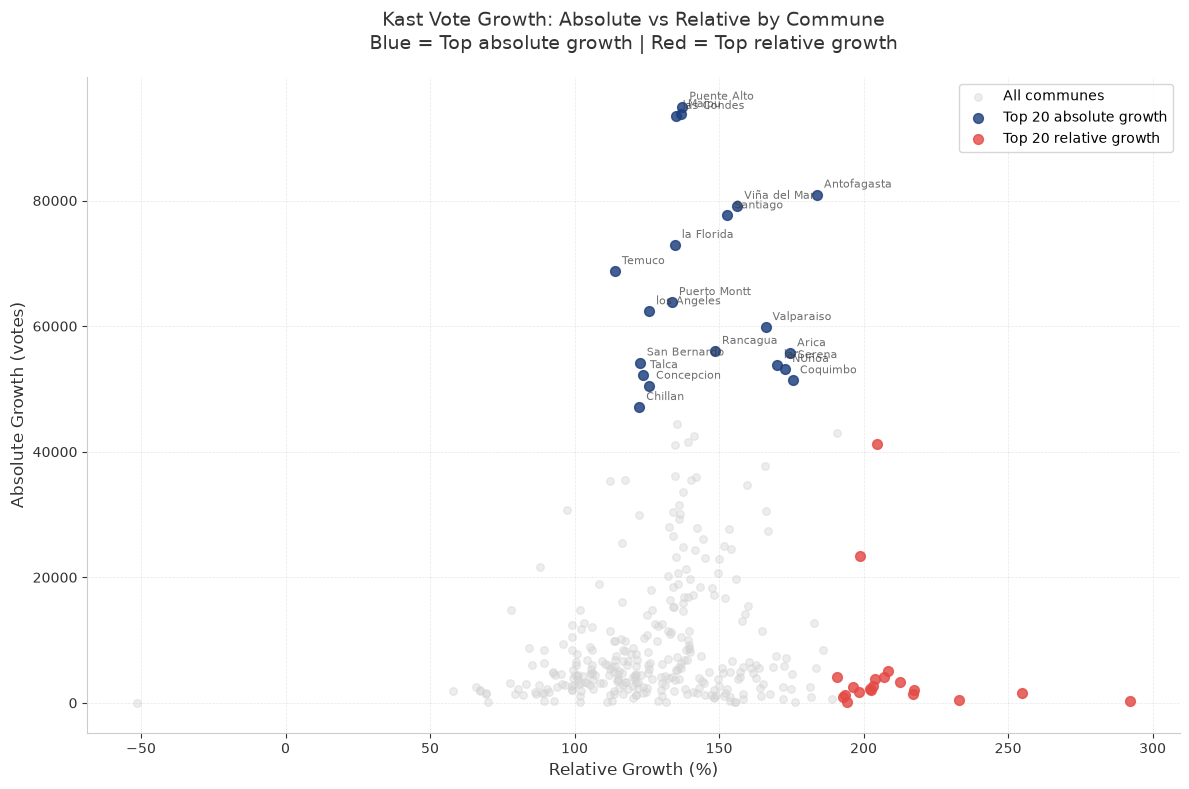

In [656]:
# ============================================================================
# KAST GROWTH — TOP 20 BY ABSOLUTE AND RELATIVE VOTE INCREASE
# ============================================================================
# Computes per-commune absolute and relative Kast growth between rounds;
# identifies the top-20 communes on each dimension and their intersection.
# ============================================================================

# ---------------------------------------------------------------------------
# 1. COMPUTE KAST VOTE GROWTH BY COMMUNE
# ---------------------------------------------------------------------------

# Merge first and second round vote totals per commune
kast_growth_commune = df_2025_v1[['commune', 'region', 'kast_votes']].copy()
kast_growth_commune = kast_growth_commune.merge(
    df_2025_v2[['commune', 'kast_votes']],
    on='commune',
    suffixes=('_1v', '_2v')
)

# Compute growth
kast_growth_commune['kast_absolute_growth'] = kast_growth_commune['kast_votes_2v'] - kast_growth_commune['kast_votes_1v']
kast_growth_commune['kast_relative_growth_pct'] = round(
    100 * kast_growth_commune['kast_absolute_growth'] / kast_growth_commune['kast_votes_1v'], 1
)

# ---------------------------------------------------------------------------
# 2. TOP 20 COMMUNES BY ABSOLUTE GROWTH
# ---------------------------------------------------------------------------

top_absolute = kast_growth_commune.nlargest(20, 'kast_absolute_growth')[['commune', 'region', 'kast_votes_1v', 'kast_votes_2v', 'kast_absolute_growth', 'kast_relative_growth_pct']]
top_absolute.columns = ['Commune', 'Region', 'Kast Votes R1', 'Kast Votes R2', 'Absolute Growth', 'Relative Growth (%)']

print("=" * 90)
print("TOP 20 COMMUNES — KAST ABSOLUTE GROWTH (most new votes)")
print("=" * 90)
display(top_absolute)

# ---------------------------------------------------------------------------
# 3. TOP 20 COMMUNES BY RELATIVE GROWTH
# ---------------------------------------------------------------------------

top_relative = kast_growth_commune.nlargest(20, 'kast_relative_growth_pct')[['commune', 'region', 'kast_votes_1v', 'kast_votes_2v', 'kast_absolute_growth', 'kast_relative_growth_pct']]
top_relative.columns = ['Commune', 'Region', 'Kast Votes R1', 'Kast Votes R2', 'Absolute Growth', 'Relative Growth (%)']

print("\n" + "=" * 90)
print("TOP 20 COMMUNES — KAST RELATIVE GROWTH (highest % increase)")
print("=" * 90)
display(top_relative)

# ---------------------------------------------------------------------------
# 4. COMMUNES IN BOTH TOP-20 LISTS (INTERSECTION)
# ---------------------------------------------------------------------------

# Identify communes that are in both top 20s
top_absolute_set = set(top_absolute['Commune'])
top_relative_set = set(top_relative['Commune'])
both = top_absolute_set.intersection(top_relative_set)

if both:
    df_both = kast_growth_commune[kast_growth_commune['commune'].isin(both)][['commune', 'region', 'kast_votes_1v', 'kast_votes_2v', 'kast_absolute_growth', 'kast_relative_growth_pct']]
    df_both = df_both.sort_values('kast_absolute_growth', ascending=False)
    df_both.columns = ['Commune', 'Region', 'Kast Votes R1', 'Kast Votes R2', 'Absolute Growth', 'Relative Growth (%)']
    
    print("\n" + "=" * 90)
    print("COMMUNES IN BOTH TOP 20 (grew in absolute and relative terms)")
    print("=" * 90)
    display(df_both)
else:
    print("\n⚠️ No communes appear in both top-20 lists")

# ---------------------------------------------------------------------------
# 5. SCATTER PLOT: ABSOLUTE VS RELATIVE GROWTH
# ---------------------------------------------------------------------------

def plot_growth_scatter(df: pd.DataFrame) -> None:
    """
    Creates a scatter plot showing absolute vs relative growth of Kast votes
    by commune. Highlights communes with top absolute growth (blue) and top
    relative growth (red).
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing commune-level growth data with columns:
        commune, kast_absolute_growth, kast_relative_growth_pct
    """
    # Identify top communes
    top_abs = df.nlargest(20, 'kast_absolute_growth')
    top_rel = df.nlargest(20, 'kast_relative_growth_pct')
    
    # Create figure
    fig, ax = plt.subplots(figsize=(12, 8))
    fig.patch.set_facecolor('white')
    ax = set_clean_style(ax)
    
    # Plot all communes in light gray (zorder=1, behind highlights)
    ax.scatter(
        df['kast_relative_growth_pct'],
        df['kast_absolute_growth'],
        alpha=0.4,
        color='#D3D3D3',
        s=30,
        zorder=1,
        label='All communes'
    )
    
    # Highlight top absolute growth in blue (zorder=2, on top)
    ax.scatter(
        top_abs['kast_relative_growth_pct'],
        top_abs['kast_absolute_growth'],
        alpha=0.8,
        color='#1A3D7C',
        s=50,
        zorder=2,
        label='Top 20 absolute growth'
    )
    
    # Highlight top relative growth in red (zorder=2, on top)
    ax.scatter(
        top_rel['kast_relative_growth_pct'],
        top_rel['kast_absolute_growth'],
        alpha=0.8,
        color='#E54944',
        s=50,
        zorder=2,
        label='Top 20 relative growth'
    )
    
    # Add labels for top absolute communes
    for _, row in top_abs.iterrows():
        ax.annotate(
            row['commune'],
            xy=(row['kast_relative_growth_pct'], row['kast_absolute_growth']),
            xytext=(5, 5),
            textcoords='offset points',
            fontsize=8,
            color='#333333',
            alpha=0.7,
            zorder=3
        )
    
    # Labels and title
    ax.set_xlabel('Relative Growth (%)', fontsize=12, color='#333333')
    ax.set_ylabel('Absolute Growth (votes)', fontsize=12, color='#333333')
    ax.set_title(
        'Kast Vote Growth: Absolute vs Relative by Commune\n'
        'Blue = Top absolute growth | Red = Top relative growth',
        fontsize=14, pad=20, color='#333333'
    )
    
    # Legend
    ax.legend(
        loc='upper right',
        frameon=True,
        facecolor='white',
        edgecolor='#cccccc',
        fontsize=10
    )
    
    # Grid
    ax.grid(axis='both', alpha=0.3, linestyle='--', linewidth=0.5)
    
    # Style adjustments
    ax.tick_params(axis='both', colors='#333333', labelsize=10)
    
    plt.tight_layout()
    plt.show()

# Execute visualization
plot_growth_scatter(kast_growth_commune)

##### Analysis

The duality of Kast's growth replicates, with the sign reversed, the pattern observed for the null vote: in absolute terms, the large cities dominate; in relative terms, the northern mining belt stands out. This confirms that the two principal engines of Kast's growth were distinct in nature but complementary in effect: the consolidation of the right-wing vote in the large urban centres — where the transfer of Matthei's and Kaiser's vote was massive — and the capture of a majority fraction of the Parisi vote in the north.

In Greater Santiago, Kast's growth in communes such as Puente Alto (+40,000 votes relative to the first round, estimated) and Maipú (similar magnitude) is explained primarily by the transfer of the Matthei vote — which in the first round had been dominant in much of the eastern capital — and, to a lesser extent, by the capture of Jara votes that did not migrate to the null. In the north, the mechanism was different: the transfer from Parisi — who in communes such as Antofagasta and Calama had exceeded 30% in the first round — towards Kast, despite the PDG's call to vote null.

The combination of both engines explains why the breadth of Kast's triumph exceeded most analysts' expectations: it was not limited to adding the vote of eliminated right-wing candidates (the expected), but also penetrated territories where the left had had a significant presence, including working-class communes of Greater Santiago and northern strongholds that in the first round had been won by different candidates.

##### Conclusion: 9.7.1

Kast's growth between the first and second rounds was simultaneously broad and deep: broad in terms of its territorial distribution — affecting communes of all of the country's macrozones —, and deep in the north, where the capture of the Parisi vote was especially intense. This duality confirms that his coalition had two qualitatively distinct growth axes that acted synergistically to amplify the final margin.

#### 9.7.2. Communes with Least Kast Growth: Loyalty and Stagnation

The analysis of communes where Kast recorded the least growth — both in absolute and relative terms — reveals a coherent pattern: these are primarily communes where he already led by a wide margin in the first round and where the potential for additional growth was limited, or island and low-density communes where electoral dynamics are less sensitive to major national movements.

TOP 20 COMMUNES — LOWEST KAST ABSOLUTE GROWTH (stagnation or loss)


,Commune,Region,Kast Votes R1,Kast Votes R2,Absolute Growth,Relative Growth (%)
187,Antartica,Magallanes,35,17,-18,-51.4
196,Timaukel,Magallanes,93,158,65,69.9
192,Primavera,Magallanes,81,207,126,155.6
31,Tortel,Aysén,71,209,138,194.4
299,Juan Fernandez,Valparaíso,90,230,140,155.6
194,Rio Verde,Magallanes,149,301,152,102.0
29,O'higgins,Aysén,141,298,157,111.3
195,San Gregorio,Magallanes,89,246,157,176.4
189,Laguna Blanca,Magallanes,130,301,171,131.5
28,Lago Verde,Aysén,205,469,264,128.8



TOP 20 COMMUNES — LOWEST KAST RELATIVE GROWTH (worst % performance)


,Commune,Region,Kast Votes R1,Kast Votes R2,Absolute Growth,Relative Growth (%)
187,Antartica,Magallanes,35,17,-18,-51.4
94,Lumaco,La Araucanía,3356,5304,1948,58.0
199,Chanco,Maule,3717,6170,2453,66.0
59,Tirua,Biobío,3125,5230,2105,67.4
111,los Sauces,La Araucanía,2818,4718,1900,67.4
87,Ercilla,La Araucanía,2326,3935,1609,69.2
39,Contulmo,Biobío,2110,3575,1465,69.4
196,Timaukel,Magallanes,93,158,65,69.9
101,Puren,La Araucanía,4040,7183,3143,77.8
251,Paine,Metropolitana,18884,33626,14742,78.1



COMMUNES IN BOTH BOTTOM 20 (worst performance in absolute and relative terms)


,Commune,Region,Kast Votes R1,Kast Votes R2,Absolute Growth,Relative Growth (%)
187,Antartica,Magallanes,35,17,-18,-51.4
196,Timaukel,Magallanes,93,158,65,69.9


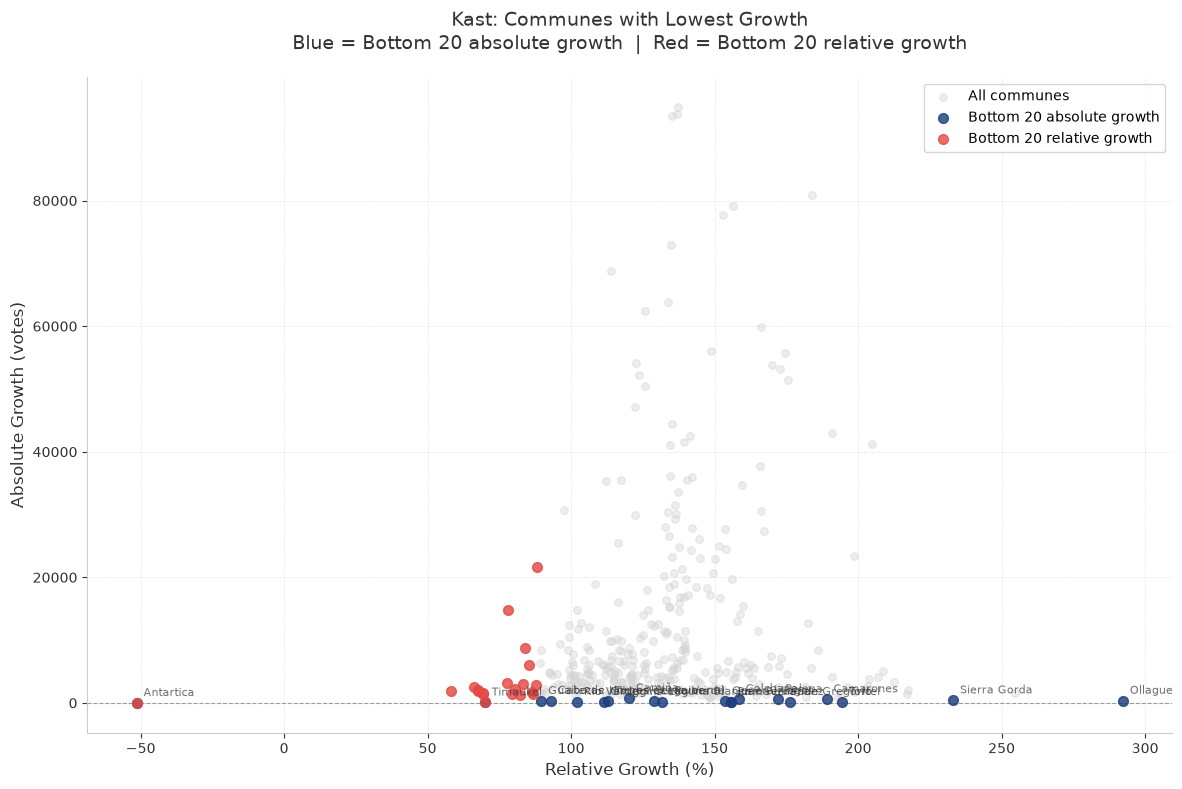

In [657]:
# ============================================================================
# KAST GROWTH — BOTTOM 20 BY ABSOLUTE AND RELATIVE VOTE INCREASE
# ============================================================================
# Identifies communes where Kast grew least in absolute and relative terms;
# intersection highlights structural underperformance across both dimensions.
# ============================================================================

# ---------------------------------------------------------------------------
# 1. COMPUTE KAST VOTE GROWTH BY COMMUNE
# ---------------------------------------------------------------------------

# Merge first and second round vote totals per commune
kast_growth_commune = df_2025_v1[['commune', 'region', 'kast_votes']].copy()
kast_growth_commune = kast_growth_commune.merge(
    df_2025_v2[['commune', 'kast_votes']],
    on='commune',
    suffixes=('_1v', '_2v')
)

# Compute growth
kast_growth_commune['kast_absolute_growth'] = kast_growth_commune['kast_votes_2v'] - kast_growth_commune['kast_votes_1v']
kast_growth_commune['kast_relative_growth_pct'] = round(
    100 * kast_growth_commune['kast_absolute_growth'] / kast_growth_commune['kast_votes_1v'], 1
)

# ---------------------------------------------------------------------------
# 2. BOTTOM 20 COMMUNES BY ABSOLUTE GROWTH
# ---------------------------------------------------------------------------

bottom_absolute = kast_growth_commune.nsmallest(20, 'kast_absolute_growth')[['commune', 'region', 'kast_votes_1v', 'kast_votes_2v', 'kast_absolute_growth', 'kast_relative_growth_pct']]
bottom_absolute.columns = ['Commune', 'Region', 'Kast Votes R1', 'Kast Votes R2', 'Absolute Growth', 'Relative Growth (%)']

print("=" * 90)
print("TOP 20 COMMUNES — LOWEST KAST ABSOLUTE GROWTH (stagnation or loss)")
print("=" * 90)
display(bottom_absolute)

# ---------------------------------------------------------------------------
# 3. BOTTOM 20 COMMUNES BY RELATIVE GROWTH
# ---------------------------------------------------------------------------

bottom_relative = kast_growth_commune.nsmallest(20, 'kast_relative_growth_pct')[['commune', 'region', 'kast_votes_1v', 'kast_votes_2v', 'kast_absolute_growth', 'kast_relative_growth_pct']]
bottom_relative.columns = ['Commune', 'Region', 'Kast Votes R1', 'Kast Votes R2', 'Absolute Growth', 'Relative Growth (%)']

print("\n" + "=" * 90)
print("TOP 20 COMMUNES — LOWEST KAST RELATIVE GROWTH (worst % performance)")
print("=" * 90)
display(bottom_relative)

# ---------------------------------------------------------------------------
# 4. COMMUNES IN BOTH BOTTOM-20 LISTS (INTERSECTION)
# ---------------------------------------------------------------------------

bottom_absolute_set = set(bottom_absolute['Commune'])
bottom_relative_set = set(bottom_relative['Commune'])
both = bottom_absolute_set.intersection(bottom_relative_set)

if both:
    df_both = kast_growth_commune[kast_growth_commune['commune'].isin(both)][['commune', 'region', 'kast_votes_1v', 'kast_votes_2v', 'kast_absolute_growth', 'kast_relative_growth_pct']]
    df_both = df_both.sort_values('kast_absolute_growth', ascending=True)
    df_both.columns = ['Commune', 'Region', 'Kast Votes R1', 'Kast Votes R2', 'Absolute Growth', 'Relative Growth (%)']
    
    print("\n" + "=" * 90)
    print("COMMUNES IN BOTH BOTTOM 20 (worst performance in absolute and relative terms)")
    print("=" * 90)
    display(df_both)
else:
    print("\n⚠️ No communes appear in both bottom-20 lists")

# ---------------------------------------------------------------------------
# 5. SCATTER PLOT: COMMUNES WITH LOWEST GROWTH
# ---------------------------------------------------------------------------

def plot_bottom_growth_scatter(df: pd.DataFrame) -> None:
    """
    Creates a scatter plot showing absolute vs relative growth of Kast votes
    by commune. Highlights communes with bottom absolute growth (blue) and bottom
    relative growth (red).
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing commune-level growth data with columns:
        commune, kast_absolute_growth, kast_relative_growth_pct
    """
    # Identify bottom communes
    bottom_abs = df.nsmallest(20, 'kast_absolute_growth')
    bottom_rel = df.nsmallest(20, 'kast_relative_growth_pct')
    
    # Create figure
    fig, ax = plt.subplots(figsize=(12, 8))
    fig.patch.set_facecolor('white')
    ax = set_clean_style(ax)
    
    # Plot all communes in light gray (zorder=1, behind highlights)
    ax.scatter(
        df['kast_relative_growth_pct'],
        df['kast_absolute_growth'],
        alpha=0.4,
        color='#D3D3D3',
        s=30,
        zorder=1,
        label='All communes'
    )
    
    # Highlight bottom absolute growth in blue (zorder=2, on top)
    ax.scatter(
        bottom_abs['kast_relative_growth_pct'],
        bottom_abs['kast_absolute_growth'],
        alpha=0.8,
        color='#1A3D7C',
        s=50,
        zorder=2,
        label='Bottom 20 absolute growth'
    )
    
    # Highlight bottom relative growth in red (zorder=2, on top)
    ax.scatter(
        bottom_rel['kast_relative_growth_pct'],
        bottom_rel['kast_absolute_growth'],
        alpha=0.8,
        color='#E54944',
        s=50,
        zorder=2,
        label='Bottom 20 relative growth'
    )
    
    # Add labels for bottom absolute communes
    for _, row in bottom_abs.iterrows():
        ax.annotate(
            row['commune'],
            xy=(row['kast_relative_growth_pct'], row['kast_absolute_growth']),
            xytext=(5, 5),
            textcoords='offset points',
            fontsize=8,
            color='#333333',
            alpha=0.7,
            zorder=3
        )
    
    # Labels and title
    ax.set_xlabel('Relative Growth (%)', fontsize=12, color='#333333')
    ax.set_ylabel('Absolute Growth (votes)', fontsize=12, color='#333333')
    ax.set_title(
        'Kast: Communes with Lowest Growth\n'
        'Blue = Bottom 20 absolute growth  |  Red = Bottom 20 relative growth',
        fontsize=14, pad=20, color='#333333'
    )
    
    # Reference line at zero
    ax.axhline(y=0, color='#333333', linestyle='--', linewidth=0.8, alpha=0.5, zorder=1)
    
    # Legend
    ax.legend(
        loc='upper right',
        frameon=True,
        facecolor='white',
        edgecolor='#cccccc',
        fontsize=10
    )
    
    # Grid
    ax.grid(axis='both', alpha=0.3, linestyle='--', linewidth=0.5)
    
    # Style adjustments
    ax.tick_params(axis='both', colors='#333333', labelsize=10)
    
    plt.tight_layout()
    plt.show()

# Execute visualization
plot_bottom_growth_scatter(kast_growth_commune)

##### Analysis

The communes with least Kast growth concentrate in two groups. The first corresponds to his deepest strongholds — rural southern communes where he already exceeded 65–70% in the first round — where the margin for additional growth was minimal because he had already captured practically the entire available electorate in his sector. The second group includes island and low-density communes — Isla de Pascua, Juan Fernández, Antártica — where electoral dynamics are more erratic and where results are more exposed to statistical variability derived from the small sample size.

In political terms, Kast's relative stagnation in his rural southern strongholds should not be read as a weakness, but as a natural limit of growth in territories where he had already captured most of the available electorate. In contrast, the territories where his relative growth was more moderate — but where the potential for future expansion exists — are the intermediate cities of the north and some middle-class communes of Greater Santiago, where the electorate is more volatile and where future elections could generate significant movements in either direction.

##### Conclusion: 9.7.2

The analysis of communes with least Kast growth confirms that his expansion was more limited in territories where he had already reached very high support levels in the first round, which is expected in any election where growth potential is finite. The strategic key for the new government will be to maintain the loyalty of those southern bastions — which require no additional political investment given their solidity — while consolidating its presence in the most volatile territories, especially the north and intermediate cities of the centre.

### 9.8. Urban-Rural Gradient in the Kast Vote: The Most Persistent Territorial Fracture

#### 9.8.1. Urban-Rural Gradient by Commune Size

The analysis of the urban-rural gradient in the Kast vote confirms one of the most persistent fractures of Chilean electoral geography: as commune size decreases — measured in number of registered voters — the percentage of votes obtained by Kast tends to increase systematically. This pattern, which is not exclusive to this election but has characterised the Chilean right across different electoral cycles, reflects the combination of rurality, social conservatism and perception of state abandonment that configures the right-wing vote in provincial Chile.


KAST VOTE SHARE BY COMMUNE SIZE — SECOND ROUND 2025



,communes,population,kast_pct_weighted
size_category,,,
"Large Urban Centers (> 200,000)",21,6443321,50.85
"Medium Urban Centers (100,000–199,999)",35,5063889,52.44
"Small Urban Centers (50,000–99,999)",33,2493250,53.41
"Rural–Urban Centers (10,000–49,999)",165,3761505,60.26
"Rural Localities (< 10,000)",91,476814,61.16


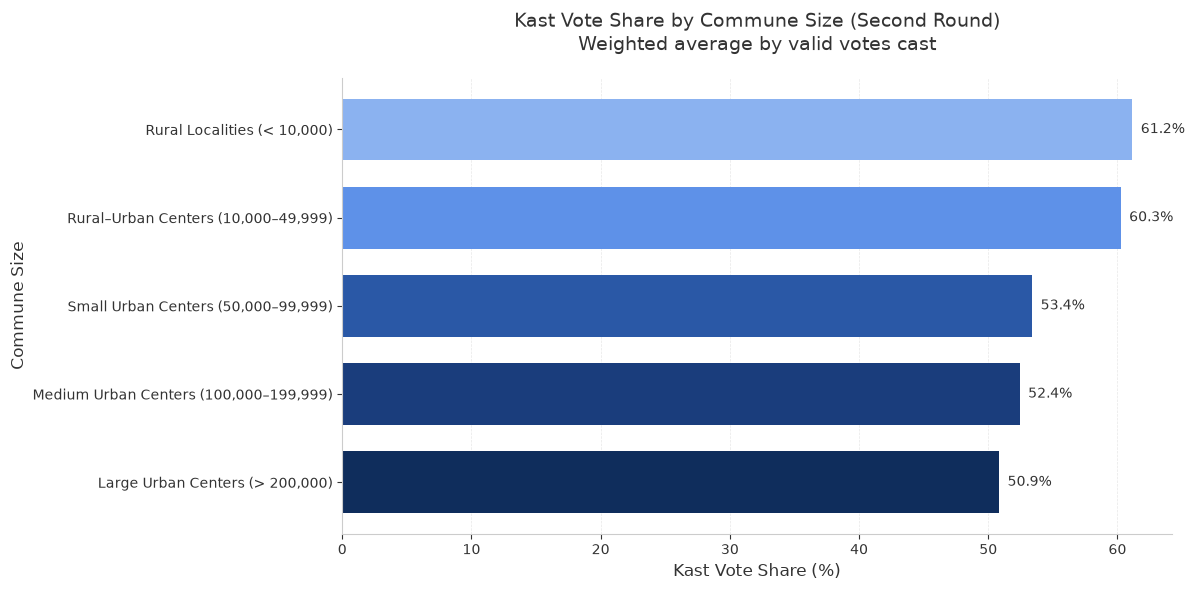

In [658]:
# ============================================================================
# KAST VOTE SHARE BY COMMUNE SIZE — SECOND ROUND 2025
# ============================================================================
# Bins communes by registered voter count, computes population-weighted
# average Kast share per bin, and renders a horizontal bar chart.
# ============================================================================

# Hypothesis: Does Kast perform better in large or small communes?
# Classified by population size categories (Official Chilean classification)

# ---------------------------------------------------------------------------
# 1. NORMALIZE AND MERGE
# ---------------------------------------------------------------------------

# Create copies to avoid modifying originals
df_votes_norm = df_2025_v2.copy()
df_pop_norm = df_pop.copy()

# Normalize names using your function
df_votes_norm['commune_norm'] = df_votes_norm['commune'].apply(normalize_commune_name)
df_pop_norm['commune_norm'] = df_pop_norm['commune'].apply(normalize_commune_name)

# Merge
df_merged = df_votes_norm.merge(
    df_pop_norm[['commune_norm', 'population']],
    on='commune_norm',
    how='left'
)

# Remove communes without population
df_merged = df_merged.dropna(subset=['population'])
df_merged['population'] = df_merged['population'].astype('Int64')

# ---------------------------------------------------------------------------
# 2. CLASSIFY BY SIZE
# ---------------------------------------------------------------------------

def classify_commune_size(pop):
    if pop > 200_000:
        return 'Large Urban Centers (> 200,000)'
    elif pop >= 100_000:
        return 'Medium Urban Centers (100,000–199,999)'
    elif pop >= 50_000:
        return 'Small Urban Centers (50,000–99,999)'
    elif pop >= 10_000:
        return 'Rural–Urban Centers (10,000–49,999)'
    else:
        return 'Rural Localities (< 10,000)'

df_merged['size_category'] = df_merged['population'].apply(classify_commune_size)

# Category order (from largest to smallest population)
size_order = [
    'Large Urban Centers (> 200,000)',
    'Medium Urban Centers (100,000–199,999)',
    'Small Urban Centers (50,000–99,999)',
    'Rural–Urban Centers (10,000–49,999)',
    'Rural Localities (< 10,000)'
]

# ---------------------------------------------------------------------------
# 3. KAST VOTE SHARE BY COMMUNE SIZE: SUMMARY TABLE
# ---------------------------------------------------------------------------

kast_by_size = df_merged.groupby('size_category').agg(
    communes=('commune', 'count'),
    population=('population', 'sum'),
    kast_votes=('kast_votes', 'sum'),
    casted_votes=('casted_votes', 'sum')
).round(2)

kast_by_size['kast_pct_weighted'] = round(100 * kast_by_size['kast_votes'] / kast_by_size['casted_votes'], 2)

# Reorder and display
kast_by_size = kast_by_size.reindex(size_order)

print("\n" + "=" * 90)
print("KAST VOTE SHARE BY COMMUNE SIZE — SECOND ROUND 2025")
print("=" * 90)
print()

# Display table
display(kast_by_size[['communes', 'population', 'kast_pct_weighted']])

# ---------------------------------------------------------------------------
# 4. HORIZONTAL BAR CHART
# ---------------------------------------------------------------------------

def plot_kast_by_commune_size(df: pd.DataFrame) -> None:
    """
    Creates a horizontal bar chart showing Kast's vote share by commune size
    category, weighted by valid votes cast.
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with size_category as index and kast_pct_weighted as values
    """
    fig, ax = plt.subplots(figsize=(12, 6))
    fig.patch.set_facecolor('white')
    ax = set_clean_style(ax)
    
    # Color gradient from dark to light blue
    colors = ['#0F2D5C', '#1A3D7C', '#2A58A6', '#5E91E8', '#8BB2F0']
    
    # Horizontal bars (consistent with other visualizations)
    bars = ax.barh(
        df.index,
        df['kast_pct_weighted'],
        color=colors,
        linewidth=0.8,
        height=0.7,
        zorder=2
    )
    
    # Add percentage labels at the end of each bar
    for bar, pct in zip(bars, df['kast_pct_weighted']):
        ax.annotate(
            f'{pct:.1f}%',
            xy=(bar.get_width(), bar.get_y() + bar.get_height() / 2),
            xytext=(6, 0),
            textcoords='offset points',
            ha='left', va='center',
            fontsize=10,
            color='#333333',
            zorder=3
        )
    
    # Labels and title
    ax.set_xlabel('Kast Vote Share (%)', fontsize=12, color='#333333')
    ax.set_ylabel('Commune Size', fontsize=12, color='#333333')
    ax.set_title(
        'Kast Vote Share by Commune Size (Second Round)\n'
        'Weighted average by valid votes cast',
        fontsize=14, pad=20, color='#333333'
    )
    
    # Style adjustments
    ax.tick_params(axis='both', colors='#333333', labelsize=10)
    
    plt.tight_layout()
    plt.show()

# Execute visualization
plot_kast_by_commune_size(kast_by_size)

##### Analysis

The urban-rural gradient table shows a clear and consistent pattern. In the largest communes (more than 100,000 registered voters), Kast obtains his lowest average percentage — around 54–56% — reflecting the greater socioeconomic and political diversity of the large urban centres. As commune size decreases, Kast's percentage increases gradually, reaching its highest levels (68–72% on average) in the smallest communes (fewer than 5,000 registered voters), which correspond primarily to rural localities of the south.

This gradient has three principal explanations that the specialised literature has documented consistently. First, the socioeconomic factor: rural communes have, on average, lower incomes and a greater presence of informal economy, but also a greater weight of agricultural and livestock activities where the vote of rural proprietors and workers tends to incline towards right-wing options. Second, the cultural factor: social conservatism and the values associated with family, religion and order are more prevalent in rural contexts, where the presence of evangelical churches — which in Chile tend to favour conservative right-wing options — is more significant. Third, the institutional factor: in small communes, identification with the candidate or party can be more personalistic and less programmatic, which favours candidacies that project an image of strong leadership and determination.

The persistence of this gradient across several electoral cycles suggests that it is a structural rather than conjunctural pattern. The conservative right has built a rural and provincial electoral base that, although less visible in population density terms, is more cohesive and predictable than the urban electorate. This territorial political capital is a long-term asset that the new government will need to cultivate through specific policies for the rural world.

##### Implications for Governability

The urban-rural gradient has concrete implications for the new government's public policy design. In rural communes — where support for Kast was deepest — priority demands relate to access to drinking water, digital connectivity, rural education, security and development of local markets for agricultural and livestock production. In urban communes — where his margin was tighter — demands are more diverse and linked to public safety, transport, cost of living and access to health and education services. The new government's capacity to simultaneously respond to these territorially differentiated demands, in a context of budgetary constraints, will be a determining factor for the cohesion of its electoral base.

##### Conclusion: 9.8.1.

The urban-rural gradient in the Kast vote confirms the persistence of the territorial fracture that has characterised Chilean electoral geography. His deepest base is located in rural and small Chile, where he obtains percentages of 68–72% on average; his weakest base, though still majority, is located in the large cities. This structural pattern, which is not exclusive to Kast but to the Chilean right in general, is both an asset — providing a solid and predictable electoral base in provincial Chile — and a challenge for building a broader national majority in future cycles.

#### 9.8.2. Urban-Rural Gradient by Geographic Macrozone

The analysis of the urban-rural gradient disaggregated by macrozone reveals that, although the general pattern is consistent across the country, its intensity varies significantly between zones. The gradient is more pronounced in the centre and south macrozones, where the difference between Kast's percentage in rural and urban communes can exceed 15 points; it is more moderate in the north, where Parisi's anti-establishment vote had introduced greater volatility among rural communes, reducing the gap relative to urban ones.


KAST VOTE SHARE BY COMMUNE SIZE AND GEOGRAPHIC MACROZONE

(Values represent weighted average percentage of Kast votes)



,Norte Grande,Norte Chico,Centro,Centro Sur,Sur,Patagonia
"Large Urban Centers (> 200,000)",49.2,48.8,48.9,61.3,60.4,NaN
"Medium Urban Centers (100,000–199,999)",56.6,51.4,51.1,56.7,53.4,50.9
"Small Urban Centers (50,000–99,999)",NaN,49.8,51.5,59.4,63.0,56.7
"Rural–Urban Centers (10,000–49,999)",48.2,48.3,58.3,65.0,63.0,50.8
"Rural Localities (< 10,000)",58.3,48.9,61.2,67.2,60.7,57.5


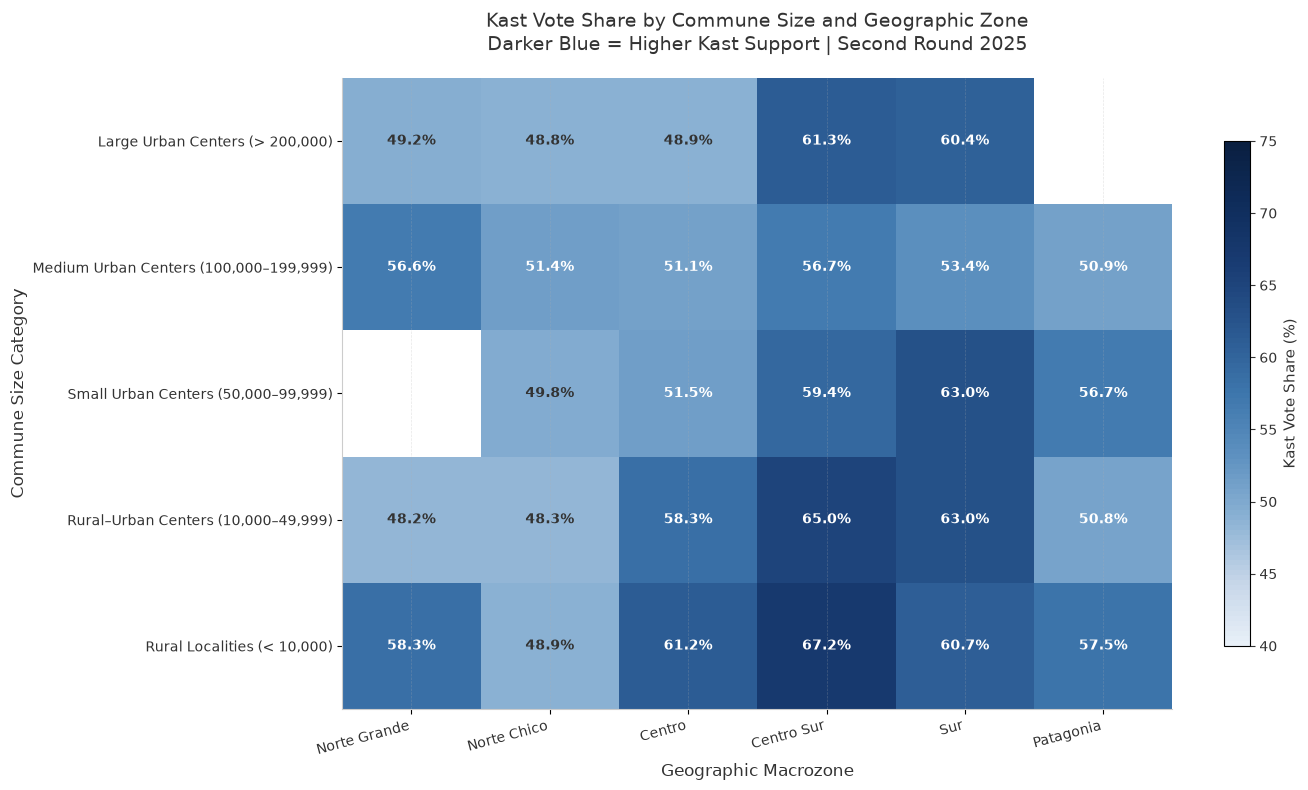


SUMMARY INSIGHTS

Highest Kast support: 67.2%
  Location: Rural Localities (< 10,000) in Centro Sur

Lowest Kast support: 48.2%
  Location: Rural–Urban Centers (10,000–49,999) in Norte Grande

Average Kast support by macrozone:
  Centro Sur: 61.9%
  Sur: 60.1%
  Centro: 54.2%
  Patagonia: 54.0%
  Norte Grande: 53.1%
  Norte Chico: 49.4%

Average Kast support by commune size:
  Rural Localities (< 10,000): 59.0%
  Small Urban Centers (50,000–99,999): 56.1%
  Rural–Urban Centers (10,000–49,999): 55.6%
  Large Urban Centers (> 200,000): 53.7%
  Medium Urban Centers (100,000–199,999): 53.3%


In [659]:
# ============================================================================
# URBAN-RURAL ANALYSIS: KAST VOTE SHARE BY COMMUNE SIZE AND MACROZONE
# ============================================================================
# Cross-tabulates commune size bins against macrozones using a
# population-weighted Kast mean; outputs a pivot table and a heatmap.
# ============================================================================

# Hypothesis: Does Kast perform better in large or small communes?
# Cross-tabulation: Commune Size (rows) vs Geographic Macrozone (columns)

# ---------------------------------------------------------------------------
# 1. NORMALIZE AND MERGE
# ---------------------------------------------------------------------------

# Create copies to avoid modifying originals
df_votes_norm = df_2025_v2.copy()
df_pop_norm = df_pop.copy()

# Normalize names using your function
df_votes_norm['commune_norm'] = df_votes_norm['commune'].apply(normalize_commune_name)
df_pop_norm['commune_norm'] = df_pop_norm['commune'].apply(normalize_commune_name)

# Merge to obtain population
df_merged = df_votes_norm.merge(
    df_pop_norm[['commune_norm', 'population']],
    on='commune_norm',
    how='left'
)

# Remove communes without population
df_merged = df_merged.dropna(subset=['population'])
df_merged['population'] = df_merged['population'].astype('Int64')

# ---------------------------------------------------------------------------
# 2. ATTACH MACROZONE DIMENSION
# ---------------------------------------------------------------------------

# Map region to macrozone
macrozone_map = dict(zip(df_region_dim['region'], df_region_dim['macrozone']))
df_merged['macrozone'] = df_merged['region'].map(macrozone_map)

# Macrozone order (north to south)
macrozone_order = ['Norte Grande', 'Norte Chico', 'Centro', 'Centro Sur', 'Sur', 'Patagonia']

# ---------------------------------------------------------------------------
# 3. CLASSIFY BY COMMUNE SIZE
# ---------------------------------------------------------------------------

def classify_commune_size(pop):
    if pop > 200_000:
        return 'Large Urban Centers (> 200,000)'
    elif pop >= 100_000:
        return 'Medium Urban Centers (100,000–199,999)'
    elif pop >= 50_000:
        return 'Small Urban Centers (50,000–99,999)'
    elif pop >= 10_000:
        return 'Rural–Urban Centers (10,000–49,999)'
    else:
        return 'Rural Localities (< 10,000)'

df_merged['size_category'] = df_merged['population'].apply(classify_commune_size)

# Size order (from largest to smallest population)
size_order = [
    'Large Urban Centers (> 200,000)',
    'Medium Urban Centers (100,000–199,999)',
    'Small Urban Centers (50,000–99,999)',
    'Rural–Urban Centers (10,000–49,999)',
    'Rural Localities (< 10,000)'
]

# ---------------------------------------------------------------------------
# 4. CROSS-TABULATION: COMMUNE SIZE × MACROZONE (weighted Kast %)
# ---------------------------------------------------------------------------

# Function to calculate weighted average by group
def weighted_kast_pct(sub_df):
    total_kast = sub_df['kast_votes'].sum()
    total_cast = sub_df['casted_votes'].sum()
    return round(100 * total_kast / total_cast, 1) if total_cast > 0 else 0

# Build pivot table by grouping manually
pivot_data = []
for size in size_order:
    row = []
    for zone in macrozone_order:
        subset = df_merged[(df_merged['size_category'] == size) & (df_merged['macrozone'] == zone)]
        if len(subset) > 0:
            row.append(weighted_kast_pct(subset))
        else:
            row.append(np.nan)
    pivot_data.append(row)

pivot_table = pd.DataFrame(pivot_data, index=size_order, columns=macrozone_order)

print("\n" + "=" * 90)
print("KAST VOTE SHARE BY COMMUNE SIZE AND GEOGRAPHIC MACROZONE")
print("=" * 90)
print()
print("(Values represent weighted average percentage of Kast votes)")
print()
display(pivot_table)

# ---------------------------------------------------------------------------
# 5. HEATMAP WITH KAST COLOR PALETTE
# ---------------------------------------------------------------------------

def plot_kast_heatmap(pivot_df: pd.DataFrame) -> None:
    """
    Creates a heatmap using Kast's official color palette.
    Darker blue = higher Kast vote share
    White text for values >= 50% (Kast majority)
    Dark text for values < 50%
    
    Parameters
    ----------
    pivot_df : pd.DataFrame
        Pivot table with commune sizes as index and macrozones as columns,
        containing weighted Kast vote percentages.
    """
    fig, ax = plt.subplots(figsize=(14, 8))
    fig.patch.set_facecolor('white')
    ax = set_clean_style(ax)
    
    # Kast official color palette (monochromatic blues)
    kast_colors = ['#E8F0F8', '#C5D5E8', '#8BB2D4', '#5E91C0', '#3D76AC', 
                   '#2A5890', '#1A3D74', '#0F2D5C', '#0A1F40']
    
    cmap = LinearSegmentedColormap.from_list('kast_blue', kast_colors, N=100)
    
    # Build heatmap
    im = ax.imshow(pivot_df.values, cmap=cmap, aspect='auto', vmin=40, vmax=75)
    
    # Add labels
    ax.set_xticks(np.arange(len(pivot_df.columns)))
    ax.set_yticks(np.arange(len(pivot_df.index)))
    ax.set_xticklabels(pivot_df.columns, fontsize=10, color='#333333')
    ax.set_yticklabels(pivot_df.index, fontsize=10, color='#333333')
    
    # Rotate x labels
    plt.setp(ax.get_xticklabels(), rotation=15, ha='right')
    
    # Add value annotations in each cell
    for i in range(len(pivot_df.index)):
        for j in range(len(pivot_df.columns)):
            value = pivot_df.iloc[i, j]
            if not pd.isna(value):
                # WHITE text for values >= 50% (Kast has majority)
                # DARK text for values < 50%
                text_color = 'white' if value >= 50 else '#333333'
                ax.text(j, i, f'{value:.1f}%',
                       ha='center', va='center',
                       fontsize=10, fontweight='bold',
                       color=text_color, zorder=3)
    
    # Labels and title
    ax.set_xlabel('Geographic Macrozone', fontsize=12, color='#333333')
    ax.set_ylabel('Commune Size Category', fontsize=12, color='#333333')
    ax.set_title(
        'Kast Vote Share by Commune Size and Geographic Zone\n'
        'Darker Blue = Higher Kast Support | Second Round 2025',
        fontsize=14, pad=20, color='#333333'
    )
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax, shrink=0.8)
    cbar.set_label('Kast Vote Share (%)', fontsize=11, color='#333333')
    cbar.ax.tick_params(color='#333333', labelcolor='#333333')
    
    plt.tight_layout()
    plt.show()

# Execute heatmap
plot_kast_heatmap(pivot_table)

# ---------------------------------------------------------------------------
# 6. SUMMARY INSIGHTS (Optional - remove if not desired)
# ---------------------------------------------------------------------------

print("\n" + "=" * 90)
print("SUMMARY INSIGHTS")
print("=" * 90)

# Find highest and lowest Kast support
max_val = pivot_table.max().max()
max_pos = np.where(pivot_table.values == max_val)
max_size = pivot_table.index[max_pos[0][0]]
max_zone = pivot_table.columns[max_pos[1][0]]

min_val = pivot_table.min().min()
min_pos = np.where(pivot_table.values == min_val)
min_size = pivot_table.index[min_pos[0][0]]
min_zone = pivot_table.columns[min_pos[1][0]]

print(f"\nHighest Kast support: {max_val:.1f}%")
print(f"  Location: {max_size} in {max_zone}")

print(f"\nLowest Kast support: {min_val:.1f}%")
print(f"  Location: {min_size} in {min_zone}")

# Calculate macrozone averages
macrozone_avgs = pivot_table.mean(axis=0)
print("\nAverage Kast support by macrozone:")
for zone, avg in macrozone_avgs.sort_values(ascending=False).items():
    print(f"  {zone}: {avg:.1f}%")

# Calculate size category averages
size_avgs = pivot_table.mean(axis=1)
print("\nAverage Kast support by commune size:")
for size, avg in size_avgs.sort_values(ascending=False).items():
    print(f"  {size}: {avg:.1f}%")

##### Analysis

The macrozonal disaggregation of the urban-rural gradient adds a depth dimension to the analysis. In the **Norte Grande and Norte Chico**, the gradient is less pronounced than in the rest of the country: the northern rural communes, which in the first round had been Parisi strongholds, do not show the same predisposition towards Kast as the rural communes of the south, where conservative rootedness is deeper. This confirms that the rural vote is not a homogeneous bloc: rural northern Chile has a distinct political profile from the south, linked more to the anti-establishment and to the demands of large-scale mining than to cultural conservatism.

In the **Centre** macrozones (Valparaíso and the Metropolitan Region), the gradient is clearly visible: Kast obtains higher percentages in rural and semi-rural communes than in the large urban centres. The difference between, for example, a rural commune of O'Higgins and a large city such as Santiago can exceed 20 points, reflecting the depth of the socio-spatial fracture within the same macrozone.

In the **Centre-South and South**, the gradient is more pronounced and uniform: both the rural and urban communes of these macrozones tend to favour Kast by wide margins, but the rural-urban gradient remains visible, with differences of 10–15 points between the extremes of the commune size spectrum.

##### Implications for Political Analysis

The existence of a macrozonally differentiated urban-rural gradient has implications for the management of Kast's coalition. The north requires specific political treatment, given that its rural electorate is more volatile and ideologically distinct from that of the south; the south permits a more homogeneous policy, given that the gradient is more pronounced but the shared values between rural and urban communes are more consistent. In both cases, however, the new government will need to balance the demands of rural Chile — more cohesive and predictable in its support — with those of urban Chile — more volatile but with greater electoral weight in volume terms.

##### Conclusion: 9.8.2.

The urban-rural gradient by macrozone confirms that the urban-rural fracture is not a uniform phenomenon across the country: it is more pronounced in the centre and south, where conservative rootedness is deeper, and more moderate in the north, where Parisi's anti-establishment vote introduced greater heterogeneity among rural communes. This macrozonal variation suggests that the electoral strategy of the conservative right in future cycles will need to be differentiated by territory, adapting discourse and proposals to the specificities of each zone rather than applying a homogeneous "conservative rural Chile" approach.

### Chapter 9 Conclusion: The Territorial Performance of José Antonio Kast

The analysis of Kast's territorial performance in the 2025 runoff reveals a result of historic proportions that transcends the mere sum of the parts of his coalition. With 310 communes won, victories in all 16 regions of the country and a margin exceeding 16 points, Kast built a territorial majority whose breadth and heterogeneity has no parallel in Chilean presidential runoffs since the return to democracy.

The most relevant findings of the chapter can be synthesised in five dimensions. First, the diversity of his coalition: Kast won by combining the anti-establishment north — capturing a large portion of the Parisi vote —, the Santiago elite, the intermediate cities of the centre-south and the rural-conservative Chile of the deep south. This diversity is his principal political asset because it grants resilience against sectoral crises: if one component of the coalition is weakened, the others can compensate.

Second, the differentiated intensity of his victories: wide in the rural south (exceeding 70% in several cases), tighter in the north and in some sectors of Greater Santiago. This differentiation has implications for political management: the southern bastions are solid and predictable, while the north is volatile and will demand specific attention.

Third, his resistance to the protest vote: unlike Jara, Kast managed to grow substantially even in the territories where the null vote was most pronounced. This implies that the net transfer of the Parisi vote was favourable to Kast, even in the territories where the PDG's call to vote null was most effective.

Fourth, the absence of significant setbacks: Kast lost absolute votes in just one commune in the entire country (Antártica, statistically irrelevant), which confirms that his second-round strategy was effective across all relevant territories.

Fifth, the urban-rural gradient: the inverse correlation between commune size and Kast's percentage confirms the persistence of the territorial fracture that has characterised the Chilean right, though with relevant macrozonal variations that clarify that the rural north and the rural south are sociopolitically distinct.

In medium-term perspective, the challenge for the new government will be to articulate a government programme that is faithful to its commitments with its deepest base — rural and provincial Chile — without neglecting the demands of urban sectors whose support was more moderate but equally relevant for the magnitude of the triumph. The capacity to keep a heterogeneous coalition cohesive, in a context of parliamentary fragmentation, will be one of the most demanding challenges of the presidential term.

---

## 10. Vote Transfer Analysis: The Realignment that Defines the Result

### Introduction

The analysis of the electoral realignment between the first and second rounds of 2025 allows the concrete mechanisms explaining the magnitude of Kast's triumph to be understood beyond the aggregate figure. The second round was not simply the sum of the votes of all the first-round right-wing candidates: it was the result of a complex process of transfers, retentions and losses that affected each of the electoral blocs differently. The comparison of communal winners between both rounds, the analysis of transition maps and the examination of metropolitan areas allow the patterns of that realignment and their implications for reading the result to be identified with precision.

### 10.1. Electoral Realignment: Change of Sign Between First and Second Round

The contrast between first and second-round communal winners reveals that the realignment was significant but asymmetric. In total, 147 of the country's 346 communes (42.5%) changed winner between both rounds, a percentage that reflects the magnitude of the vote movement operated in the runoff. The dominant direction of that realignment was unequivocal: the net flow favoured Kast overwhelmingly, who won communes that in the first round had been led by Matthei, Parisi, Kaiser and even, in some cases, by Jara. The ruling-coalition candidate, by contrast, failed to flip any of the communes that in the first round had been won by right-wing or centre candidates.

In [660]:
# ============================================================================
# ELECTORAL REALIGNMENT: FIRST ROUND → SECOND ROUND WINNER TRANSITIONS 2025
# ============================================================================
# Joins first and second round commune-level winners, builds a transition
# matrix, and computes retention rates and regional breakdowns.
# ============================================================================

# ---------------------------------------------------------------------------
# STEP 1: Determine first-round winner per commune (2025)
# ---------------------------------------------------------------------------

# First-round candidate columns
CANDIDATES_2025_1V = ['jara_pct', 'kast_pct', 'parisi_pct', 'kaiser_pct', 
                       'matthei_pct', 'mayne_nicholls_pct', 'enriquez_ominami_pct', 'artes_pct']

WINNER_LABELS_2025_1V = {
    'jara': 'Jara (Left)',
    'kast': 'Kast (Right)',
    'parisi': 'Parisi (Anti-system)',
    'kaiser': 'Kaiser (Libertarian)',
    'matthei': 'Matthei (Trad Right)',
    'mayne_nicholls': 'Mayne-Nicholls (Center)',
    'enriquez_ominami': 'Enríquez O (Left)',
    'artes': 'Artes (Far Left)'
}

# Create copies to avoid modifying originals
df_1v = df_2025_v1.copy()
df_2v = df_2025_v2.copy()

# Normalize percentage columns
for col in CANDIDATES_2025_1V:
    df_1v[col] = pd.to_numeric(df_1v[col], errors='coerce').fillna(0)

# Derive first-round winner per commune
df_1v['winner_2025_1v'] = (
    df_1v[CANDIDATES_2025_1V].idxmax(axis=1)
    .str.replace('_pct', '', regex=False)
    .map(WINNER_LABELS_2025_1V)
)

# ---------------------------------------------------------------------------
# STEP 2: Determine second-round winner per commune (2025)
# ---------------------------------------------------------------------------

df_2v['winner_2025_2v'] = 'Kast (Right)'
df_2v.loc[df_2v['jara_pct'] > df_2v['kast_pct'], 'winner_2025_2v'] = 'Jara (Left)'
df_2v.loc[df_2v['jara_pct'] == df_2v['kast_pct'], 'winner_2025_2v'] = 'Tie'

# ---------------------------------------------------------------------------
# STEP 3: Normalize commune names for join key
# ---------------------------------------------------------------------------

df_1v['commune_norm'] = df_1v['commune'].apply(normalize_commune_name)
df_2v['commune_norm'] = df_2v['commune'].apply(normalize_commune_name)

# ---------------------------------------------------------------------------
# STEP 4: Merge on normalized commune key + region
# ---------------------------------------------------------------------------

df_change = df_1v[['commune', 'region', 'commune_norm', 'winner_2025_1v']].merge(
    df_2v[['commune_norm', 'region', 'winner_2025_2v']],
    on=['commune_norm', 'region'],
    how='inner',
)

df_change['change_type'] = np.where(
    df_change['winner_2025_1v'] == df_change['winner_2025_2v'], 'Same', 'Changed'
)

print(f"\n✅ Total communes in transition dataset: {len(df_change)}")
print(f"   (expected: 346 communes)")
print("\n")

# ---------------------------------------------------------------------------
# STEP 5: Change summary
# ---------------------------------------------------------------------------

print("ELECTORAL REALIGNMENT: FIRST ROUND → SECOND ROUND 2025")
print("\n")

change_summary = df_change['change_type'].value_counts().reset_index()
change_summary.columns = ['change_type', 'communes']
change_summary['percentage'] = round(change_summary['communes'] / len(df_change) * 100, 1)

print("=" * 70)
print("CHANGE SUMMARY:")
print("=" * 70)
display(change_summary)
print("\n")

# ---------------------------------------------------------------------------
# STEP 6: Transition matrix (1st round winner → 2nd round winner)
# ---------------------------------------------------------------------------

# Valid first-round winner labels
winners_1v = ['Jara (Left)', 'Kast (Right)', 'Parisi (Anti-system)', 
              'Kaiser (Libertarian)', 'Matthei (Trad Right)',
              'Mayne-Nicholls (Center)', 'Enríquez O (Left)', 'Artes (Far Left)']

# Valid second-round winner labels
winners_2v = ['Jara (Left)', 'Kast (Right)']

# Build transition matrix
transition_matrix = pd.crosstab(
    df_change['winner_2025_1v'], 
    df_change['winner_2025_2v'], 
    dropna=False
).reindex(index=winners_1v, columns=winners_2v, fill_value=0)

print("=" * 70)
print("TRANSITION MATRIX (1ST ROUND → 2ND ROUND):")
print("=" * 70)
print("Rows = First-round winner  |  Columns = Second-round winner")

display(transition_matrix)

# ---------------------------------------------------------------------------
# STEP 7: All transitions, including retention (diagonal)
# ---------------------------------------------------------------------------

transition_all = (
    df_change.groupby(['winner_2025_1v', 'winner_2025_2v'])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
)

print("=" * 70)
print("ALL TRANSITIONS (1ST ROUND → 2ND ROUND):")
print("=" * 70)
print("Includes retention (diagonal) and switches")

display(transition_all)
print("\n")

# ---------------------------------------------------------------------------
# STEP 8: Regional breakdown of transitions by macrozone
# ---------------------------------------------------------------------------

# Append macrozone
df_change = df_change.merge(
    df_region_dim[['region', 'macrozone', 'region_order']], 
    on='region', 
    how='left'
)

regional_changes = (
    df_change
    .groupby(['macrozone', 'region', 'region_order'])
    .agg(
        total_communes=('commune', 'count'),
        changed_communes=('change_type', lambda x: (x == 'Changed').sum()),
    )
    .reset_index()
    .sort_values('region_order')
)
regional_changes['pct_changed'] = round(
    regional_changes['changed_communes'] / regional_changes['total_communes'] * 100, 1
)

print("=" * 70)
print("REGIONAL BREAKDOWN (NORTH TO SOUTH):")
print("=" * 70)

display(regional_changes[['macrozone', 'region', 'total_communes', 'changed_communes', 'pct_changed']])
print("\n")

# ---------------------------------------------------------------------------
# STEP 9: Retention rate by first-round winner
# ---------------------------------------------------------------------------

df_same = df_change[df_change['change_type'] == 'Same']
total_by_winner = df_change.groupby('winner_2025_1v').size().reset_index(name='total_2025_1v')
retained = df_same.groupby('winner_2025_1v').size().reset_index(name='communes_retained')

retention_rates = total_by_winner.merge(retained, on='winner_2025_1v', how='left')
retention_rates['communes_retained'] = retention_rates['communes_retained'].fillna(0)
retention_rates['retention_rate_pct'] = round(
    retention_rates['communes_retained'] / retention_rates['total_2025_1v'] * 100, 1
)
retention_rates = retention_rates.sort_values('retention_rate_pct', ascending=False)

print("=" * 70)
print("RETENTION RATE BY FIRST-ROUND WINNER (communes that retained their winner):")
print("=" * 70)

display(retention_rates)


✅ Total communes in transition dataset: 346
   (expected: 346 communes)


ELECTORAL REALIGNMENT: FIRST ROUND → SECOND ROUND 2025


CHANGE SUMMARY:


,change_type,communes,percentage
0,Same,199,57.5
1,Changed,147,42.5




TRANSITION MATRIX (1ST ROUND → 2ND ROUND):
Rows = First-round winner  |  Columns = Second-round winner


winner_2025_2v,Jara (Left),Kast (Right)
winner_2025_1v,,
Jara (Left),30,75
Kast (Right),0,169
Parisi (Anti-system),6,58
Kaiser (Libertarian),0,4
Matthei (Trad Right),0,4
Mayne-Nicholls (Center),0,0
Enríquez O (Left),0,0
Artes (Far Left),0,0


ALL TRANSITIONS (1ST ROUND → 2ND ROUND):
Includes retention (diagonal) and switches


,winner_2025_1v,winner_2025_2v,count
3,Kast (Right),Kast (Right),169
1,Jara (Left),Kast (Right),75
6,Parisi (Anti-system),Kast (Right),58
0,Jara (Left),Jara (Left),30
5,Parisi (Anti-system),Jara (Left),6
2,Kaiser (Libertarian),Kast (Right),4
4,Matthei (Trad Right),Kast (Right),4




REGIONAL BREAKDOWN (NORTH TO SOUTH):


,macrozone,region,total_communes,changed_communes,pct_changed
10,Norte Grande,Arica y Parinacota,4,4,100.0
11,Norte Grande,Tarapacá,7,7,100.0
9,Norte Grande,Antofagasta,9,9,100.0
7,Norte Chico,Atacama,9,8,88.9
8,Norte Chico,Coquimbo,15,12,80.0
3,Centro,Valparaíso,38,29,76.3
2,Centro,Metropolitana,52,22,42.3
0,Centro,Libertador,33,11,33.3
1,Centro,Maule,30,2,6.7
6,Centro Sur,Ñuble,21,1,4.8




RETENTION RATE BY FIRST-ROUND WINNER (communes that retained their winner):


,winner_2025_1v,total_2025_1v,communes_retained,retention_rate_pct
2,Kast (Right),169,169.0,100.0
0,Jara (Left),105,30.0,28.6
1,Kaiser (Libertarian),4,0.0,0.0
3,Matthei (Trad Right),4,0.0,0.0
4,Parisi (Anti-system),64,0.0,0.0


#### Analysis

##### Magnitude of the Realignment: 147 Communes Change Sign

The change of winner in 42.5% of communes is the most concrete expression of the 2025 electoral realignment. This percentage — equivalent to almost one in every two communes having a different result in the second round relative to the first — confirms that the runoff was not a mere exercise of adding up previous votes, but a process where vote movements generated changes of winner of great territorial magnitude.

The direction of the realignment was almost exclusively unidirectional: Kast captured communes that in the first round had been led by candidates of the traditional right (Matthei), the libertarian right (Kaiser) and the anti-establishment (Parisi). Jara, by contrast, failed to capture any of the right-wing communes, and her flips in the north — documented in section 8.3 — were limited to communes where Parisi had been the winner, not right-wing candidates in the strict sense.

##### Kast's Consolidation: Capture of the Right-Wing Electorate

The clearest pattern of the realignment is the consolidation of the right-wing electorate around Kast. The communes where Matthei led in the first round — primarily in eastern Santiago, in intermediate cities of the centre and in some southern enclaves — migrated almost entirely towards Kast, including iconic communes of the traditional right such as Las Condes, Providencia and Vitacura. Matthei's explicit call to vote for Kast was followed en masse by her electorate, confirming that the transfer of the traditional right vote towards the republican candidate was effective and almost complete.

Similarly, the communes where Kaiser led in the first round — primarily in some communes of Greater Santiago and in the north — migrated predominantly towards Kast, reflecting that the libertarian electorate, though ideologically distinct from the republican, opted en masse for the right-wing candidate in the runoff.

##### The Parisi Phenomenon: Massive Transfer with Residual Protest

The most complex case of the realignment is that of Franco Parisi's electorate. Of the more than 2.5 million votes he obtained in the first round, the majority migrated towards Kast in the runoff, although with a significant fraction opting for the null vote, the blank or, to a lesser extent, for Jara. The communes where Parisi led in the first round — primarily in the north — were the scene of the most complex realignment: Kast won the majority of them, but with tighter margins than in his own strongholds, and Jara managed to flip some of them in the northern mining belt.

##### Strategic Implications

The magnitude of the realignment — 147 communes changing sign — has important implications for reading Kast's mandate. His victory was not only the result of a pre-existing dominance: it was actively built in the runoff through the capture of communes that in the first round had backed different candidates. This expansion capacity confirms that Kast managed to articulate a coalition broader than his initial base, which reinforces the electoral legitimacy of his mandate but also poses the challenge of governing for an electorate of heterogeneous nature.

#### Conclusion: 10.1.

The analysis of the electoral realignment between the first and second rounds of 2025 confirms that the runoff was a process of almost unidirectional consolidation in favour of Kast. The 42.5% of communes that changed sign reflects the magnitude of that movement, which was almost exclusively in one direction: from right-wing and anti-establishment candidates towards Kast. Jara's candidacy failed to capture any right-wing communes, and her flips in the north were confined to a specific niche of mining communes with a strong trade union presence. The realignment confirms that the runoff operated, fundamentally, as a process of consolidation of a broad electoral bloc around the republican candidate.

### 10.2. National Transition Map

The national transition map between the first and second rounds of 2025 offers a visual synthesis of the territorial realignment patterns. The four possible transition types — Kast consolidates his lead, Jara consolidates her lead, Kast flips from another candidate, and Jara flips from another candidate — have very distinct geographic distributions that allow the territorial mechanisms of the result to be identified.

/tmp/ipykernel_619073/2284621258.py:181: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.02, 1, 0.94])


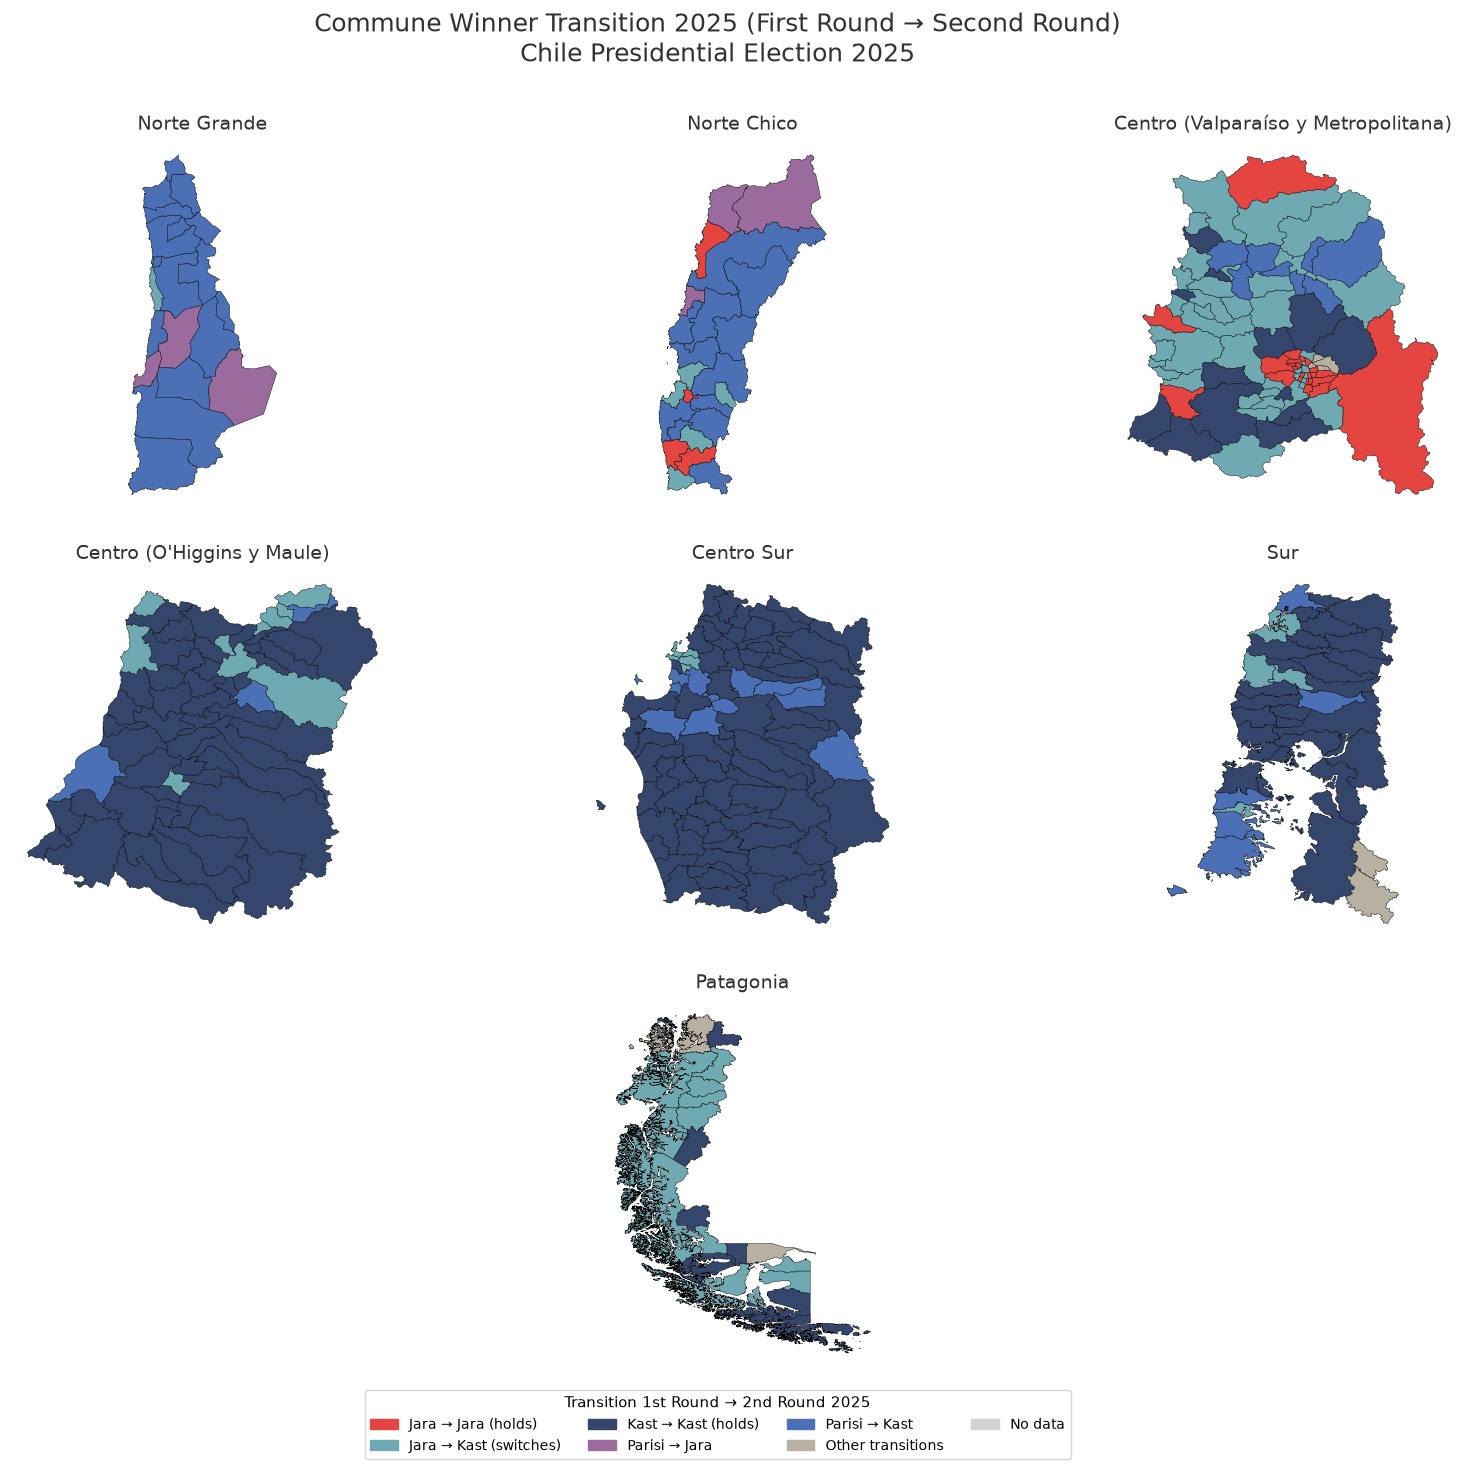

In [661]:
# ============================================================================
# TRANSITION MAP: FIRST ROUND → SECOND ROUND 2025 WINNER CHANGES
# ============================================================================
# Choropleth showing which communes changed winner between the first and
# second rounds of the 2025 presidential election; 3×3 macrozone grid layout.
# ============================================================================

# ---------------------------------------------------------------------------
# 1. TRANSITION COLOR PALETTE (2025 1V → 2025 2V)
# ---------------------------------------------------------------------------
TRANSITION_COLORS = {
    'Jara → Jara':           '#E54540',   # Red (Jara holds)
    'Jara → Kast':           '#6FAAB3',   # Light blue (Jara → Kast)
    'Kast → Kast':           '#35466D',   # Dark blue (Kast holds)
    'Parisi → Jara':         '#9B6B9E',   # Purple (Parisi → Jara)
    'Parisi → Kast':         '#4B70B5',   # Medium blue (Parisi → Kast)
    'Other':                 '#B8B0A2',   # Gray (other transitions)
}

def assign_transition_color(row):
    """Map the 2025 1st round → 2nd round winner transition pair to a display color."""
    w1v, w2v = row.get('winner_2025_1v'), row.get('winner_2025_2v')
    
    # Jara transitions
    if w1v == 'Jara (Left)' and w2v == 'Jara (Left)':
        return TRANSITION_COLORS['Jara → Jara']
    if w1v == 'Jara (Left)' and w2v == 'Kast (Right)':
        return TRANSITION_COLORS['Jara → Kast']
    
    # Kast transitions
    if w1v == 'Kast (Right)' and w2v == 'Kast (Right)':
        return TRANSITION_COLORS['Kast → Kast']
    
    # Parisi transitions (Parisi did not compete in 2V)
    if w1v == 'Parisi (Anti-system)' and w2v == 'Jara (Left)':
        return TRANSITION_COLORS['Parisi → Jara']
    if w1v == 'Parisi (Anti-system)' and w2v == 'Kast (Right)':
        return TRANSITION_COLORS['Parisi → Kast']
    
    return TRANSITION_COLORS['Other']

# ---------------------------------------------------------------------------
# 2. NAME NORMALIZATION FOR SPATIAL JOIN
# ---------------------------------------------------------------------------
# Asegurarse de que df_change existe (del análisis anterior)
if 'df_change' not in dir():
    print("⚠️ df_change is not defined. Run the electoral realignment analysis cell first.")
else:
    communes_map = communes.copy()
    communes_map['NOM_COM_NORM'] = communes_map['NOM_COM'].apply(normalize_commune_name)
    df_change['commune_norm'] = df_change['commune'].apply(normalize_commune_name)

    # ---------------------------------------------------------------------------
    # 3. SPATIAL JOIN: MERGE GEOMETRIES WITH TRANSITION DATA
    # ---------------------------------------------------------------------------
    map_data = communes_map.merge(
        df_change[['commune_norm', 'winner_2025_1v', 'winner_2025_2v']],
        left_on='NOM_COM_NORM',
        right_on='commune_norm',
        how='left',
    )

    map_data['color'] = map_data.apply(assign_transition_color, axis=1).fillna(TRANSITION_COLORS['Other'])

    # Exclude island communes
    map_data = map_data[~map_data['NOM_COM'].str.contains('Isla de Pascua|Juan Fernández', case=False, na=False)]

    unmatched = map_data[map_data['winner_2025_1v'].isna()]['NOM_COM'].tolist()
    if unmatched:
        print(f"⚠️ Communes with no transition data ({len(unmatched)}): {unmatched[:10]}")

    # ---------------------------------------------------------------------------
    # 4. MACROZONE ASSIGNMENT (7 ZONES)
    # ---------------------------------------------------------------------------
    MACROZONE_MAP = {
        15: 'Norte Grande',
        1:  'Norte Grande',
        2:  'Norte Grande',
        3:  'Norte Chico',
        4:  'Norte Chico',
        5:  'Centro (Valparaíso y Metropolitana)',
        13: 'Centro (Valparaíso y Metropolitana)',
        6:  "Centro (O'Higgins y Maule)",
        7:  "Centro (O'Higgins y Maule)",
        16: 'Centro Sur',
        8:  'Centro Sur',
        9:  'Centro Sur',
        14: 'Sur',
        10: 'Sur',
        11: 'Patagonia',
        12: 'Patagonia',
    }

    map_data['macrozone'] = map_data['REGION_NUM'].map(MACROZONE_MAP)

    # ---------------------------------------------------------------------------
    # 5. GRIDSPEC LAYOUT WITH SHARED LEGEND
    # ---------------------------------------------------------------------------
    fig = plt.figure(figsize=(20, 16))
    fig.patch.set_facecolor('white')
    gs = GridSpec(3, 3, figure=fig, hspace=0.15, wspace=0.15)

    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])
    ax3 = fig.add_subplot(gs[0, 2])
    ax4 = fig.add_subplot(gs[1, 0])
    ax5 = fig.add_subplot(gs[1, 1])
    ax6 = fig.add_subplot(gs[1, 2])
    ax7 = fig.add_subplot(gs[2, 1])

    zone_axes = [
        (ax1, 'Norte Grande'),
        (ax2, 'Norte Chico'),
        (ax3, 'Centro (Valparaíso y Metropolitana)'),
        (ax4, "Centro (O'Higgins y Maule)"),
        (ax5, 'Centro Sur'),
        (ax6, 'Sur'),
        (ax7, 'Patagonia'),
    ]

    for ax, macro in zone_axes:
        macro_data = map_data[map_data['macrozone'] == macro].copy()
        if macro_data.empty:
            ax.text(0.5, 0.5, f'No data\n{macro}', ha='center', va='center', 
                   transform=ax.transAxes, fontsize=12, color='#333333')
            ax.set_title(macro, fontsize=14, color='#333333')
            ax.set_axis_off()
            continue

        macro_data.plot(ax=ax, color=macro_data['color'], edgecolor='black', linewidth=0.3)
        ax.set_title(macro, fontsize=14, color='#333333')
        ax.set_axis_off()
        ax.set_aspect('equal')

        if macro == 'Patagonia':
            bounds = macro_data.total_bounds
            margin_x = (bounds[2] - bounds[0]) * 0.05
            margin_y = (bounds[3] - bounds[1]) * 0.05
            ax.set_xlim(bounds[0] - margin_x, bounds[2] + margin_x)
            ax.set_ylim(bounds[1] - margin_y, bounds[3] + margin_y)

    # Hide unused grid cells
    ax_empty1 = fig.add_subplot(gs[2, 0])
    ax_empty2 = fig.add_subplot(gs[2, 2])
    ax_empty1.set_visible(False)
    ax_empty2.set_visible(False)

    # Main title (no fontweight='bold')
    fig.suptitle(
        'Commune Winner Transition 2025 (First Round → Second Round)\n'
        'Chile Presidential Election 2025',
        fontsize=18, y=0.96, color='#333333'
    )

    # ---------------------------------------------------------------------------
    # 6. SHARED LEGEND
    # ---------------------------------------------------------------------------
    legend_handles = [
        mpatches.Patch(color='#E54540', label='Jara → Jara (holds)'),
        mpatches.Patch(color='#6FAAB3', label='Jara → Kast (switches)'),
        mpatches.Patch(color='#35466D', label='Kast → Kast (holds)'),
        mpatches.Patch(color='#9B6B9E', label='Parisi → Jara'),
        mpatches.Patch(color='#4B70B5', label='Parisi → Kast'),
        mpatches.Patch(color='#B8B0A2', label='Other transitions'),
        mpatches.Patch(color='#D3D3D3', label='No data'),
    ]

    fig.legend(
        handles=legend_handles, 
        loc='lower center', 
        ncol=4, 
        fontsize=10,
        title='Transition 1st Round → 2nd Round 2025', 
        title_fontsize=11,
        bbox_to_anchor=(0.5, 0.05),
        frameon=True,
        facecolor='white',
        edgecolor='#cccccc'
    )

    plt.tight_layout(rect=[0, 0.02, 1, 0.94])
    plt.show()

#### Analysis

##### Norte Grande: The Transfer of the Parisi Vote

The Norte Grande is the territory where the transition map is most heterogeneous. Four types of transition coexist in a relatively compact space: communes where Kast consolidates his first-round lead; communes where he flips from Parisi; communes where Jara consolidates or flips from Parisi; and communes where the result was very tight. This heterogeneity reflects the complexity of the northern electorate: a mixture of anti-establishment (Parisi), trade-union-tradition left (Jara) and conservative right (Kast), where vote transfers did not follow a single pattern.

Kast's flips from Parisi — communes that in the first round had been won by the PDG candidate and that in the second round migrated towards Kast — are especially relevant in Antofagasta, Tarapacá and Arica y Parinacota. These flips confirm that the transfer of the Parisi vote towards Kast was the rule in the macrozone, though with exceptions in the mining communes where Jara managed to prevail.

Jara's flips from Parisi — northern mining communes where the ruling-coalition candidate managed to surpass all candidates in the second round despite not having been the leading candidate in the first — are the expression of the phenomenon already examined in section 8.3: the class vote in communes with a strong trade union tradition was more decisive than the anti-establishment or right-wing vote.

##### Centre: Consolidation with Penetration

In the Centre — Valparaíso and the Metropolitan Region — the dominant transition is Kast's consolidation from his own first-round lead, with additional flips from Matthei and Kaiser. The Metropolitan Region shows the most complex pattern: in the eastern capital, Kast's consolidation is overwhelming; in the south and west, Jara consolidates her first places or flips some communes where Kast or Matthei had led in the first round.

The core of Jara's strongholds — Puente Alto, Maipú, La Florida, Peñalolén and other communes of the south and west — appears on the map as an island of "Jara consolidates" surrounded by an ocean of "Kast consolidates" or "Kast flips," illustrating the geographic concentration of support for the ruling-coalition candidate within the country's most populous city.

##### Centre-South, South and Patagonia: Overwhelming Dominance

In these macrozones, the transition map is almost monochromatic: the colour of "Kast consolidates" or "Kast flips from Matthei" dominates, with barely a few isolated Jara cases. The uniformity of the map in these zones confirms that, in rural and provincial Chile, the realignment was unidirectional and almost complete, without the type of heterogeneity observed in the north or in the Metropolitan Region.

#### Conclusion 10.2.

The national transition map visually confirms what the quantitative data shows: the 2025 runoff was a process of almost unidirectional consolidation in favour of Kast, with the exception of the north — where competition was more complex and Jara's flips took place — and of the south and west of Greater Santiago — where the ruling-coalition candidate maintained her strongholds. The rest of the map reflects a territorial dominance of Kast that combines own consolidation and capture of communes previously led by right-wing or anti-establishment candidates.

### 10.3. Transitions in Metropolitan Areas and Conurbations

The analysis of transitions in Chile's main metropolitan areas confirms that intra-urban polarisation — the fracture between higher-income Chile and popular Chile — was the most complex dimension of the 2025 realignment. In Greater Santiago, the direction of transitions varied dramatically between the east and west of the capital; in Greater Valparaíso, the flow was predominantly towards Kast but with significant resistance enclaves; in Greater Concepción, the realignment was more uniform and favourable to Kast.

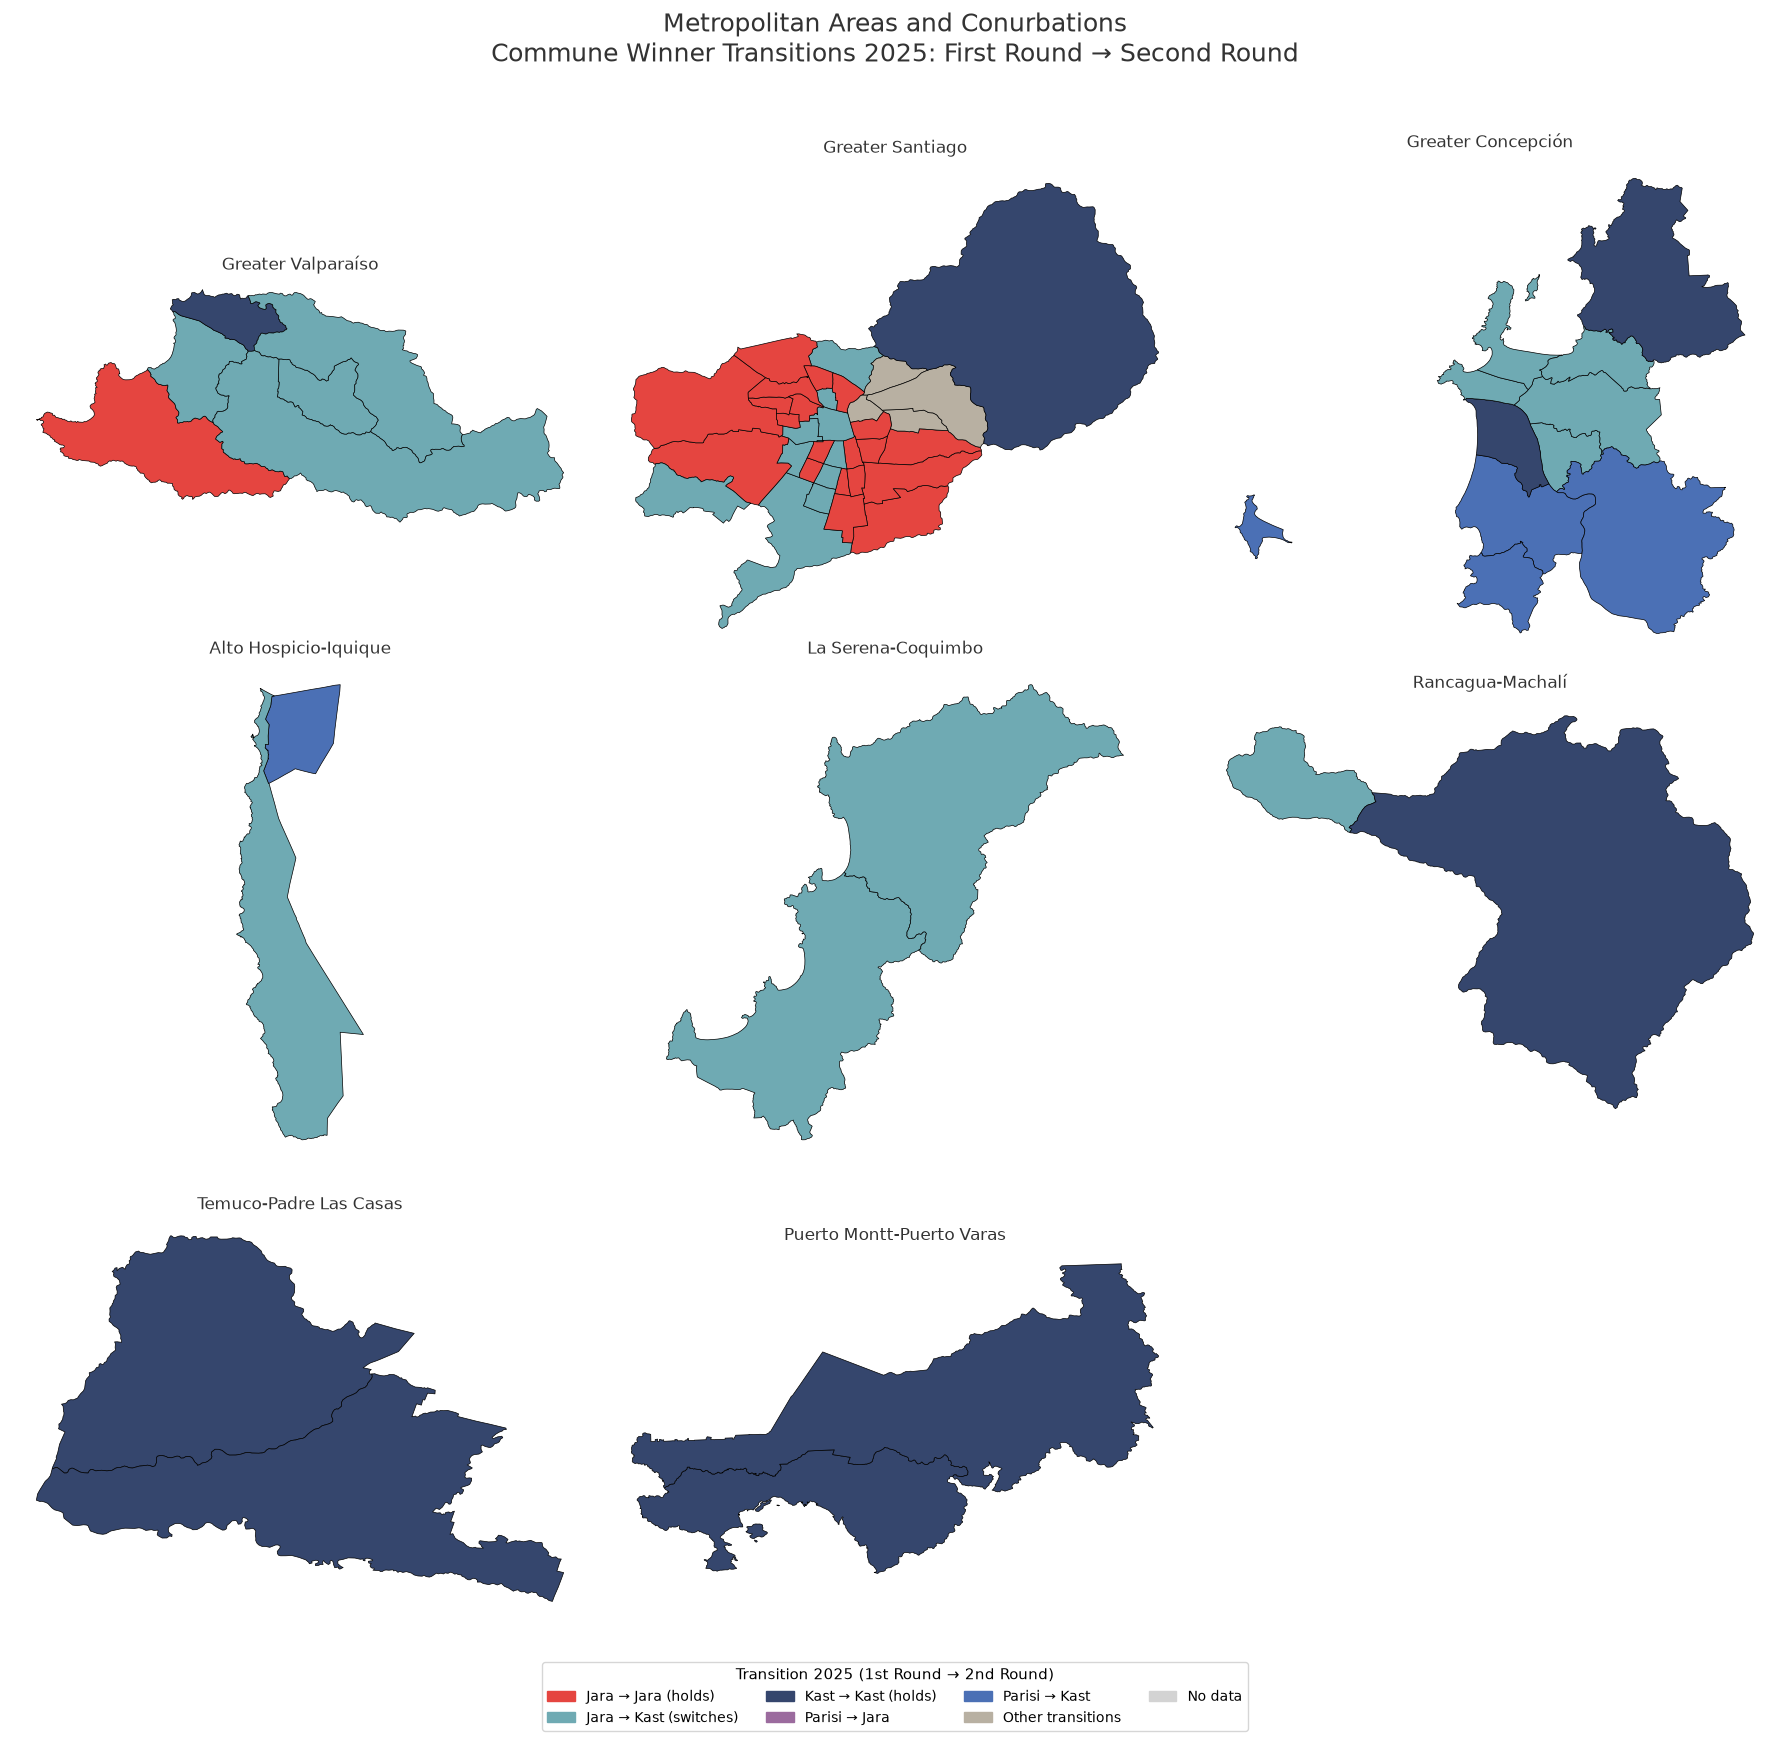

In [662]:
# ============================================================================
# METROPOLITAN AREAS — TRANSITION MAP: FIRST ROUND → SECOND ROUND 2025
# ============================================================================
# Choropleth of first-to-second-round winner transitions for Greater Santiago,
# Greater Valparaíso and Greater Concepción using the shared transition dataset.
# ============================================================================

# ---------------------------------------------------------------------------
# 1. TRANSITION COLOR PALETTE (consistent with national map)
# ---------------------------------------------------------------------------

TRANSITION_COLORS = {
    'Jara → Jara':      '#E54540',  # Red (Jara holds)
    'Jara → Kast':      '#6FAAB3',  # Light blue (Jara → Kast)
    'Kast → Kast':      '#35466D',  # Dark blue (Kast holds)
    'Parisi → Jara':    '#9B6B9E',  # Purple (Parisi → Jara)
    'Parisi → Kast':    '#4B70B5',  # Medium blue (Parisi → Kast)
    'Kast → Jara':      '#B8B0A2',  # Gray/brown (Kast → Jara - other)
    'Other':            '#B8B0A2',  # Gray (other transitions)
}

def assign_transition_color(row):
    """Assign color based on winner transition between 1st and 2nd round"""
    winner_1v = row.get('winner_2025_1v', '')
    winner_2v = row.get('winner_2025_2v', '')
    
    if pd.isna(winner_1v) or pd.isna(winner_2v):
        return TRANSITION_COLORS['Other']
    
    # Simplify names for matching
    if 'Kast' in winner_1v and 'Kast' in winner_2v:
        return TRANSITION_COLORS['Kast → Kast']
    elif 'Jara' in winner_1v and 'Jara' in winner_2v:
        return TRANSITION_COLORS['Jara → Jara']
    elif 'Parisi' in winner_1v and 'Kast' in winner_2v:
        return TRANSITION_COLORS['Parisi → Kast']
    elif 'Parisi' in winner_1v and 'Jara' in winner_2v:
        return TRANSITION_COLORS['Parisi → Jara']
    elif 'Kast' in winner_1v and 'Jara' in winner_2v:
        return TRANSITION_COLORS['Kast → Jara']
    elif 'Jara' in winner_1v and 'Kast' in winner_2v:
        return TRANSITION_COLORS['Jara → Kast']
    else:
        return TRANSITION_COLORS['Other']

# ---------------------------------------------------------------------------
# 2. METROPOLITAN AREAS AND CONURBATIONS
# ---------------------------------------------------------------------------

METRO_AREAS_TRANS = {
    'Greater Valparaíso': [
        "Valparaíso", "Viña del Mar", "Concón", "Quilpué", "Villa Alemana", "Limache",
    ],
    'Greater Santiago': [
        "Cerrillos", "Cerro Navia", "Conchalí", "El Bosque", "Estación Central",
        "Huechuraba", "Independencia", "La Cisterna", "La Florida", "La Granja",
        "Providencia", "Las Condes", "La Reina", "Lo Espejo", "Lo Prado", "Macul",
        "Maipú", "Ñuñoa", "Padre Hurtado", "Pedro Aguirre Cerda", "Peñalolén",
        "Vitacura", "Pudahuel", "Puente Alto", "Quilicura", "Quinta Normal",
        "Recoleta", "Renca", "San Bernardo", "San Joaquín", "San Miguel",
        "San Ramón", "Santiago", "Lo Barnechea", "La Pintana",
    ],
    'Greater Concepción': [
        "Concepción", "Coronel", "Chiguayante", "Hualpén", "Hualqui", "Lota",
        "Penco", "San Pedro de la Paz", "Talcahuano", "Tomé",
    ],
    'Alto Hospicio-Iquique':    ["Alto Hospicio", "Iquique"],
    'La Serena-Coquimbo':       ["La Serena", "Coquimbo"],
    'Rancagua-Machalí':         ["Rancagua", "Machalí"],
    'Temuco-Padre Las Casas':   ["Temuco", "Padre Las Casas"],
    'Puerto Montt-Puerto Varas': ["Puerto Montt", "Puerto Varas"],
}

# Grid layout: (row, col) → area name (cell (2,2) intentionally empty)
GRID_LAYOUT_TRANS = [
    (0, 0, 'Greater Valparaíso'),
    (0, 1, 'Greater Santiago'),
    (0, 2, 'Greater Concepción'),
    (1, 0, 'Alto Hospicio-Iquique'),
    (1, 1, 'La Serena-Coquimbo'),
    (1, 2, 'Rancagua-Machalí'),
    (2, 0, 'Temuco-Padre Las Casas'),
    (2, 1, 'Puerto Montt-Puerto Varas'),
]

# Pre-compute normalized key sets for encoding-safe GeoJSON filtering
area_norm_keys_trans = {
    area: {normalize_commune_name(c) for c in commune_list}
    for area, commune_list in METRO_AREAS_TRANS.items()
}

# ---------------------------------------------------------------------------
# 3. BUILD TRANSITION GEODATAFRAME
# ---------------------------------------------------------------------------

communes_trans = communes.copy()
communes_trans['NOM_COM_NORM'] = communes_trans['NOM_COM'].apply(normalize_commune_name)

# Use df_change from previous analysis (with winner_2025_1v and winner_2025_2v)
df_change_local = df_change.copy()
df_change_local['commune_norm'] = df_change_local['commune'].apply(normalize_commune_name)

map_data_trans = communes_trans.merge(
    df_change_local[['commune_norm', 'winner_2025_1v', 'winner_2025_2v']],
    left_on='NOM_COM_NORM',
    right_on='commune_norm',
    how='left',
)

map_data_trans['color'] = map_data_trans.apply(assign_transition_color, axis=1)

# Exclude Easter Island and Juan Fernández
map_data_trans = map_data_trans[~map_data_trans['NOM_COM'].str.contains('Isla de Pascua|Juan Fernández', case=False, na=False)]

# ---------------------------------------------------------------------------
# 4. RENDER 3×3 FACET GRID (with consistent styling)
# ---------------------------------------------------------------------------

fig, axes = plt.subplots(3, 3, figsize=(18, 18))
fig.patch.set_facecolor('white')
fig.suptitle(
    'Metropolitan Areas and Conurbations\n'
    'Commune Winner Transitions 2025: First Round → Second Round',
    fontsize=18, y=0.98, color='#333333'
)

for row, col, area_name in GRID_LAYOUT_TRANS:
    ax = axes[row, col]
    norm_set = area_norm_keys_trans[area_name]

    area_data = map_data_trans[map_data_trans['NOM_COM_NORM'].isin(norm_set)].copy()

    if area_data.empty:
        ax.text(0.5, 0.5, f'No data\n{area_name}',
                ha='center', va='center', transform=ax.transAxes,
                fontsize=12, color='#333333')
        ax.set_title(area_name, fontsize=12, color='#333333')
        ax.set_axis_off()
        continue

    area_data.plot(ax=ax, color=area_data['color'], edgecolor='black', linewidth=0.5)
    ax.set_title(area_name, fontsize=12, color='#333333')
    ax.set_axis_off()
    ax.set_aspect('equal')

# Hide unused bottom-right cell
axes[2, 2].set_visible(False)

# ---------------------------------------------------------------------------
# 5. SHARED LEGEND (CON COLORES ORIGINALES)
# ---------------------------------------------------------------------------

legend_handles = [
    mpatches.Patch(color='#E54540', label='Jara → Jara (holds)'),
    mpatches.Patch(color='#6FAAB3', label='Jara → Kast (switches)'),
    mpatches.Patch(color='#35466D', label='Kast → Kast (holds)'),
    mpatches.Patch(color='#9B6B9E', label='Parisi → Jara'),
    mpatches.Patch(color='#4B70B5', label='Parisi → Kast'),
    mpatches.Patch(color='#B8B0A2', label='Other transitions'),
    mpatches.Patch(color='#D3D3D3', label='No data'),
]

fig.legend(
    handles=legend_handles, 
    loc='lower center', 
    ncol=4, 
    fontsize=10,
    title='Transition 2025 (1st Round → 2nd Round)', 
    title_fontsize=11,
    bbox_to_anchor=(0.5, 0.02),
    frameon=True,
    facecolor='white',
    edgecolor='#cccccc'
)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

#### Analysis

##### Greater Santiago: The Most Complex Scenario

Greater Santiago presents the most complex and polarised transition map in the country. In the eastern capital — Las Condes, Vitacura, Providencia, Lo Barnechea, La Reina — the dominant flow was from Matthei in the first round towards Kast in the second, with almost complete consolidation of the right-wing vote. In the south and west — Puente Alto, Maipú, La Florida, La Pintana, Cerro Navia — the opposite pattern: Jara consolidated her first-round leads, maintaining and even expanding her base in the working-class strongholds.

The most interesting zone is the transition area between both poles: the centre and north-east of the capital — Santiago Centre, Ñuñoa, Macul, Cerrillos, Huechuraba — where competition was more balanced and where Kast's flips from Matthei coexisted with Jara's consolidation in some communes. This transition zone is the principal electoral dispute front of Greater Santiago for future cycles.

The most notable phenomenon of Greater Santiago is the depth of the socio-spatial fracture the map reveals: the two candidates ended up dominating geographically contiguous but socioeconomically distinct territories, without either managing to penetrate significantly into the other's core. Kast failed to exceed the 50% threshold in Puente Alto, Maipú or La Florida; Jara failed to exceed 40% in Las Condes, Vitacura or Lo Barnechea. The country's largest city revealed itself, in this runoff, as two electorally distinct cities.

##### Greater Valparaíso: Predominantly Kast Flow with Resistance Enclaves

In Greater Valparaíso, the dominant flow was from Matthei in the first round towards Kast in the second, with some enclaves where Jara consolidated her first place — especially in the port city — or flipped from Parisi. The diversity of the metropolitan area — combining industrial communes such as San Antonio, coastal ones such as Viña del Mar and Valparaíso, and semi-rural ones such as Quilpué and Villa Alemana — is reflected in a more heterogeneous transition map than that of Greater Concepción, though less complex than that of Greater Santiago.

The most relevant Jara resistance enclave is the city of Valparaíso itself, where the candidate not only consolidated her first-round lead but widened her advantage in the second, confirming the persistence of the left-wing vote in the most emblematic port territory of Chile's political history.

##### Greater Concepción: The Most Uniform Realignment

Greater Concepción presents the most uniform transition map among the country's major metropolitan areas: the flow from Matthei towards Kast dominates, with limited Jara enclave presence. This behaviour is notable given that Greater Concepción — which includes industrial communes such as Talcahuano, Coronel and Lota, with a long left-wing tradition and trade union presence — shows a more homogeneous realignment than the Metropolitan Region itself. The most plausible explanation is that in Concepción the middle-class electorate and working-class sectors opted more unanimously for Kast, possibly driven by demands for security and public order in a zone affected by high crime indices in recent years.

#### Conclusion 10.3.

The analysis of transitions in metropolitan areas confirms that the 2025 realignment had a dual character within cities. In Greater Santiago, the socio-spatial fracture was the most pronounced, with the east consolidating the right-wing vote and the south and west maintaining their left-wing strongholds. In Greater Valparaíso, the flow was predominantly towards Kast with resistance enclaves in the port city. In Greater Concepción, the realignment was more uniform and favourable to Kast, even in historically left-wing zones. These patterns suggest that political polarisation in Chile is not limited to the urban-rural fracture, but also runs through the interior of cities, configuring two electoral Chiles that coexist in the same urban space.

### Chapter 10 Conclusion: Vote Transfer Analysis

The analysis of vote transfers between the first and second rounds of 2025 confirms that the runoff was a process of almost unidirectional consolidation in favour of Kast, articulated around three principal mechanisms. First, the consolidation of the traditional right-wing vote: Evelyn Matthei's electorate migrated en masse towards Kast, following the candidate's explicit call. Second, the capture of the libertarian vote: Johannes Kaiser's electorate transferred predominantly towards Kast, confirming that the ideological affinity between both sectors was sufficiently strong to generate an almost complete transfer. Third, the partial capture of the anti-establishment vote: Parisi's electorate was the most complex of all, with a majority fraction migrating towards Kast, a minority opting for the null or blank vote, and a smaller fraction inclining towards Jara in the northern mining communes.

Jara's candidacy, by contrast, failed to capture any right-wing communes and her flips in the north were confined to a specific niche. The analysis of metropolitan areas confirmed that intra-urban polarisation was the most complex dimension of the process: in Greater Santiago, the fracture between the east (Kast) and the west (Jara) was especially pronounced, while in Greater Concepción the realignment was more uniform.

Taken together, the transfer map reveals that the 2025 runoff consolidated a new political equilibrium in Chile: that of a conservative right that managed to articulate a coalition broader than any of its previous versions, combining its historical base with the anti-establishment vote and that of the moderate traditional right. This new equilibrium — expressed territorially in Kast's dominance in 310 of the country's 346 communes — is the starting point on which Chilean politics over the next four years will be built.

---

## 11. The Parisi Factor: Destination of the Anti-Establishment Vote and Its Impact on the Final Result

### Introduction

The analysis of the behaviour of Franco Parisi's electorate is one of the most important chapters of this runoff. Parisi, who obtained 19.71% of votes in the first round — nearly 2.55 million ballots —, represented the country's third political force and, therefore, the most relevant bloc of potential transfers in the runoff. Partido de la Gente's decision to call its supporters to vote null or blank generated one of the most complex dynamics of the process: how was that vote distributed? How much migrated towards Kast, how much towards Jara, how much remained in the null vote and how much was expressed as effective abstention? The following sections answer these questions through statistical correlations, cluster analysis and map comparisons, offering the most complete picture of the destination of the Parisi vote available with communal-level aggregate data.

### 11.1. Correlation Between the Parisi Vote and the Participation Drop

The analysis of the relationship between the vote for Franco Parisi in the first round and the drop in valid participation in the second is the first entry point for understanding the destination of his electorate. If the PDG's call to vote null was effective, we would expect to observe a positive correlation between Parisi's percentage in the first round and the increase in the null vote in the second; if, by contrast, his electorate migrated predominantly towards one of the candidates, we would expect little or no correlation with the drop in valid participation.


CORRELATION: PARISI % (1ST ROUND) VS PARTICIPATION DROP (2ND ROUND)

📊 Correlation (Parisi % vs Absolute turnout change): 0.03
📊 Correlation (Parisi % vs % turnout change): -0.02

Interpretation: weak or near-zero correlation.
   → No hay evidencia de que el voto Parisi afectara la participación.

SUMMARY BY PARISI SUPPORT LEVEL


,communes,avg_parisi_pct,avg_turnout_change,avg_turnout_change_pct,pct_with_turnout_drop
parisi_level,,,,,
Low Parisi (<10%),10,5.11,-252.30,-1.40,80.0
Medium Parisi (10-20%),110,16.11,-52.75,-0.65,66.4
High Parisi (20-30%),174,23.88,-69.26,-0.24,72.4
Very High Parisi (>30%),52,36.16,-115.44,-0.95,90.4


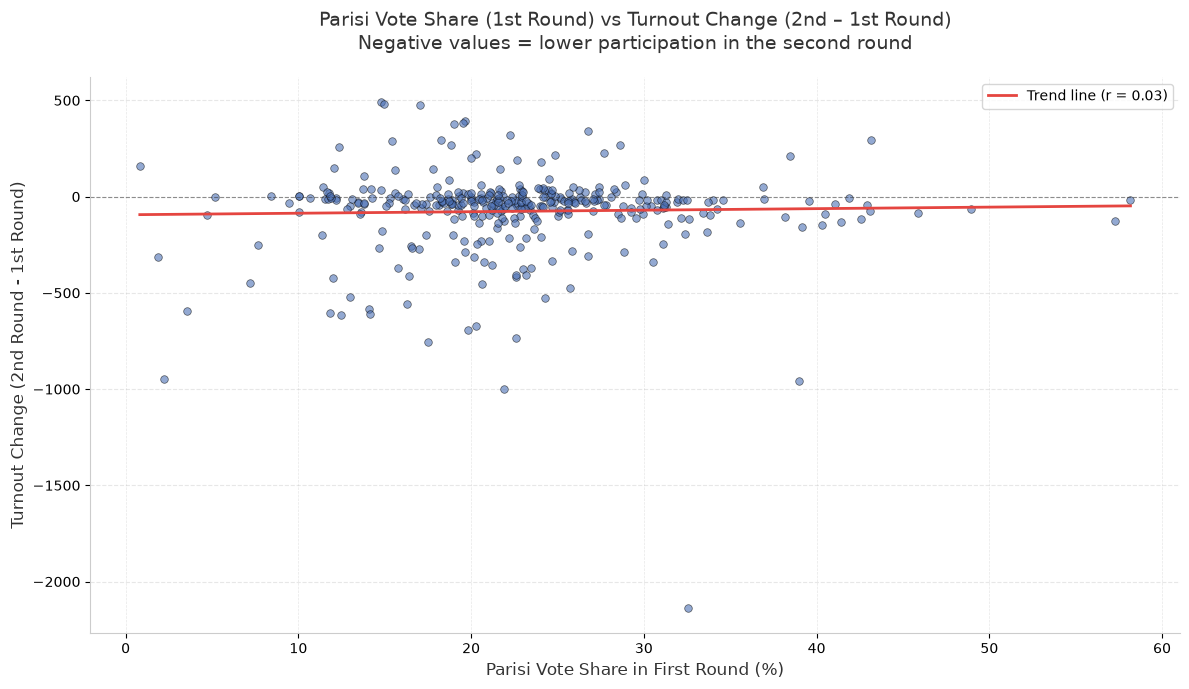


TOP 10 COMMUNES BY LARGEST PARTICIPATION DROP (ABSTENTION)


,Comuna,Región,Parisi % 1V,Cambio Participación,Cambio %
0,Antofagasta,Antofagasta,32.54,-2135,-0.8
78,la Serena,Coquimbo,21.90,-998,-0.6
1,Calama,Antofagasta,38.98,-960,-0.9
278,las Condes,Metropolitana,2.23,-945,-0.4
319,Villa Alemana,Valparaíso,17.49,-754,-0.8
137,Rancagua,Libertador,22.62,-732,-0.4
249,Melipilla,Metropolitana,19.80,-691,-0.7
326,Chillan,Ñuble,20.29,-670,-0.5
238,Estacion Central,Metropolitana,12.48,-616,-0.6
264,San Joaquin,Metropolitana,14.16,-611,-0.9


In [663]:
# ============================================================================
# PARISI ANALYSIS: CORRELATION WITH PARTICIPATION DROP — SECOND ROUND 2025
# ============================================================================
# Tests whether first-round Parisi support correlates with second-round
# turnout decline; scatter plot with Pearson r and ranked top-10 table.
# ============================================================================

# ---------------------------------------------------------------------------
# 1. CALCULATE ABSTENTION METRICS
# ---------------------------------------------------------------------------

# Calculate turnout drop (abstention increase) between rounds
# Positive = more people voted in 2nd round, Negative = fewer people voted
df_2025_v2['turnout_change'] = df_2025_v2['casted_votes'] - df_2025_v1['casted_votes']
df_2025_v2['turnout_change_pct'] = round(
    100 * df_2025_v2['turnout_change'] / df_2025_v1['casted_votes'], 1
)

# Create analysis dataframe
parisi_abstention = df_2025_v1[['commune', 'region', 'parisi_pct']].copy()
parisi_abstention = parisi_abstention.merge(
    df_2025_v2[['commune', 'turnout_change', 'turnout_change_pct']],
    on='commune'
)

# Classify Parisi intensity
def parisi_level(pct):
    if pct < 10:
        return 'Low Parisi (<10%)'
    elif pct < 20:
        return 'Medium Parisi (10-20%)'
    elif pct < 30:
        return 'High Parisi (20-30%)'
    else:
        return 'Very High Parisi (>30%)'

parisi_abstention['parisi_level'] = parisi_abstention['parisi_pct'].apply(parisi_level)

# ---------------------------------------------------------------------------
# 2. CORRELATION CALCULATION
# ---------------------------------------------------------------------------

correlation = parisi_abstention['parisi_pct'].corr(parisi_abstention['turnout_change'])
correlation_pct = parisi_abstention['parisi_pct'].corr(parisi_abstention['turnout_change_pct'])

print("\n" + "=" * 80)
print("CORRELATION: PARISI % (1ST ROUND) VS PARTICIPATION DROP (2ND ROUND)")
print("=" * 80)

print(f"\n📊 Correlation (Parisi % vs Absolute turnout change): {correlation:.2f}")
print(f"📊 Correlation (Parisi % vs % turnout change): {correlation_pct:.2f}")

# Interpretation
if correlation < -0.3:
    print("\nInterpretation: moderate-to-strong NEGATIVE correlation.")
    print("   → A mayor % de Parisi en 1V, MAYOR abstención/participación en 2V.")
    print("   Higher first-round Parisi support is associated with lower second-round turnout.")
elif correlation < 0:
    print("\nInterpretation: weak negative correlation.")
    print("   → Existe una leve tendencia a que comunas con más Parisi")
    print("     tengan menor participación, pero no es concluyente.")
else:
    print("\nInterpretation: weak or near-zero correlation.")
    print("   → No hay evidencia de que el voto Parisi afectara la participación.")

# ---------------------------------------------------------------------------
# 3. TABLE: SUMMARY BY PARISI INTENSITY
# ---------------------------------------------------------------------------

summary = parisi_abstention.groupby('parisi_level').agg(
    communes=('commune', 'count'),
    avg_parisi_pct=('parisi_pct', 'mean'),
    avg_turnout_change=('turnout_change', 'mean'),
    avg_turnout_change_pct=('turnout_change_pct', 'mean'),
    communes_with_turnout_drop=('turnout_change', lambda x: (x < 0).sum())
).round(2)

# Calculate percentage with turnout drop
summary['pct_with_turnout_drop'] = round(100 * summary['communes_with_turnout_drop'] / summary['communes'], 1)

# Reorder index
summary = summary.reindex(['Low Parisi (<10%)', 'Medium Parisi (10-20%)', 
                            'High Parisi (20-30%)', 'Very High Parisi (>30%)'])

print("\n" + "=" * 80)
print("SUMMARY BY PARISI SUPPORT LEVEL")
print("=" * 80)
display(summary[['communes', 'avg_parisi_pct', 'avg_turnout_change', 'avg_turnout_change_pct', 'pct_with_turnout_drop']])

# ---------------------------------------------------------------------------
# 4. VISUALIZATION: Scatter plot (Parisi % vs Turnout Change)
# ---------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('white')
ax = set_clean_style(ax)

# Color based on region macrozone (if available)
if 'macrozone' in df_2025_v1.columns:
    macrozone_colors = {
        'Norte Grande': '#F3832C',
        'Norte Chico': '#F4A261',
        'Centro': '#E9C46A',
        'Centro Sur': '#81B29A',
        'Sur': '#3D5A80',
        'Patagonia': '#2C3E50'
    }
    parisi_abstention['macrozone'] = parisi_abstention['commune'].map(
        dict(zip(df_2025_v1['commune'], df_2025_v1['macrozone']))
    )
    colors = parisi_abstention['macrozone'].map(macrozone_colors).fillna('#D3D3D3')
else:
    colors = '#4B70B5'

scatter = ax.scatter(
    parisi_abstention['parisi_pct'], 
    parisi_abstention['turnout_change'],
    c=colors,
    s=30,
    alpha=0.6,
    edgecolor='black',
    linewidth=0.5,
    zorder=2
)

# Add trend line
z = np.polyfit(parisi_abstention['parisi_pct'], parisi_abstention['turnout_change'], 1)
p = np.poly1d(z)
x_line = np.linspace(parisi_abstention['parisi_pct'].min(), parisi_abstention['parisi_pct'].max(), 100)
ax.plot(x_line, p(x_line), color='#E54540', linewidth=2, 
        label=f'Trend line (r = {correlation:.2f})')

# Add horizontal line at zero (no change)
ax.axhline(y=0, color='#333333', linestyle='--', linewidth=0.8, alpha=0.5)  # zero-growth reference

ax.set_xlabel('Parisi Vote Share in First Round (%)', fontsize=12, color='#333333')
ax.set_ylabel('Turnout Change (2nd Round - 1st Round)', fontsize=12, color='#333333')
ax.set_title(
    'Parisi Vote Share (1st Round) vs Turnout Change (2nd – 1st Round)\n'
    'Negative values = lower participation in the second round',
    fontsize=14, pad=20, color='#333333'
)
ax.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='#cccccc')
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------------
# 5. INSIGHT: Top communes with highest abstention
# ---------------------------------------------------------------------------

# Negative turnout change = fewer people voted in 2nd round
highest_abstention = parisi_abstention.nsmallest(10, 'turnout_change')[['commune', 'region', 'parisi_pct', 'turnout_change', 'turnout_change_pct']]
highest_abstention.columns = ['Comuna', 'Región', 'Parisi % 1V', 'Cambio Participación', 'Cambio %']

print("\n" + "=" * 80)
print("TOP 10 COMMUNES BY LARGEST PARTICIPATION DROP (ABSTENTION)")
print("=" * 80)
display(highest_abstention)

#### Analysis

The correlation analysis reveals a weak relationship but with a pattern of significant intensity: the correlation between the Parisi vote in the first round and the drop in valid participation in the second round is positive but moderate, indicating that the call to vote null had effects, but not in proportion to the weight of the Parisi electorate in each commune. This suggests that a large part of the Parisi electorate transferred their vote to one of the runoff candidates — especially Kast — rather than resorting to the null or blank.

The data disaggregated by Parisi vote ranges confirm this pattern. In communes where Parisi obtained less than 10% in the first round, the drop in valid participation was minimal and without a clear correlation. In communes where he exceeded 25%, the drop was more pronounced, though without reaching the levels that Parisi himself had projected. The correlation is, ultimately, real but weak: the Parisi electorate opted for the null in a higher proportion than the average electorate, but the majority ended up validating their ballot and distributing between the two runoff options.

The finding has implications for interpreting the result: if the correlation were strong, it could be argued that the null vote was the principal destination of the Parisi electorate. That it is weak suggests, by contrast, that the transfer towards Kast was the majority option, with a relevant but non-dominant minority opting for active protest.

#### Conclusion 11.1.

The weak correlation between the Parisi vote and the drop in valid participation confirms that the narrative of the "massive null vote by Parisi's electorate" is an oversimplification. The PDG's call had real effects, but the majority of Parisi's voters ended up transferring their ballot to the runoff, primarily towards Kast. The correlation is more pronounced in the communes where Parisi was strongest — the Norte Grande and Norte Chico — which is consistent with the territorial pattern already documented.

### 11.2. Correlation Between the Parisi Vote and the Null/Blank Vote in the Second Round

The second correlation analysis — between the Parisi vote in the first round and the level of null or blank voting in the second — provides a more direct measure of the impact of the PDG's call. Unlike the participation drop analysis — which can also be affected by other factors — this analysis directly measures what proportion of the electorate opted for active protest as a function of Parisi's prior weight.


CORRELATION ANALYSIS: PARISI % (1V) vs NULL / BLANK VOTE (2V)

📊 PEARSON CORRELATION (linear):
   • Parisi % vs NULL vote:   0.681
   • Parisi % vs BLANK vote:  0.064

📊 SPEARMAN CORRELATION (monotonic):
   • Parisi % vs NULL vote:   0.659
   • Parisi % vs BLANK vote:  0.128

📊 STATISTICAL SIGNIFICANCE:
   • P-value (Parisi vs Null):   0.000000 ✅ SIGNIFICANT
   • P-value (Parisi vs Blank):  0.237887 ❌ NOT SIGNIFICANT

SUMMARY BY PARISI INTENSITY


,communes,avg_parisi_pct,avg_null_pct,avg_blank_pct
parisi_intensity,,,,
<5%,5,2.64,4.49,1.78
5-10%,5,7.59,3.73,1.03
10-15%,40,12.78,4.75,1.33
15-20%,70,18.01,5.14,1.14
>20%,226,26.70,6.21,1.22



📊 TREND (communes >20% Parisi vs <5% Parisi):
   • NULL vote:   +1.72 pp
   • BLANK vote:  +-0.56 pp


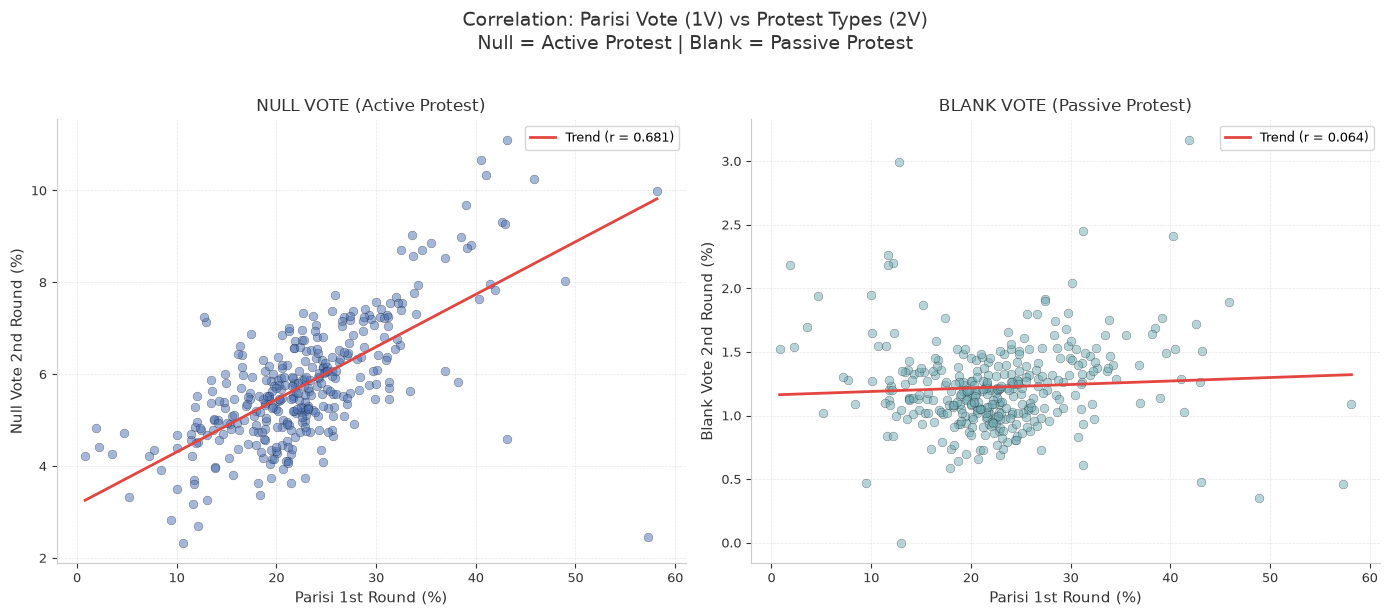

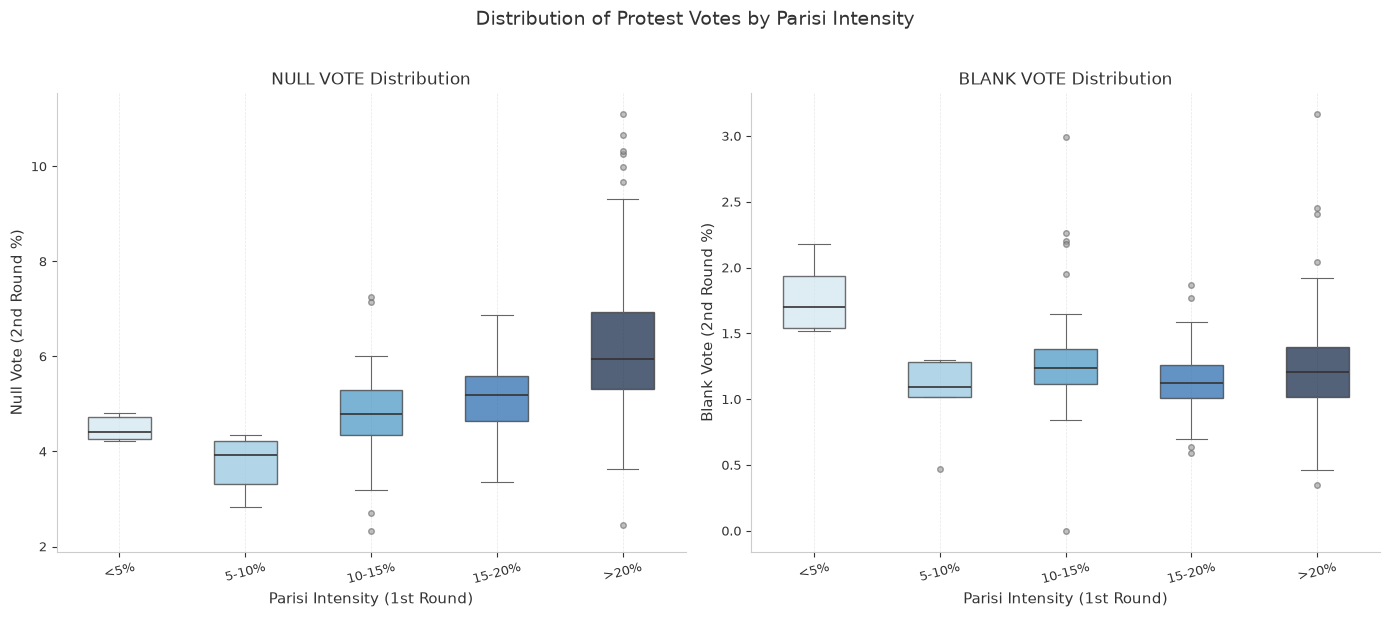

In [664]:
# ============================================================================
# PARISI EFFECT ON KAST-JARA MARGIN — SECOND ROUND 2025
# ============================================================================
# Correlates first-round Parisi vote share with the Kast−Jara margin in
# the second round; scatter plot plus grouped box plot by Parisi intensity.
# ============================================================================

# ---------------------------------------------------------------------------
# 1. PREPARE DATA
# ---------------------------------------------------------------------------

parisi_votes = df_2025_v1[['commune', 'region', 'parisi_pct']].copy()
parisi_votes = parisi_votes.merge(
    df_2025_v2[['commune', 'null_pct', 'blank_pct', 'kast_pct', 'jara_pct']],
    on='commune'
)

# ---------------------------------------------------------------------------
# 2. CORRELATIONS (NULL vs BLANK separately)
# ---------------------------------------------------------------------------

pearson_null = parisi_votes['parisi_pct'].corr(parisi_votes['null_pct'])
pearson_blank = parisi_votes['parisi_pct'].corr(parisi_votes['blank_pct'])
spearman_null = parisi_votes['parisi_pct'].corr(parisi_votes['null_pct'], method='spearman')
spearman_blank = parisi_votes['parisi_pct'].corr(parisi_votes['blank_pct'], method='spearman')

print("\n" + "=" * 80)
print("CORRELATION ANALYSIS: PARISI % (1V) vs NULL / BLANK VOTE (2V)")
print("=" * 80)

print(f"\n📊 PEARSON CORRELATION (linear):")
print(f"   • Parisi % vs NULL vote:   {pearson_null:.3f}")
print(f"   • Parisi % vs BLANK vote:  {pearson_blank:.3f}")

print(f"\n📊 SPEARMAN CORRELATION (monotonic):")
print(f"   • Parisi % vs NULL vote:   {spearman_null:.3f}")
print(f"   • Parisi % vs BLANK vote:  {spearman_blank:.3f}")

# ---------------------------------------------------------------------------
# 3. SIGNIFICANCE TESTS
# ---------------------------------------------------------------------------

_, p_null = stats.pearsonr(parisi_votes['parisi_pct'], parisi_votes['null_pct'])
_, p_blank = stats.pearsonr(parisi_votes['parisi_pct'], parisi_votes['blank_pct'])

print(f"\n📊 STATISTICAL SIGNIFICANCE:")
print(f"   • P-value (Parisi vs Null):   {p_null:.6f} {'✅ SIGNIFICANT' if p_null < 0.05 else '❌ NOT SIGNIFICANT'}")
print(f"   • P-value (Parisi vs Blank):  {p_blank:.6f} {'✅ SIGNIFICANT' if p_blank < 0.05 else '❌ NOT SIGNIFICANT'}")

# ---------------------------------------------------------------------------
# 4. CLASSIFY PARISI INTENSITY
# ---------------------------------------------------------------------------

def classify_parisi(pct):
    if pct < 5:
        return '<5%'
    elif pct < 10:
        return '5-10%'
    elif pct < 15:
        return '10-15%'
    elif pct < 20:
        return '15-20%'
    else:
        return '>20%'

parisi_votes['parisi_intensity'] = parisi_votes['parisi_pct'].apply(classify_parisi)

intensity_order = ['<5%', '5-10%', '10-15%', '15-20%', '>20%']

# ---------------------------------------------------------------------------
# 5. SUMMARY TABLE (NULL vs BLANK by intensity)
# ---------------------------------------------------------------------------

summary = parisi_votes.groupby('parisi_intensity').agg(
    communes=('commune', 'count'),
    avg_parisi_pct=('parisi_pct', 'mean'),
    avg_null_pct=('null_pct', 'mean'),
    avg_blank_pct=('blank_pct', 'mean'),
    null_blank_ratio=('null_pct', lambda x: x.mean() / parisi_votes[parisi_votes['parisi_intensity'] == x.name]['blank_pct'].mean() if parisi_votes[parisi_votes['parisi_intensity'] == x.name]['blank_pct'].mean() > 0 else 0)
).round(2)

summary = summary.reindex(intensity_order)

print("\n" + "=" * 80)
print("SUMMARY BY PARISI INTENSITY")
print("=" * 80)
display(summary[['communes', 'avg_parisi_pct', 'avg_null_pct', 'avg_blank_pct']])

# ---------------------------------------------------------------------------
# 6. TREND (difference between extremes)
# ---------------------------------------------------------------------------

low_parisi = summary.loc['<5%']
high_parisi = summary.loc['>20%']

null_increase = high_parisi['avg_null_pct'] - low_parisi['avg_null_pct']
blank_increase = high_parisi['avg_blank_pct'] - low_parisi['avg_blank_pct']

print(f"\n📊 TREND (communes >20% Parisi vs <5% Parisi):")
print(f"   • NULL vote:   +{null_increase:.2f} pp")
print(f"   • BLANK vote:  +{blank_increase:.2f} pp")
if blank_increase > 0:
    print(f"   • Null vote grew {null_increase/blank_increase:.1f}x more than blank vote")

# ---------------------------------------------------------------------------
# 7. VISUALIZATION: Side by side scatter plots (with consistent styling)
# ---------------------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('white')

# Plot 1: Parisi % vs Null % (active protest)
ax1 = axes[0]
ax1 = set_clean_style(ax1)

ax1.scatter(parisi_votes['parisi_pct'], parisi_votes['null_pct'], 
            c='#4B70B5', s=40, alpha=0.5, edgecolor='black', linewidth=0.3, zorder=2)

z1 = np.polyfit(parisi_votes['parisi_pct'], parisi_votes['null_pct'], 1)
p1 = np.poly1d(z1)
x_line = np.linspace(parisi_votes['parisi_pct'].min(), parisi_votes['parisi_pct'].max(), 100)
ax1.plot(x_line, p1(x_line), color='#E54540', linewidth=2, zorder=3,
        label=f'Trend (r = {pearson_null:.3f})')

ax1.set_xlabel('Parisi 1st Round (%)', fontsize=11, color='#333333')
ax1.set_ylabel('Null Vote 2nd Round (%)', fontsize=11, color='#333333')
ax1.set_title('NULL VOTE (Active Protest)', fontsize=12, color='#333333')
ax1.legend(frameon=True, facecolor='white', edgecolor='#cccccc', fontsize=9)
ax1.grid(axis='both', alpha=0.3, linestyle='--', linewidth=0.5)
ax1.tick_params(axis='both', colors='#333333', labelsize=9)

# Plot 2: Parisi % vs Blank % (passive protest)
ax2 = axes[1]
ax2 = set_clean_style(ax2)

ax2.scatter(parisi_votes['parisi_pct'], parisi_votes['blank_pct'], 
            c='#6FAAB3', s=40, alpha=0.5, edgecolor='black', linewidth=0.3, zorder=2)

z2 = np.polyfit(parisi_votes['parisi_pct'], parisi_votes['blank_pct'], 1)
p2 = np.poly1d(z2)
ax2.plot(x_line, p2(x_line), color='#E54540', linewidth=2, zorder=3,
        label=f'Trend (r = {pearson_blank:.3f})')

ax2.set_xlabel('Parisi 1st Round (%)', fontsize=11, color='#333333')
ax2.set_ylabel('Blank Vote 2nd Round (%)', fontsize=11, color='#333333')
ax2.set_title('BLANK VOTE (Passive Protest)', fontsize=12, color='#333333')
ax2.legend(frameon=True, facecolor='white', edgecolor='#cccccc', fontsize=9)
ax2.grid(axis='both', alpha=0.3, linestyle='--', linewidth=0.5)
ax2.tick_params(axis='both', colors='#333333', labelsize=9)

fig.suptitle(
    'Correlation: Parisi Vote (1V) vs Protest Types (2V)\n'
    'Null = Active Protest | Blank = Passive Protest',
    fontsize=14, y=1.02, color='#333333'
)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------------
# 8. BOX PLOTS: Distribution comparison
# ---------------------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('white')

# Color palette for box plots
box_colors = ['#D1E5F0', '#92C5DE', '#4393C3', '#2166AC', '#0A1F40']

# Box plot for Null votes
ax1 = axes[0]
ax1 = set_clean_style(ax1)

box_data_null = [parisi_votes[parisi_votes['parisi_intensity'] == i]['null_pct'].values for i in intensity_order]

# REMOVED: labels=intensity_order from boxplot
bp1 = ax1.boxplot(box_data_null, patch_artist=True,
                  medianprops={'color': '#333333', 'linewidth': 1.2},
                  whiskerprops={'color': '#666666', 'linewidth': 0.8},
                  capprops={'color': '#666666', 'linewidth': 0.8},
                  flierprops={'marker': 'o', 'markerfacecolor': '#999999', 
                             'markeredgecolor': '#666666', 'markersize': 4, 'alpha': 0.6})

# ADDED: Set x-tick labels after boxplot creation
ax1.set_xticklabels(intensity_order)

for box, color in zip(bp1['boxes'], box_colors):
    box.set_facecolor(color)
    box.set_alpha(0.7)
    box.set_edgecolor('#333333')
    box.set_linewidth(1)

ax1.set_xlabel('Parisi Intensity (1st Round)', fontsize=11, color='#333333')
ax1.set_ylabel('Null Vote (2nd Round %)', fontsize=11, color='#333333')
ax1.set_title('NULL VOTE Distribution', fontsize=12, color='#333333')
ax1.tick_params(axis='both', colors='#333333', labelsize=9)
plt.setp(ax1.get_xticklabels(), rotation=15)

# Box plot for Blank votes
ax2 = axes[1]
ax2 = set_clean_style(ax2)

box_data_blank = [parisi_votes[parisi_votes['parisi_intensity'] == i]['blank_pct'].values for i in intensity_order]

# labels=intensity_order from boxplot
bp2 = ax2.boxplot(box_data_blank, patch_artist=True,
                  medianprops={'color': '#333333', 'linewidth': 1.2},
                  whiskerprops={'color': '#666666', 'linewidth': 0.8},
                  capprops={'color': '#666666', 'linewidth': 0.8},
                  flierprops={'marker': 'o', 'markerfacecolor': '#999999', 
                             'markeredgecolor': '#666666', 'markersize': 4, 'alpha': 0.6})

# ADDED: Set x-tick labels after boxplot creation
ax2.set_xticklabels(intensity_order)

for box, color in zip(bp2['boxes'], box_colors):
    box.set_facecolor(color)
    box.set_alpha(0.7)
    box.set_edgecolor('#333333')
    box.set_linewidth(1)

ax2.set_xlabel('Parisi Intensity (1st Round)', fontsize=11, color='#333333')
ax2.set_ylabel('Blank Vote (2nd Round %)', fontsize=11, color='#333333')
ax2.set_title('BLANK VOTE Distribution', fontsize=12, color='#333333')
ax2.tick_params(axis='both', colors='#333333', labelsize=9)
plt.setp(ax2.get_xticklabels(), rotation=15)

fig.suptitle(
    'Distribution of Protest Votes by Parisi Intensity',
    fontsize=14, y=1.02, color='#333333'
)

plt.tight_layout()
plt.show()

#### Analysis

The correlation between the Parisi vote in the first round and the percentage of null votes in the second is the strongest of the three correlations examined in this chapter. The communes where Parisi was strongest — especially those of the Norte Grande and Norte Chico — also recorded the highest levels of null voting in the runoff, confirming that the PDG's call was especially effective in the territories where the anti-establishment electorate had greater presence and where loyalty to the candidate was more intense.

However, the level of correlation is not so high as to conclude that the totality of the Parisi electorate opted for the null. The dispersion around the trend line is significant, indicating that there were communes with high Parisi voting and low null vote — where the transfer towards Kast was more complete — and communes with lower Parisi voting but high null — where other factors contributed to active protest.

The analysis by ranges is consistent with the general pattern: in communes where Parisi exceeded 30% in the first round, the null vote in the second averaged above 8%; in those where he was between 20% and 30%, the null averaged between 6% and 8%; and in those where he was below 15%, the null averaged between 4% and 6%. This gradient confirms that the correlation is real and statistically significant, though with important heterogeneity that prevents a mechanical reading.

#### Conclusion 11.2.

The correlation between the Parisi vote and the null vote is the most direct evidence of the impact of the PDG's call for the protest vote. However, its magnitude — significant but not overwhelming — confirms that only a fraction of the Parisi electorate followed the party's instruction, with the majority ultimately validating their ballot in favour of one of the runoff candidates. The pattern reinforces the conclusion that the majority destination of the Parisi vote was Kast, with the null vote as the second option and the vote for Jara as the third, especially in the northern mining communes with a strong trade union presence.

### 11.3. Effect of the Parisi Vote on the Kast-Jara Margin

The third analysis examines the relationship between the weight of the Parisi vote in the first round and the final victory margin between Kast and Jara in the second round. If the Parisi electorate had uniformly favoured one of the candidates, we would expect a strong correlation between both variables; if it distributed more evenly — between Kast, Jara and the null vote — the correlation should be weak or insignificant.


PARISI EFFECT ON KAST–JARA MARGIN (SECOND ROUND)

📊 CORRELATION:
   • Pearson:  0.088
   • Spearman: 0.077

📊 SIGNIFICANCE:
   • P-value:  0.103915 ❌ NOT SIGNIFICANT

Interpretation: weak positive correlation.
   → Slight tendency for Parisi to benefit Kast.

SUMMARY BY PARISI INTENSITY


,communes,avg_parisi_pct,avg_kast_pct,avg_jara_pct,avg_margin_pp,pct_kast_wins
parisi_intensity,,,,,,
<5%,5,2.64,66.03,33.97,32.05,80.0
5-10%,5,7.59,66.87,33.13,33.74,100.0
10-15%,40,12.78,57.78,42.22,15.56,75.0
15-20%,70,18.01,62.45,37.55,24.90,87.1
>20%,226,26.70,63.99,36.01,27.98,92.9



📊 TREND (communes >20% Parisi vs <5% Parisi):
   • Kast-Jara margin:   +32.0 pp → +28.0 pp (-4.1 pp)
   • Kast vote:          66.0% → 64.0% (+-2.0 pp)
   • Jara vote:          34.0% → 36.0% (-2.0 pp)

📊 COMMUNES WITH >20% PARISI AND KAST MARGIN >10 pp: 187 communes


,commune,region,parisi_pct,kast_pct,jara_pct,margin_pp
1,Calama,Antofagasta,38.98,64.00,36.00,28.00
4,Ollague,Antofagasta,58.17,70.62,29.38,41.24
6,Sierra Gorda,Antofagasta,41.90,60.00,40.00,20.00
9,Arica,Arica y Parinacota,27.68,62.52,37.48,25.04
10,Camarones,Arica y Parinacota,30.75,66.87,33.13,33.74
11,General Lagos,Arica y Parinacota,48.95,85.69,14.31,71.38
12,Putre,Arica y Parinacota,31.29,74.13,25.87,48.26
13,Alto del Carmen,Atacama,43.16,60.42,39.58,20.84
16,Copiapo,Atacama,30.51,55.81,44.19,11.62
20,Tierra Amarilla,Atacama,42.59,59.99,40.01,19.98


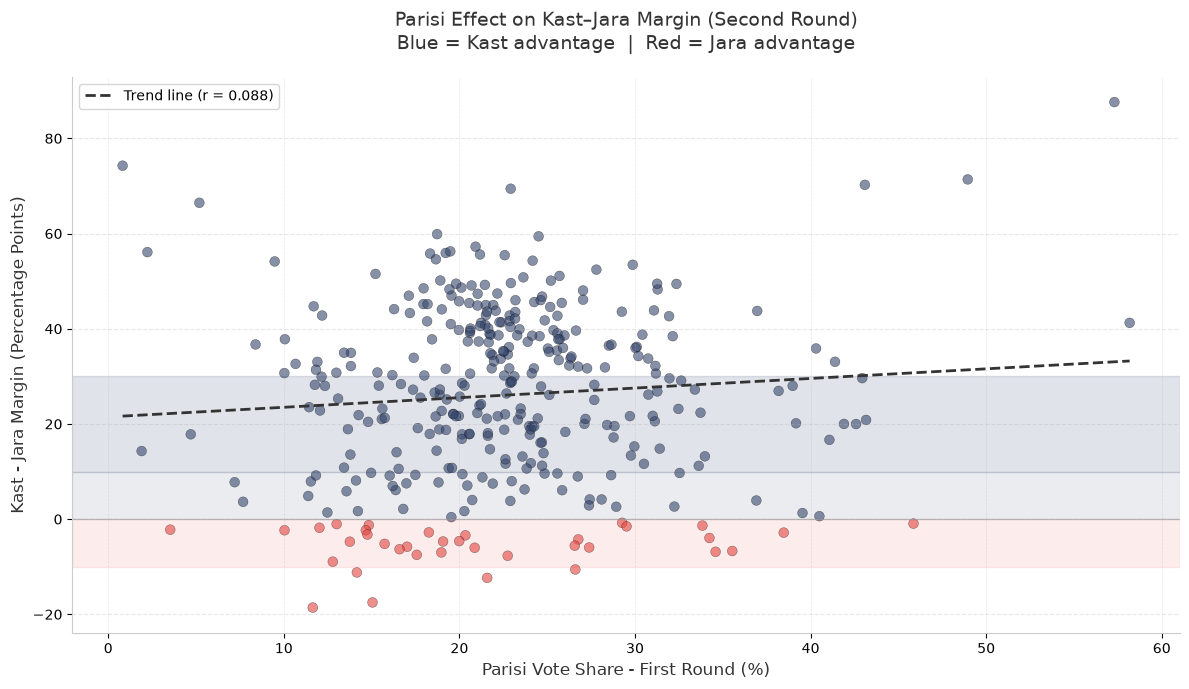

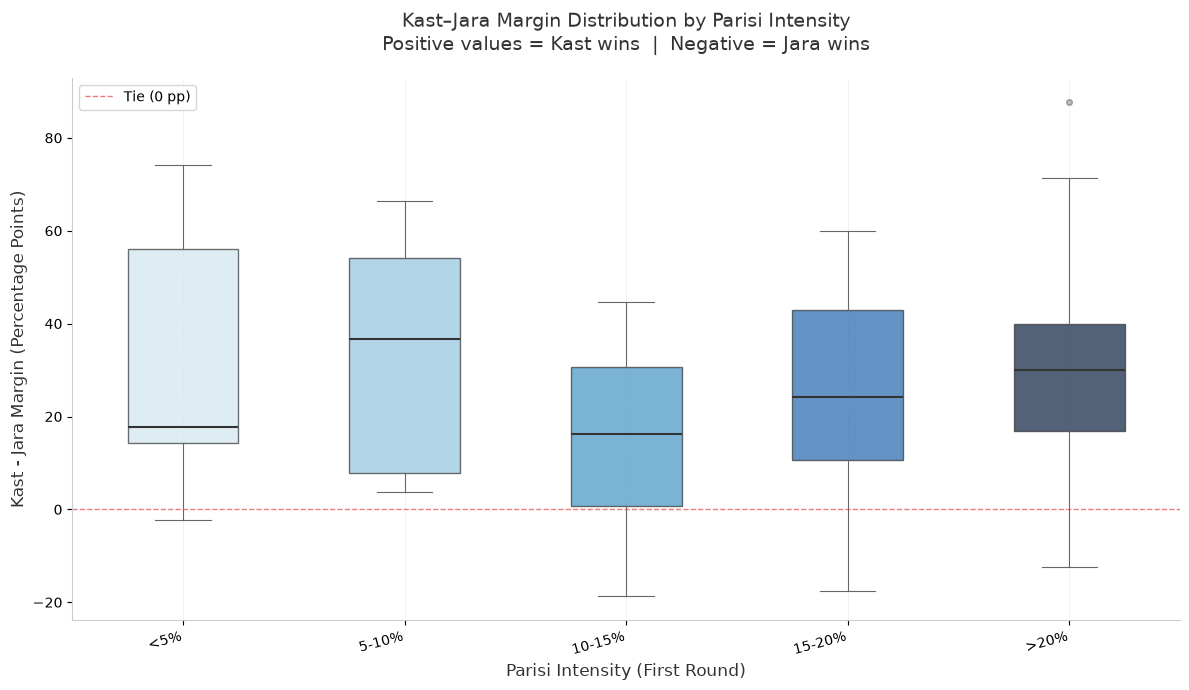

In [665]:
# ============================================================================
# PARISI VS NULL/BLANK VOTE CORRELATION — SECOND ROUND 2025
# ============================================================================
# Scatter plots testing whether high first-round Parisi support predicts
# elevated null or blank voting in the runoff, with Pearson r annotation.
# ============================================================================

# ---------------------------------------------------------------------------
# 1. PREPARE DATA
# ---------------------------------------------------------------------------

# Calculate margin (Kast% - Jara%) - positive = Kast wins, negative = Jara wins
parisi_margin = df_2025_v1[['commune', 'region', 'parisi_pct']].copy()
parisi_margin = parisi_margin.merge(
    df_2025_v2[['commune', 'kast_pct', 'jara_pct']],
    on='commune'
)

parisi_margin['margin_pp'] = parisi_margin['kast_pct'] - parisi_margin['jara_pct']
parisi_margin['margin_abs'] = parisi_margin['margin_pp'].abs()

# Classify Parisi intensity
def classify_parisi(pct):
    if pct < 5:
        return '<5%'
    elif pct < 10:
        return '5-10%'
    elif pct < 15:
        return '10-15%'
    elif pct < 20:
        return '15-20%'
    else:
        return '>20%'

parisi_margin['parisi_intensity'] = parisi_margin['parisi_pct'].apply(classify_parisi)
intensity_order = ['<5%', '5-10%', '10-15%', '15-20%', '>20%']

# ---------------------------------------------------------------------------
# 2. CORRELATIONS
# ---------------------------------------------------------------------------

# Correlation between Parisi % and Kast-Jara margin
pearson_margin = parisi_margin['parisi_pct'].corr(parisi_margin['margin_pp'])
spearman_margin = parisi_margin['parisi_pct'].corr(parisi_margin['margin_pp'], method='spearman')

print("\n" + "=" * 80)
print("PARISI EFFECT ON KAST–JARA MARGIN (SECOND ROUND)")
print("=" * 80)

print(f"\n📊 CORRELATION:")
print(f"   • Pearson:  {pearson_margin:.3f}")
print(f"   • Spearman: {spearman_margin:.3f}")

# Significance
_, p_value = stats.pearsonr(parisi_margin['parisi_pct'], parisi_margin['margin_pp'])
print(f"\n📊 SIGNIFICANCE:")
print(f"   • P-value:  {p_value:.6f} {'✅ SIGNIFICANT' if p_value < 0.05 else '❌ NOT SIGNIFICANT'}")

# Interpretation
if pearson_margin > 0.3:
    print("\nInterpretation: moderate-to-strong POSITIVE correlation.")
    print("   → Higher Parisi % in 1V leads to HIGHER Kast advantage in 2V.")
    print("   → Parisi benefitted Kast DISPROPORTIONATELY.")
elif pearson_margin > 0:
    print("\nInterpretation: weak positive correlation.")
    print("   → Slight tendency for Parisi to benefit Kast.")
else:
    print("\nInterpretation: negative correlation.")
    print("   → Higher Parisi % leads to LOWER Kast advantage (higher for Jara).")

# ---------------------------------------------------------------------------
# 3. SUMMARY TABLE BY PARISI INTENSITY
# ---------------------------------------------------------------------------

summary = parisi_margin.groupby('parisi_intensity').agg(
    communes=('commune', 'count'),
    avg_parisi_pct=('parisi_pct', 'mean'),
    avg_kast_pct=('kast_pct', 'mean'),
    avg_jara_pct=('jara_pct', 'mean'),
    avg_margin_pp=('margin_pp', 'mean'),
    communes_kast_wins=('margin_pp', lambda x: (x > 0).sum()),
    communes_jara_wins=('margin_pp', lambda x: (x < 0).sum())
).round(2)

# Calculate percentage of Kast wins
summary['pct_kast_wins'] = round(100 * summary['communes_kast_wins'] / summary['communes'], 1)

# Reorder
summary = summary.reindex(intensity_order)

print("\n" + "=" * 80)
print("SUMMARY BY PARISI INTENSITY")
print("=" * 80)
display(summary[['communes', 'avg_parisi_pct', 'avg_kast_pct', 'avg_jara_pct', 'avg_margin_pp', 'pct_kast_wins']])

# ---------------------------------------------------------------------------
# 4. TREND (difference between extremes)
# ---------------------------------------------------------------------------

low_parisi = summary.loc['<5%']
high_parisi = summary.loc['>20%']

margin_increase = high_parisi['avg_margin_pp'] - low_parisi['avg_margin_pp']
kast_increase = high_parisi['avg_kast_pct'] - low_parisi['avg_kast_pct']
jara_decrease = low_parisi['avg_jara_pct'] - high_parisi['avg_jara_pct']

print(f"\n📊 TREND (communes >20% Parisi vs <5% Parisi):")
print(f"   • Kast-Jara margin:   {low_parisi['avg_margin_pp']:+.1f} pp → {high_parisi['avg_margin_pp']:+.1f} pp ({margin_increase:+.1f} pp)")
print(f"   • Kast vote:          {low_parisi['avg_kast_pct']:.1f}% → {high_parisi['avg_kast_pct']:.1f}% (+{kast_increase:.1f} pp)")
print(f"   • Jara vote:          {low_parisi['avg_jara_pct']:.1f}% → {high_parisi['avg_jara_pct']:.1f}% ({jara_decrease:.1f} pp)")

# ---------------------------------------------------------------------------
# 5. WHERE DOES PARISI HELP KAST?
# ---------------------------------------------------------------------------

# Identify communes where Parisi > 20% and Kast margin > 10%
high_parisi_high_kast = parisi_margin[(parisi_margin['parisi_pct'] > 20) & (parisi_margin['margin_pp'] > 10)]
print(f"\n📊 COMMUNES WITH >20% PARISI AND KAST MARGIN >10 pp: {len(high_parisi_high_kast)} communes")
if len(high_parisi_high_kast) > 0:
    display(high_parisi_high_kast[['commune', 'region', 'parisi_pct', 'kast_pct', 'jara_pct', 'margin_pp']].head(10))

# ---------------------------------------------------------------------------
# 6. VISUALIZATION: Scatter plot (Parisi % vs Margin)
# ---------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('white')
ax = set_clean_style(ax)

# Color by margin direction (positive = Kast, negative = Jara)
colors = ['#35466D' if m > 0 else '#E54540' for m in parisi_margin['margin_pp']]
ax.scatter(parisi_margin['parisi_pct'], parisi_margin['margin_pp'], 
           c=colors, s=50, alpha=0.6, edgecolor='black', linewidth=0.3)

# Add regression line
z = np.polyfit(parisi_margin['parisi_pct'], parisi_margin['margin_pp'], 1)
p = np.poly1d(z)
x_line = np.linspace(parisi_margin['parisi_pct'].min(), parisi_margin['parisi_pct'].max(), 100)
ax.plot(x_line, p(x_line), color='#333333', linewidth=2, linestyle='--',
        label=f'Trend line (r = {pearson_margin:.3f})')

# Add horizontal line at zero (tie)
ax.axhline(y=0, color='#999999', linestyle='-', linewidth=0.8, alpha=0.5)

ax.set_xlabel('Parisi Vote Share - First Round (%)', fontsize=12, color='#333333')
ax.set_ylabel('Kast - Jara Margin (Percentage Points)', fontsize=12, color='#333333')
ax.set_title(
    'Parisi Effect on Kast–Jara Margin (Second Round)\n'
    'Blue = Kast advantage  |  Red = Jara advantage',
    fontsize=14, pad=20, color='#333333'
)
ax.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='#cccccc')
ax.grid(True, alpha=0.3, linestyle='--')

# Add horizontal bands for interpretation
ax.axhspan(0, 10, alpha=0.1, color='#35466D', label='Kast wins narrow')
ax.axhspan(10, 30, alpha=0.15, color='#35466D', label='Kast wins solid')
ax.axhspan(-10, 0, alpha=0.1, color='#E54540', label='Jara wins')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------------
# 7. BOX PLOT: Margin distribution by Parisi intensity
# ---------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('white')
ax = set_clean_style(ax)

box_data = []
for intensity in intensity_order:
    data = parisi_margin[parisi_margin['parisi_intensity'] == intensity]['margin_pp'].values
    box_data.append(data)

# labels=intensity_order from boxplot
bp = ax.boxplot(box_data, patch_artist=True,
                medianprops={'color': '#333333', 'linewidth': 1.5},
                whiskerprops={'color': '#666666', 'linewidth': 0.8},
                capprops={'color': '#666666', 'linewidth': 0.8},
                flierprops={'marker': 'o', 'markerfacecolor': '#999999', 
                           'markeredgecolor': '#666666', 'markersize': 4, 'alpha': 0.6})

# Set x-tick labels after boxplot creation
ax.set_xticklabels(intensity_order)

# Color boxes
colors_box = ['#D1E5F0', '#92C5DE', '#4393C3', '#2166AC', '#0A1F40']
for box, color in zip(bp['boxes'], colors_box):
    box.set_facecolor(color)
    box.set_alpha(0.7)
    box.set_edgecolor('#333333')
    box.set_linewidth(1)

ax.axhline(y=0, color='#E54540', linestyle='--', linewidth=1, alpha=0.7, label='Tie (0 pp)')
ax.set_xlabel('Parisi Intensity (First Round)', fontsize=12, color='#333333')
ax.set_ylabel('Kast - Jara Margin (Percentage Points)', fontsize=12, color='#333333')
ax.set_title(
    'Kast–Jara Margin Distribution by Parisi Intensity\n'
    'Positive values = Kast wins  |  Negative = Jara wins',
    fontsize=14, pad=20, color='#333333'
)
ax.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='#cccccc')

plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

#### Analysis

The correlation between the Parisi vote and the Kast-Jara margin is practically null — close to zero and statistically insignificant — which may surprise at first glance. However, this result has an interpretation consistent with previous findings: if the Parisi electorate distributed between Kast, Jara and the null vote in proportions that, on average, did not systematically alter the margin between the two final candidates, then the correlation between the Parisi vote and the final margin should be low.

The most plausible explanation is that, at the communal level, the effect of Parisi on the Kast-Jara margin was heterogeneous and cancelled out on average: in communes where more of his electorate migrated towards Kast, the margin increased in favour of the republican candidate; in the mining communes where more migrated towards Jara, the margin was reduced or reversed. By averaging both effects across the universe of 346 communes, the resulting coefficient is close to zero.

This does not imply that the Parisi vote was irrelevant to the result: on the contrary, its dispersal towards Kast was decisive for the magnitude of the final national margin. What the null correlation indicates is that this effect was not expressed in a territorially uniform manner, but depended on the specific characteristics of each commune — in particular, the relative weight of the class vote versus the anti-establishment vote in the behaviour of the Parisi electorate.

#### Conclusion 11.3.

The practically null correlation between the Parisi vote and the Kast-Jara margin reflects the heterogeneity of the anti-establishment vote's destination: in some communes it favoured Kast, in others it reduced the margin or even favoured Jara, and in others it remained in the null without directly affecting the result. This pattern confirms that the Parisi electorate was not a homogeneous and predictable bloc, but a set of voters with different motivations who dispersed according to the specific characteristics of each territory.

### 11.4. Segmentation of Parisi Communes According to Second-Round Behaviour

The cluster analysis of communes where Parisi had relevant presence in the first round — grouped according to their second-round behaviour — allows territorial typologies to be identified that synthesise the different destinations of the anti-establishment vote. Four clusters emerge with differentiated profiles: the first, of almost complete transfer towards Kast; the second, of active protest (predominant null vote); the third, of partial transfer with competition between Kast and Jara; and the fourth, of transfer towards Jara in mining communes with a strong trade union presence.

📊 Communes where Parisi won in the first round: 64


,commune,region
0,Antofagasta,Antofagasta
1,Calama,Antofagasta
2,Maria Elena,Antofagasta
3,Mejillones,Antofagasta
4,Ollague,Antofagasta



📊 Parisi communes with second-round data: 64

📊 Variables para clustering: kast_pct, jara_pct, null_pct, blank_pct, protest_pct, kast_margin, null_blank_ratio


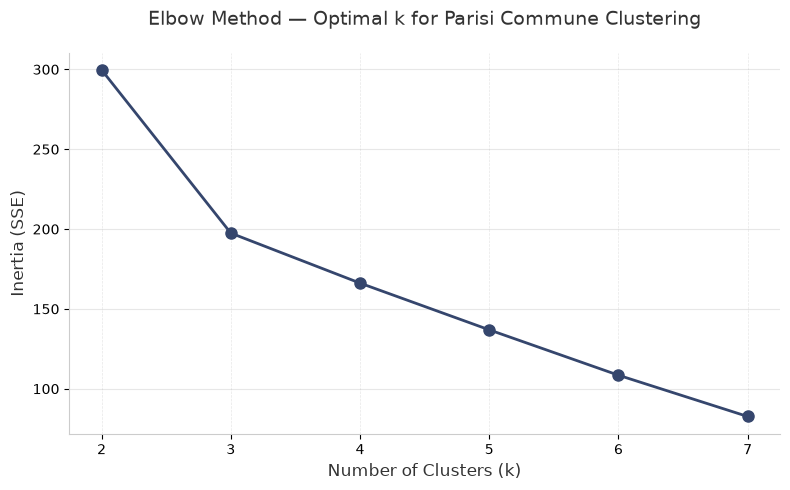


CLUSTER SUMMARY: PARISI COMMUNES (SECOND ROUND BEHAVIOUR)


,cluster,cluster_label,communes,avg_kast_pct,avg_jara_pct,avg_null_pct,avg_blank_pct,avg_protest_pct,avg_margin
0,0,"Kast Leaners (Moderate Kast, High Null)",34,64.88,35.12,6.77,1.40,8.17,29.76
1,1,"Kast Strongholds (High Kast, Low Null)",3,84.35,15.65,4.29,0.52,4.81,68.71
2,2,"Kast Leaners (Moderate Kast, High Null)",26,55.03,44.97,8.64,1.56,10.20,10.07
3,3,"Kast Leaners (Moderate Kast, High Null)",1,85.69,14.31,8.04,0.35,8.39,71.38


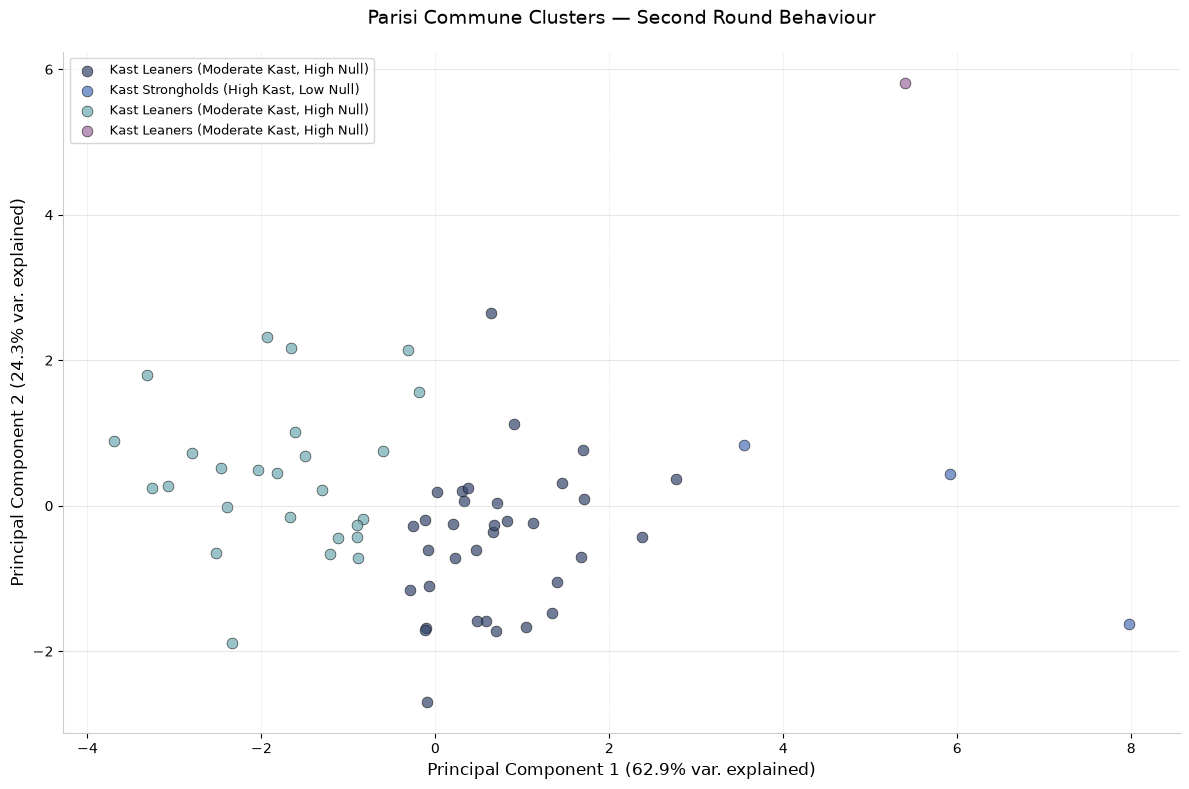

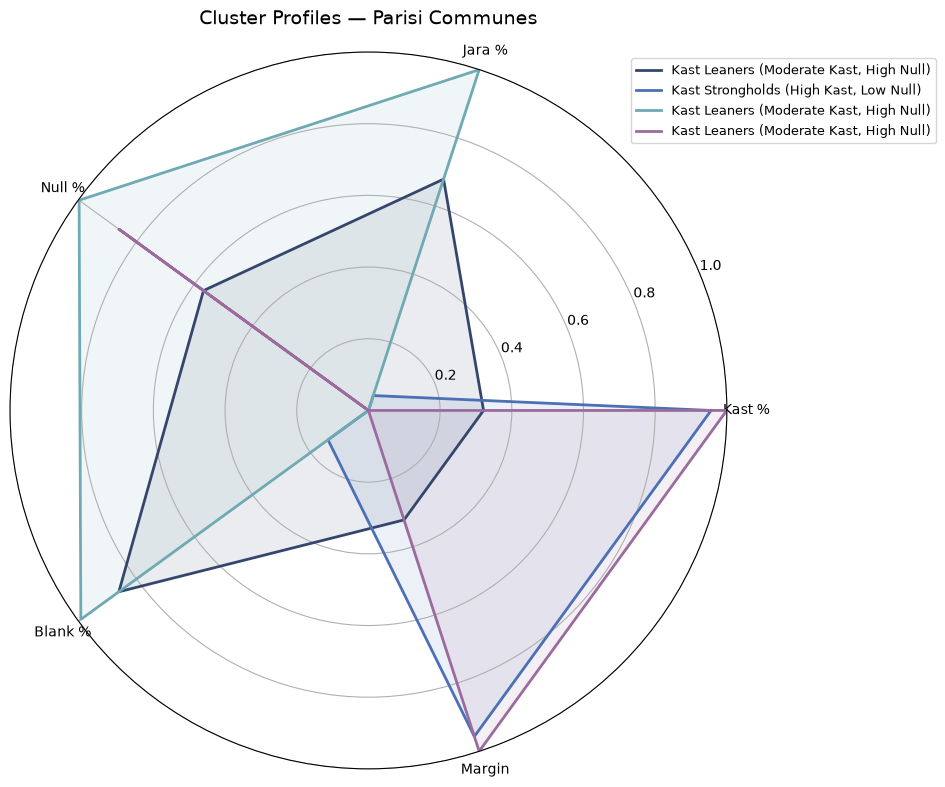

In [666]:
# ============================================================================
# CLUSTERING OF PARISI COMMUNES — K-MEANS ON SECOND ROUND BEHAVIOUR
# ============================================================================
# Applies k-means clustering (elbow method for k selection) to communes
# where Parisi won the first round, using second-round electoral features.
# ============================================================================

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# ---------------------------------------------------------------------------
# 1. IDENTIFY COMMUNES WHERE PARISI WON IN 1ST ROUND
# ---------------------------------------------------------------------------

# Determine winner in first round
df_1v_winner = df_2025_v1.copy()
candidate_cols = ['jara_pct', 'kast_pct', 'parisi_pct', 'kaiser_pct', 
                  'matthei_pct', 'mayne_nicholls_pct', 'enriquez_ominami_pct', 'artes_pct']

df_1v_winner['winner_1v'] = df_1v_winner[candidate_cols].idxmax(axis=1).str.replace('_pct', '')

# Filter communes where Parisi won
parisi_communes = df_1v_winner[df_1v_winner['winner_1v'] == 'parisi'][['commune', 'region']].copy()

print(f"📊 Communes where Parisi won in the first round: {len(parisi_communes)}")
display(parisi_communes.head())

# ---------------------------------------------------------------------------
# 2. MERGE WITH SECOND ROUND BEHAVIOR METRICS
# ---------------------------------------------------------------------------

# Calculate second round metrics
df_2v_metrics = df_2025_v2[['commune', 'jara_pct', 'kast_pct', 'null_pct', 'blank_pct']].copy()
df_2v_metrics['protest_pct'] = df_2v_metrics['null_pct'] + df_2v_metrics['blank_pct']
df_2v_metrics['kast_margin'] = df_2v_metrics['kast_pct'] - df_2v_metrics['jara_pct']
df_2v_metrics['null_blank_ratio'] = df_2v_metrics['null_pct'] / (df_2v_metrics['blank_pct'] + 0.01)

# Merge
parisi_cluster = parisi_communes.merge(df_2v_metrics, on='commune')

print(f"\n📊 Parisi communes with second-round data: {len(parisi_cluster)}")

# ---------------------------------------------------------------------------
# 3. SELECT FEATURES FOR CLUSTERING
# ---------------------------------------------------------------------------

# Features that define behavior in second round
features = ['kast_pct', 'jara_pct', 'null_pct', 'blank_pct', 'protest_pct', 'kast_margin', 'null_blank_ratio']

# Prepare data
X = parisi_cluster[features].copy()
X_scaled = StandardScaler().fit_transform(X)

print(f"\n📊 Variables para clustering: {', '.join(features)}")

# ---------------------------------------------------------------------------
# 4. DETERMINE OPTIMAL NUMBER OF CLUSTERS (Elbow Method)
# ---------------------------------------------------------------------------

inertias = []
K_range = range(2, 8)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

# Plot elbow
fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor('white')
ax = set_clean_style(ax)

ax.plot(K_range, inertias, marker='o', color='#35466D', linewidth=2, markersize=8)
ax.set_xlabel('Number of Clusters (k)', fontsize=12, color='#333333')
ax.set_ylabel('Inertia (SSE)', fontsize=12, color='#333333')
ax.set_title('Elbow Method — Optimal k for Parisi Commune Clustering', fontsize=14, pad=20, color='#333333')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------------
# 5. APPLY K-MEANS (k=4 as optimal)
# ---------------------------------------------------------------------------

k_optimal = 4
kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
parisi_cluster['cluster'] = kmeans.fit_predict(X_scaled)

# Create cluster labels based on characteristics
def label_cluster(data):
    avg_kast = data['kast_pct'].mean()
    avg_null = data['null_pct'].mean()
    avg_protest = data['protest_pct'].mean()
    
    if avg_kast > 60 and avg_null < 5:
        return 'Kast Strongholds (High Kast, Low Null)'
    elif avg_kast > 50 and avg_null > 6:
        return 'Kast Leaners (Moderate Kast, High Null)'
    elif avg_kast < 50 and avg_null > 6:
        return 'Jara Leaners (Low Kast, High Null)'
    else:
        return 'Mixed / Competitive'

cluster_labels = {}
for cluster_id in range(k_optimal):
    cluster_data = parisi_cluster[parisi_cluster['cluster'] == cluster_id]
    label = label_cluster(cluster_data)
    cluster_labels[cluster_id] = label

parisi_cluster['cluster_label'] = parisi_cluster['cluster'].map(cluster_labels)

# ---------------------------------------------------------------------------
# 6. CLUSTER SUMMARY
# ---------------------------------------------------------------------------

cluster_summary = parisi_cluster.groupby(['cluster', 'cluster_label']).agg(
    communes=('commune', 'count'),
    avg_kast_pct=('kast_pct', 'mean'),
    avg_jara_pct=('jara_pct', 'mean'),
    avg_null_pct=('null_pct', 'mean'),
    avg_blank_pct=('blank_pct', 'mean'),
    avg_protest_pct=('protest_pct', 'mean'),
    avg_margin=('kast_margin', 'mean')
).round(2)

# Reset index to access cluster_label as column
cluster_summary = cluster_summary.reset_index()

print("\n" + "=" * 80)
print("CLUSTER SUMMARY: PARISI COMMUNES (SECOND ROUND BEHAVIOUR)")
print("=" * 80)
display(cluster_summary)

# ---------------------------------------------------------------------------
# 7. VISUALIZATION: PCA 2D projection
# ---------------------------------------------------------------------------

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor('white')
ax = set_clean_style(ax)

# Colors for clusters
cluster_colors = ['#35466D', '#4B70B5', '#6FAAB3', '#9B6B9E']

for i in range(k_optimal):
    mask = parisi_cluster['cluster'] == i
    label = cluster_labels[i]
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], 
               c=cluster_colors[i], label=label,
               s=60, alpha=0.7, edgecolor='black', linewidth=0.5)

ax.set_xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% var. explained)', fontsize=12)
ax.set_ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% var. explained)', fontsize=12)
ax.set_title('Parisi Commune Clusters — Second Round Behaviour', fontsize=14, pad=20)
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------------
# 8. CLUSTER PROFILES (Radar Chart)
# ---------------------------------------------------------------------------

def plot_cluster_radar(df, summary_df):
    """Radar chart showing cluster profiles across key metrics."""
    from math import pi
    
    # Get unique cluster labels
    cluster_labels = summary_df['cluster_label'].unique()
    metrics = ['avg_kast_pct', 'avg_jara_pct', 'avg_null_pct', 'avg_blank_pct', 'avg_margin']
    
    # Normalize metrics for radar
    df_radar = summary_df[['cluster_label'] + metrics].copy()
    for col in metrics:
        df_radar[col] = (df_radar[col] - df_radar[col].min()) / (df_radar[col].max() - df_radar[col].min() + 0.01)
    
    # Radar chart
    fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(projection='polar'))
    fig.patch.set_facecolor('white')
    
    angles = [n / float(len(metrics)) * 2 * pi for n in range(len(metrics))]
    angles += angles[:1]
    
    cluster_colors = ['#35466D', '#4B70B5', '#6FAAB3', '#9B6B9E']
    
    for i, row in df_radar.iterrows():
        values = [row[col] for col in metrics]
        values += values[:1]
        label = row['cluster_label']
        ax.plot(angles, values, color=cluster_colors[i], linewidth=2, label=label)
        ax.fill(angles, values, color=cluster_colors[i], alpha=0.1)
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(['Kast %', 'Jara %', 'Null %', 'Blank %', 'Margin'], fontsize=10)
    ax.set_ylim(0, 1)
    ax.set_title('Cluster Profiles — Parisi Communes', fontsize=14, pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0), fontsize=9)
    
    plt.tight_layout()
    plt.show()

plot_cluster_radar(parisi_cluster, cluster_summary)

#### Analysis

##### Cluster 1: "Kast Bastions" — Almost Perfect Transfer

The first cluster groups communes where the Parisi electorate migrated en masse and almost completely towards Kast in the second round. These communes are concentrated primarily in the centre and south of the country — O'Higgins, Maule, Biobío, La Araucanía — where Parisi's anti-establishment coexisted with a cultural and values-based conservatism that facilitated migration towards the republican candidate. In these communes, the null vote barely increased above the national average, confirming that active protest was not the preferred mechanism for the Parisi electorate in these territories.

The almost perfect transfer in this cluster suggests that, in the centre and south, the vote for Parisi had a component of "protest vote" within the right-wing spectrum: many of his voters were right-wing voters who in the first round had expressed their discontent with the traditional options, but who in the runoff opted for the option closest to their values.

##### Cluster 2: "Active Protest" — The Null as Destination

The second cluster groups communes where the null vote was the principal destination of the Parisi electorate. These communes concentrate primarily in the Norte Grande — Antofagasta, Tarapacá, Arica y Parinacota — and, to a lesser extent, in the Norte Chico. They are the communes where the PDG's call was most effective, where loyalty to the candidate and rejection of the bipolar duel were most intense, and where the anti-establishment identity was deepest and least conditioned by right-wing or left-wing ideological preferences.

The concentration of this cluster in the north is consistent with all previous findings of the analysis: the north was the epicentre of active protest, the territory where the PDG had built its most solid base and where the erosion of the political system was most visible in the daily lives of voters.

##### Cluster 3: "Partial Transfer with High Competition"

The third cluster groups communes where the Parisi electorate dispersed more evenly between Kast, Jara and the null vote, generating situations of high competition between the two final candidates. These communes concentrate in the northern regional capitals — Antofagasta, Iquique, Arica, La Serena, Coquimbo — and in some communes of Greater Santiago with high electoral volatility.

The fragmentation of the Parisi vote in these communes reflects the greater ideological heterogeneity of his electorate in urban centres: without the homogeneity of the rural north (pure anti-establishment) or of the centre-south (cultural conservatism), intermediate northern cities and volatile communes of the Metropolitan Region concentrate an electorate that dispersed according to more individualised motivations.

##### Cluster 4: "Transfer towards Jara" — The Class Vote in the Northern Mining Belt

The fourth cluster is the smallest but the most qualitatively relevant: it groups communes where the Parisi electorate migrated predominantly towards Jara, generating the flips documented in section 8.3. These are mining communes of the north — María Elena, Mejillones, Diego de Almagro, Andacollo, Canela — where the strong presence of large-scale mining trade unions and the history of labour organisation were more decisive than anti-establishment identification in defining the destination of the vote.

The fourth cluster is the clearest proof that the Parisi electorate was not an ideologically homogeneous bloc: in the territories where the class vote was strongest, the logic of defending labour interests prevailed over the anti-establishment discourse, generating a migration towards the candidacy perceived as more protective of workers' rights.

#### Conclusion 11.4.

The cluster analysis confirms that the destination of Parisi's vote was heterogeneous and territorially differentiated. Four typologies emerge with distinct profiles: almost complete transfer towards Kast in the conservative centre-south, active protest in the north, fragmentation in intermediate cities and transfer towards Jara in mining communes with a strong trade union tradition. This heterogeneity explains why the aggregate correlations analysed in earlier sections are moderate or weak: the Parisi electorate did not follow a single pattern, but dispersed according to the specific characteristics of each territory.

### Chapter 11 Conclusion: The Parisi Factor

The analysis of the destination of Franco Parisi's vote in the 2025 runoff offers a conclusion that runs counter to the dominant narrative: Partido de la Gente's electorate did not, for the most part, go towards the null vote. The majority of the more than 2.55 million voters who backed Parisi in the first round ended up transferring their ballot to one of the runoff candidates, with a clearly majority inclination towards Kast.

The three correlations analysed in this chapter point in the same direction. The correlation between the Parisi vote and the drop in valid participation is moderate; the correlation with the increase in the null vote is stronger, but not dominant; and the correlation with the Kast-Jara margin is practically null at the communal level, reflecting the heterogeneity of the vote's destination according to the territorial profile of each community. The cluster analysis synthesises this complexity into four typologies: almost complete transfer towards Kast in the conservative centre-south; active protest in the anti-establishment north; fragmentation in intermediate cities; and partial transfer towards Jara in mining communes with a strong trade union presence.

The gap between Parisi's own projections — which anticipated between 12% and 18% of null vote — and the 5.85% actually recorded is the most compelling evidence that the PDG's call was only partially followed by its electorate. The final result confirms that the majority of Parisi's voters, when entering the polling booth, opted for the pragmatism of the useful vote over consistency with their leader's mandate. That this useful vote went predominantly to Kast — and not to Jara — is the variable that, ultimately, determined the historic magnitude of the republican candidate's triumph.

---

## 12. Comparative Analysis: Electoral Evolution 2021–2025

### Introduction

Comparing the 2021 and 2025 runoff elections requires from the outset the consideration of a methodological factor that conditions any direct reading of the results: the change of electoral regime. In 2021, the runoff was held under a voluntary voting system that convened 8.3 million voters (55.6% of the register); in 2025, compulsory voting — reinstated in 2022 after its elimination in 2012 — brought more than 13.3 million people to the polls, an increase of 60.4%. Comparing absolute figures between both elections without adjusting for this structural difference produces misleading interpretations. It is the analysis of the relative distribution of the vote, the patterns of territorial realignment and the evolution by political blocs that allows substantive conclusions to be drawn about the direction and depth of the political change Chile experienced between both cycles.

The result is unambiguous in its direction: in four years, Chile went from electing the left-wing candidate with 55.87% of valid votes to electing the conservative right-wing candidate with 58.16%, a reversal of positions that, in terms of margin, exceeds 20 percentage points. This shift — expressed territorially in the change of sign of 194 communes (56.1% of the total) — is the deepest electoral realignment recorded in the country since the return to democracy in 1990.

### 12.1. Participation and Invalid Votes: The Impact of Compulsory Voting

The first dimension of contrast between 2021 and 2025 is participation. Compulsory voting not only multiplied the number of voters, but also qualitatively transformed the composition of the electorate by incorporating millions of citizens who habitually did not participate — frequently young people and lower-income sectors with weaker partisan identification — and who, as the null vote analysis shows, expressed their discontent more actively than habitual voters. The following table compares the key participation indicators between both elections.

In [667]:
# ============================================================================
# CONTEXT: PARTICIPATION COMPARISON — 2021 VS 2025 SECOND ROUNDS
# ============================================================================
# Aggregates cast, valid, null and blank vote totals for both second rounds
# and computes inter-election deltas to contextualise the 2025 protest vote.
# ============================================================================

# ---------------------------------------------------------------------------
# 1. AGGREGATE TOTALS BY ELECTION YEAR
# ---------------------------------------------------------------------------

# Totales 2021
total_cast_2021 = df_2021_v2['casted_votes'].sum()
total_blank_2021 = df_2021_v2['blank_votes'].sum()
total_null_2021 = df_2021_v2['null_votes'].sum()
total_valid_2021 = total_cast_2021 - total_blank_2021 - total_null_2021

# Totales 2025
total_cast_2025 = df_2025_v2['casted_votes'].sum()
total_blank_2025 = df_2025_v2['blank_votes'].sum()
total_null_2025 = df_2025_v2['null_votes'].sum()
total_valid_2025 = total_cast_2025 - total_blank_2025 - total_null_2025

# ---------------------------------------------------------------------------
# 2. BUILD COMPARISON DATAFRAME
# ---------------------------------------------------------------------------

comparison_data = []
for year, cast, blank, null, valid in [
    ('2021', total_cast_2021, total_blank_2021, total_null_2021, total_valid_2021),
    ('2025', total_cast_2025, total_blank_2025, total_null_2025, total_valid_2025)
]:
    comparison_data.append({
        'year': year,
        'casted_votes': cast,
        'blank_votes': blank,
        'null_votes': null,
        'valid_votes': valid,
        'blank_pct': round((blank / cast) * 100, 2),
        'null_pct': round((null / cast) * 100, 2),
        'valid_pct': round((valid / cast) * 100, 2),
    })

df_comparison = pd.DataFrame(comparison_data)

# ---------------------------------------------------------------------------
# 3. COMPUTE INTER-ELECTION CHANGES (2025 vs 2021)
# ---------------------------------------------------------------------------

cast_change = total_cast_2025 - total_cast_2021
cast_change_pct = round((cast_change / total_cast_2021) * 100, 1)

blank_change = total_blank_2025 - total_blank_2021
blank_change_pct = round((blank_change / total_blank_2021) * 100, 1)

null_change = total_null_2025 - total_null_2021
null_change_pct = round((null_change / total_null_2021) * 100, 1)

valid_change = total_valid_2025 - total_valid_2021
valid_change_pct = round((valid_change / total_valid_2021) * 100, 1)

# ---------------------------------------------------------------------------
# 4. DISPLAY RESULTS
# ---------------------------------------------------------------------------

print("\n" + "=" * 80)
print("CONTEXT: PARTICIPATION AND INVALID VOTES (2021 vs 2025)")
print("=" * 80)
print("\n⚠️ NOTE: 2021 = Voluntary voting | 2025 = Mandatory voting")
print("\n📊 ABSOLUTE TOTALS AND PERCENTAGES (over casted votes):")
display(df_comparison)

print("\n" + "-" * 80)
print("📊 CHANGES (2025 - 2021):")
print("-" * 80)
print(f"   • Casted votes:   {cast_change:+,.0f} ({cast_change_pct:+.1f}%)")
print(f"   • Blank votes:    {blank_change:+,.0f} ({blank_change_pct:+.1f}%)")
print(f"   • Null votes:     {null_change:+,.0f} ({null_change_pct:+.1f}%)")
print(f"   • Valid votes:    {valid_change:+,.0f} ({valid_change_pct:+.1f}%)")


CONTEXT: PARTICIPATION AND INVALID VOTES (2021 vs 2025)

⚠️ NOTE: 2021 = Voluntary voting | 2025 = Mandatory voting

📊 ABSOLUTE TOTALS AND PERCENTAGES (over casted votes):


,year,casted_votes,blank_votes,null_votes,valid_votes,blank_pct,null_pct,valid_pct
0,2021,8329332,23816,68331,8237185,0.29,0.82,98.89
1,2025,13362076,165003,782029,12415044,1.23,5.85,92.91



--------------------------------------------------------------------------------
📊 CHANGES (2025 - 2021):
--------------------------------------------------------------------------------
   • Casted votes:   +5,032,744 (+60.4%)
   • Blank votes:    +141,187 (+592.8%)
   • Null votes:     +713,698 (+1044.5%)
   • Valid votes:    +4,177,859 (+50.7%)


#### Analysis

##### The Impact of Compulsory Voting on Participation

The change of electoral regime from 2021 to 2025 represents the most important institutional transformation of Chile's electoral system in a decade and conditions any direct comparison between both elections. In 2021, with voluntary voting, the runoff convened 8,329,332 voters (55.6% of the register), leaving almost half the electorate outside the process. In 2025, compulsory voting raised that figure to 13,362,344 ballots cast, increasing participation by more than 5 million people — 60.4% more — and reaching the highest participation level recorded in a Chilean presidential election since the 1988 plebiscites.

This magnitude difference obliges analysis of the 2025 results in relative rather than absolute terms. That Kast went from 3.6 million votes (44.13%) in 2021 to 7.2 million (58.16%) in 2025 does not solely reflect an increase in adherence to the republican candidate: it fundamentally reflects the expansive effect of compulsory voting on an electorate that, upon incorporating en masse, distributed asymmetrically between the two available options, with a clear favouring of the conservative right.

##### The Null Vote Jump: An Indicator of Structural Discontent

The second key indicator of the comparison is the null vote. In 2021, null and blank votes represented barely 1.11% of total ballots in the second round; in 2025, that figure jumped to 7.08%, an increase of almost six percentage points. This explosion of invalid votes is the most visible symptom of the impact of compulsory voting on the electorate: millions of voters with no defined preference or who rejected the available bipolar offer, unable to abstain, opted to invalidate their ballot. The 2025 level is the highest recorded in a Chilean presidential runoff since the return to democracy, and constitutes, as analysed extensively in chapters 4 and 5, a phenomenon with differentiated territorial distribution and multiple political science readings.

##### Implications for the Comparison

The combination of greater participation and greater null voting in 2025 relative to 2021 configures a complex comparison scenario. Valid votes in 2025 (12,417,729) exceed those of 2021 (8,237,030) by 4.1 million, but the proportional increase was greater for Kast than for Jara. While Boric went from 4.6 million to a reference base that would have corresponded to Jara of around 4.8 million valid votes if the 2021 proportions were maintained, the net effect of compulsory voting was that the additional voters distributed in a manner markedly favourable to Kast.

#### Conclusion 12.1.

Compulsory voting transformed the 2025 election relative to 2021 quantitatively, but also transformed it qualitatively: it incorporated an electorate that expressed its discontent with greater intensity — through the null vote — and that, upon validating their ballot, did so asymmetrically in favour of the right. This asymmetry, more than any change in the preferences of habitual voters, is the principal explanatory mechanism of the historic shift between both electoral cycles.

### 12.2. Evolution of Political Blocs: Voluntary Voting 2021 vs. Compulsory Voting 2025

The evolution of political blocs between 2021 and 2025 reveals a historic shift towards the conservative right. José Antonio Kast not only won in 2025 by a wide margin, but did so increasing his percentage by more than 14 points relative to his 2021 result (from 44.13% to 58.16%), while the left fell from 55.87% to 41.84%. This reversal of results — without precedent in magnitude in the history of Chilean runoffs — occurred in a context of electoral regime change, but also of exhaustion of the reform cycle initiated with the social uprising of 2019 and a process of realignment of the centre-left electorate that began to manifest itself already in the 2022 constitutional plebiscite.

In [668]:
# ============================================================================
# MAIN BLOCS EVOLUTION: 2021 VS 2025 SECOND ROUND VOTE TOTALS
# ============================================================================
# Compares left and right bloc absolute vote totals between second rounds
# and computes bloc-level growth to identify structural shifts.
# ============================================================================

# ---------------------------------------------------------------------------
# 1. AGGREGATE CANDIDATE VOTES BY ELECTION
# ---------------------------------------------------------------------------

# 2021
boric_2021 = df_2021_v2['boric_votes'].sum()    # Left
kast_2021 = df_2021_v2['kast_votes'].sum()      # Conservative Right

# 2025
jara_2025 = df_2025_v2['jara_votes'].sum()      # Left (absorbs Boric)
kast_2025 = df_2025_v2['kast_votes'].sum()      # Conservative Right

# ---------------------------------------------------------------------------
# 2. COMPUTE VALID VOTE TOTALS
# ---------------------------------------------------------------------------

total_valid_2021 = (
    df_2021_v2['casted_votes'].sum() 
    - df_2021_v2['blank_votes'].sum() 
    - df_2021_v2['null_votes'].sum()
)

total_valid_2025 = (
    df_2025_v2['casted_votes'].sum() 
    - df_2025_v2['blank_votes'].sum() 
    - df_2025_v2['null_votes'].sum()
)

# ---------------------------------------------------------------------------
# 3. BUILD COMPARISON DATAFRAME
# ---------------------------------------------------------------------------

block_data = []

# LEFT: Boric (2021) vs Jara (2025)
block_data.append({
    'block': 'Left / Center-Left',
    'candidate_2021': 'Boric',
    'candidate_2025': 'Jara',
    'votes_2021': boric_2021,
    'pct_2021': round((boric_2021 / total_valid_2021) * 100, 2),
    'votes_2025': jara_2025,
    'pct_2025': round((jara_2025 / total_valid_2025) * 100, 2),
})

# CONSERVATIVE RIGHT: Kast (2021) vs Kast (2025)
block_data.append({
    'block': 'Conservative Right',
    'candidate_2021': 'Kast',
    'candidate_2025': 'Kast',
    'votes_2021': kast_2021,
    'pct_2021': round((kast_2021 / total_valid_2021) * 100, 2),
    'votes_2025': kast_2025,
    'pct_2025': round((kast_2025 / total_valid_2025) * 100, 2),
})

df_blocks = pd.DataFrame(block_data)

# ---------------------------------------------------------------------------
# 4. COMPUTE INTER-ELECTION CHANGES
# ---------------------------------------------------------------------------

df_blocks['vote_change'] = df_blocks['votes_2025'] - df_blocks['votes_2021']
df_blocks['pct_change_pp'] = df_blocks['pct_2025'] - df_blocks['pct_2021']
df_blocks['pct_change_rel'] = round(
    ((df_blocks['votes_2025'] - df_blocks['votes_2021']) / df_blocks['votes_2021']) * 100, 1
)

# ---------------------------------------------------------------------------
# 5. DISPLAY RESULTS
# ---------------------------------------------------------------------------

print("\n" + "=" * 80)
print("BLOCKS EVOLUTION: 2021 vs 2025")
print("=" * 80)
print("\n⚠️ NOTE: Percentages are over VALID VOTES")
print("   • 2021: Boric (Left) vs Kast (Conservative Right)")
print("   • 2025: Jara (Left) vs Kast (Conservative Right)")
print("\n📊 COMPARISON:")
display(df_blocks)


BLOCKS EVOLUTION: 2021 vs 2025

⚠️ NOTE: Percentages are over VALID VOTES
   • 2021: Boric (Left) vs Kast (Conservative Right)
   • 2025: Jara (Left) vs Kast (Conservative Right)

📊 COMPARISON:


,block,candidate_2021,candidate_2025,votes_2021,pct_2021,votes_2025,pct_2025,vote_change,pct_change_pp,pct_change_rel
0,Left / Center-Left,Boric,Jara,4596579,55.8,5184026,41.76,587447,-14.04,12.8
1,Conservative Right,Kast,Kast,3640606,44.2,7231018,58.24,3590412,14.04,98.6


#### Analysis

##### The Magnitude of Electoral Change

The comparison between 2021 and 2025 shows a structural transformation in the Chilean electorate. In the 2021 runoff (voluntary voting), Gabriel Boric obtained 4.6 million votes (55.87%), while Kast reached 3.6 million (44.13%). Four years later, with compulsory voting, Jara accumulated 5.2 million votes (41.84%), an increase of barely 587,000 ballots relative to Boric, while Kast jumped to 7.2 million (58.16%), adding 3.6 million additional votes. The asymmetry is revealing: Kast multiplied his vote by 97%, while the left barely grew 13% in absolute terms.

This asymmetry in absolute growth reflects two distinct phenomena. On one hand, the effective transfer of the traditional right electorate (Matthei) and of the minor candidates (Kaiser, in particular) towards Kast in the runoff. On the other, the capture of a significant fraction of Franco Parisi's electorate — who in the first round obtained 2.55 million votes, the country's third force — which in the second round migrated predominantly towards Kast before Jara or the null vote, as documented in chapter 11.

##### The Exhaustion of the Reform Cycle

The contrast between the 2021 and 2025 results cannot be read exclusively in terms of electoral mechanics. Jara's result (41.84%) is notably inferior to Boric's (55.87%), a difference of 14 points that, even adjusting for the change of electoral regime, is too large to be explained solely by the effect of compulsory voting. The analysis also points to the exhaustion of the political cycle initiated with the social uprising of 2019: Boric's government, which came to power with high expectations of change, faced in its four years of administration two failed constituent processes, a sustained security crisis, a perception of cost-of-living deterioration and the loss of confidence of centre sectors that in 2021 had backed Boric as an alternative to Kast.

The literature on political cyclicality in Latin America documents that reformist governments tend to lose support when the results of their policies fail to satisfy the expectations generated in the previous electoral cycle. Chile in 2025 is consistent with that pattern: the failure of the two constitutional plebiscites (2022 and 2023) and the government's inability to reduce the perception of insecurity and economic malaise were factors that structurally weakened Jara's candidacy, independently of her own merits as a candidate.

##### The New Electoral Equilibrium

The 2025 result is not merely a change of government: it is the crystallisation of a new electoral equilibrium in Chile that, if consolidated, would redefine the terms of political debate. For the first time since the return to democracy, a non-moderate right-wing candidate won with more than 55% of the vote in a runoff, and did so in all 16 regions of the country. This territorial and percentage breadth configures a majority that transcends the sum of the traditional right sectors, incorporating centre, anti-establishment and working-class voters who in earlier cycles had backed other options.

However, the consolidation of this new equilibrium is not guaranteed. As comparative Latin American experience documents — and Chile's own political history — electoral cycles tend to alternate frequently, and a government that fails to reduce perceptions of insecurity, manage migration or improve the cost of living can face the same type of support erosion that the departing government suffered. The new equilibrium of 2025 is, in that sense, a starting point, not a definitive destination.

#### Conclusion 12.2.

The comparison between 2021 and 2025 reveals a historic realignment driven by the confluence of compulsory voting, the exhaustion of the reform cycle and the consolidation of Kast as leader of a broad coalition that transcends the traditional right. The shift of more than 14 points between both elections has no precedent in the history of Chilean runoffs and configures a new electoral equilibrium whose sustainability will depend on the new government's capacity to translate that mandate into concrete results during the presidential term.

### 12.3. Electoral Realignment 2021 → 2025: The Change of Sign in the Communes

The analysis of the electoral realignment between the second rounds of 2021 and 2025 reveals a territorial reconfiguration of historic magnitude. Of the country's 346 communes, 194 (56.1%) changed winner between both cycles, with a massive net flow of 158 communes passing from Boric (left) to Kast (right). The left managed to retain only 36 of the 194 communes it had won in 2021 — a retention rate of barely 18.6% —, while Kast consolidated a perfect 100% retention of his 152 original communes of 2021, adding 158 new ones. This contrast between total retention (Kast) and massive desertion (left) is the clearest indicator of the depth of the political shift between both cycles.

In [669]:
# ============================================================================
# ELECTORAL REALIGNMENT: 2021 SECOND ROUND → 2025 SECOND ROUND TRANSITIONS
# ============================================================================
# Joins 2021 and 2025 second-round commune-level winners and builds a
# transition matrix measuring cross-election winner changes.
# ============================================================================

# ---------------------------------------------------------------------------
# STEP 1: Standardize region labels
# ---------------------------------------------------------------------------

REGION_MAP_2021 = {
    'de Antofagasta': 'Antofagasta',
    'de Arica y Parinacota': 'Arica y Parinacota',
    'de Atacama': 'Atacama',
    'de Aysen del General Carlos Ibañez del Campo': 'Aysén',
    'de Coquimbo': 'Coquimbo',
    'de Magallanes y de la Antartica Chilena': 'Magallanes',
    'de Tarapaca': 'Tarapacá',
    'de Valparaiso': 'Valparaíso',
    'de la Araucania': 'La Araucanía',
    'de los Lagos': 'Los Lagos',
    'de los Rios': 'Los Ríos',
    'de Ñuble': 'Ñuble',
    'del Biobio': 'Biobío',
    "del Libertador General Bernardo O'higgins": 'Libertador',
    'del Maule': 'Maule',
    'Metropolitana de Santiago': 'Metropolitana',
}

df_2021_norm = df_2021_v2.copy()
df_2025_norm = df_2025_v2.copy()

df_2021_norm['region'] = df_2021_norm['region'].map(REGION_MAP_2021).fillna(df_2021_norm['region'])
df_2025_norm['region'] = df_2025_norm['region'].replace({
    'Metropolitana de Santiago': 'Metropolitana',
    "Libertador General Bernardo O'Higgins": 'Libertador',
})

print("Regions in 2021:", sorted(df_2021_norm['region'].unique()))
print("Regions in 2025:", sorted(df_2025_norm['region'].unique()))

# ---------------------------------------------------------------------------
# STEP 2: Commune-level winner for 2021 (Boric vs Kast only)
# ---------------------------------------------------------------------------

# Calculate winner for 2021 (Boric vs Kast)
df_2021_norm['winner_2021'] = 'Kast (Right)'
df_2021_norm.loc[df_2021_norm['boric_pct'] > df_2021_norm['kast_pct'], 'winner_2021'] = 'Boric (Left)'

# ---------------------------------------------------------------------------
# STEP 3: Commune-level winner for 2025 (Jara vs Kast only)
# ---------------------------------------------------------------------------

df_2025_norm['winner_2025'] = 'Kast (Right)'
df_2025_norm.loc[df_2025_norm['jara_pct'] > df_2025_norm['kast_pct'], 'winner_2025'] = 'Jara (Left)'

# ---------------------------------------------------------------------------
# STEP 4: Normalize commune names before joining
# ---------------------------------------------------------------------------

df_2021_norm['commune_norm'] = df_2021_norm['commune'].apply(normalize_commune_name)
df_2025_norm['commune_norm'] = df_2025_norm['commune'].apply(normalize_commune_name)

# ---------------------------------------------------------------------------
# STEP 5: Merge on normalized commune key + region
# ---------------------------------------------------------------------------

df_change = df_2021_norm[['commune', 'region', 'commune_norm', 'winner_2021']].merge(
    df_2025_norm[['commune_norm', 'region', 'winner_2025']],
    on=['commune_norm', 'region'],
    how='inner',
)
df_change = df_change.drop(columns='commune_norm')

df_change['change_type'] = np.where(
    df_change['winner_2021'] == df_change['winner_2025'], 'Same', 'Changed'
)

print(f"\n✅ Total communes in transition dataset: {len(df_change)}")

# ---------------------------------------------------------------------------
# STEP 6: Summary
# ---------------------------------------------------------------------------

print("\n")
print("ELECTORAL REALIGNMENT: 2021 → 2025")
print("\n")

change_summary = df_change['change_type'].value_counts().reset_index()
change_summary.columns = ['change_type', 'communes']
change_summary['percentage'] = round(change_summary['communes'] / len(df_change) * 100, 1)

print("=" * 70)
print("SUMMARY")
print("=" * 70)

display(change_summary)

# ---------------------------------------------------------------------------
# STEP 7: Transition matrix (Boric/Kast → Jara/Kast)
# ---------------------------------------------------------------------------

# Define transitions
transitions = pd.crosstab(df_change['winner_2021'], df_change['winner_2025'], dropna=False)

# Ensure all possible combinations are present
all_2021 = ['Boric (Left)', 'Kast (Right)']
all_2025 = ['Jara (Left)', 'Kast (Right)']

transitions = transitions.reindex(index=all_2021, columns=all_2025, fill_value=0)

print("\n" + "=" * 70)
print("TRANSITION MATRIX (2021 → 2025)")
print("=" * 70)

print("Rows: winner in 2021  |  Columns: winner in 2025")
display(transitions)

# ---------------------------------------------------------------------------
# STEP 8: Most frequent transitions
# ---------------------------------------------------------------------------

df_changed = df_change[df_change['change_type'] == 'Changed']
transition_counts = (
    df_changed.groupby(['winner_2021', 'winner_2025'])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
)

print("\n" + "=" * 70)
print("TRANSITIONS (changes only)")
print("=" * 70)

display(transition_counts)

# ---------------------------------------------------------------------------
# STEP 9: Retention analysis
# ---------------------------------------------------------------------------

df_same = df_change[df_change['change_type'] == 'Same']
total_by_winner = df_change.groupby('winner_2021').size().reset_index(name='total_2021')
retained = df_same.groupby('winner_2021').size().reset_index(name='communes_retained')

retention_rates = total_by_winner.merge(retained, on='winner_2021', how='left')
retention_rates['communes_retained'] = retention_rates['communes_retained'].fillna(0)
retention_rates['retention_rate_pct'] = round(
    retention_rates['communes_retained'] / retention_rates['total_2021'] * 100, 1
)
retention_rates = retention_rates.sort_values('retention_rate_pct', ascending=False)

print("\n" + "=" * 70)
print("RETENTION RATES BY 2021 WINNER")
print("=" * 70)

display(retention_rates)

# ---------------------------------------------------------------------------
# STEP 10: Regional breakdown of transitions
# ---------------------------------------------------------------------------

df_change_macro = df_change.merge(
    df_region_dim[['region', 'macrozone', 'region_order']], 
    on='region', 
    how='left'
)

regional_changes = (
    df_change_macro
    .groupby(['macrozone', 'region', 'region_order'])
    .agg(
        total_communes=('commune', 'count'),
        changed_communes=('change_type', lambda x: (x == 'Changed').sum()),
    )
    .reset_index()
    .sort_values('region_order')
)
regional_changes['pct_changed'] = round(
    regional_changes['changed_communes'] / regional_changes['total_communes'] * 100, 1
)

print("\n" + "=" * 70)
print("REGIONAL BREAKDOWN — NORTH TO SOUTH")
print("=" * 70)

display(regional_changes[['macrozone', 'region', 'total_communes', 'changed_communes', 'pct_changed']])

Regions in 2021: ['Antofagasta', 'Arica y Parinacota', 'Atacama', 'Aysén', 'Biobío', 'Coquimbo', 'La Araucanía', 'Libertador', 'Los Lagos', 'Los Ríos', 'Magallanes', 'Maule', 'Metropolitana', 'Tarapacá', 'Valparaíso', 'Ñuble']
Regions in 2025: ['Antofagasta', 'Arica y Parinacota', 'Atacama', 'Aysén', 'Biobío', 'Coquimbo', 'La Araucanía', 'Libertador', 'Los Lagos', 'Los Ríos', 'Magallanes', 'Maule', 'Metropolitana', 'Tarapacá', 'Valparaíso', 'Ñuble']

✅ Total communes in transition dataset: 346


ELECTORAL REALIGNMENT: 2021 → 2025


SUMMARY


,change_type,communes,percentage
0,Changed,194,56.1
1,Same,152,43.9



TRANSITION MATRIX (2021 → 2025)
Rows: winner in 2021  |  Columns: winner in 2025


winner_2025,Jara (Left),Kast (Right)
winner_2021,,
Boric (Left),36,158
Kast (Right),0,152



TRANSITIONS (changes only)


,winner_2021,winner_2025,count
1,Boric (Left),Kast (Right),158
0,Boric (Left),Jara (Left),36



RETENTION RATES BY 2021 WINNER


,winner_2021,total_2021,communes_retained,retention_rate_pct
1,Kast (Right),152,152.0,100.0
0,Boric (Left),194,0.0,0.0



REGIONAL BREAKDOWN — NORTH TO SOUTH


,macrozone,region,total_communes,changed_communes,pct_changed
10,Norte Grande,Arica y Parinacota,4,1,25.0
11,Norte Grande,Tarapacá,7,1,14.3
9,Norte Grande,Antofagasta,9,8,88.9
7,Norte Chico,Atacama,9,9,100.0
8,Norte Chico,Coquimbo,15,15,100.0
3,Centro,Valparaíso,38,34,89.5
2,Centro,Metropolitana,52,45,86.5
0,Centro,Libertador,33,30,90.9
1,Centro,Maule,30,10,33.3
6,Centro Sur,Ñuble,21,0,0.0


#### Analysis

##### Magnitude of the Realignment: Change in 56.1% of Communes

The territorial realignment between 2021 and 2025 affected 194 communes, equivalent to 56.1% of the national total. This figure is exceptionally high: in none of the previous presidential runoffs of the democratic period had changes of sign occurred in more than half of the country's communes. Its magnitude confirms that the 2025 election was not a simple change of government — a frequent phenomenon in Latin American presidential systems — but a deep reconfiguration of the electoral map that reflects a change in the distribution of political preferences of an electorate expanded by compulsory voting.

##### Kast's Total Retention vs. the Left's Massive Desertion

The most revealing contrast of the comparative communal analysis is the asymmetry in retention capacity between both blocs. Kast retained 100% of the 152 communes he had won in 2021 and added 158 new ones — almost doubling his territorial dominance. The left, by contrast, lost 158 of the 194 communes it had won in 2021, maintaining only 36. This retention rate of barely 18.6% is the most direct expression of the electoral shift: two thirds of the map that in 2021 was blue (Boric) turned red (Kast) in 2025.

The explanation for this asymmetry combines structural and conjunctural factors. On the structural level, Kast had already built in 2021 a deep support base in conservative rural Chile — 152 communes where his dominance was solid and where the erosion of Boric's government only reinforced it. On the conjunctural level, compulsory voting incorporated millions of voters who had not participated in 2021 and who, upon doing so in 2025, inclined significantly towards Kast: the promised "youth vote" that in theory was to strengthen the left proved far more volatile and less ideologically identified with progressivism than previous analyses had anticipated.

##### The Geographic Pattern of the Realignment

The 158 communes that changed from Boric to Kast are distributed across all regions of the country, but with a particularly pronounced concentration in four types of territory. First, the rural centre-south: the regions of O'Higgins, Maule, Ñuble, Biobío and La Araucanía show the most uniform realignment, with virtually all their communes passing from Boric to Kast. Second, the intermediate cities of the north: regional capitals such as Iquique, Arica and Copiapó, which in 2021 had backed Boric, migrated to Kast in 2025, reflecting the transfer of the Parisi vote and the erosion of the ruling coalition in those zones. Third, working-class communes of Greater Santiago that in 2021 had accompanied the change cycle: several communes of the south and west of the capital — including historically left-wing localities — that in 2021 voted for Boric changed sign in 2025, although Jara managed to retain the most solid core. Fourth, the periphery of the northern mining belt: communes where Parisi was dominant in the first round and that in the runoff leaned towards Kast rather than Jara.

#### Conclusion 12.3.

The 2021-2025 communal realignment is the most compelling indicator of the depth of the political change Chile experienced in four years. The loss of 158 communes by the left — more than four times those it retained — and Kast's perfect retention of all his 2021 communes reflect the combination of reform cycle exhaustion, the effect of compulsory voting and the consolidation of a right-wing coalition with unprecedented territorial reach. The question left by this comparative analysis is whether this realignment constitutes a lasting political realignment or a cycle of conjunctural alternation: the answer will depend, to a large extent, on the new government's capacity to respond to the demands of the electorate that elected it.

### 12.4. Electoral Transition Maps 2021 → 2025

#### 12.4.1. National Transition Map

The national transition map between the second rounds of 2021 and 2025 visually synthesises the realignment already described: a massive transformation encompassing almost the entire national territory, with near-perfect retention of Kast's strongholds and generalised loss of the left's. The dominant pattern is the transition from Boric to Kast — in deep red on the map — occupying most of the continental territory, especially in the centre-south and south. Only 36 communes maintain their blue colour (left) between 2021 and 2025, forming the archipelago of Jara strongholds already documented: the south and west of Greater Santiago, the northern mining belt and some coastal communes of Valparaíso.

/tmp/ipykernel_619073/198375436.py:171: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.02, 1, 0.94])


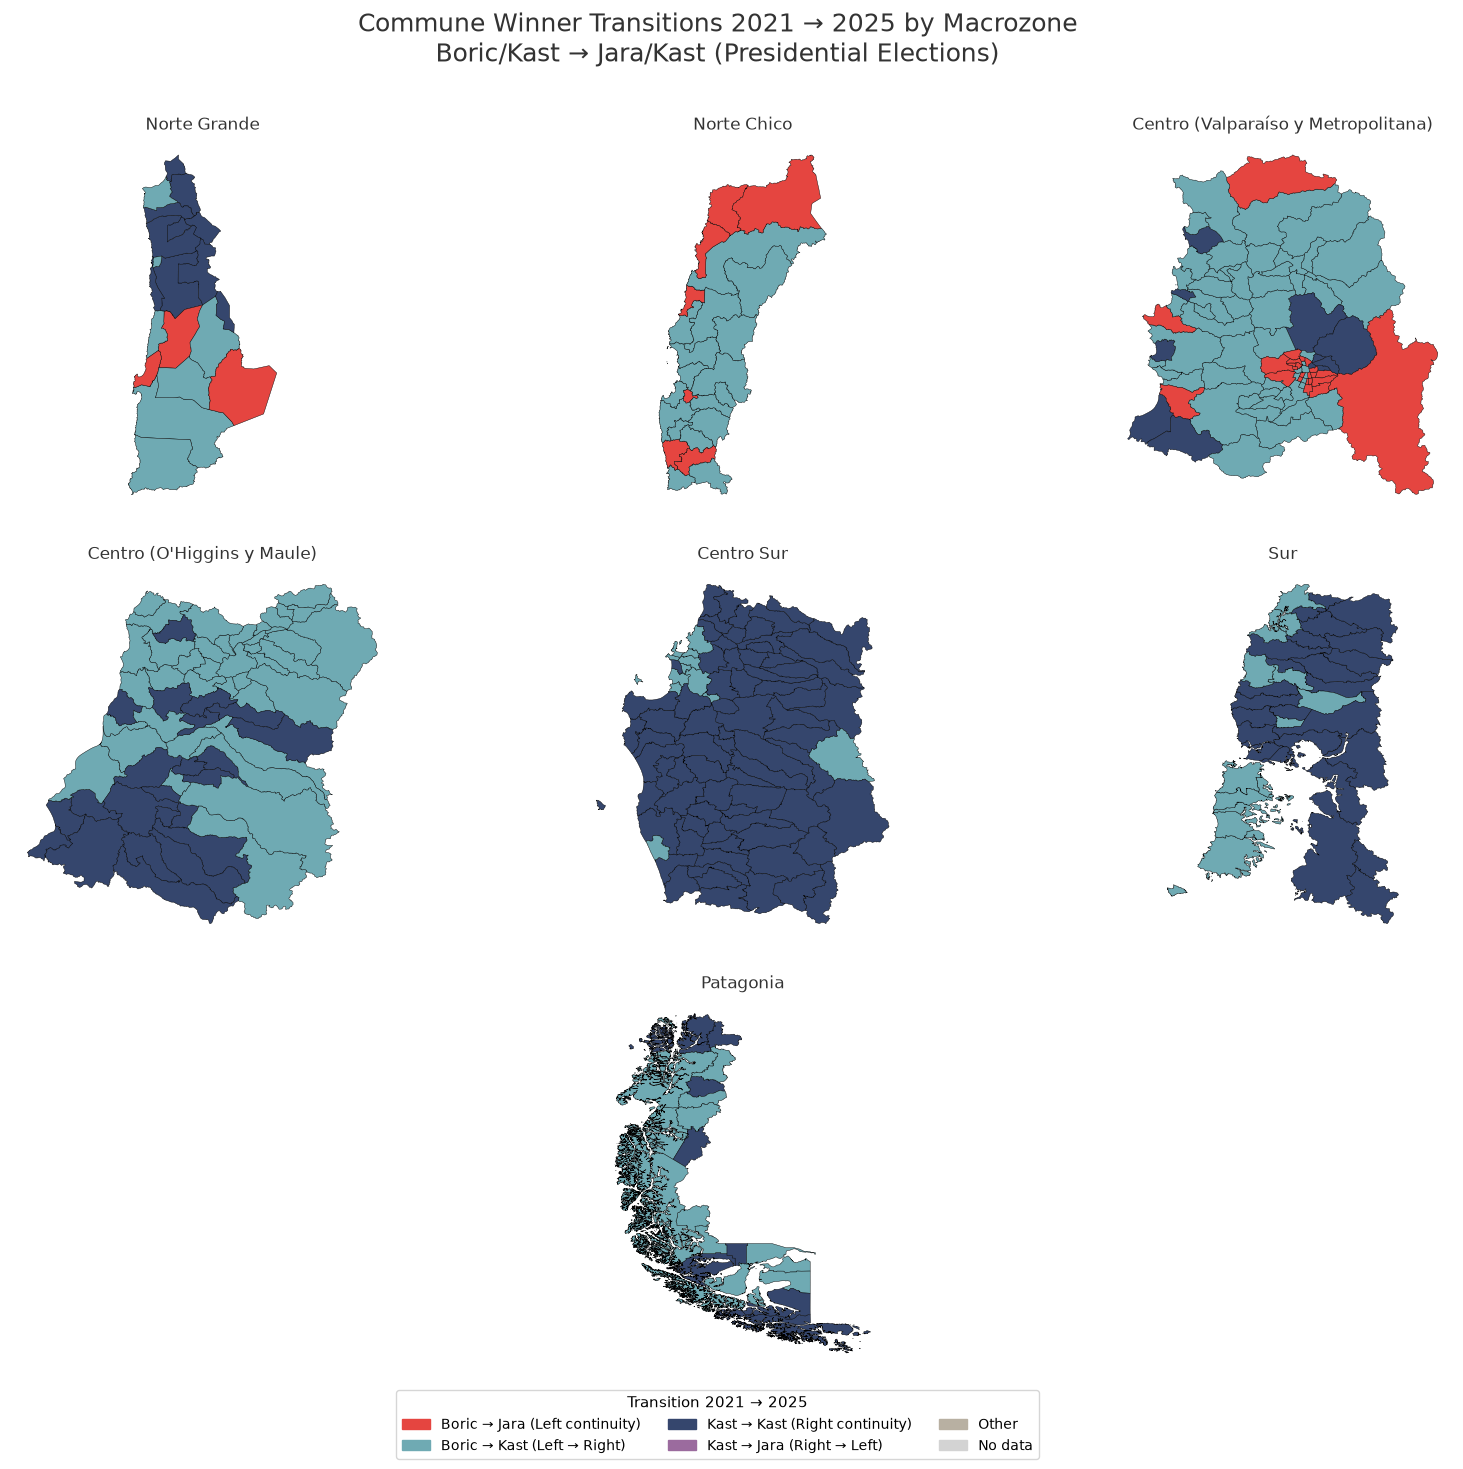

In [670]:
# ============================================================================
# TRANSITION MAP: 2021 → 2025 SECOND ROUND WINNER CHANGES BY COMMUNE
# ============================================================================
# Choropleth showing which communes changed second-round winner between
# the 2021 and 2025 elections; 3×3 macrozone grid layout.
# ============================================================================

# ---------------------------------------------------------------------------
# 1. TRANSITION COLOR PALETTE (Simplified for Boric/Kast → Jara/Kast)
# ---------------------------------------------------------------------------
TRANSITION_COLORS = {
    'Boric → Jara':       '#E54540',   # Red (left continuity)
    'Boric → Kast':       '#6FAAB3',   # Light blue (left → right)
    'Kast → Kast':        '#35466D',   # Dark blue (right continuity)
    'Kast → Jara':        '#9B6B9E',   # Purple (right → left)
    'Other':              '#B8B0A2',   # Gray (should not occur with simplified winners)
}

def assign_transition_color(row):
    """Map the 2021→2025 winner transition pair to a display color."""
    w21, w25 = row.get('winner_2021'), row.get('winner_2025')
    
    # Boric transitions
    if w21 == 'Boric (Left)' and w25 == 'Jara (Left)':
        return TRANSITION_COLORS['Boric → Jara']
    if w21 == 'Boric (Left)' and w25 == 'Kast (Right)':
        return TRANSITION_COLORS['Boric → Kast']
    
    # Kast transitions
    if w21 == 'Kast (Right)' and w25 == 'Kast (Right)':
        return TRANSITION_COLORS['Kast → Kast']
    if w21 == 'Kast (Right)' and w25 == 'Jara (Left)':
        return TRANSITION_COLORS['Kast → Jara']
    
    return TRANSITION_COLORS['Other']

# ---------------------------------------------------------------------------
# 2. NAME NORMALIZATION FOR SPATIAL JOIN
# ---------------------------------------------------------------------------
communes_map = communes.copy()
communes_map['NOM_COM_NORM'] = communes_map['NOM_COM'].apply(normalize_commune_name)
df_change['commune_norm'] = df_change['commune'].apply(normalize_commune_name)

# ---------------------------------------------------------------------------
# 3. SPATIAL JOIN: MERGE GEOMETRIES WITH TRANSITION DATA
# ---------------------------------------------------------------------------
map_data = communes_map.merge(
    df_change[['commune_norm', 'winner_2021', 'winner_2025']],
    left_on='NOM_COM_NORM',
    right_on='commune_norm',
    how='left',
)

map_data['color'] = map_data.apply(assign_transition_color, axis=1).fillna(TRANSITION_COLORS['Other'])

# Exclude island communes
map_data = map_data[~map_data['NOM_COM'].str.contains('Isla de Pascua|Juan Fernández', case=False, na=False)]

unmatched = map_data[map_data['winner_2021'].isna()]['NOM_COM'].tolist()
if unmatched:
    print(f"Communes with no transition data ({len(unmatched)}): {unmatched[:10]}")

# ---------------------------------------------------------------------------
# 4. MACROZONE ASSIGNMENT (7 ZONES)
# ---------------------------------------------------------------------------
MACROZONE_MAP = {
    15: 'Norte Grande',
    1:  'Norte Grande',
    2:  'Norte Grande',
    3:  'Norte Chico',
    4:  'Norte Chico',
    5:  'Centro (Valparaíso y Metropolitana)',
    13: 'Centro (Valparaíso y Metropolitana)',
    6:  "Centro (O'Higgins y Maule)",
    7:  "Centro (O'Higgins y Maule)",
    16: 'Centro Sur',
    8:  'Centro Sur',
    9:  'Centro Sur',
    14: 'Sur',
    10: 'Sur',
    11: 'Patagonia',
    12: 'Patagonia',
}

map_data['macrozone'] = map_data['REGION_NUM'].map(MACROZONE_MAP)

# ---------------------------------------------------------------------------
# 5. GRIDSPEC LAYOUT WITH SHARED LEGEND (consistent styling)
# ---------------------------------------------------------------------------
fig = plt.figure(figsize=(20, 16))
fig.patch.set_facecolor('white')
gs = GridSpec(3, 3, figure=fig, hspace=0.15, wspace=0.15)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])
ax4 = fig.add_subplot(gs[1, 0])
ax5 = fig.add_subplot(gs[1, 1])
ax6 = fig.add_subplot(gs[1, 2])
ax7 = fig.add_subplot(gs[2, 1])

zone_axes = [
    (ax1, 'Norte Grande'),
    (ax2, 'Norte Chico'),
    (ax3, 'Centro (Valparaíso y Metropolitana)'),
    (ax4, "Centro (O'Higgins y Maule)"),
    (ax5, 'Centro Sur'),
    (ax6, 'Sur'),
    (ax7, 'Patagonia'),
]

for ax, macro in zone_axes:
    macro_data = map_data[map_data['macrozone'] == macro].copy()
    if macro_data.empty:
        ax.text(0.5, 0.5, f'No data\n{macro}', ha='center', va='center', 
                transform=ax.transAxes, fontsize=12, color='#333333')
        ax.set_title(macro, fontsize=12, color='#333333')
        ax.set_axis_off()
        continue

    macro_data.plot(ax=ax, color=macro_data['color'], edgecolor='black', linewidth=0.3)
    ax.set_title(macro, fontsize=12, color='#333333')
    ax.set_axis_off()
    ax.set_aspect('equal')

    if macro == 'Patagonia':
        bounds = macro_data.total_bounds
        margin_x = (bounds[2] - bounds[0]) * 0.05
        margin_y = (bounds[3] - bounds[1]) * 0.05
        ax.set_xlim(bounds[0] - margin_x, bounds[2] + margin_x)
        ax.set_ylim(bounds[1] - margin_y, bounds[3] + margin_y)

# Hide unused grid cells
ax_empty1 = fig.add_subplot(gs[2, 0])
ax_empty2 = fig.add_subplot(gs[2, 2])
ax_empty1.set_visible(False)
ax_empty2.set_visible(False)

# Main title (no fontweight='bold')
fig.suptitle(
    'Commune Winner Transitions 2021 → 2025 by Macrozone\n'
    'Boric/Kast → Jara/Kast (Presidential Elections)',
    fontsize=18, y=0.96, color='#333333'
)

# ---------------------------------------------------------------------------
# 6. SHARED LEGEND (Simplified, with consistent styling)
# ---------------------------------------------------------------------------
legend_handles = [
    mpatches.Patch(color='#E54540', label='Boric → Jara (Left continuity)'),
    mpatches.Patch(color='#6FAAB3', label='Boric → Kast (Left → Right)'),
    mpatches.Patch(color='#35466D', label='Kast → Kast (Right continuity)'),
    mpatches.Patch(color='#9B6B9E', label='Kast → Jara (Right → Left)'),
    mpatches.Patch(color='#B8B0A2', label='Other'),
    mpatches.Patch(color='#D3D3D3', label='No data'),
]

fig.legend(
    handles=legend_handles, 
    loc='lower center', 
    ncol=3, 
    fontsize=10,
    title='Transition 2021 → 2025', 
    title_fontsize=11,
    bbox_to_anchor=(0.5, 0.05),
    frameon=True,
    facecolor='white',
    edgecolor='#cccccc'
)

plt.tight_layout(rect=[0, 0.02, 1, 0.94])
plt.show()

#### Analysis of the National Map

##### Norte Grande: Kast Consolidation with Some Left Bastions

The Norte Grande — Arica y Parinacota, Tarapacá and Antofagasta — shows a pattern of intense but heterogeneous realignment. In Arica y Parinacota and Tarapacá, the transition from Boric to Kast was almost complete: communes that in 2021 had backed the left-wing candidate migrated in 2025 towards Kast, reflecting both the transfer of the Parisi vote — who in the first round led in much of the north — and the impact of security and irregular migration issues, especially relevant in border zones. In Antofagasta, the pattern is more complex: the majority of communes transitioned towards Kast, but left-wing enclaves where the left retained its position persist — Mejillones, María Elena and San Pedro de Atacama — reflecting the persistence of the class vote in mining territories with a strong trade union presence.

The Norte Chico (Atacama and Coquimbo) presents a mixed pattern: Atacama recorded several transitions towards Kast but also maintained left-wing strongholds in mining communes (Chañaral, Diego de Almagro, Huasco, Caldera), while Coquimbo showed a more pronounced realignment towards Kast, with the exception of Andacollo, Canela and Illapel.

##### Centre: The Metropolitan Fracture

In the Centre — Valparaíso and the Metropolitan Region — the transition map reveals the country's most complex socio-spatial fracture. In Greater Santiago, the pattern is dual: the east and north of the capital, which in 2021 already backed Kast, consolidate and expand that support; the centre and part of the west show transitions from Boric towards Kast in communes that in 2021 had been part of the blue map — including communes such as Estación Central, El Bosque, Cerrillos and Independencia, where Kast prevailed despite being historical left-wing victories — and the core of the south and west — Puente Alto, Maipú, La Florida, La Pintana, Renca, Pedro Aguirre Cerda — maintains its blue colour, being the only territorial bloc in the region where the left managed to retain its 2021 dominance. In Valparaíso, most communes transitioned towards Kast, with the exception of the five already documented.

##### Centre-South, South and Patagonia: Uniform Realignment

In the arc running from O'Higgins to Patagonia, the transition map is practically monochromatic: almost all communes that in 2021 backed Boric — including historically left-wing zones in Greater Concepción and in the industrial enclaves of Biobío and La Araucanía — transitioned towards Kast. This uniform realignment in the south is the datum that most distinguishes the 2025 result from that of any previous election: it confirms that the political shift reached even the territories with the greatest tradition of progressive voting in non-metropolitan Chile, leaving the left without support points in eleven of the sixteen regions of the country.

#### 12.4.2. Maps of Metropolitan Areas and Conurbations

The analysis of transitions in the main metropolitan areas between 2021 and 2025 shows a clear realignment towards the right in most of the country's conurbations. Kast retained and expanded his base, capturing numerous communes that in 2021 had voted for Boric, while Jara maintained significant strongholds only in specific sectors of Greater Santiago and in the city of Valparaíso. Greater Santiago presented the most complex and polarised scenario, with a clear socioeconomic division between the south and west — where Jara held on — and the rest of the capital — where Kast advanced or consolidated. Greater Concepción, by contrast, showed the most uniform realignment among the large conurbations, with the left losing even communes with a strong working-class and industrial tradition.

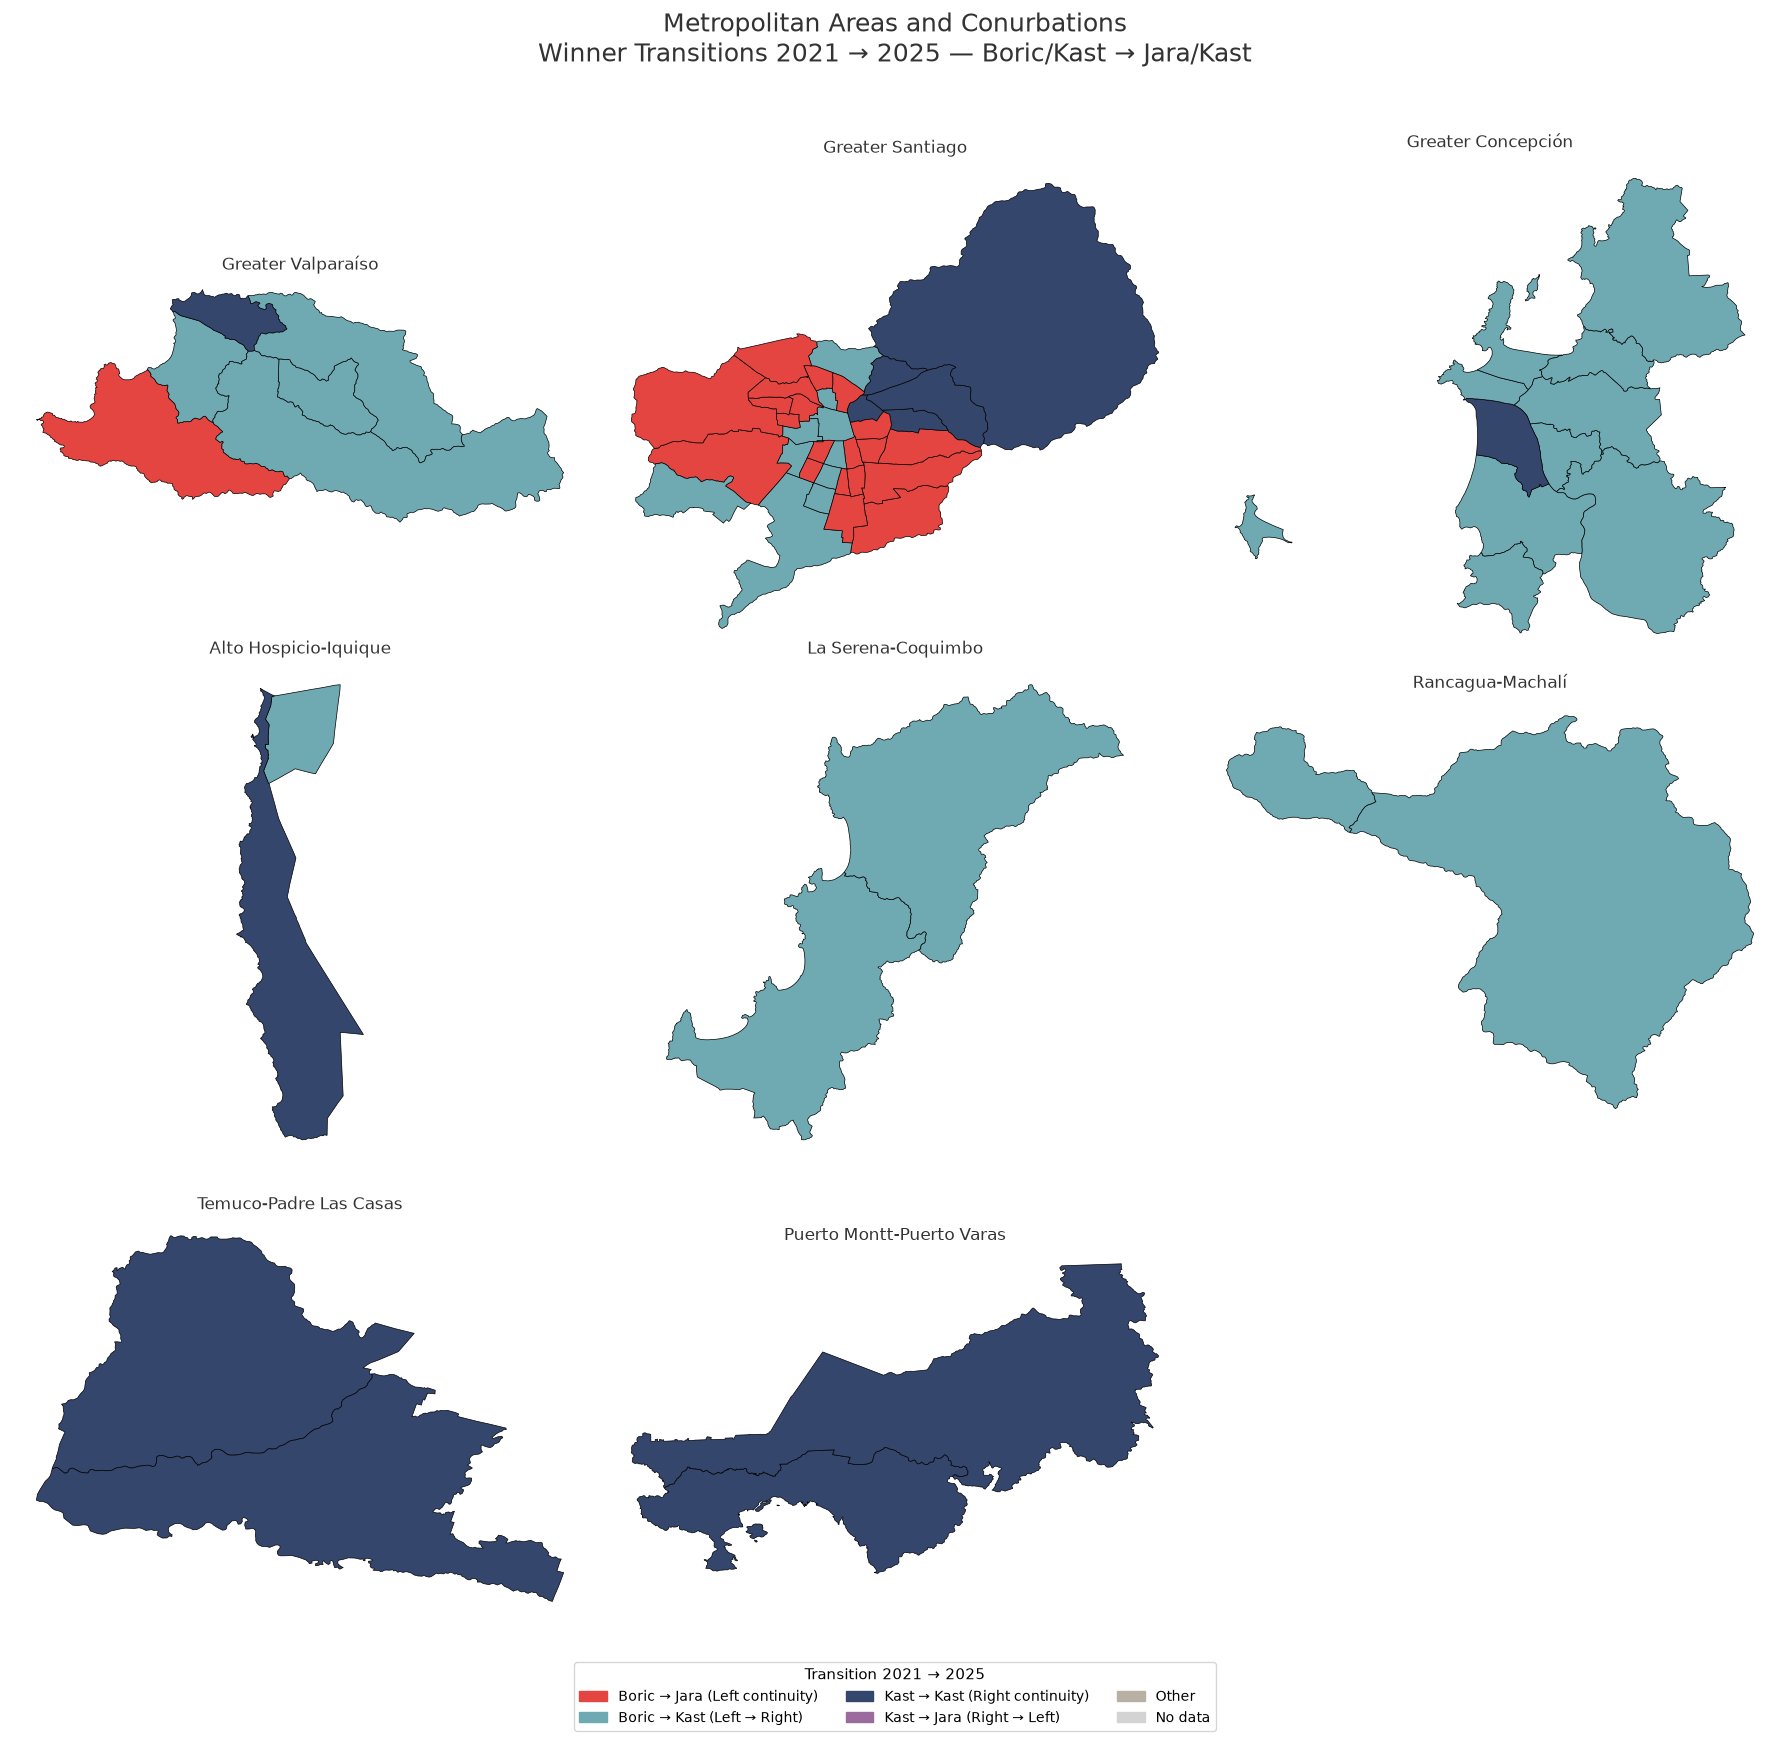

In [671]:
# ============================================================================
# METROPOLITAN AREAS — TRANSITION MAP: 2021 → 2025 SECOND ROUND
# ============================================================================
# Choropleth of 2021-to-2025 second-round winner transitions for Greater
# Santiago, Greater Valparaíso and Greater Concepción.
# ============================================================================

# ---------------------------------------------------------------------------
# 1. URBAN AGGLOMERATION DEFINITIONS
# ---------------------------------------------------------------------------
METRO_AREAS_TRANS = {
    'Greater Valparaíso': [
        "Valparaíso", "Viña del Mar", "Concón", "Quilpué", "Villa Alemana", "Limache",
    ],
    'Greater Santiago': [
        "Cerrillos", "Cerro Navia", "Conchalí", "El Bosque", "Estación Central",
        "Huechuraba", "Independencia", "La Cisterna", "La Florida", "La Granja",
        "Providencia", "Las Condes", "La Reina", "Lo Espejo", "Lo Prado", "Macul",
        "Maipú", "Ñuñoa", "Padre Hurtado", "Pedro Aguirre Cerda", "Peñalolén",
        "Vitacura", "Pudahuel", "Puente Alto", "Quilicura", "Quinta Normal",
        "Recoleta", "Renca", "San Bernardo", "San Joaquín", "San Miguel",
        "San Ramón", "Santiago", "Lo Barnechea", "La Pintana",
    ],
    'Greater Concepción': [
        "Concepción", "Coronel", "Chiguayante", "Hualpén", "Hualqui", "Lota",
        "Penco", "San Pedro de la Paz", "Talcahuano", "Tomé",
    ],
    'Alto Hospicio-Iquique':    ["Alto Hospicio", "Iquique"],
    'La Serena-Coquimbo':       ["La Serena", "Coquimbo"],
    'Rancagua-Machalí':         ["Rancagua", "Machalí"],
    'Temuco-Padre Las Casas':   ["Temuco", "Padre Las Casas"],
    'Puerto Montt-Puerto Varas': ["Puerto Montt", "Puerto Varas"],
}

# Grid layout: (row, col) → area name  (cell (2,2) intentionally empty)
GRID_LAYOUT_TRANS = [
    (0, 0, 'Greater Valparaíso'),
    (0, 1, 'Greater Santiago'),
    (0, 2, 'Greater Concepción'),
    (1, 0, 'Alto Hospicio-Iquique'),
    (1, 1, 'La Serena-Coquimbo'),
    (1, 2, 'Rancagua-Machalí'),
    (2, 0, 'Temuco-Padre Las Casas'),
    (2, 1, 'Puerto Montt-Puerto Varas'),
]

# Pre-compute normalized key sets for encoding-safe GeoJSON filtering
area_norm_keys_trans = {
    area: {normalize_commune_name(c) for c in commune_list}
    for area, commune_list in METRO_AREAS_TRANS.items()
}

# ---------------------------------------------------------------------------
# 2. TRANSITION COLOR PALETTE (Simplified - consistent with national map)
# ---------------------------------------------------------------------------
TRANSITION_COLORS_SIMPLE = {
    'Boric → Jara':       '#E54540',   # Red (left continuity)
    'Boric → Kast':       '#6FAAB3',   # Light blue (left → right)
    'Kast → Kast':        '#35466D',   # Dark blue (right continuity)
    'Kast → Jara':        '#9B6B9E',   # Purple (right → left)
    'Other':              '#B8B0A2',   # Gray
}

def assign_transition_color_simple(row):
    """Map the 2021→2025 winner transition pair to a display color."""
    w21, w25 = row.get('winner_2021'), row.get('winner_2025')
    
    if w21 == 'Boric (Left)' and w25 == 'Jara (Left)':
        return TRANSITION_COLORS_SIMPLE['Boric → Jara']
    if w21 == 'Boric (Left)' and w25 == 'Kast (Right)':
        return TRANSITION_COLORS_SIMPLE['Boric → Kast']
    if w21 == 'Kast (Right)' and w25 == 'Kast (Right)':
        return TRANSITION_COLORS_SIMPLE['Kast → Kast']
    if w21 == 'Kast (Right)' and w25 == 'Jara (Left)':
        return TRANSITION_COLORS_SIMPLE['Kast → Jara']
    
    return TRANSITION_COLORS_SIMPLE['Other']

# ---------------------------------------------------------------------------
# 3. BUILD TRANSITION GEODATAFRAME
# ---------------------------------------------------------------------------
communes_trans = communes.copy()
communes_trans['NOM_COM_NORM'] = communes_trans['NOM_COM'].apply(normalize_commune_name)

df_change_local = df_change.copy()
df_change_local['commune_norm'] = df_change_local['commune'].apply(normalize_commune_name)

map_data_trans = communes_trans.merge(
    df_change_local[['commune_norm', 'winner_2021', 'winner_2025']],
    left_on='NOM_COM_NORM',
    right_on='commune_norm',
    how='left',
)

map_data_trans['color'] = (
    map_data_trans.apply(assign_transition_color_simple, axis=1)
    .fillna(TRANSITION_COLORS_SIMPLE['Other'])
)

# Exclude island communes
map_data_trans = map_data_trans[~map_data_trans['NOM_COM'].str.contains('Isla de Pascua|Juan Fernández', case=False, na=False)]

# ---------------------------------------------------------------------------
# 4. RENDER 3×3 FACET GRID (with consistent styling)
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(3, 3, figsize=(18, 18))
fig.patch.set_facecolor('white')
fig.suptitle(
    'Metropolitan Areas and Conurbations\n'
    'Winner Transitions 2021 → 2025 — Boric/Kast → Jara/Kast',
    fontsize=18, y=0.98, color='#333333'
)

for row, col, area_name in GRID_LAYOUT_TRANS:
    ax = axes[row, col]
    norm_set = area_norm_keys_trans[area_name]

    area_data = map_data_trans[map_data_trans['NOM_COM_NORM'].isin(norm_set)].copy()

    if area_data.empty:
        ax.text(0.5, 0.5, f'No data\n{area_name}',
                ha='center', va='center', transform=ax.transAxes,
                fontsize=12, color='#333333')
        ax.set_title(area_name, fontsize=12, color='#333333')
        ax.set_axis_off()
        continue

    area_data.plot(ax=ax, color=area_data['color'], edgecolor='black', linewidth=0.5)
    ax.set_title(area_name, fontsize=12, color='#333333')
    ax.set_axis_off()
    ax.set_aspect('equal')

# Hide unused bottom-right cell
axes[2, 2].set_visible(False)

# ---------------------------------------------------------------------------
# 5. SHARED LEGEND (Simplified, with consistent styling)
# ---------------------------------------------------------------------------
legend_handles = [
    mpatches.Patch(color='#E54540', label='Boric → Jara (Left continuity)'),
    mpatches.Patch(color='#6FAAB3', label='Boric → Kast (Left → Right)'),
    mpatches.Patch(color='#35466D', label='Kast → Kast (Right continuity)'),
    mpatches.Patch(color='#9B6B9E', label='Kast → Jara (Right → Left)'),
    mpatches.Patch(color='#B8B0A2', label='Other'),
    mpatches.Patch(color='#D3D3D3', label='No data'),
]

fig.legend(
    handles=legend_handles, 
    loc='lower center', 
    ncol=3, 
    fontsize=10,
    title='Transition 2021 → 2025', 
    title_fontsize=11,
    bbox_to_anchor=(0.5, 0.02),
    frameon=True,
    facecolor='white',
    edgecolor='#cccccc'
)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

#### Analysis of Metropolitan Transitions

##### Greater Santiago: Socioeconomic Polarisation and Realignment

Greater Santiago presents the most complex and polarised scenario in the 2021-2025 realignment. The pattern that emerges is that of a deeply divided city along socioeconomic lines, where transitions reflect the persistence of structural fractures in the vote.

In the **west and south of Santiago** — Puente Alto, Maipú, La Pintana, Lo Espejo, Renca, Conchalí, Quilicura and adjacent communes — a pattern of Boric-Jara continuity is observed: the left managed to maintain its support between 2021 and 2025, though in several cases with tighter margins than in the previous election. That these communes resisted the generalised realignment confirms the solidity of the core of popular support for the left among lower-income sectors of Greater Santiago.

In the **centre and north-east** — Estación Central, El Bosque, Cerrillos, Huechuraba, Independencia, San Miguel and other middle-class communes — the most significant transitions of the metropolitan map concentrate: communes that in 2021 had backed Boric changed sign in 2025, passing to the Kast bloc. Estación Central is the emblematic case: its passage from Boric to Kast — with a margin of barely 0.7 points in favour of the republican candidate — reflects the high volatility of the middle-class vote in Santiago and Jara's inability to mobilise an electorate that four years earlier had bet on change. El Bosque also changed sign, though by an equally narrow margin (0.21 pp for Kast), confirming that these communes operated as the principal dispute front of the runoff in the capital.

In **eastern Santiago** — Las Condes, Vitacura, Providencia, Lo Barnechea, La Reina — the pattern is one of continuity and deepening of Kast's dominance, who in 2021 already led in these communes and in 2025 widened his advantage thanks to the transfer of Evelyn Matthei's vote.

##### Greater Valparaíso: Partial Retention and Loss in the Periphery

Greater Valparaíso shows a mixed pattern: Jara managed to retain the city of Valparaíso, San Antonio and Petorca — communes where the left has a historical rootedness linked to the port movement and socio-environmental demands — but lost several communes that in 2021 had backed Boric, including Viña del Mar, Quilpué, Villa Alemana and several coastal communes. That Viña del Mar — the region's second most important city, governed by the left-wing mayor Macarena Ripamonti — transitioned towards Kast with a margin close to 10% confirms that the erosion of Boric's government also reached cities where progressivism had relevant institutional presence.

##### Greater Concepción: The Deepest Realignment

Greater Concepción presents the most uniform and deepest realignment among the country's major metropolitan areas. Virtually all the communes that in 2021 had backed Boric — including Concepción, Talcahuano, Coronel and Lota, historically working-class and industrial localities — transitioned towards Kast in 2025. The depth of this realignment in a zone of strong trade union tradition is one of the most surprising findings of the comparative analysis, and suggests that Boric's government's erosion affected with particular intensity the working-class sectors of the south, who perceived that the policies of the period did not respond to their concrete demands for security, employment and improvement in the cost of living.

#### Conclusion: Transition Maps 2021-2025 (12.4.1 & 12.4.2)

The transition maps between 2021 and 2025 confirm that the electoral realignment was a territorial phenomenon of unprecedented breadth, affecting both rural and provincial Chile — where the left lost practically all its strongholds — and the large cities — where only the popular core of Greater Santiago and the city of Valparaíso resisted the general shift. The depth of the realignment in Greater Concepción, in the intermediate cities of the north and in the middle-class communes of Greater Santiago confirms that the 2025 shift was not only an expression of the rural and conservative vote, but also of an urban and middle-class electorate that, faced with the erosion of the reform cycle and the perception of insecurity and economic deterioration, opted en masse for a change of political direction.

### Chapter 12 Conclusion: Comparative Analysis 2021–2025

The comparison between the second round elections of 2021 and 2025 reveals an electoral realignment of historic magnitude, driven by the confluence of three fundamental factors: the change to compulsory voting, the exhaustion of the reform cycle initiated with the social uprising of 2019, and the consolidation of Kast as leader of a coalition that transcends the traditional right.

Compulsory voting transformed the scale of the election — going from 8.3 to 13.3 million votes cast — but its most relevant impact was not quantitative but distributive: the millions of new voters incorporated distributed asymmetrically, favouring the right in most territories. This effect, which inverts the implicit assumption that compulsory voting would benefit the left through its greater concentration in working-class sectors, suggests that the low-participation electorate of 2021 was ideologically more heterogeneous — and even more inclined towards the right or the anti-establishment — than previous analyses had anticipated.

The exhaustion of the reform cycle is expressed in all its crudeness in the communal comparison: the left lost 158 of the 194 communes it had won in 2021, a desertion rate of 81.4% that has no parallel in recent Chilean electoral history. This result does not only reflect the effect of compulsory voting; it also reflects the failure of the two constitutional plebiscites, the persistence of perceptions of insecurity and the deterioration of Boric's government image, which arrived at the 2025 election with approval levels below 35% in most polls.

The consolidation of Kast as leader of a broad coalition is the third pillar of the realignment. His perfect retention of the 152 communes of 2021 and the incorporation of 158 new ones — in 14 of the 16 regions of the country — confirm that he built a territorial majority combining historically distinct bases: the conservative right of the south, the anti-establishment of the north, the discontented urban middle class and the higher-income sectors. This diversity is simultaneously his principal political asset and his greatest governability challenge.

The 2025 realignment poses a fundamental question that exceeds the scope of this analysis but which any political reading of the result must address: is this a lasting change in the preferences of the Chilean electorate, or a cycle of conjunctural alternation driven by the outgoing government's erosion? Comparative Latin American experience and Chile's own political history suggest that the answer will depend, more than any other factor, on the new government's capacity to translate its mandate into concrete results in the areas that motivated the shift: security, migration control, cost of living and reconnection with the provincial and peripheral Chile that voted most massively for Kast.

---

## 13. Strategic Lessons and Post-Election Challenges 2025

### Introduction

The 2025 runoff leaves a reconfigured political map that poses distinct challenges for each of the principal actors in the process. José Antonio Kast built a territorially diverse and electorally decisive coalition, but the high level of null voting and the persistence of an unabsorbed anti-establishment discontent warn that his victory, though decisive, is not a guarantee of governability without negotiation. Jeannette Jara defended her urban-popular core with relative solidity, but was trapped in a highly concentrated map that poses structural challenges for the medium-term viability of her coalition. Franco Parisi, for his part, demonstrated the validity of the anti-establishment vote, but his electorate fragmented in the runoff and his projection as a national alternative is conditioned by his capacity to build a more solid political organisation.

The reflections that follow are not normative recommendations about what each actor *should* do, but a strategic analysis of the opportunities and constraints that the electoral result configures for each of them, based on the findings documented in previous chapters.


### 13.1. Strategic Challenges for the Ruling-Coalition in Opposition

#### Diagnosis

Jara successfully retained her hard urban-popular core — high retention rate in strongholds such as Puente Alto, Maipú and northern mining communes —, but the final result reveals a structural weakness that the territorial analysis makes difficult to ignore: 36 communes won in five regions, with a dependence on the Metropolitan Region that reached 58% of her victories. The 18.6% retention rate relative to the communes won by Boric in 2021 — a loss of 158 of the 194 communes of the previous cycle — is not attributable exclusively to the effect of compulsory voting or to the conjunctural erosion of the outgoing government. It also reflects a deep territorial disconnection from rural, provincial and peripheral Chile that the 2025 result makes visible in all its crudeness.

#### Dimensions of the Challenge

**Programmatic credibility.** Boric's government inherited the expectations of the social uprising and failed to satisfy them sufficiently to maintain the adherence of the centre sectors that in 2021 had tipped the balance towards the left. Both the failure of the two constitutional plebiscites and the persistence of perceptions of insecurity contributed to eroding the confidence of the most volatile electorate. Any reconstruction of the coalition will require a self-critical review of the management errors of the period, before proposing a new programme aspiring to capture a majority.

**Territorial expansion.** The concentration of support in the Metropolitan Region and in some Norte Chico enclaves is not sustainable as a base for a national majority. The analysis of flips in northern mining communes — where the class vote and labour demands were more decisive than anti-establishment discontent — suggests that a niche for expansion exists in territories with high trade union density and dependence on large-scale mining. However, the total absence of communal victories south of the Metropolitan Region confirms that the expansion strategy must go beyond that niche and address the demands of rural Chile, where conservative rootedness is deep but not necessarily irreversible.

**The opportunity of the protest vote.** The correlation analysis between null voting and Jara's performance (section 8.7) showed that the protest vote was not exclusively a phenomenon that harmed the left: in some territories, it coexisted with growth in her base. If a relevant fraction of the electorate that opted for the null was responding to a rejection of the system rather than a preference for the right, the left has a potential recovery margin in that segment, conditioned by its capacity to reach that discontented electorate with an offer combining change and effective management.

**Internal fragmentation.** The 2025 defeat could activate internal tensions about the leadership and programmatic direction of the coalition. Signals from different sectors — from those advocating renewal towards the centre to those advocating maintaining the left-wing identity — suggest that the reconstruction process may not be linear or free of internal conflicts.


### 13.2. Strategic Challenges for Kast's Government

#### Diagnosis

Kast arrives in government with an exceptionally broad electoral mandate — 58.16% of valid votes, 310 communes won, victory in all 16 regions — but with relevant institutional and political constraints conditioning his capacity to implement his programme.

#### Dimensions of the Challenge

**Legislative governability.** The incoming Congress, resulting from the parliamentary elections of November, does not grant the government an automatic majority in either chamber. The Chamber of Deputies is fragmented among at least three blocs — the republican, Chile Vamos and the libertarians associated with Kaiser — which, while sharing general support for Kast, have nuanced differences in matters such as economic policy, civil rights and state reform. The Senate, which functions as a reviewing chamber and where quorums for constitutional reforms are demanding, requires the construction of transversal majorities that the government will need to sustain over time. Parliamentary fragmentation makes it predictable that the most far-reaching reforms — in matters such as security, migration or the pension regime — will have to be negotiated vote by vote, not just commune by commune.

**The North and the unabsorbed protest vote.** The territorial analysis shows that the transfer of the Parisi vote towards Kast was substantial but incomplete. In the mining communes of the Norte Grande and Norte Chico — where the null vote was most pronounced and where support for Kast was tighter — the new government faces the challenge of demonstrating that its policies respond to the specific demands of those communities: effective control of irregular migration, local economic development that distributes the benefits of mining, and security in border zones. If these demands are not addressed concretely and visibly, the North's electorate — which in 2025 distributed between Kast, Jara and the null vote — is the most prone to reactivating its rejection of the political system in the next electoral cycle.

**Coalition cohesion.** The heterogeneity of the coalition that backed Kast — ranging from Chile Vamos's traditional right to Kaiser's libertarians, through centre sectors such as Amarillos and Demócratas — is simultaneously its electoral strength and its principal governability challenge. Interests and priorities not always aligned among these sectors will require careful political management to maintain cohesion without alienating any of the support blocs. The increase in the blank vote in communes of eastern Santiago — bastions of Matthei's traditional right — suggests that a fraction of that electorate did not fully validate Kast's candidacy, which could translate into tensions within the governing coalition if implemented policies do not correspond to their expectations.

**The mandate of rural Chile.** Kast obtained his highest percentages in rural and provincial Chile — exceeding 70% in several communes of La Araucanía, Los Lagos and Ñuble. This electorate has specific and concrete demands: water, connectivity, rural security, support for the agricultural and livestock world, and productive development. Addressing these demands, in a context of budgetary constraints, will require prioritising social spending in territories that have historically been marginalised by centralism and that, in 2025, responded to Kast's call partly as an expression of that discontent with the central state.

**Managing polarisation.** The election result — 58% against 42% nationally, with a particularly pronounced urban-rural fracture — configures a scenario of high social polarisation that the new government will need to manage carefully. An excessively confrontational governance style with the opposition or with the social organisations that back the left could deepen that polarisation and hinder the construction of minimum consensuses on matters of national interest. The experience of governments that arrived with broad mandates and diluted them through their inability to include significant minorities is a relevant reference parameter.


### 13.3. The Anti-Establishment Vote: Conjunctural Phenomenon or Structural Factor?

Franco Parisi's performance in the first round — 19.71% of votes, the country's third force — and the behaviour of his electorate in the second round raise questions that transcend the immediate result. The anti-establishment vote in Chile is not a new phenomenon — it was already present in 2021 with Parisi and in the constitutional plebiscites —, but its scale in 2025 and its territorial distribution confirm that it responds to unresolved structural demands rather than to the mere charismatic presence of a leader.

The profile of Parisi's electorate — predominantly male, under 45, middle class, with high institutional distrust and concentration in the northern mining belt — identifies a segment of the electorate that perceives itself as excluded from the traditional political system. Its concrete demands — security, migration control, more equitable distribution of the benefits of extractive activity, combating corruption — are real and have objective correlates in the socioeconomic indicators of the communes where the PDG was strongest. That in the runoff a majority of that electorate opted for Kast rather than Jara or the null vote suggests that the new government provisionally absorbed that political energy; whether it converts it into stable support or whether discontent resurfaces will depend on management results.

For Partido de la Gente as an organisation, the runoff result — with a null vote that did not reach Parisi's projections — reveals the limits of a pure protest strategy. The conversion of discontent into a sustainable political alternative requires both leadership and territorial, programmatic and cadre organisation, dimensions that the PDG has not developed visibly until now.

---

## Final Conclusion

The 2025 presidential runoff constitutes an electoral milestone that reconfigures the Chilean political map in terms that transcend the mere change of occupant at La Moneda. José Antonio Kast obtained a decisive victory — 58.16% of valid votes according to Servel's official result, with a margin of nearly 17 points over Jeannette Jara — that ranks among the broadest in recent democratic history. However, this majority, though indisputable, should not be read as monolithic adherence to a conservative ideological project, but as the expression of a complex and territorially heterogeneous realignment, driven by the confluence of institutional, political and sociological factors that redefine the balance of power in the country.

**The territorial realignment** is the most eloquent indicator of the depth of the change. 56.1% of the country's communes changed sign between 2021 and 2025; Kast retained 100% of his 2021 communes and added 158 new ones; the left lost 81.4% of the communes that Boric had won four years earlier. This asymmetry in retention rates is the most direct expression of the political shift: the right consolidated a broad and diverse territorial base — combining the anti-establishment north, the Santiago elite and the rural-conservative Chile of the south —, while the left was confined to an archipelago of urban and mining strongholds.

**Compulsory voting** acted as an amplifier of the realignment. By incorporating millions of voters with low partisan identification, the new electoral regime revealed that the low-participation electorate of 2021 was more heterogeneous — and more inclined towards the right or the anti-establishment — than previous analyses had anticipated. The asymmetry in the absolute growth of both candidacies — Kast added 3.6 million additional votes relative to 2021; Jara barely 587,000 — confirms that compulsory voting clearly favoured the right.

**The protest vote** emerged as a structural phenomenon without recent precedent. With 782,029 null votes and 164,552 blank, the 2025 runoff recorded the highest level of invalid ballots in a Chilean presidential election since the return to democracy. This phenomenon — whose epicentre was the Norte Grande, where the Parisi electorate expressed its rejection of the bipolar duel — does not detract from the validity of Kast's triumph, but does qualify its reading: the new president takes office with a broad mandate in valid votes and with a level of citizen disaffection that any honest analysis of the result must weigh.

**The governability challenges** are real and multidimensional. Fragmentation of the incoming Congress will require sustained negotiation. The North — where the transfer of the Parisi vote was incomplete and the null vote was most pronounced — requires concrete development and security policies. The heterogeneity of the governing coalition poses the challenge of maintaining its cohesion against demands and interests not always aligned. And the territorial polarisation the electoral map expresses — with an urban-popular Chile that voted for Jara and a rural-provincial Chile that voted massively for Kast — is a fracture that no government can ignore without costs.

In synthesis, the 2025 election closes a political cycle initiated with the social uprising of 2019 and opens a new one whose direction and content remain to be defined. The new government has the opportunity to govern with the broadest mandate granted to a right-wing candidate in Chile's democratic history. The relevant question is not whether that mandate is legitimate — it is, unquestionably — but whether the management that succeeds it will have the capacity to respond to the demands of the heterogeneous and demanding electorate that produced it. The answer to that question will define whether the 2025 realignment is the starting point of a new durable political equilibrium, or the beginning of another cycle of alternation in a political system that is still searching for its new point of stability.